# Flower classification
### Built a simple model using SaANN CNN class for flower classification between 'daisy', 'dandelion', 'rose', 'sunflower', 'tulip'.

Dataset courtesy: imsparsh ([kagglehub](https://www.kaggle.com/imsparsh)) - All photographers are listed at the end of the notebook

code for dataset:

    >>> import kagglehub

    >>> path = kagglehub.dataset_download("imsparsh/flowers-dataset")

Please note that some data engineering was applied in order to get a dataset ready for SaANN's CNN model:

1. The *path* variable is a string that leads to a directory containing all images 
2. The images are separated within directory which names reflect the classes that the model is training on
3. The images are then pass to SaNNN's image processor for resizing and upload

## Part 1 - Set up your model

The following is an example on how to set-up you model 

Be aware: it is not to show the quality of the model!

In [1]:
# Path to directory
path_flowers = r"--\.cache\kagglehub\datasets\imsparsh\flowers-dataset\versions\2\train" #on windows
path_flowers = r"C:\Users\aless\.cache\kagglehub\datasets\imsparsh\flowers-dataset\versions\2\train"

In [ ]:
# Prepare images for training and testing
from saann.processing import ImageProcessing

IP = ImageProcessing(images_path=path_flowers)
X_train, X_test, y_train, y_test, list_classes = IP.ready_dataset(size=98, amount=100, shuffle = True, remove_resized=True, split_test_percentage=0.3)

GPU failed: DLL load failed while importing cublas: The specified module could not be found.
List of directories:  ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Resizing images to (98 x 98)
Processing image # 100
Processing image # 200
Processing image # 300
Processing image # 400
Processing image # 500
Dataset already clean.
Dataset has been shuffled.
Dataset is ready and has been split into Train (length = 350) and Test (length = 150) sets.


### Parameters

*amount* : limits the amount of images per class | Default is None (no limits)
    
*size* : resized the images to a square with resolution size x size

*shuffle* : Randomly shuffles your dataset

*remove_resized*: SaANN creates a directory within the parent direcotory names "resized". If True, it will remove this directory after upload

*split_test_percentage*: Splits dataset into a Train (1-percentage) and Test (percentage)

Estimated time: 8 minutes.

Training for 20 Epochs with learning rate: 0.0001
Epoch    1/20, Loss: 1.85133
Epoch    2/20, Loss: 2.03030
Epoch    4/20, Loss: 1.76432
Epoch    6/20, Loss: 1.63862
Epoch    8/20, Loss: 1.56682
Epoch   10/20, Loss: 1.51816
Epoch   12/20, Loss: 1.55138
Epoch   14/20, Loss: 1.45493
Epoch   16/20, Loss: 1.37212
Epoch   18/20, Loss: 1.45762
Epoch   20/20, Loss: 1.34518

Final 'cross-entropy' loss on training data: 1.35842


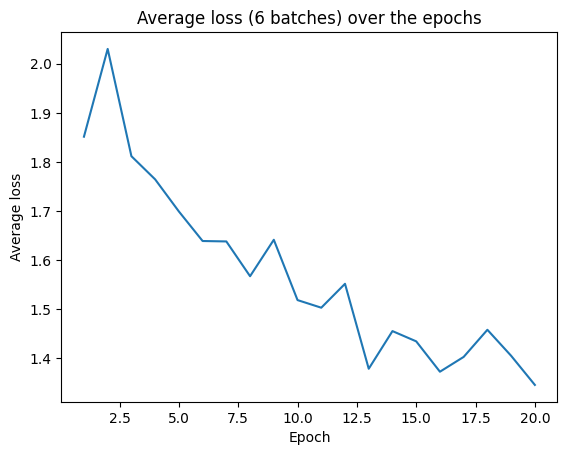

In [ ]:
from saann.models import CNN

# Initialize the model
model_cnn = CNN(filter_size = 3, num_filters = 32, padding = 1, stride = 1, activation_function = "relu", init_function = "he")
# Get the size of the input after passing through the convolution array
input_size = model_cnn.get_input_size(X_train=X_train)
# Define the layers
layer_info = [
    (input_size, 256, 'relu', 'he'),
    (256, 128, 'relu', 'he'),
    (128, y_train.shape[1], 'softmax', 'he')
]
# Construct the layers
model_cnn.construct(layers_info=layer_info, learning_rate=1e-4)
# Perform training
final_pred = model_cnn.fit(X_train = X_train, y_train=y_train, epochs = 20, batch_size = 32, wd = 0.00001, graphical = True, real_time = False, log_plot = False)


In [11]:
# Make predictions
y_pred = model_cnn.predict(X_test=X_test)

print(y_pred)

[[0.45657543 0.15460883 0.16571385 0.11731714 0.10578475]
 [0.25659866 0.13907455 0.00962532 0.56750303 0.02719845]
 [0.23747054 0.33461387 0.18553221 0.19358422 0.04879916]
 [0.51788047 0.06518114 0.28947998 0.07085595 0.05660246]
 [0.37801035 0.07508816 0.12657004 0.10871715 0.3116143 ]
 [0.13832347 0.14077953 0.64685256 0.0385584  0.03548604]
 [0.08015051 0.06513349 0.25330703 0.41094312 0.19046584]
 [0.06669547 0.42341891 0.08057029 0.31421519 0.11510015]
 [0.16508704 0.06448395 0.06854589 0.46874909 0.23313403]
 [0.09223639 0.22570463 0.16942213 0.11817957 0.39445728]
 [0.15351901 0.05367198 0.09111358 0.43312425 0.26857118]
 [0.12202651 0.20909793 0.00459885 0.16844642 0.49583029]
 [0.15604187 0.229444   0.3078869  0.1894642  0.11716304]
 [0.44172065 0.0788775  0.08876058 0.19107645 0.19956482]
 [0.03727535 0.13206263 0.04401236 0.21007065 0.576579  ]
 [0.09812952 0.6393041  0.07341136 0.0115337  0.17762132]
 [0.11426376 0.06317356 0.59646075 0.10990403 0.1161979 ]
 [0.06230223 0

In [ ]:
from saann.metrics import Metrics
# Initialize the Metrics class
metrics = Metrics(y_pred=y_pred, y_test=y_test)

Confusion matrix:
 [[6 2 2 1 4]
 [0 7 2 3 1]
 [3 2 7 1 3]
 [2 2 2 5 3]
 [2 4 4 4 3]]

Class                 1      2      3      4      5 
------------------
Balanced accuracy | 0.642, 0.689, 0.634, 0.605, 0.493
Precision         | 0.462, 0.412, 0.412, 0.357, 0.214
Recall            | 0.400, 0.538, 0.437, 0.357, 0.176
Specificity       | 0.883, 0.839, 0.831, 0.852, 0.810
F1-score          | 0.429, 0.467, 0.424, 0.357, 0.194
------------------
Macro F1: 0.374
Weighted F1: 0.368
MCC: 0.043

AUC: 0.627


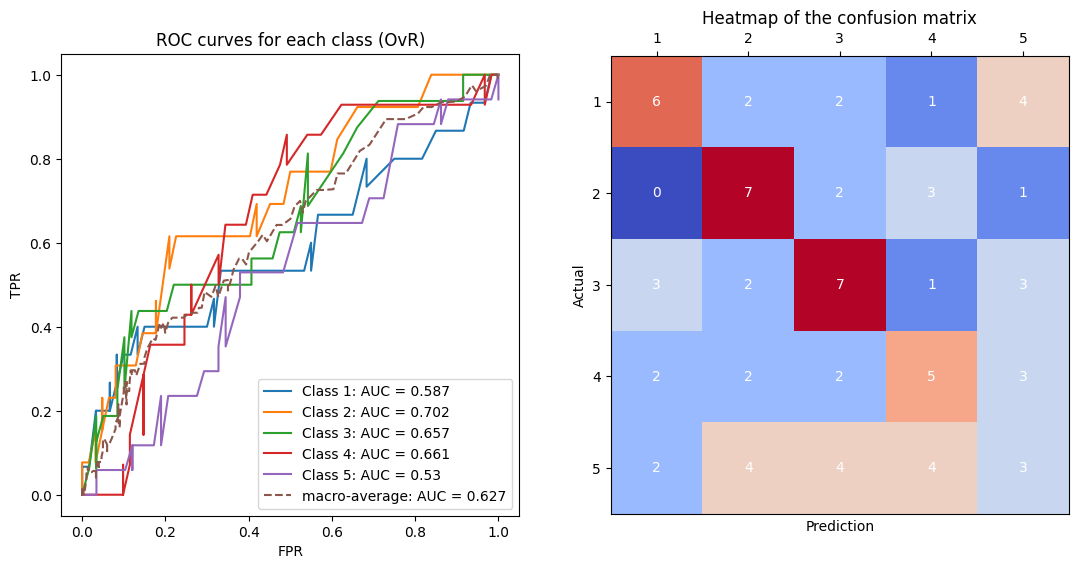

In [13]:
# Get a fast report of the model's metrics
metrics.report()

Confusion matrix:
 [[6 2 2 1 4]
 [0 7 2 3 1]
 [3 2 7 1 3]
 [2 2 2 5 3]
 [2 4 4 4 3]]
Accuracy: [np.float64(0.6416666664597221), np.float64(0.6885856076657082), np.float64(0.6340042370810348), np.float64(0.6048009365707252), np.float64(0.49340770778899007)]
precision: [np.float64(0.46153846118343195), np.float64(0.4117647056401384), np.float64(0.4117647056401384), np.float64(0.3571428568877551), np.float64(0.21428571413265304)]
recall: [np.float64(0.39999999973333333), np.float64(0.5384615380473372), np.float64(0.4374999997265625), np.float64(0.3571428568877551), np.float64(0.1764705881314879)]
F1-score: [np.float64(0.4285714232908164), np.float64(0.46666666144444446), np.float64(0.424242418989899), np.float64(0.3571428518877552), np.float64(0.19354838201873062)]


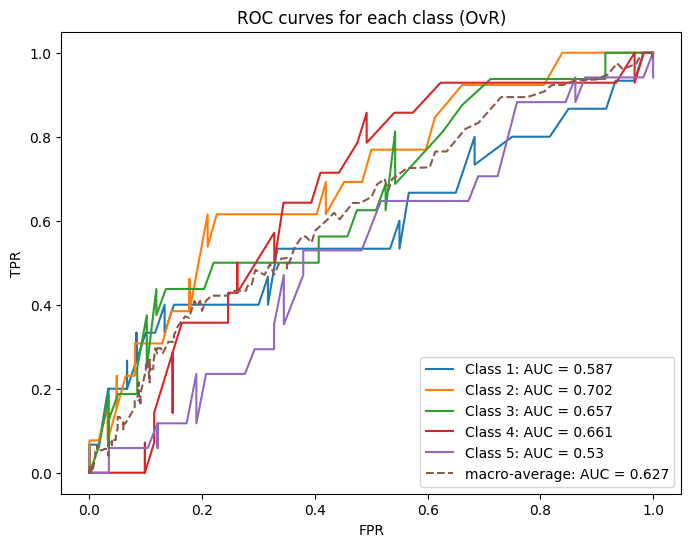

AUC:  0.6274043757056761


In [14]:
# or gather each value individually

conf_matrix = metrics.confusion_matrix()
print("Confusion matrix:\n",conf_matrix)

acc = metrics.balanced_accuracy()
prec = metrics.precision()
sens = metrics.sensitivity()
F1 = metrics.F1score()


print(f"Accuracy: {acc}\nprecision: {prec}\nrecall: {sens}\nF1-score: {F1}")

auc = metrics.AUC(graphical=True, threshold_step=0.005)
print("AUC: ", auc)

## Part 2: Save and Load model

If you trained a model that you think is worth maintaining, you can save it as a pickle file by using:

In [15]:
model_cnn.save_model(path = "dummy_model.pickle")

Model saved: dummy_model.pickle


The loading is done using the load_model(path) function within saann.models.

The following is an example of how to load it.

Be aware that: if the model you saved used GPU acceleration, when loading, GPU acceleration needs to be enabled!

CNN model loaded
List of directories:  ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Resizing images to (98 x 98)
Processing image # 100
Processing image # 200
Dataset already clean.
Dataset has been shuffled.
Dataset is ready and has been split into Train (length = 175) and Test (length = 75) sets.
Confusion matrix:
 [[6 4 4 1 1]
 [2 4 2 5 3]
 [2 1 9 2 2]
 [1 1 0 7 1]
 [2 2 6 1 6]]

Class                 1      2      3      4      5 
------------------
Balanced accuracy | 0.628, 0.557, 0.680, 0.781, 0.616
Precision         | 0.462, 0.333, 0.429, 0.437, 0.462
Recall            | 0.375, 0.250, 0.562, 0.700, 0.353
Specificity       | 0.881, 0.864, 0.797, 0.862, 0.879
F1-score          | 0.414, 0.286, 0.486, 0.538, 0.400
------------------
Macro F1: 0.425
Weighted F1: 0.415
MCC: 0.057

AUC: 0.726


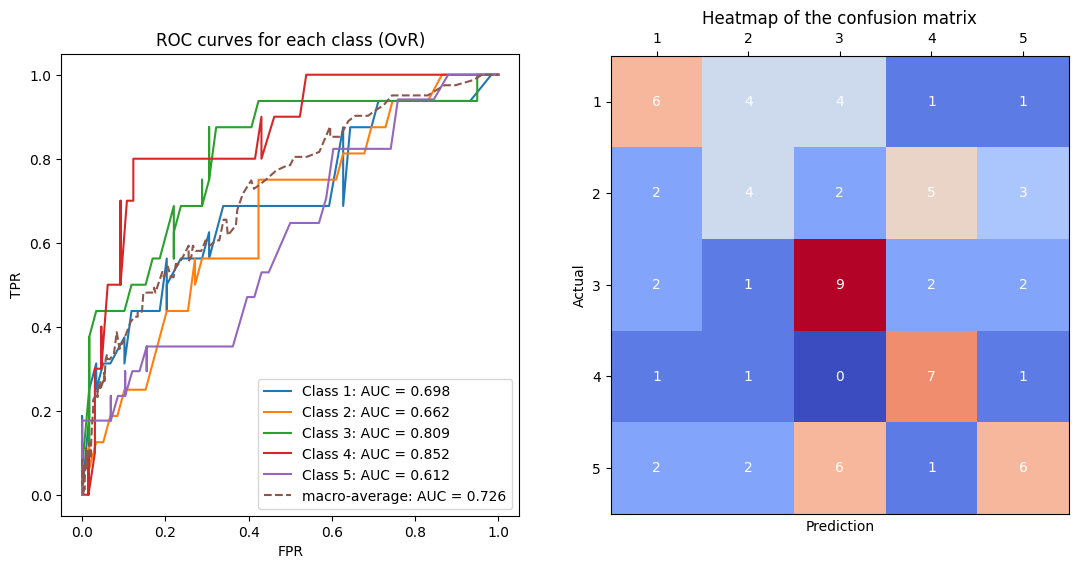

In [ ]:
import saann.models as snm
from saann.processing import ImageProcessing

# Load model
model = snm.load_model(path = "dummy_model.pickle")

# Process images - size MUST be the same as the one used for training. 
IP = ImageProcessing(images_path=path_flowers)
X_train, X_test, y_train, y_test, list_classes = IP.ready_dataset(size=98, amount= 50, shuffle = True, remove_resized=True, split_test_percentage=0.3)

# Make predictions
y_pred = model.predict(X_test=X_test)
# Initialize the Metrics class
metrics = Metrics(y_pred=y_pred, y_test=y_test)
# Get a fast report of the model's metrics
metrics.report()

## Note

The purpose of this notebook is to show how to use the API, not about the quality of the model!

Increasing the image pool, number of filters (for the convolution block) and epochs will increase the quality but increase also the computation time - such is no the final purpose of this example.


## Lincences

All images in this archive are licensed under the Creative Commons By-Attribution License, available at:
https://creativecommons.org/licenses/by/2.0/

The photographers are listed below:

daisy/7568630428_8cf0fc16ff_n.jpg CC-BY by A Guy Taking Pictures - https://www.flickr.com/photos/80901381@N04/7568630428/
daisy/7410356270_9dff4d0e2e_n.jpg CC-BY by martinak15 - https://www.flickr.com/photos/martinaphotography/7410356270/
daisy/4286053334_a75541f20b_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/4286053334/
daisy/10770585085_4742b9dac3_n.jpg CC-BY by Thangaraj Kumaravel - https://www.flickr.com/photos/kumaravel/10770585085/
daisy/8759177308_951790e00d_m.jpg CC-BY by Marina del Castell - https://www.flickr.com/photos/marinadelcastell/8759177308/
daisy/4131565290_0585c4dd5a_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/4131565290/
daisy/3504430338_77d6a7fab4_n.jpg CC-BY by Dhilung Kirat - https://www.flickr.com/photos/dhilung/3504430338/
daisy/3084924076_4d5c5711af_m.jpg CC-BY by Bùi Linh Ngân - https://www.flickr.com/photos/linhngan/3084924076/
daisy/2642408410_61545fdc83_n.jpg CC-BY by Dennis Jarvis - https://www.flickr.com/photos/archer10/2642408410/
daisy/8710109684_e2c5ef6aeb_n.jpg CC-BY by Jon Bunting - https://www.flickr.com/photos/84744710@N06/8710109684/
daisy/2612704455_efce1c2144_m.jpg CC-BY by Swaminathan - https://www.flickr.com/photos/araswami/2612704455/
daisy/8021540573_c56cf9070d_n.jpg CC-BY by martinak15 - https://www.flickr.com/photos/martinaphotography/8021540573/
daisy/4413849849_b8d2f3bcf1_n.jpg CC-BY by Neal Fowler - https://www.flickr.com/photos/31878512@N06/4413849849/
daisy/3999978867_c67c79597f_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3999978867/
daisy/3703643767_dee82cdef9_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3703643767/
daisy/16527403771_2391f137c4_n.jpg CC-BY by Ramón Portellano - https://www.flickr.com/photos/118276383@N05/16527403771/
daisy/16020253176_60f2a6a5ca_n.jpg CC-BY by Ramón Portellano - https://www.flickr.com/photos/118276383@N05/16020253176/
daisy/16482676953_5296227d40_n.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/16482676953/
daisy/14264136211_9531fbc144.jpg CC-BY by Hernán Piñera - https://www.flickr.com/photos/hernanpc/14264136211/
daisy/12348343085_d4c396e5b5_m.jpg CC-BY by Chrismatos ♥90% OFF, sorry - https://www.flickr.com/photos/chrismatos/12348343085/
daisy/11891885265_ccefec7284_n.jpg CC-BY by Hernán Piñera - https://www.flickr.com/photos/hernanpc/11891885265/
daisy/11870378973_2ec1919f12.jpg CC-BY by Marilena Marchese - https://www.flickr.com/photos/marilenamarchese_photography/11870378973/
daisy/9346508462_f0af3163f4.jpg CC-BY by Harry Thomas Photography - https://www.flickr.com/photos/waffles10/9346508462/
daisy/6323721068_3d3394af6d_n.jpg CC-BY by Sergio Tudela Romero - https://www.flickr.com/photos/ectopsyche/6323721068/
daisy/9244082319_b1f7e2d8b0_n.jpg CC-BY by Jérémy Lelièvre - https://www.flickr.com/photos/jrmllvr/9244082319/
daisy/5561775629_a2b709b3a4_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/5561775629/
daisy/4683997791_56e7d3c03c_n.jpg CC-BY by Nana B Agyei - https://www.flickr.com/photos/nanagyei/4683997791/
daisy/4581199679_867652c3f1_n.jpg CC-BY by Neal Fowler - https://www.flickr.com/photos/31878512@N06/4581199679/
daisy/4540555191_3254dc4608_n.jpg CC-BY by Neal Fowler - https://www.flickr.com/photos/31878512@N06/4540555191/
daisy/4407065098_ef25f1ccac_n.jpg CC-BY by Neal Fowler - https://www.flickr.com/photos/31878512@N06/4407065098/
daisy/3957488431_52a447c0e8_m.jpg CC-BY by Tristan Martin - https://www.flickr.com/photos/mukumbura/3957488431/
daisy/3699235066_fc09a02dfe_m.jpg CC-BY by Neal Fowler - https://www.flickr.com/photos/31878512@N06/3699235066/
daisy/813445367_187ecf080a_n.jpg CC-BY by Michel Filion - https://www.flickr.com/photos/mike9alive/813445367/
daisy/162362896_99c7d851c8_n.jpg CC-BY by Micky** - https://www.flickr.com/photos/emzee/162362896/
daisy/8127252886_96558c23d1.jpg CC-BY by Johan Neven - https://www.flickr.com/photos/enneafive/8127252886/
daisy/5679288570_b4c52e76d5.jpg CC-BY by Nana B Agyei - https://www.flickr.com/photos/nanagyei/5679288570/
daisy/15760811380_4d686c892b_n.jpg CC-BY by Ramón Portellano - https://www.flickr.com/photos/118276383@N05/15760811380/
daisy/15760153042_a2a90e9da5_m.jpg CC-BY by Mathias Erhart - https://www.flickr.com/photos/mathias-erhart/15760153042/
daisy/5135131051_102d4878ca_n.jpg CC-BY by Moyan Brenn - https://www.flickr.com/photos/aigle_dore/5135131051/
daisy/2551708158_1f10e81e11.jpg CC-BY by kim - https://www.flickr.com/photos/kimrose/2551708158/
daisy/7669550908_bc5a11276f_n.jpg CC-BY by Nana B Agyei - https://www.flickr.com/photos/nanagyei/7669550908/
daisy/5811226952_4650ed70ae_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/5811226952/
daisy/2482982436_a2145359e0_n.jpg CC-BY by Sabrina Campagna - https://www.flickr.com/photos/mar1lyn84/2482982436/
daisy/3975010332_3209f9f447_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3975010332/
daisy/3468498624_d082f99e98.jpg CC-BY by Lali Masriera - https://www.flickr.com/photos/visualpanic/3468498624/
daisy/3627678863_557552c879_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3627678863/
daisy/14564545365_1f1d267bf1_n.jpg CC-BY by anne arnould - https://www.flickr.com/photos/anne_arnould/14564545365/
daisy/10712722853_5632165b04.jpg CC-BY by Jan Fidler - https://www.flickr.com/photos/hypotekyfidler/10712722853/
daisy/22873310415_3a5674ec10_m.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/22873310415/
daisy/3533954656_79156c8473.jpg CC-BY by photophilde - https://www.flickr.com/photos/photophilde/3533954656/
daisy/7191221492_610035de7c_m.jpg CC-BY by Nana B Agyei - https://www.flickr.com/photos/nanagyei/7191221492/
daisy/3386988684_bc5a66005e.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/3386988684/
daisy/2877860110_a842f8b14a_m.jpg CC-BY by Kathy Kimpel - https://www.flickr.com/photos/kkimpel/2877860110/
daisy/506493250_e9ca42fe3d.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/506493250/
daisy/18711159980_11d3bd5042.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/18711159980/
daisy/2838487505_6c3b48efa5_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/2838487505/
daisy/5869147563_66fb88119d.jpg CC-BY by Craig Pennington - https://www.flickr.com/photos/krow10/5869147563/
daisy/15853110333_229c439e7f.jpg CC-BY by Enrico Strocchi - https://www.flickr.com/photos/strocchi/15853110333/
daisy/2812442552_3eed5fb9f2_m.jpg CC-BY by Tony Fischer - https://www.flickr.com/photos/tonythemisfit/2812442552/
daisy/2641979584_2b21c3fe29_m.jpg CC-BY by Sabrina Campagna - https://www.flickr.com/photos/mar1lyn84/2641979584/
daisy/16492248512_61a57dfec1_m.jpg CC-BY by Ramón Portellano - https://www.flickr.com/photos/118276383@N05/16492248512/
daisy/9242705328_eee8402a8d.jpg CC-BY by minniemouseaunt - https://www.flickr.com/photos/minniemouseaunt/9242705328/
daisy/4563059851_45a9d21a75.jpg CC-BY by Thomas Abbs - https://www.flickr.com/photos/tabsinthe/4563059851/
daisy/18203367608_07a04e98a4_n.jpg CC-BY by A_Peach - https://www.flickr.com/photos/a_peach/18203367608/
daisy/9180706736_092d43088c.jpg CC-BY by Steve Wilson - over 7 million views Thanks !! - https://www.flickr.com/photos/pokerbrit/9180706736/
daisy/2365428551_39f83f10bf_n.jpg CC-BY by Robert Parviainen - https://www.flickr.com/photos/rtv/2365428551/
daisy/5626895440_97a0ec04c2_n.jpg CC-BY by Moyan Brenn - https://www.flickr.com/photos/aigle_dore/5626895440/
daisy/2498632196_e47a472d5a.jpg CC-BY by Swaminathan - https://www.flickr.com/photos/araswami/2498632196/
daisy/154332674_453cea64f4.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/154332674/
daisy/3494265422_9dba8f2191_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/3494265422/
daisy/2646438199_b309cffd65_n.jpg CC-BY by Sean McGrath - https://www.flickr.com/photos/mcgraths/2646438199/
daisy/3900172983_9312fdf39c_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3900172983/
daisy/15784493690_b1858cdb2b_n.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/15784493690/
daisy/14399435971_ea5868c792.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/14399435971/
daisy/253426762_9793d43fcd.jpg CC-BY by Alexandre Duret-Lutz - https://www.flickr.com/photos/gadl/253426762/
daisy/14569895116_32f0dcb0f9.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/14569895116/
daisy/676120388_28f03069c3.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/676120388/
daisy/14716799982_ed6d626a66.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/14716799982/
daisy/16737503507_431768a927.jpg CC-BY by Mariya Prokopyuk - https://www.flickr.com/photos/mariyaprokopyuk/16737503507/
daisy/5608389827_a42a46f760.jpg CC-BY by ruben alexander - https://www.flickr.com/photos/the-wanderers-eye/5608389827/
daisy/459931395_24bf6531fe_n.jpg CC-BY by sophie & cie - https://www.flickr.com/photos/biscotte/459931395/
daisy/16161045294_70c76ce846_n.jpg CC-BY by stanze - https://www.flickr.com/photos/stanzebla/16161045294/
daisy/18195689904_46619b7e16_n.jpg CC-BY by Anantha V - https://www.flickr.com/photos/anantnv/18195689904/
daisy/2641151167_3bf1349606_m.jpg CC-BY by Sabrina Campagna - https://www.flickr.com/photos/mar1lyn84/2641151167/
daisy/483886997_27ee798327.jpg CC-BY by Meena Kadri - https://www.flickr.com/photos/meanestindian/483886997/
daisy/4565255237_9ba29c4d4e_n.jpg CC-BY by Felipe Gabaldón - https://www.flickr.com/photos/felipe_gabaldon/4565255237/
daisy/14591326135_930703dbed_m.jpg CC-BY by swong95765 - https://www.flickr.com/photos/29487672@N07/14591326135/
daisy/5794839_200acd910c_n.jpg CC-BY by John D. - https://www.flickr.com/photos/macrophile/5794839/
daisy/1031799732_e7f4008c03.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/1031799732/
daisy/14554906452_35f066ffe9_n.jpg CC-BY by SurFeRGiRL30 - https://www.flickr.com/photos/surfergirl30/14554906452/
daisy/3506866918_61dd5fc53b_n.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/3506866918/
daisy/18442919723_d1251d3e14_n.jpg CC-BY by stanze - https://www.flickr.com/photos/stanzebla/18442919723/
daisy/18635898912_eb8e058ef0.jpg CC-BY by Darling Starlings Flying the Nest - https://www.flickr.com/photos/magicattic88/18635898912/
daisy/3326037909_b5ae370722_n.jpg CC-BY by Luke Andrew Scowen - https://www.flickr.com/photos/lukeas09/3326037909/
daisy/17249393016_093e915012_n.jpg CC-BY by Enrico Strocchi - https://www.flickr.com/photos/strocchi/17249393016/
daisy/13491959645_2cd9df44d6_n.jpg CC-BY by Gabriela Fab - https://www.flickr.com/photos/59882593@N05/13491959645/
daisy/2581171297_b0a249b92b_n.jpg CC-BY by Paul Stevenson - https://www.flickr.com/photos/pss/2581171297/
daisy/105806915_a9c13e2106_n.jpg CC-BY by Paul Reynolds - https://www.flickr.com/photos/bigtallguy/105806915/
daisy/3463313493_9497aa47e5_n.jpg CC-BY by Cristina L. F. - https://www.flickr.com/photos/xanetia/3463313493/
daisy/11642632_1e7627a2cc.jpg CC-BY by Nick Coombe - https://www.flickr.com/photos/thearchive/11642632/
daisy/12891819633_e4c82b51e8.jpg CC-BY by Pavlina Jane - https://www.flickr.com/photos/pavlinajane/12891819633/
daisy/8706810197_17b6c1f1e7.jpg CC-BY by Markus Grossalber - https://www.flickr.com/photos/tschiae/8706810197/
daisy/2539552964_921cf645ba_n.jpg CC-BY by Evonne - https://www.flickr.com/photos/evoo73/2539552964/
daisy/2561352120_7961d8263f.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/2561352120/
daisy/162362897_1d21b70621_m.jpg CC-BY by Micky** - https://www.flickr.com/photos/emzee/162362897/
daisy/10559679065_50d2b16f6d.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/10559679065/
daisy/8616684075_71923bb771_n.jpg CC-BY by jacinta lluch valero - https://www.flickr.com/photos/70626035@N00/8616684075/
daisy/20329326505_a777c71cc2.jpg CC-BY by robin_ottawa (I'm on the phone!) - https://www.flickr.com/photos/91030602@N06/20329326505/
daisy/147068564_32bb4350cc.jpg CC-BY by _Zeta_ - https://www.flickr.com/photos/beppezizzi/147068564/
daisy/9158041313_7a6a102f7a_n.jpg CC-BY by Loren Kerns - https://www.flickr.com/photos/lorenkerns/9158041313/
daisy/13953307149_f8de6a768c_m.jpg CC-BY by Calvin Smith - https://www.flickr.com/photos/calvinsmith/13953307149/
daisy/14021430525_e06baf93a9.jpg CC-BY by Juanedc - https://www.flickr.com/photos/juanedc/14021430525/
daisy/5700781400_65761f3fce.jpg CC-BY by Tom Bech - https://www.flickr.com/photos/viatorius/5700781400/
daisy/8619103877_d8c82c5f34_n.jpg CC-BY by John Flannery - https://www.flickr.com/photos/drphotomoto/8619103877/
daisy/3337536080_1db19964fe.jpg CC-BY by Dennis Wong - https://www.flickr.com/photos/denniswong/3337536080/
daisy/5547758_eea9edfd54_n.jpg CC-BY by John D. - https://www.flickr.com/photos/macrophile/5547758/
daisy/19865728236_a62f8f445b_n.jpg CC-BY by A_Peach - https://www.flickr.com/photos/a_peach/19865728236/
daisy/2573240560_ff7ffdd449.jpg CC-BY by Balaji Photography - 3,000,000 Views and Growing - https://www.flickr.com/photos/bbalaji/2573240560/
daisy/21805938544_bf6bb0e4bc.jpg CC-BY by judy dean - https://www.flickr.com/photos/peterscherub/21805938544/
daisy/14507818175_05219b051c_m.jpg CC-BY by Trevor King - https://www.flickr.com/photos/trevor-king/14507818175/
daisy/7790614422_4557928ab9_n.jpg CC-BY by jacinta lluch valero - https://www.flickr.com/photos/70626035@N00/7790614422/
daisy/2408024540_37f0be7cc0_n.jpg CC-BY by Sabrina Campagna - https://www.flickr.com/photos/mar1lyn84/2408024540/
daisy/16819071290_471d99e166_m.jpg CC-BY by Evan Kilgore - https://www.flickr.com/photos/ejkimages/16819071290/
daisy/512177035_70afc925c8.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/512177035/
daisy/3628485766_4ff937954a_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3628485766/
daisy/134372449_0f7166d96c_n.jpg CC-BY by sophie & cie - https://www.flickr.com/photos/biscotte/134372449/
daisy/7633425046_8293e3d0e9_m.jpg CC-BY by torbakhopper - https://www.flickr.com/photos/gazeronly/7633425046/
daisy/14707111433_cce08ee007.jpg CC-BY by Holly Zade - https://www.flickr.com/photos/hzader/14707111433/
daisy/4561871220_47f420ca59_m.jpg CC-BY by Robert Snache - Spirithands.net - https://www.flickr.com/photos/rbs/4561871220/
daisy/8696022686_1f8d62c5cb_m.jpg CC-BY by anne arnould - https://www.flickr.com/photos/anne_arnould/8696022686/
daisy/3310644753_5607eb96a4_m.jpg CC-BY by MAMJODH - https://www.flickr.com/photos/mamjodh/3310644753/
daisy/9529916092_de70623523_n.jpg CC-BY by jacinta lluch valero - https://www.flickr.com/photos/70626035@N00/9529916092/
daisy/4724713781_d169f98a35.jpg CC-BY by Matt Clark - https://www.flickr.com/photos/jointhedots/4724713781/
daisy/413815348_764ae83088.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/413815348/
daisy/9286947622_4822f4fc21.jpg CC-BY by Pavlina Jane - https://www.flickr.com/photos/pavlinajane/9286947622/
daisy/22244161124_53e457bb66_n.jpg CC-BY by judy dean - https://www.flickr.com/photos/peterscherub/22244161124/
daisy/435283392_72e4c5b5d6_m.jpg CC-BY by Alexander Boden - https://www.flickr.com/photos/bogenfreund/435283392/
daisy/13826249325_f61cb15f86_n.jpg CC-BY by Sandra - https://www.flickr.com/photos/sandrasworld/13826249325/
daisy/4897587985_f9293ea1ed.jpg CC-BY by Luke Gray - https://www.flickr.com/photos/lukewes/4897587985/
daisy/14471433500_cdaa22e3ea_m.jpg CC-BY by Mark Engelbrecht - https://www.flickr.com/photos/menegue/14471433500/
daisy/705422469_ffa28c566d.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/705422469/
daisy/3337643329_accc9b5426.jpg CC-BY by Jarmel - https://www.flickr.com/photos/jamalarmel/3337643329/
daisy/14674743211_f68b13f6d9.jpg CC-BY by 2benny - https://www.flickr.com/photos/benedettobuono/14674743211/
daisy/20182559506_40a112f762.jpg CC-BY by René Oosterveen - https://www.flickr.com/photos/missilehugger/20182559506/
daisy/8694909523_3ca25d449d_n.jpg CC-BY by anne arnould - https://www.flickr.com/photos/anne_arnould/8694909523/
daisy/19280272025_57de24e940_m.jpg CC-BY by Lyndsay Esson - https://www.flickr.com/photos/98198789@N02/19280272025/
daisy/3717746329_53f515c6a6_m.jpg CC-BY by photogramma1 - https://www.flickr.com/photos/photogramma1/3717746329/
daisy/9054268881_19792c5203_n.jpg CC-BY by Zoltán Vörös - https://www.flickr.com/photos/94941635@N07/9054268881/
daisy/433037739_6a030e5912.jpg CC-BY by MapHobbit - https://www.flickr.com/photos/trazomfreak/433037739/
daisy/9595857626_979c45e5bf_n.jpg CC-BY by Se Re - https://www.flickr.com/photos/96310508@N06/9595857626/
daisy/1355787476_32e9f2a30b.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/1355787476/
daisy/5714327423_50af0cffe9.jpg CC-BY by Forest Wander - https://www.flickr.com/photos/forestwander-nature-pictures/5714327423/
daisy/14088053307_1a13a0bf91_n.jpg CC-BY by DncnH - https://www.flickr.com/photos/duncanh1/14088053307/
daisy/14087947408_9779257411_n.jpg CC-BY by DncnH - https://www.flickr.com/photos/duncanh1/14087947408/
daisy/1314069875_da8dc023c6_m.jpg CC-BY by alfaneque - https://www.flickr.com/photos/76623287@N00/1314069875/
daisy/20948886919_cac7844f34_n.jpg CC-BY by jimmcsweeney - https://www.flickr.com/photos/73118846@N04/20948886919/
daisy/5981645737_29eceac291_m.jpg CC-BY by Alias 0591 - https://www.flickr.com/photos/renemensen/5981645737/
daisy/5973491805_556bba93cc.jpg CC-BY by Catrin Austin - https://www.flickr.com/photos/catrinaustin/5973491805/
daisy/169371301_d9b91a2a42.jpg CC-BY by Srinivasan G - https://www.flickr.com/photos/srinig/169371301/
daisy/2351206867_084e57bd97.jpg CC-BY by Parée - https://www.flickr.com/photos/pareeerica/2351206867/
daisy/2513618768_ff7c004796_m.jpg CC-BY by quapan - https://www.flickr.com/photos/hinkelstone/2513618768/
daisy/5795159787_ebb51a5e75.jpg CC-BY by Jin Choi - https://www.flickr.com/photos/openuser/5795159787/
daisy/2632216904_274aa17433.jpg CC-BY by Ian Muttoo - https://www.flickr.com/photos/imuttoo/2632216904/
daisy/506348009_9ecff8b6ef.jpg CC-BY by Peter Pearson - https://www.flickr.com/photos/peterpearson/506348009/
daisy/506018088_4f7a15a7c5_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/506018088/
daisy/2567033807_8e918c53d8_n.jpg CC-BY by Tomi Tapio K - https://www.flickr.com/photos/tomitapio/2567033807/
daisy/5673551_01d1ea993e_n.jpg CC-BY by Teo - https://www.flickr.com/photos/teo/5673551/
daisy/16833748795_b681b2839f_n.jpg CC-BY by Dave Walker - https://www.flickr.com/photos/walkinfo/16833748795/
daisy/15306268004_4680ba95e1.jpg CC-BY by Will - https://www.flickr.com/photos/bongonian/15306268004/
daisy/1299501272_59d9da5510_n.jpg CC-BY by dion gillard - https://www.flickr.com/photos/diongillard/1299501272/
daisy/20580471306_ab5a011b15_n.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/20580471306/
daisy/14613443462_d4ed356201.jpg CC-BY by Kai Lehmann [thank you for 530k views :-D] - https://www.flickr.com/photos/kailehmann/14613443462/
daisy/7288989324_c25d9febbf.jpg CC-BY by AvidlyAbide - https://www.flickr.com/photos/avidlyabide/7288989324/
daisy/754296579_30a9ae018c_n.jpg CC-BY by Ryan Poplin - https://www.flickr.com/photos/poplinre/754296579/
daisy/1344985627_c3115e2d71_n.jpg CC-BY by dion gillard - https://www.flickr.com/photos/diongillard/1344985627/
daisy/20703737132_179560d0fb.jpg CC-BY by Tom D - https://www.flickr.com/photos/113551735@N04/20703737132/
daisy/9299302012_958c70564c_n.jpg CC-BY by Sheila Sund - https://www.flickr.com/photos/sheila_sund/9299302012/
daisy/519880292_7a3a6c6b69.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/519880292/
daisy/4278442064_a5a598524b_m.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/4278442064/
daisy/8348621545_8f02b82662_n.jpg CC-BY by Thangaraj Kumaravel - https://www.flickr.com/photos/kumaravel/8348621545/
daisy/5876455546_32049e5585.jpg CC-BY by Kris Mouser-Brown - https://www.flickr.com/photos/kris_mouser-brown/5876455546/
daisy/4814515275_6e25a6c18f.jpg CC-BY by Liam Moloney - https://www.flickr.com/photos/tir_na_nog/4814515275/
daisy/3611577717_f3a7a8c416_n.jpg CC-BY by Jerry - https://www.flickr.com/photos/way2go/3611577717/
daisy/7629784968_b953501902_n.jpg CC-BY by Smile Always :-) - https://www.flickr.com/photos/subzeroconsciousness/7629784968/
daisy/4281102584_c548a69b81_m.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/4281102584/
daisy/3695826945_9f374e8a00_m.jpg CC-BY by Finding Josephine - https://www.flickr.com/photos/34233222@N05/3695826945/
daisy/4432271543_01c56ca3a9.jpg CC-BY by Peter Heilmann - https://www.flickr.com/photos/peter_heilmann/4432271543/
daisy/20289938802_e16fa9f23d.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/20289938802/
daisy/5014137563_d03eb0ed75_n.jpg CC-BY by Spencer Wright - https://www.flickr.com/photos/spencer77/5014137563/
daisy/4276898893_609d11db8b.jpg CC-BY by el Buho nº30 - https://www.flickr.com/photos/buho30/4276898893/
daisy/18582579815_4c6637e9ff_m.jpg CC-BY by Nicholas A. Tonelli - https://www.flickr.com/photos/nicholas_t/18582579815/
daisy/488202750_c420cbce61.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/488202750/
daisy/17027891179_3edc08f4f6.jpg CC-BY by Gido - https://www.flickr.com/photos/103499652@N04/17027891179/
daisy/5722473541_ffac1ae67e_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/5722473541/
daisy/4865691548_00319261b8.jpg CC-BY by Les Haines - https://www.flickr.com/photos/leshaines123/4865691548/
daisy/3598615130_578ed30e5f.jpg CC-BY by Andrea - https://www.flickr.com/photos/spettacolopuro/3598615130/
daisy/2901376034_cdb4bac26b_m.jpg CC-BY by Kyknoord - https://www.flickr.com/photos/kyknoord/2901376034/
daisy/1354396826_2868631432_m.jpg CC-BY by Liam Moloney - https://www.flickr.com/photos/tir_na_nog/1354396826/
daisy/20685027271_0e7306e7c1_n.jpg CC-BY by Warren Rachele - https://www.flickr.com/photos/wrachele/20685027271/
daisy/4697206799_19dd2a3193_m.jpg CC-BY by Kate Ter Haar - https://www.flickr.com/photos/katerha/4697206799/
daisy/3025866885_22fb0b61c6_n.jpg CC-BY by kim - https://www.flickr.com/photos/kimrose/3025866885/
daisy/16291797949_a1b1b7c2bd_n.jpg CC-BY by Heather - https://www.flickr.com/photos/58754750@N08/16291797949/
daisy/12193032636_b50ae7db35_n.jpg CC-BY by Kai Lehmann [thank you for 530k views :-D] - https://www.flickr.com/photos/kailehmann/12193032636/
daisy/8887005939_b19e8305ee.jpg CC-BY by Luke Gray - https://www.flickr.com/photos/lukewes/8887005939/
daisy/525271784_013ddccd1b_m.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/525271784/
daisy/5574421625_61b1f49b3f_m.jpg CC-BY by OliBac - https://www.flickr.com/photos/olibac/5574421625/
daisy/4613992315_143ccc2a10_m.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/4613992315/
daisy/2509545845_99e79cb8a2_n.jpg CC-BY by Swaminathan - https://www.flickr.com/photos/araswami/2509545845/
daisy/2001380507_19488ff96a_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2001380507/
daisy/3711892138_b8c953fdc1_z.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3711892138/
daisy/1392131677_116ec04751.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/1392131677/
daisy/13583238844_573df2de8e_m.jpg CC-BY by Irene Grassi - https://www.flickr.com/photos/sun_sand_sea/13583238844/
daisy/14333681205_a07c9f1752_m.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/14333681205/
daisy/13901930939_a7733c03f0_n.jpg CC-BY by Stiller Beobachter - https://www.flickr.com/photos/a-herzog/13901930939/
daisy/799964360_7e07a227ea_n.jpg CC-BY by Ryan Poplin - https://www.flickr.com/photos/poplinre/799964360/
daisy/2889325612_f2fc403ff0_m.jpg CC-BY by Stephanie - https://www.flickr.com/photos/simply_steff/2889325612/
daisy/3637428148_a1dcccafa9_n.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3637428148/
daisy/4820415253_15bc3b6833_n.jpg CC-BY by Vincent_AF - https://www.flickr.com/photos/archetypefotografie/4820415253/
daisy/4333085242_bbeb3e2841_m.jpg CC-BY by James Russell - https://www.flickr.com/photos/theholyllama/4333085242/
daisy/2617111535_54c2ac8462.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/2617111535/
daisy/5883162120_dc7274af76_n.jpg CC-BY by Michael Gil - https://www.flickr.com/photos/msvg/5883162120/
daisy/14073784469_ffb12f3387_n.jpg CC-BY by Bridget Leyendecker - https://www.flickr.com/photos/b_leyende/14073784469/
daisy/3773181799_5def396456.jpg CC-BY by betancourt - https://www.flickr.com/photos/thebetancourts/3773181799/
daisy/9515186037_3be48fe68f.jpg CC-BY by Hoffnungsschimmer - https://www.flickr.com/photos/hoffnungsschimmer/9515186037/
daisy/8983779970_9d3a6a3bf2_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/8983779970/
daisy/19544831049_0d738d4872_m.jpg CC-BY by Paul VanDerWerf - https://www.flickr.com/photos/pavdw/19544831049/
daisy/8742143296_fed9fa007c.jpg CC-BY by Vicente Villamón - https://www.flickr.com/photos/villamon/8742143296/
daisy/4065883015_4bb6010cb7_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/4065883015/
daisy/9489270024_1b05f08492_m.jpg CC-BY by Sheila Sund - https://www.flickr.com/photos/sheila_sund/9489270024/
daisy/9593034725_0062f0d24e_n.jpg CC-BY by Se Re - https://www.flickr.com/photos/96310508@N06/9593034725/
daisy/8071646795_2fdc89ab7a_n.jpg CC-BY by Alias 0591 - https://www.flickr.com/photos/renemensen/8071646795/
daisy/2488902131_3417698611_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2488902131/
daisy/9611923744_013b29e4da_n.jpg CC-BY by Se Re - https://www.flickr.com/photos/96310508@N06/9611923744/
daisy/4434592930_6610d51fca_m.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/4434592930/
daisy/3764116502_f394428ee0_n.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3764116502/
daisy/3445110406_0c1616d2e3_n.jpg CC-BY by GCSE Jack - https://www.flickr.com/photos/123photography2008/3445110406/
daisy/3750250718_eb61146c5f.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3750250718/
daisy/520752848_4b87fb91a4.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/520752848/
daisy/99306615_739eb94b9e_m.jpg CC-BY by sjoe - https://www.flickr.com/photos/sjoe/99306615/
daisy/3275951182_d27921af97_n.jpg CC-BY by Swaminathan - https://www.flickr.com/photos/araswami/3275951182/
daisy/2520369272_1dcdb5a892_m.jpg CC-BY by Swaminathan - https://www.flickr.com/photos/araswami/2520369272/
daisy/1140299375_3aa7024466.jpg CC-BY by Sean McGrath - https://www.flickr.com/photos/mcgraths/1140299375/
daisy/2213954589_c7da4b1486.jpg CC-BY by Ben Alford - https://www.flickr.com/photos/benalford/2213954589/
daisy/15029936576_8d6f96c72c_n.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/15029936576/
daisy/4861391074_c3e122dab0_m.jpg CC-BY by Lorraine# - https://www.flickr.com/photos/lorraineemmans/4861391074/
daisy/14245834619_153624f836.jpg CC-BY by taymtaym - https://www.flickr.com/photos/taymtaym/14245834619/
daisy/8489463746_a9839bf7e4.jpg CC-BY by Christopher Kray - https://www.flickr.com/photos/85208536@N02/8489463746/
daisy/3098641292_76c908ba1f_n.jpg CC-BY by Geert Orye - https://www.flickr.com/photos/11741671@N03/3098641292/
daisy/1374193928_a52320eafa.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/1374193928/
daisy/144603918_b9de002f60_m.jpg CC-BY by Andreas. - https://www.flickr.com/photos/124330160/144603918/
daisy/4654579740_6671a53627_m.jpg CC-BY by xlibber - https://www.flickr.com/photos/xlibber/4654579740/
daisy/9350942387_5b1d043c26_n.jpg CC-BY by EMILIE RHAUPP - https://www.flickr.com/photos/emraps/9350942387/
daisy/4694734757_5c563d38dd_n.jpg CC-BY by Sean McMenemy - https://www.flickr.com/photos/seanfx/4694734757/
daisy/172882635_4cc7b86731_m.jpg CC-BY by Rosana Prada - https://www.flickr.com/photos/zanastardust/172882635/
daisy/8882282142_9be2524d38_m.jpg CC-BY by Zoltán Vörös - https://www.flickr.com/photos/94941635@N07/8882282142/
daisy/5623010186_796ca8d29a.jpg CC-BY by Luke Gray - https://www.flickr.com/photos/lukewes/5623010186/
daisy/3704306975_75b74497d8.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3704306975/
daisy/14372713423_61e2daae88.jpg CC-BY by Mats Hagwall - https://www.flickr.com/photos/hagwall/14372713423/
daisy/4993492878_11fd4f5d12.jpg CC-BY by syauqee mohamad - https://www.flickr.com/photos/syauqee/4993492878/
daisy/1286274236_1d7ac84efb_n.jpg CC-BY by dion gillard - https://www.flickr.com/photos/diongillard/1286274236/
daisy/5602738326_97121e007d_n.jpg CC-BY by Peter O'Connor aka anemoneprojectors - https://www.flickr.com/photos/anemoneprojectors/5602738326/
daisy/4668543441_79040ca329_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/4668543441/
daisy/19834392829_7d697871f6.jpg CC-BY by Stratosfeer - https://www.flickr.com/photos/stratosfeer/19834392829/
daisy/14485782498_fb342ec301.jpg CC-BY by Kate Ter Haar - https://www.flickr.com/photos/katerha/14485782498/
daisy/8063844363_db3f4dea85.jpg CC-BY by Alias 0591 - https://www.flickr.com/photos/renemensen/8063844363/
daisy/5626784099_b36dd3fb11_n.jpg CC-BY by Catherine Singleton - https://www.flickr.com/photos/s1ng0/5626784099/
daisy/2479956481_8d1a9699be_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2479956481/
daisy/7199968650_72afc16d31_m.jpg CC-BY by Barbara Eckstein - https://www.flickr.com/photos/beckstei/7199968650/
daisy/2862944799_45bc8e7302.jpg CC-BY by Cliff - https://www.flickr.com/photos/nostri-imago/2862944799/
daisy/10140303196_b88d3d6cec.jpg CC-BY by Irene Grassi - https://www.flickr.com/photos/sun_sand_sea/10140303196/
daisy/9321854387_5f77c926cb_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/9321854387/
daisy/5796562389_ae43c83317_m.jpg CC-BY by orestART - https://www.flickr.com/photos/orestart/5796562389/
daisy/4301689054_20519e5b68.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/4301689054/
daisy/302782756_d35cb3e468.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/302782756/
daisy/153210866_03cc9f2f36.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/153210866/
daisy/11439894966_dca877f0cd.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/11439894966/
daisy/6864242336_0d12713fe5_n.jpg CC-BY by torbakhopper - https://www.flickr.com/photos/gazeronly/6864242336/
daisy/5948835387_5a98d39eff_m.jpg CC-BY by mikeyskatie - https://www.flickr.com/photos/mikeyskatie/5948835387/
daisy/9204730092_a7f2182347.jpg CC-BY by William Wootton - https://www.flickr.com/photos/wwootton/9204730092/
daisy/9496209717_25a6ebdab6_m.jpg CC-BY by khrawlings - https://www.flickr.com/photos/khrawlings/9496209717/
daisy/5632774792_0fa33d17eb_n.jpg CC-BY by Martin de Witte - https://www.flickr.com/photos/martindew/5632774792/
daisy/3711723108_65247a3170.jpg CC-BY by Jerry - https://www.flickr.com/photos/way2go/3711723108/
daisy/14307766919_fac3c37a6b_m.jpg CC-BY by r. nial bradshaw - https://www.flickr.com/photos/zionfiction/14307766919/
daisy/452854574_59492f119a_m.jpg CC-BY by Mathias Erhart - https://www.flickr.com/photos/mathias-erhart/452854574/
daisy/4837182901_69a6cc782b_n.jpg CC-BY by Peter O'Connor aka anemoneprojectors - https://www.flickr.com/photos/anemoneprojectors/4837182901/
daisy/18901817451_43e2b45f6c.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/18901817451/
daisy/4534460263_8e9611db3c_n.jpg CC-BY by Paulo Valdivieso - https://www.flickr.com/photos/p_valdivieso/4534460263/
daisy/517054463_036db655a1_m.jpg CC-BY by MapHobbit - https://www.flickr.com/photos/trazomfreak/517054463/
daisy/144076848_57e1d662e3_m.jpg CC-BY by Paul Reynolds - https://www.flickr.com/photos/bigtallguy/144076848/
daisy/3661613900_b15ca1d35d_m.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3661613900/
daisy/2621723097_736febb4a4_n.jpg CC-BY by Michael Gil - https://www.flickr.com/photos/msvg/2621723097/
daisy/2087343668_ef4fb95787_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2087343668/
daisy/5110107234_12ddc0206b_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5110107234/
daisy/19653086178_28156b7ce4_m.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/19653086178/
daisy/5435521200_92029bbe2b_n.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/5435521200/
daisy/54377391_15648e8d18.jpg CC-BY by Felipe Venâncio - https://www.flickr.com/photos/aeon/54377391/
daisy/7749368884_1fc58c67ff_n.jpg CC-BY by AvidlyAbide - https://www.flickr.com/photos/avidlyabide/7749368884/
daisy/476856232_7c35952f40_n.jpg CC-BY by sunshinecity - https://www.flickr.com/photos/sunshinecity/476856232/
daisy/13977181862_f8237b6b52.jpg CC-BY by Mike Krüger - https://www.flickr.com/photos/memoryleakx/13977181862/
daisy/8120563761_ed5620664f_m.jpg CC-BY by torbakhopper - https://www.flickr.com/photos/gazeronly/8120563761/
daisy/4851353993_2cbbbd1040_n.jpg CC-BY by Michael Gil - https://www.flickr.com/photos/msvg/4851353993/
daisy/4610018126_21f438d2dc_m.jpg CC-BY by Umberto Salvagnin - https://www.flickr.com/photos/kaibara/4610018126/
daisy/2607132536_d95198e619_n.jpg CC-BY by Carmen Escobar Carrio - https://www.flickr.com/photos/caracolquiscol/2607132536/
daisy/15207766_fc2f1d692c_n.jpg CC-BY by John D. - https://www.flickr.com/photos/macrophile/15207766/
daisy/799952628_bf836677fa_n.jpg CC-BY by Ryan Poplin - https://www.flickr.com/photos/poplinre/799952628/
daisy/14402451388_56545a374a_n.jpg CC-BY by Jamiecat * - https://www.flickr.com/photos/jamiecat/14402451388/
daisy/8932490012_cc08e690ba_n.jpg CC-BY by TANAKA Juuyoh (田中十洋) - https://www.flickr.com/photos/tanaka_juuyoh/8932490012/
daisy/4890424315_6a59696357_n.jpg CC-BY by Liam Moloney - https://www.flickr.com/photos/tir_na_nog/4890424315/
daisy/534547364_3f6b7279d2_n.jpg CC-BY by Emily - https://www.flickr.com/photos/7738710@N06/534547364/
daisy/14350958832_29bdd3a254.jpg CC-BY by Mats Hagwall - https://www.flickr.com/photos/hagwall/14350958832/
daisy/9175280426_40ecc395b8_m.jpg CC-BY by Donnie Nunley - https://www.flickr.com/photos/dbnunley/9175280426/
daisy/14332947164_9b13513c71_m.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/14332947164/
daisy/4544110929_a7de65d65f_n.jpg CC-BY by Ingrid Taylar - https://www.flickr.com/photos/taylar/4544110929/
daisy/498159452_b71afd65ba.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/498159452/
daisy/433837534_1dbf798b73.jpg CC-BY by daniel zimmel - https://www.flickr.com/photos/devnull/433837534/
daisy/172967318_c596d082cc.jpg CC-BY by David Goehring - https://www.flickr.com/photos/carbonnyc/172967318/
daisy/8964198962_6d8593b533.jpg CC-BY by Pete - https://www.flickr.com/photos/comedynose/8964198962/
daisy/5512287917_9f5d3f0f98_n.jpg CC-BY by Vicente Villamón - https://www.flickr.com/photos/villamon/5512287917/
daisy/4694730335_2553e77aa5_z.jpg CC-BY by Sean McMenemy - https://www.flickr.com/photos/seanfx/4694730335/
daisy/18679421522_3be9879e32.jpg CC-BY by Michael Reilly - https://www.flickr.com/photos/mreillyphoto/18679421522/
daisy/5577555349_2e8490259b.jpg CC-BY by Maribelle71 - https://www.flickr.com/photos/42912005@N07/5577555349/
daisy/2511306240_9047015f2d_n.jpg CC-BY by Jon Bragg - https://www.flickr.com/photos/festivefrog/2511306240/
daisy/517054467_d82d323c33_m.jpg CC-BY by MapHobbit - https://www.flickr.com/photos/trazomfreak/517054467/
daisy/7924174040_444d5bbb8a.jpg CC-BY by godo godaj - https://www.flickr.com/photos/13832715@N05/7924174040/
daisy/9146733107_98b15d3892_m.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/9146733107/
daisy/3285641623_da0e47f49a.jpg CC-BY by Gilles Gonthier - https://www.flickr.com/photos/gillesgonthier/3285641623/
daisy/2454280137_e1637536ae_n.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/2454280137/
daisy/5434742166_35773eba57_m.jpg CC-BY by Sinead Friel - https://www.flickr.com/photos/sineadfriel/5434742166/
daisy/175106495_53ebdef092_n.jpg CC-BY by Robert Meeks - https://www.flickr.com/photos/mahfrot/175106495/
daisy/21402054779_759366efb0_n.jpg CC-BY by David Elliott - https://www.flickr.com/photos/drelliott0net/21402054779/
daisy/15813862117_dedcd1c56f_m.jpg CC-BY by Eric.Ray - https://www.flickr.com/photos/12707238@N00/15813862117/
daisy/14163875973_467224aaf5_m.jpg CC-BY by Margaux-Marguerite Duquesnoy - https://www.flickr.com/photos/124559226@N08/14163875973/
daisy/9922116524_ab4a2533fe_n.jpg CC-BY by Kelly Sikkema - https://www.flickr.com/photos/95072945@N05/9922116524/
daisy/3780380240_ef9ec1b737_m.jpg CC-BY by Ilena Gecan - https://www.flickr.com/photos/hach3/3780380240/
daisy/10172567486_2748826a8b.jpg CC-BY by Sarah Zucca - https://www.flickr.com/photos/livetocreate_photography/10172567486/
daisy/107592979_aaa9cdfe78_m.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/107592979/
daisy/11834945233_a53b7a92ac_m.jpg CC-BY by Randen Pederson - https://www.flickr.com/photos/chefranden/11834945233/
daisy/8709535323_a6bea3e43f.jpg CC-BY by Je suis Eli - https://www.flickr.com/photos/55578839@N04/8709535323/
daisy/2627815904_919373e7f5.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/2627815904/
daisy/530738000_4df7e4786b.jpg CC-BY by Jon Gos - https://www.flickr.com/photos/jongos/530738000/
daisy/10841136265_af473efc60.jpg CC-BY by Pavlina Jane - https://www.flickr.com/photos/pavlinajane/10841136265/
daisy/9467543719_c4800becbb_m.jpg CC-BY by Randen Pederson - https://www.flickr.com/photos/chefranden/9467543719/
daisy/3440366251_5b9bdf27c9_m.jpg CC-BY by catlovers - https://www.flickr.com/photos/90389546@N00/3440366251/
daisy/1342002397_9503c97b49.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/1342002397/
daisy/102841525_bd6628ae3c.jpg CC-BY by Randen Pederson - https://www.flickr.com/photos/chefranden/102841525/
daisy/16401288243_36112bd52f_m.jpg CC-BY by Thomas Kohler - https://www.flickr.com/photos/mecklenburg/16401288243/
daisy/7630517248_98fb8bee1f_n.jpg CC-BY by William Wootton - https://www.flickr.com/photos/wwootton/7630517248/
daisy/5809489674_5659b3ae5d_n.jpg CC-BY by Patrick Standish - https://www.flickr.com/photos/patrickstandish/5809489674/
daisy/4482623536_b9fb5ae41f_n.jpg CC-BY by Yolanda - https://www.flickr.com/photos/fuzzyyol/4482623536/
daisy/19178753159_a471bf4b6b.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/19178753159/
daisy/19177263840_6a316ea639.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/19177263840/
daisy/3704305945_a80e60e2f6_m.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3704305945/
daisy/2666572212_2caca8de9f_n.jpg CC-BY by Shayan (USA) - https://www.flickr.com/photos/ssanyal/2666572212/
daisy/2599662355_7782218c83.jpg CC-BY by Rosana Prada - https://www.flickr.com/photos/zanastardust/2599662355/
daisy/3758221664_b19116d61f.jpg CC-BY by Stephanie Kroos - https://www.flickr.com/photos/stephi2006/3758221664/
daisy/3117644024_1cbb59a509_n.jpg CC-BY by John Flannery - https://www.flickr.com/photos/drphotomoto/3117644024/
daisy/14866200659_6462c723cb_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/14866200659/
daisy/2473825306_62fd5f8785_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2473825306/
daisy/14600779226_7bbc288d40_m.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/14600779226/
daisy/367020749_3c9a652d75.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/367020749/
daisy/14219214466_3ca6104eae_m.jpg CC-BY by Allison Brown - https://www.flickr.com/photos/behinddreaming/14219214466/
daisy/14114116486_0bb6649bc1_m.jpg CC-BY by Margaux-Marguerite Duquesnoy - https://www.flickr.com/photos/124559226@N08/14114116486/
daisy/3713290261_8a66de23ab.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3713290261/
daisy/521762040_f26f2e08dd.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/521762040/
daisy/14167543177_cd36b54ac6_n.jpg CC-BY by Rubén Díaz Caviedes - https://www.flickr.com/photos/59268554@N05/14167543177/
daisy/14167534527_781ceb1b7a_n.jpg CC-BY by Rubén Díaz Caviedes - https://www.flickr.com/photos/59268554@N05/14167534527/
daisy/6210664514_f1d211217a.jpg CC-BY by Sarah Joy - https://www.flickr.com/photos/joybot/6210664514/
daisy/6207492986_0ff91f3296.jpg CC-BY by Sarah Joy - https://www.flickr.com/photos/joybot/6207492986/
daisy/5434914569_e9b982fde0_n.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/5434914569/
daisy/7358085448_b317d11cd5.jpg CC-BY by Garry Knight - https://www.flickr.com/photos/garryknight/7358085448/
daisy/4440480869_632ce6aff3_n.jpg CC-BY by Maja Dumat - https://www.flickr.com/photos/blumenbiene/4440480869/
daisy/2579018590_74359dcf1a_m.jpg CC-BY by Rob Nunn - https://www.flickr.com/photos/scalespeeder/2579018590/
daisy/8719756744_34a5a83976_n.jpg CC-BY by Scott Ellis - https://www.flickr.com/photos/vsellis/8719756744/
daisy/6299498346_b9774b6500.jpg CC-BY by Sarah Joy - https://www.flickr.com/photos/joybot/6299498346/
daisy/5853276960_d08f90fff6.jpg CC-BY by Garry Knight - https://www.flickr.com/photos/garryknight/5853276960/
daisy/5435513198_90ce39f1aa_n.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/5435513198/
daisy/5110105726_53eb7a93be_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5110105726/
daisy/4085794721_7cd88e0a6c_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/4085794721/
daisy/3861452393_14d2f95157_m.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3861452393/
daisy/2057816617_18448093d0_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2057816617/
daisy/1955336401_fbb206d6ef_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/1955336401/
daisy/512477177_d9004cbcf1_n.jpg CC-BY by Madalena Pestana - https://www.flickr.com/photos/madalena_pestana/512477177/
daisy/495098110_3a4bb30042_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/495098110/
daisy/14551098743_2842e7a004_n.jpg CC-BY by Sarah Zucca - https://www.flickr.com/photos/livetocreate_photography/14551098743/
daisy/10172636503_21bededa75_n.jpg CC-BY by Sarah Zucca - https://www.flickr.com/photos/livetocreate_photography/10172636503/
daisy/8085329197_41d53a21e2_n.jpg CC-BY by Alias 0591 - https://www.flickr.com/photos/renemensen/8085329197/
daisy/4268817944_cdbdb226ae.jpg CC-BY by Horia Varlan - https://www.flickr.com/photos/horiavarlan/4268817944/
daisy/2713919471_301fcc941f.jpg CC-BY by Peter Heilmann - https://www.flickr.com/photos/peter_heilmann/2713919471/
daisy/18400014056_2e4c601ed5.jpg CC-BY by Tanya Hart - https://www.flickr.com/photos/arripay/18400014056/
daisy/14221836990_90374e6b34.jpg CC-BY by DaveBleasdale - https://www.flickr.com/photos/sidelong/14221836990/
daisy/6884975451_c74f445d69_m.jpg CC-BY by jasleen_kaur - https://www.flickr.com/photos/jasleen_kaur/6884975451/
daisy/5110109540_beed4ed162_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5110109540/
daisy/5109508979_68e3530791_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5109508979/
daisy/4858518329_7563eb0baa_m.jpg CC-BY by Franco Folini - https://www.flickr.com/photos/livenature/4858518329/
daisy/7335886184_d06a83f640.jpg CC-BY by cea + - https://www.flickr.com/photos/centralasian/7335886184/
daisy/5874818796_3efbb8769d.jpg CC-BY by Rodney Campbell - https://www.flickr.com/photos/acrylicartist/5874818796/
daisy/2619413565_61a6cd3ac9_m.jpg CC-BY by fauxto_digit - https://www.flickr.com/photos/fauxto_dkp/2619413565/
daisy/5435522104_1d6a61b431_n.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/5435522104/
daisy/2908212142_5437fa67ff_n.jpg CC-BY by Robert Snache - Spirithands.net - https://www.flickr.com/photos/rbs/2908212142/
daisy/7320089276_87b544e341.jpg CC-BY by Steve Webster - https://www.flickr.com/photos/spjwebster/7320089276/
daisy/7227973870_806d9d3e42_n.jpg CC-BY by Markus Grossalber - https://www.flickr.com/photos/tschiae/7227973870/
daisy/5434901893_4550be3f84_m.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/5434901893/
daisy/5769217520_c90efc3c93_m.jpg CC-BY by crayonmonkey - https://www.flickr.com/photos/crayonmonkey/5769217520/
daisy/1396526833_fb867165be_n.jpg CC-BY by dion gillard - https://www.flickr.com/photos/diongillard/1396526833/
daisy/1285423653_18926dc2c8_n.jpg CC-BY by dion gillard - https://www.flickr.com/photos/diongillard/1285423653/
daisy/14907815010_bff495449f.jpg CC-BY by Kirt Edblom - https://www.flickr.com/photos/27190564@N02/14907815010/
daisy/10555826524_423eb8bf71_n.jpg CC-BY by Maja Dumat - https://www.flickr.com/photos/blumenbiene/10555826524/
daisy/5665838969_fe217988b9_m.jpg CC-BY by Maja Dumat - https://www.flickr.com/photos/blumenbiene/5665838969/
daisy/5665834973_76bd6c6523_m.jpg CC-BY by Maja Dumat - https://www.flickr.com/photos/blumenbiene/5665834973/
daisy/5110110938_9da91455c4_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5110110938/
daisy/2561371688_c80a4fe957_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/2561371688/
daisy/525780443_bba812c26a_m.jpg CC-BY by Matt Dodd - https://www.flickr.com/photos/matt_dodd/525780443/
daisy/158869618_f1a6704236_n.jpg CC-BY by Alan L - https://www.flickr.com/photos/35188692@N00/158869618/
daisy/21626652132_97e1318bb8_m.jpg CC-BY by christine.gleason - https://www.flickr.com/photos/cmgxvolley/21626652132/
daisy/7538403124_f2fc48750a.jpg CC-BY by Porsche Brosseau - https://www.flickr.com/photos/porsche-linn/7538403124/
daisy/3450822975_7e77d67636_n.jpg CC-BY by jolly_janner - https://www.flickr.com/photos/34527231@N06/3450822975/
daisy/14330343061_99478302d4_m.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/14330343061/
daisy/6136947177_47ff445eb4_n.jpg CC-BY by Mary Hutchison - https://www.flickr.com/photos/mary_hutchison/6136947177/
daisy/6054952060_c88612f3c5_n.jpg CC-BY by jon oropeza - https://www.flickr.com/photos/jonoropeza/6054952060/
daisy/5885826924_38fdc6bcaa_n.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/5885826924/
daisy/5434913005_409c1e8b56_n.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/5434913005/
daisy/4222584034_8964cbd3de.jpg CC-BY by David Goehring - https://www.flickr.com/photos/carbonnyc/4222584034/
daisy/3474942718_c418dae6f1.jpg CC-BY by Clare Bell - https://www.flickr.com/photos/southpaw2305/3474942718/
daisy/1150395827_6f94a5c6e4_n.jpg CC-BY by Brian Glanz - https://www.flickr.com/photos/brianglanz/1150395827/
daisy/267148092_4bb874af58.jpg CC-BY by Zixii - https://www.flickr.com/photos/zixi/267148092/
daisy/5794835_d15905c7c8_n.jpg CC-BY by John D. - https://www.flickr.com/photos/macrophile/5794835/
daisy/14221848160_7f0a37c395.jpg CC-BY by DaveBleasdale - https://www.flickr.com/photos/sidelong/14221848160/
daisy/11023272144_fce94401f2_m.jpg CC-BY by Andrew Moore - https://www.flickr.com/photos/andryn2006/11023272144/
daisy/5054771689_00dd40b971_n.jpg CC-BY by Thomas Quine - https://www.flickr.com/photos/quinet/5054771689/
daisy/4258408909_b7cc92741c_m.jpg CC-BY by Scott.Symonds - https://www.flickr.com/photos/spacemunkie/4258408909/
daisy/18474740346_ffdaa18032.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/18474740346/
daisy/3456403987_5bd5fa6ece_n.jpg CC-BY by Owen's - https://www.flickr.com/photos/owenbushell/3456403987/
daisy/391364010_4b0942d400_m.jpg CC-BY by Anathea Utley - https://www.flickr.com/photos/anathea/391364010/
daisy/299129811_d6ebda9970.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/299129811/
daisy/8740807508_0587f5b7b7.jpg CC-BY by Jeffry - https://www.flickr.com/photos/dreamsailors/8740807508/
daisy/6095817094_3a5b1d793d.jpg CC-BY by n.karim - https://www.flickr.com/photos/nkarim/6095817094/
daisy/181007802_7cab5ee78e_n.jpg CC-BY by Vladimer Shioshvili - https://www.flickr.com/photos/vshioshvili/181007802/
daisy/43474673_7bb4465a86.jpg CC-BY by Mr.Mx. - https://www.flickr.com/photos/mrmx/43474673/
daisy/18622672908_eab6dc9140_n.jpg CC-BY by Adrian Snood - https://www.flickr.com/photos/adriansnood/18622672908/
daisy/11023277956_8980d53169_m.jpg CC-BY by Andrew Moore - https://www.flickr.com/photos/andryn2006/11023277956/
daisy/11023214096_b5b39fab08.jpg CC-BY by Andrew Moore - https://www.flickr.com/photos/andryn2006/11023214096/
daisy/3625257860_33efeef614_m.jpg CC-BY by photogramma1 - https://www.flickr.com/photos/photogramma1/3625257860/
daisy/2476937534_21b285aa46_n.jpg CC-BY by Randi Hausken - https://www.flickr.com/photos/randihausken/2476937534/
daisy/8938566373_d129e7af75.jpg CC-BY by daBinsi - https://www.flickr.com/photos/dabinsi/8938566373/
daisy/6299910262_336309ffa5_n.jpg CC-BY by Christian Holland - https://www.flickr.com/photos/christianholland/6299910262/
daisy/5739768868_9f982684f9_n.jpg CC-BY by Barcelona · Three Looks - https://www.flickr.com/photos/vive-recordando/5739768868/
daisy/3356112863_75da8bca2c_m.jpg CC-BY by Phil Sellens - https://www.flickr.com/photos/phil_sellens/3356112863/
daisy/12701063955_4840594ea6_n.jpg CC-BY by Lisa Risager - https://www.flickr.com/photos/risager/12701063955/
daisy/10994032453_ac7f8d9e2e.jpg CC-BY by South African Tourism - https://www.flickr.com/photos/south-african-tourism/10994032453/
daisy/5881907044_92a85a05c8_n.jpg CC-BY by Iain A Wanless - https://www.flickr.com/photos/reemul/5881907044/
daisy/9161647994_e39b65cb9c_n.jpg CC-BY by James Mann - https://www.flickr.com/photos/james_mann/9161647994/
daisy/7377004908_5bc0cde347_n.jpg CC-BY by cooper.gary - https://www.flickr.com/photos/gtcooper25/7377004908/
daisy/4657354814_f368762c53_m.jpg CC-BY by tonp - https://www.flickr.com/photos/tonp/4657354814/
daisy/176375506_201859bb92_m.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/176375506/
daisy/754248840_95092de274.jpg CC-BY by bill lapp - https://www.flickr.com/photos/blapp/754248840/
daisy/171972704_389cf7a953.jpg CC-BY by zaphodsotherhead - https://www.flickr.com/photos/zaphodsotherhead/171972704/
daisy/14354051035_1037b30421_n.jpg CC-BY by Rubén Díaz Caviedes - https://www.flickr.com/photos/59268554@N05/14354051035/
daisy/10466558316_a7198b87e2.jpg CC-BY by South African Tourism - https://www.flickr.com/photos/south-african-tourism/10466558316/
daisy/9120905231_329598304e.jpg CC-BY by Eric Kilby - https://www.flickr.com/photos/ekilby/9120905231/
daisy/7630520686_e3a61ac763.jpg CC-BY by William Wootton - https://www.flickr.com/photos/wwootton/7630520686/
daisy/7630511450_02d3292e90.jpg CC-BY by William Wootton - https://www.flickr.com/photos/wwootton/7630511450/
daisy/3848258315_ed2fde4fb4.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/3848258315/
daisy/174131220_c853df1287.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/174131220/
daisy/17101762155_2577a28395.jpg CC-BY by Audrey B. - https://www.flickr.com/photos/hetkabinet/17101762155/
daisy/16025261368_911703a536_n.jpg CC-BY by katrien berckmoes - https://www.flickr.com/photos/129891689@N02/16025261368/
daisy/6950173662_5e9473003e_n.jpg CC-BY by Markus Grossalber - https://www.flickr.com/photos/tschiae/6950173662/
daisy/10993818044_4c19b86c82.jpg CC-BY by South African Tourism - https://www.flickr.com/photos/south-african-tourism/10993818044/
daisy/10993710036_2033222c91.jpg CC-BY by South African Tourism - https://www.flickr.com/photos/south-african-tourism/10993710036/
daisy/144099102_bf63a41e4f_n.jpg CC-BY by Stéfan - https://www.flickr.com/photos/st3f4n/144099102/
daisy/14272874304_47c0a46f5a.jpg CC-BY by DncnH - https://www.flickr.com/photos/duncanh1/14272874304/
daisy/8681746439_d6beeefbf9.jpg CC-BY by Mark Engelbrecht - https://www.flickr.com/photos/menegue/8681746439/
daisy/14621687774_ec52811acd_n.jpg CC-BY by Javcon117* - https://www.flickr.com/photos/javcon117/14621687774/
daisy/10466290366_cc72e33532.jpg CC-BY by South African Tourism - https://www.flickr.com/photos/south-african-tourism/10466290366/
daisy/5944315415_2be8abeb2f_m.jpg CC-BY by Tom Hart - https://www.flickr.com/photos/thart2009/5944315415/
daisy/909609509_a05ccb8127.jpg CC-BY by Kathy - https://www.flickr.com/photos/rittysdigiez/909609509/
daisy/15327813273_06cdf42210.jpg CC-BY by KFCSpike - https://www.flickr.com/photos/fb_brillyunt/15327813273/
daisy/4727955343_0bb23ac4ae.jpg CC-BY by Jim, the Photographer - https://www.flickr.com/photos/jcapaldi/4727955343/
daisy/4117918318_3c8935289b_m.jpg CC-BY by David J - https://www.flickr.com/photos/sebilden/4117918318/
daisy/18023717391_e2c9089e10.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/18023717391/
daisy/16360180712_b72695928c_n.jpg CC-BY by Melanie Lazarow - https://www.flickr.com/photos/mlazarow/16360180712/
daisy/14421389519_d5fd353eb4.jpg CC-BY by Gido - https://www.flickr.com/photos/103499652@N04/14421389519/
daisy/10555815624_dc211569b0.jpg CC-BY by Maja Dumat - https://www.flickr.com/photos/blumenbiene/10555815624/
daisy/10555749515_13a12a026e.jpg CC-BY by Maja Dumat - https://www.flickr.com/photos/blumenbiene/10555749515/
daisy/7133935763_82b17c8e1b_n.jpg CC-BY by frankieleon - https://www.flickr.com/photos/armydre2008/7133935763/
daisy/4229503616_9b8a42123c_n.jpg CC-BY by Alejandro Hernandez. - https://www.flickr.com/photos/ace_0f_magic/4229503616/
daisy/2578695910_5ab8ee17c1_n.jpg CC-BY by Elizabeth Ellis - https://www.flickr.com/photos/izzie_whizzie/2578695910/
daisy/2480569557_f4e1f0dcb8_n.jpg CC-BY by Fabien Dany - https://www.flickr.com/photos/fabdany/2480569557/
daisy/20773528301_008fcbc5a1_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/20773528301/
daisy/19975899671_ebc42b7865_n.jpg CC-BY by NY State IPM Program  at Cornell University - https://www.flickr.com/photos/99758165@N06/19975899671/
daisy/14147016029_8d3cf2414e.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/14147016029/
daisy/10437754174_22ec990b77_m.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/10437754174/
daisy/7066602021_2647457985_m.jpg CC-BY by torbakhopper - https://www.flickr.com/photos/gazeronly/7066602021/
daisy/2454280135_ac3aa75cdc_n.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/2454280135/
daisy/450128527_fd35742d44.jpg CC-BY by Luz Adriana Villa - https://www.flickr.com/photos/luchilu/450128527/
daisy/391364011_5beaaa1ae2_m.jpg CC-BY by Anathea Utley - https://www.flickr.com/photos/anathea/391364011/
daisy/17357636476_1953c07aa4_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/17357636476/
daisy/2538504987_fe524b92a8_n.jpg CC-BY by xlibber - https://www.flickr.com/photos/xlibber/2538504987/
daisy/4538877108_3c793f7987_m.jpg CC-BY by Barbara M. - https://www.flickr.com/photos/cannnela/4538877108/
daisy/2536529152_33ef3ee078_n.jpg CC-BY by Balaji Photography - 3,000,000 Views and Growing - https://www.flickr.com/photos/bbalaji/2536529152/
daisy/2331133004_582772d58f_m.jpg CC-BY by Sabrina Campagna - https://www.flickr.com/photos/mar1lyn84/2331133004/
daisy/20619292635_9857a12d54.jpg CC-BY by kismihok - https://www.flickr.com/photos/kismihok/20619292635/
daisy/3639009391_0f910681b7.jpg CC-BY by Stewart Black - https://www.flickr.com/photos/s2ublack/3639009391/
daisy/2635314490_e12d3b0f36_m.jpg CC-BY by Dylan Parker - https://www.flickr.com/photos/antidigerati/2635314490/
daisy/301964511_fab84ea1c1.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/301964511/
daisy/12585131704_0f64b17059_m.jpg CC-BY by www.tOrange.biz Valdemar Fishmen - https://www.flickr.com/photos/torange-biz/12585131704/
daisy/2521408074_e6f86daf21_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2521408074/
daisy/6596277835_9f86da54bb.jpg CC-BY by JFXie - https://www.flickr.com/photos/jfxie/6596277835/
daisy/5765646947_82e95a9cc9_n.jpg CC-BY by Alberto Cabrera - https://www.flickr.com/photos/jacd74/5765646947/
daisy/5693459303_e61d9a9533.jpg CC-BY by Maret Hosemann - https://www.flickr.com/photos/maret1983/5693459303/
daisy/5133243796_44de429de5_m.jpg CC-BY by seymoursimages - https://www.flickr.com/photos/seymoursimages/5133243796/
daisy/3379332157_04724f6480.jpg CC-BY by xlibber - https://www.flickr.com/photos/xlibber/3379332157/
daisy/2514748602_343d4727c0_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2514748602/
daisy/835750256_3f91a147ef_n.jpg CC-BY by cdanna2003 - https://www.flickr.com/photos/49565454@N00/835750256/
daisy/14816364517_2423021484_m.jpg CC-BY by Daniela - https://www.flickr.com/photos/daniela_naturephotography/14816364517/
daisy/8718637649_87a0d85190_n.jpg CC-BY by Scott Ellis - https://www.flickr.com/photos/vsellis/8718637649/
daisy/4753134939_8e87649db6.jpg CC-BY by Rex Hammock - https://www.flickr.com/photos/rexblog/4753134939/
daisy/10437929963_bc13eebe0c.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/10437929963/
daisy/5058708968_8bdcd29e63_n.jpg CC-BY by zenjazzygeek - https://www.flickr.com/photos/zenjazzygeek/5058708968/
daisy/286875003_f7c0e1882d.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/286875003/
daisy/9094631844_1a6abca29e.jpg CC-BY by Korona Lacasse - https://www.flickr.com/photos/korona4reel/9094631844/
daisy/8094774544_35465c1c64.jpg CC-BY by Tokkes - https://www.flickr.com/photos/tom_sieprath/8094774544/
daisy/6529588249_d9cbe68aab_n.jpg CC-BY by daryl_mitchell - https://www.flickr.com/photos/daryl_mitchell/6529588249/
daisy/6089825811_80f253fbe1.jpg CC-BY by AntoineMeu - https://www.flickr.com/photos/lqpin/6089825811/
daisy/4318007511_e9f4311936_n.jpg CC-BY by Inga Munsinger Cotton - https://www.flickr.com/photos/ingamun/4318007511/
daisy/3483303007_42e3f90da7.jpg CC-BY by Clare Bell - https://www.flickr.com/photos/southpaw2305/3483303007/
daisy/422094774_28acc69a8b_n.jpg CC-BY by Andreas. - https://www.flickr.com/photos/124330160/422094774/
daisy/100080576_f52e8ee070_n.jpg CC-BY by mario - https://www.flickr.com/photos/64738468@N00/100080576/
daisy/3546455114_cd2dea5e02.jpg CC-BY by David Merrett - https://www.flickr.com/photos/davehamster/3546455114/
daisy/2077865117_9ed85191ae_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/2077865117/
daisy/7454630692_ab2d67dd18_m.jpg CC-BY by Jacob  Martin - https://www.flickr.com/photos/76938626@N07/7454630692/
daisy/3336704121_cfeb67a7d7.jpg CC-BY by Dennis Wong - https://www.flickr.com/photos/denniswong/3336704121/
daisy/9345273630_af3550031d.jpg CC-BY by Johan Hansson - https://www.flickr.com/photos/plastanka/9345273630/
daisy/10437770546_8bb6f7bdd3_m.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/10437770546/
daisy/10391248763_1d16681106_n.jpg CC-BY by Petras Gagilas - https://www.flickr.com/photos/gagilas/10391248763/
daisy/5087720485_c0914fb623.jpg CC-BY by Danielle Henry - https://www.flickr.com/photos/waterandglass/5087720485/
daisy/2556503265_63ae6b9e0e_m.jpg CC-BY by thegoinggreenboutique - https://www.flickr.com/photos/thegoinggreenboutique/2556503265/
daisy/2349640101_212c275aa7.jpg CC-BY by Tokkes - https://www.flickr.com/photos/tom_sieprath/2349640101/
daisy/4792826628_aa5e5a9804_n.jpg CC-BY by Danielle Henry - https://www.flickr.com/photos/waterandglass/4792826628/
daisy/3633489595_a037a9b7a4_m.jpg CC-BY by jimmy brown - https://www.flickr.com/photos/jimmybrown/3633489595/
daisy/19019544592_b64469bf84_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/19019544592/
daisy/8382667241_0f046cecdb_n.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/8382667241/
daisy/6910811638_aa6f17df23.jpg CC-BY by Luke Gray - https://www.flickr.com/photos/lukewes/6910811638/
daisy/6480809771_b1e14c5cc2_m.jpg CC-BY by Sid Mosdell - https://www.flickr.com/photos/sidm/6480809771/
daisy/14921511479_7b0a647795.jpg CC-BY by Charly Meunier - https://www.flickr.com/photos/126640879@N07/14921511479/
daisy/11124324295_503f3a0804.jpg CC-BY by Martin Cooper - https://www.flickr.com/photos/m-a-r-t-i-n/11124324295/
daisy/4923279674_e7f8e70794_n.jpg CC-BY by Steve Snodgrass - https://www.flickr.com/photos/stevensnodgrass/4923279674/
daisy/695778683_890c46ebac.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/695778683/
daisy/14523675369_97c31d0b5b.jpg CC-BY by Mitchell Haindfield - https://www.flickr.com/photos/40441865@N08/14523675369/
daisy/6480809573_76a0074b69_n.jpg CC-BY by Sid Mosdell - https://www.flickr.com/photos/sidm/6480809573/
daisy/2611119198_9d46b94392.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2611119198/
daisy/1656856503_447e5b0f03.jpg CC-BY by alfaneque - https://www.flickr.com/photos/76623287@N00/1656856503/
daisy/446484749_4044affcaf_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/446484749/
daisy/3963330924_6c6a3fa7be_n.jpg CC-BY by jason woodland - https://www.flickr.com/photos/biffyboy/3963330924/
daisy/3640845041_80a92c4205_n.jpg CC-BY by Luke Andrew Scowen - https://www.flickr.com/photos/lukeas09/3640845041/
daisy/3475870145_685a19116d.jpg CC-BY by Fabrizio Sciami - https://www.flickr.com/photos/_fabrizio_/3475870145/
daisy/2590291468_2635d3e4e0_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2590291468/
daisy/8008258043_5457dd254b_n.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/8008258043/
daisy/6776075110_1ea7a09dd4_n.jpg CC-BY by Rose Braverman - https://www.flickr.com/photos/rose_braverman/6776075110/
daisy/2481823240_eab0d86921.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/2481823240/
daisy/1265350143_6e2b276ec9.jpg CC-BY by Jon Bragg - https://www.flickr.com/photos/festivefrog/1265350143/
daisy/721595842_bacd80a6ac.jpg CC-BY by Sean McGrath - https://www.flickr.com/photos/mcgraths/721595842/
daisy/9310226774_d1b8f5d9c9.jpg CC-BY by Johan Hansson - https://www.flickr.com/photos/plastanka/9310226774/
daisy/163978992_8128b49d3e_n.jpg CC-BY by Todd Petit - https://www.flickr.com/photos/starmist1/163978992/
daisy/12601254324_3cb62c254a_m.jpg CC-BY by Louise McLaren - https://www.flickr.com/photos/louisephotography/12601254324/
daisy/4669117051_ce61e91b76.jpg CC-BY by tudor-rose - https://www.flickr.com/photos/smileeyface1993/4669117051/
daisy/510844526_858b8fe4db.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/510844526/
daisy/8383753520_8391dd80ee_m.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/8383753520/
daisy/3939135368_0af5c4982a_n.jpg CC-BY by Peter O'Connor aka anemoneprojectors - https://www.flickr.com/photos/anemoneprojectors/3939135368/
daisy/3720632920_93cf1cc7f3_m.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/3720632920/
daisy/8709110478_60d12efcd4_n.jpg CC-BY by Andrew - https://www.flickr.com/photos/bud_um_tiss/8709110478/
daisy/5586977262_6b24412805_n.jpg CC-BY by Jeroen Moes - https://www.flickr.com/photos/jeroenmoes/5586977262/
daisy/1392946544_115acbb2d9.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/1392946544/
daisy/23095658544_7226386954_n.jpg CC-BY by brianjobson - https://www.flickr.com/photos/brianjobson/23095658544/
daisy/5459481183_18d2d49e44_m.jpg CC-BY by Kurtis Garbutt - https://www.flickr.com/photos/kjgarbutt/5459481183/
daisy/4598422221_b37313a3e3_n.jpg CC-BY by Daisyree Bakker - https://www.flickr.com/photos/27875041@N02/4598422221/
daisy/2828733818_1c1ed0089d_n.jpg CC-BY by Gilles Gonthier - https://www.flickr.com/photos/gillesgonthier/2828733818/
daisy/2346726545_2ebce2b2a6.jpg CC-BY by Tokkes - https://www.flickr.com/photos/tom_sieprath/2346726545/
daisy/305160642_53cde0f44f.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/305160642/
daisy/294451721_5106537b34.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/294451721/
daisy/21652746_cc379e0eea_m.jpg CC-BY by Retinafunk - https://www.flickr.com/photos/retinafunk/21652746/
daisy/16121105382_b96251e506_m.jpg CC-BY by Naomi Stoodley - https://www.flickr.com/photos/78271448@N07/16121105382/
daisy/5884807222_22f5326ba8_m.jpg CC-BY by Kurt Bauschardt - https://www.flickr.com/photos/kurt-b/5884807222/
daisy/5773652803_574b51414f_n.jpg CC-BY by Jo Naylor - https://www.flickr.com/photos/pandora_6666/5773652803/
daisy/4666648087_b10f376f19.jpg CC-BY by Fabrizio Sciami - https://www.flickr.com/photos/_fabrizio_/4666648087/
daisy/4496202781_1d8e776ff5_n.jpg CC-BY by jans canon - https://www.flickr.com/photos/43158397@N02/4496202781/
daisy/3410906335_37e8a24b1c_n.jpg CC-BY by Sara Alfred - https://www.flickr.com/photos/saraalfred/3410906335/
daisy/25360380_1a881a5648.jpg CC-BY by Waldo Jaquith - https://www.flickr.com/photos/waldoj/25360380/
daisy/3706420943_66f3214862_n.jpg CC-BY by grace_kat - https://www.flickr.com/photos/g_kat26/3706420943/
daisy/173350276_02817aa8d5.jpg CC-BY by Rosana Prada - https://www.flickr.com/photos/zanastardust/173350276/
daisy/6978826370_7b9aa7c7d5.jpg CC-BY by color line - https://www.flickr.com/photos/sunrise/6978826370/
daisy/6148728633_27afc47b0c_m.jpg CC-BY by Kurt Bauschardt - https://www.flickr.com/photos/kurt-b/6148728633/
daisy/4511693548_20f9bd2b9c_m.jpg CC-BY by Ignacio García - https://www.flickr.com/photos/bichologo_errante/4511693548/
daisy/3962240986_0661edc43a_n.jpg CC-BY by Bill Harrison - https://www.flickr.com/photos/bill_harrison/3962240986/
daisy/3491933306_43cfe2cfbe.jpg CC-BY by Ryan Blyth - https://www.flickr.com/photos/rsblyth/3491933306/
daisy/18354545086_693ea7bc2a.jpg CC-BY by J. Schröder - https://www.flickr.com/photos/115601323@N05/18354545086/
daisy/8671824531_64b816949e_m.jpg CC-BY by Gytha69 - https://www.flickr.com/photos/76255570@N03/8671824531/
daisy/7189043225_2fe781439a_n.jpg CC-BY by Jeff Fenton - https://www.flickr.com/photos/ealingjeff/7189043225/
daisy/2045022175_ad087f5f60_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2045022175/
daisy/1879567877_8ed2a5faa7_n.jpg CC-BY by Chris Breeze - https://www.flickr.com/photos/92833011@N00/1879567877/
daisy/4746633946_23933c0810.jpg CC-BY by Finding Josephine - https://www.flickr.com/photos/34233222@N05/4746633946/
daisy/5997702776_c7bc37aa6b_n.jpg CC-BY by Kate Ter Haar - https://www.flickr.com/photos/katerha/5997702776/
daisy/4757448834_a29a9538c9_n.jpg CC-BY by Shaury Nash - https://www.flickr.com/photos/shaury/4757448834/
daisy/3080880039_4f1bd592e5_n.jpg CC-BY by Andrew Bennett - https://www.flickr.com/photos/bluesky4691/3080880039/
daisy/4646886118_b5c5ceaf6d_n.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/4646886118/
daisy/1441939151_b271408c8d_n.jpg CC-BY by Xosé Arsenio Coto - https://www.flickr.com/photos/senioscopia/1441939151/
daisy/5684911529_88a7ae32ba_n.jpg CC-BY by Ralph Daily - https://www.flickr.com/photos/ralphandjenny/5684911529/
daisy/3750771898_cfd50090ba_n.jpg CC-BY by Sam Berry - https://www.flickr.com/photos/sambphoto/3750771898/
daisy/8708143485_38d084ac8c_n.jpg CC-BY by Andrés Moreira - https://www.flickr.com/photos/andrix/8708143485/
daisy/3588872598_e0f9a1d2a1_m.jpg CC-BY by Fabrizio Sciami - https://www.flickr.com/photos/_fabrizio_/3588872598/
daisy/476857510_d2b30175de_n.jpg CC-BY by sunshinecity - https://www.flickr.com/photos/sunshinecity/476857510/
daisy/7702332000_3f21ef4571_n.jpg CC-BY by torbakhopper - https://www.flickr.com/photos/gazeronly/7702332000/
daisy/5973488341_50bdf6cee3_n.jpg CC-BY by Catrin Austin - https://www.flickr.com/photos/catrinaustin/5973488341/
daisy/3338077096_3a8ed0e2bc_m.jpg CC-BY by Petras Gagilas - https://www.flickr.com/photos/gagilas/3338077096/
daisy/1306119996_ab8ae14d72_n.jpg CC-BY by Emily - https://www.flickr.com/photos/7738710@N06/1306119996/
daisy/538920244_59899a78f8_n.jpg CC-BY by zehhhra - https://www.flickr.com/photos/zehhhra/538920244/
daisy/134409839_71069a95d1_m.jpg CC-BY by marcusrg - https://www.flickr.com/photos/canoafurada/134409839/
daisy/10172379554_b296050f82_n.jpg CC-BY by Sarah Zucca - https://www.flickr.com/photos/livetocreate_photography/10172379554/
daisy/8446495985_f72d851482.jpg CC-BY by Juanedc - https://www.flickr.com/photos/juanedc/8446495985/
daisy/4141147800_813f660b47.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/4141147800/
daisy/3552074420_2a0a7166db_m.jpg CC-BY by Mathias Erhart - https://www.flickr.com/photos/mathias-erhart/3552074420/
daisy/2649404904_b7a91991bb_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/2649404904/
daisy/5673728_71b8cb57eb.jpg CC-BY by Teo - https://www.flickr.com/photos/teo/5673728/
daisy/19813618946_93818db7aa_m.jpg CC-BY by Dick Thompson - https://www.flickr.com/photos/dick-thompson-sandian/19813618946/
daisy/14698531521_0c2f0c6539.jpg CC-BY by Rod Raglin - https://www.flickr.com/photos/78791029@N04/14698531521/
daisy/7416083788_fcb4c4f27e_n.jpg CC-BY by Marius Benta - https://www.flickr.com/photos/9637599@N02/7416083788/
daisy/6208851904_9d916ebb32_n.jpg CC-BY by Marco Assini - https://www.flickr.com/photos/marco_ask/6208851904/
daisy/515112668_a49c69455a.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/515112668/
daisy/437859108_173fb33c98.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/437859108/
daisy/18684594849_7dd3634f5e_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/18684594849/
daisy/8645839873_0151fb92bf_n.jpg CC-BY by Upupa4me - https://www.flickr.com/photos/meanderingwa/8645839873/
daisy/4144275653_7c02d47d9b.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/4144275653/
daisy/3415180846_d7b5cced14_m.jpg CC-BY by Davide Restivo - https://www.flickr.com/photos/somemixedstuff/3415180846/
daisy/2019064575_7656b9340f_m.jpg CC-BY by Thom Chandler - https://www.flickr.com/photos/thomchandler/2019064575/
dandelion/4510350093_3700064215.jpg CC-BY by seyed mostafa zamani - https://www.flickr.com/photos/seyyed_mostafa_zamani/4510350093/
dandelion/2608937632_cfd93bc7cd.jpg CC-BY by Lali Masriera - https://www.flickr.com/photos/visualpanic/2608937632/
dandelion/8915661673_9a1cdc3755_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/8915661673/
dandelion/8740218495_23858355d8_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/8740218495/
dandelion/8737699225_19e0c9f0fa_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/8737699225/
dandelion/8220011556_28e0cab67f.jpg CC-BY by Thangaraj Kumaravel - https://www.flickr.com/photos/kumaravel/8220011556/
dandelion/3539077354_c67aa7168d_m.jpg CC-BY by Cynthia Lou - https://www.flickr.com/photos/10832613@N03/3539077354/
dandelion/2521827947_9d237779bb_n.jpg CC-BY by Martin Fisch - https://www.flickr.com/photos/marfis75/2521827947/
dandelion/4571923094_b9cefa9438_n.jpg CC-BY by Nana B Agyei - https://www.flickr.com/photos/nanagyei/4571923094/
dandelion/2535727910_769c020c0d_n.jpg CC-BY by Vince Alongi - https://www.flickr.com/photos/vincealongi/2535727910/
dandelion/5676682203_70d797f760.jpg CC-BY by seyed mostafa zamani - https://www.flickr.com/photos/seyyed_mostafa_zamani/5676682203/
dandelion/3487229452_73e3004858.jpg CC-BY by Vicente Villamón - https://www.flickr.com/photos/villamon/3487229452/
dandelion/2674176237_e265ea64cc_n.jpg CC-BY by Kevin Dooley - https://www.flickr.com/photos/pagedooley/2674176237/
dandelion/18999743619_cec3f39bee.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18999743619/
dandelion/14914603395_b271ffab56_n.jpg CC-BY by Mike  Sinko - https://www.flickr.com/photos/mikesinko/14914603395/
dandelion/14060367700_fe87e99b6a_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/14060367700/
dandelion/8754822932_948afc7cef.jpg CC-BY by Yiannis Theologos Michellis - https://www.flickr.com/photos/zoonyzoozoodazoo/8754822932/
dandelion/8691437509_9ac8441db7_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/8691437509/
dandelion/3530500952_9f94fb8b9c_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3530500952/
dandelion/8719388716_1a392c4c0e_n.jpg CC-BY by greg westfall - https://www.flickr.com/photos/imagesbywestfall/8719388716/
dandelion/6888894675_524a6accab_n.jpg CC-BY by Hernán Piñera - https://www.flickr.com/photos/hernanpc/6888894675/
dandelion/151861297_55b10a03a6_n.jpg CC-BY by Micky** - https://www.flickr.com/photos/emzee/151861297/
dandelion/3662701865_3ff283a33a_n.jpg CC-BY by Neal Fowler - https://www.flickr.com/photos/31878512@N06/3662701865/
dandelion/2503875867_2075a9225d_m.jpg CC-BY by OliBac - https://www.flickr.com/photos/olibac/2503875867/
dandelion/14728922673_99086a3818_n.jpg CC-BY by Irene Grassi - https://www.flickr.com/photos/sun_sand_sea/14728922673/
dandelion/18243351371_5fda92ac0a_n.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18243351371/
dandelion/14199664556_188b37e51e.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/14199664556/
dandelion/3991962484_085ba2da94.jpg CC-BY by ClickFlashPhotos / Nicki Varkevisser - https://www.flickr.com/photos/clickflashphotos/3991962484/
dandelion/7062171343_db61c92737_n.jpg CC-BY by Nana B Agyei - https://www.flickr.com/photos/nanagyei/7062171343/
dandelion/3688128868_031e7b53e1_n.jpg CC-BY by MahPadilha - https://www.flickr.com/photos/mah_aaah/3688128868/
dandelion/2831102668_eb65cd40b9_n.jpg CC-BY by Fe Ilya - https://www.flickr.com/photos/renneville/2831102668/
dandelion/17574213074_f5416afd84.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/17574213074/
dandelion/17243540220_65b98eb926_n.jpg CC-BY by C. P. Ewing - https://www.flickr.com/photos/132033298@N04/17243540220/
dandelion/15644450971_6a28298454_n.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/15644450971/
dandelion/14455605089_8bbfb41cd7_n.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/14455605089/
dandelion/141340262_ca2e576490.jpg CC-BY by Jeff Kubina - https://www.flickr.com/photos/kubina/141340262/
dandelion/8642679391_0805b147cb_m.jpg CC-BY by Robert Couse-Baker - https://www.flickr.com/photos/29233640@N07/8642679391/
dandelion/14202166370_e989588332.jpg CC-BY by Martin Fisch - https://www.flickr.com/photos/marfis75/14202166370/
dandelion/13734221225_0e04edc6b6.jpg CC-BY by Nicolas Raymond - https://www.flickr.com/photos/82955120@N05/13734221225/
dandelion/14396023703_11c5dd35a9.jpg CC-BY by Carlos Andrés Reyes - https://www.flickr.com/photos/100477236@N02/14396023703/
dandelion/18970601002_d70bc883a9.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18970601002/
dandelion/13900486390_5a25785645_n.jpg CC-BY by anne arnould - https://www.flickr.com/photos/anne_arnould/13900486390/
dandelion/8327657321_2cbceec396_n.jpg CC-BY by Chris Sorge - https://www.flickr.com/photos/stone65/8327657321/
dandelion/6994925894_030e157fe0.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/6994925894/
dandelion/5572197407_a0047238a6.jpg CC-BY by John Liu - https://www.flickr.com/photos/8047705@N02/5572197407/
dandelion/19397467530_1e8131a7cf.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19397467530/
dandelion/15139657325_74031c44fc.jpg CC-BY by Axel Naud - https://www.flickr.com/photos/axelnaud/15139657325/
dandelion/5744236092_de84b4e38d_n.jpg CC-BY by Michael Gil - https://www.flickr.com/photos/msvg/5744236092/
dandelion/5725836812_a7d1c5540d_m.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/5725836812/
dandelion/3857059749_fe8ca621a9.jpg CC-BY by jeff_golden - https://www.flickr.com/photos/jeffanddayna/3857059749/
dandelion/19526570282_1d1e71b0f3_m.jpg CC-BY by Nicolas Raymond - https://www.flickr.com/photos/82955120@N05/19526570282/
dandelion/17244252705_328e0bcda6.jpg CC-BY by Hernán Piñera - https://www.flickr.com/photos/hernanpc/17244252705/
dandelion/2569516382_9fd7097b9b.jpg CC-BY by Adam Baker - https://www.flickr.com/photos/ilektrik/2569516382/
dandelion/4716316039_044e4d2d1a.jpg CC-BY by mendhak - https://www.flickr.com/photos/mendhak/4716316039/
dandelion/17161833794_e1d92259d2_m.jpg CC-BY by Martin Dvoracek - https://www.flickr.com/photos/118382614@N04/17161833794/
dandelion/18304194360_2a4a0be631_m.jpg CC-BY by Martin Dvoracek - https://www.flickr.com/photos/118382614@N04/18304194360/
dandelion/1667963621_c76d570af3_n.jpg CC-BY by Jason Rogers - https://www.flickr.com/photos/restlessglobetrotter/1667963621/
dandelion/5797606814_ccac615312_m.jpg CC-BY by Anne Worner - https://www.flickr.com/photos/wefi_official/5797606814/
dandelion/14469481104_d0e29f7ffd.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/14469481104/
dandelion/14362539701_cf19e588ca.jpg CC-BY by けんたま/KENTAMA - https://www.flickr.com/photos/79786806@N07/14362539701/
dandelion/5605093210_5fecb71c61.jpg CC-BY by Robert Couse-Baker - https://www.flickr.com/photos/29233640@N07/5605093210/
dandelion/17420983523_2e32d70359.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/17420983523/
dandelion/15358221063_2c6e548e84.jpg CC-BY by Nicolas Raymond - https://www.flickr.com/photos/82955120@N05/15358221063/
dandelion/22274701614_901606ee34_n.jpg CC-BY by 白士 李 - https://www.flickr.com/photos/pslee999/22274701614/
dandelion/8209318399_ae72aefdb5.jpg CC-BY by Takuya ASADA - https://www.flickr.com/photos/syuu/8209318399/
dandelion/2995221296_a6ddaccc39.jpg CC-BY by Dawn Huczek - https://www.flickr.com/photos/31064702@N05/2995221296/
dandelion/14292205986_da230467ef.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/14292205986/
dandelion/5607983792_f8b8766ff7.jpg CC-BY by Ashtyn Renee - https://www.flickr.com/photos/ashtynrenee/5607983792/
dandelion/3591588855_b4fd53b000.jpg CC-BY by Sean McGrath - https://www.flickr.com/photos/mcgraths/3591588855/
dandelion/2494436687_775402e0aa.jpg CC-BY by photophilde - https://www.flickr.com/photos/photophilde/2494436687/
dandelion/17619402434_15b2ec2d79.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/17619402434/
dandelion/16953818045_fea21c8bf8.jpg CC-BY by Dave Warley - https://www.flickr.com/photos/dave_warley/16953818045/
dandelion/14884028290_a1344eb446.jpg CC-BY by Mikko Luntiala - https://www.flickr.com/photos/mikko_luntiala/14884028290/
dandelion/1798082733_b8080b1173_m.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/1798082733/
dandelion/16656127943_2f70926b6c.jpg CC-BY by stanze - https://www.flickr.com/photos/stanzebla/16656127943/
dandelion/15819121091_26a5243340_n.jpg CC-BY by Eliezer Pedroso - https://www.flickr.com/photos/eliezerpedroso/15819121091/
dandelion/17147436650_c94ae24004_n.jpg CC-BY by stanze - https://www.flickr.com/photos/stanzebla/17147436650/
dandelion/3589816063_50f8de7b64_m.jpg CC-BY by Darren Shilson - https://www.flickr.com/photos/darrenshilson/3589816063/
dandelion/8168031302_6e36f39d87.jpg CC-BY by Takuya ASADA - https://www.flickr.com/photos/syuu/8168031302/
dandelion/4573204385_9b71e96b35_m.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/4573204385/
dandelion/14048849371_ec9dbafaeb_m.jpg CC-BY by Machiel van Zanten - https://www.flickr.com/photos/zanten/14048849371/
dandelion/18243329421_771b4d938e.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18243329421/
dandelion/425800274_27dba84fac_n.jpg CC-BY by Dan Foy - https://www.flickr.com/photos/orangeacid/425800274/
dandelion/17821459748_873101edd0_m.jpg CC-BY by Ralf Κλενγελ - https://www.flickr.com/photos/klengel/17821459748/
dandelion/17276354745_2e312a72b5_n.jpg CC-BY by stanze - https://www.flickr.com/photos/stanzebla/17276354745/
dandelion/18001393975_2a6acaabd8.jpg CC-BY by けんたま/KENTAMA - https://www.flickr.com/photos/79786806@N07/18001393975/
dandelion/13946048982_4e6ec56987.jpg CC-BY by BK - https://www.flickr.com/photos/pictoquotes/13946048982/
dandelion/3419176626_512811d3ff.jpg CC-BY by Jean-Raphaël Guillaumin - https://www.flickr.com/photos/jrguillaumin/3419176626/
dandelion/7368449232_c99f49b2e6_n.jpg CC-BY by gautsch. - https://www.flickr.com/photos/of_guido/7368449232/
dandelion/3464015936_6845f46f64.jpg CC-BY by Martin Fisch - https://www.flickr.com/photos/marfis75/3464015936/
dandelion/3954167682_128398bf79_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3954167682/
dandelion/459633569_5ddf6bc116_m.jpg CC-BY by John Goode - https://www.flickr.com/photos/johnnieb/459633569/
dandelion/6985099958_5249a4688b.jpg CC-BY by r. nial bradshaw - https://www.flickr.com/photos/zionfiction/6985099958/
dandelion/5768217474_f6b1eef6d5_n.jpg CC-BY by frankieleon - https://www.flickr.com/photos/armydre2008/5768217474/
dandelion/3513200808_390f1d63a7_m.jpg CC-BY by Mathias Erhart - https://www.flickr.com/photos/mathias-erhart/3513200808/
dandelion/15297244181_011883a631_m.jpg CC-BY by Gunilla G - https://www.flickr.com/photos/nillanilzon/15297244181/
dandelion/8747223572_dcd9601e99.jpg CC-BY by Kenny Louie - https://www.flickr.com/photos/kwl/8747223572/
dandelion/21195621914_a5bdbb203d.jpg CC-BY by Uwe Potthoff - https://www.flickr.com/photos/uw67/21195621914/
dandelion/4082856478_741a411ebb.jpg CC-BY by Emran Kassim - https://www.flickr.com/photos/emrank/4082856478/
dandelion/19506262462_d0945c14a6.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19506262462/
dandelion/8716513637_2ba0c4e6cd_n.jpg CC-BY by Dale - https://www.flickr.com/photos/dalesbest/8716513637/
dandelion/18111636378_856027a7b8_n.jpg CC-BY by Norbert Reimer - https://www.flickr.com/photos/norbertreimer/18111636378/
dandelion/3584415133_a4122ab7b9.jpg CC-BY by Erlend Schei - https://www.flickr.com/photos/nerdegutt/3584415133/
dandelion/3483575184_cb8d16a083_n.jpg CC-BY by Randi Hausken - https://www.flickr.com/photos/randihausken/3483575184/
dandelion/7040710179_7f86a17a3c_n.jpg CC-BY by Robert Couse-Baker - https://www.flickr.com/photos/29233640@N07/7040710179/
dandelion/284497233_c19801752c.jpg CC-BY by strelitzia --- - https://www.flickr.com/photos/strelitzia/284497233/
dandelion/18232119726_cef27eaaac_n.jpg CC-BY by Norbert Reimer - https://www.flickr.com/photos/norbertreimer/18232119726/
dandelion/18215579866_94b1732f24.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18215579866/
dandelion/17029965300_8e755c2214_n.jpg CC-BY by Yutaka Seki - https://www.flickr.com/photos/yutakaseki/17029965300/
dandelion/18482768066_677292a64e.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18482768066/
dandelion/19613308325_a67792d889.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19613308325/
dandelion/468749497_951c571eff_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/468749497/
dandelion/4573204407_babff0dce4_n.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/4573204407/
dandelion/3664916269_29f07c7c7b.jpg CC-BY by ClickFlashPhotos / Nicki Varkevisser - https://www.flickr.com/photos/clickflashphotos/3664916269/
dandelion/17851831751_35b071f4b0.jpg CC-BY by stanze - https://www.flickr.com/photos/stanzebla/17851831751/
dandelion/17649230811_9bdbbacb8c.jpg CC-BY by unbekannt270 - https://www.flickr.com/photos/unbekannt270/17649230811/
dandelion/20983660733_06b35b9eb8.jpg CC-BY by Holly Lay - https://www.flickr.com/photos/hollylay/20983660733/
dandelion/9759608055_9ab623d193.jpg CC-BY by Ilena Gecan - https://www.flickr.com/photos/hach3/9759608055/
dandelion/9301891790_971dcfb35d_m.jpg CC-BY by mayeesherr. - https://www.flickr.com/photos/mayeesherr/9301891790/
dandelion/494108764_e00178af6e.jpg CC-BY by Joey Gannon - https://www.flickr.com/photos/brunkfordbraun/494108764/
dandelion/17146644679_11aff3045c.jpg CC-BY by Irene Grassi - https://www.flickr.com/photos/sun_sand_sea/17146644679/
dandelion/5003160931_cf8cbb846f.jpg CC-BY by Benson Kua - https://www.flickr.com/photos/bensonkua/5003160931/
dandelion/2473862606_291ae74885.jpg CC-BY by David Reece - https://www.flickr.com/photos/spursfan_ace/2473862606/
dandelion/146242691_44d9c9d6ce_n.jpg CC-BY by Till Westermayer - https://www.flickr.com/photos/tillwe/146242691/
dandelion/3454102259_957ecd0a9b.jpg CC-BY by Evonne - https://www.flickr.com/photos/evoo73/3454102259/
dandelion/16041975_2f6c1596e5.jpg CC-BY by shikeroku - https://www.flickr.com/photos/kaigaiero2/16041975/
dandelion/4562516418_8ccb8c103f.jpg CC-BY by Johan Hansson - https://www.flickr.com/photos/plastanka/4562516418/
dandelion/4633792226_80f89c89ec_m.jpg CC-BY by cloud2013 - https://www.flickr.com/photos/dennisredfield/4633792226/
dandelion/6897671808_57230e04c5_n.jpg CC-BY by Steve Johnson - https://www.flickr.com/photos/artbystevejohnson/6897671808/
dandelion/4573886520_09c984ecd8_m.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/4573886520/
dandelion/3398195641_456872b48b_n.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/3398195641/
dandelion/8727612532_6f3d0904aa_n.jpg CC-BY by Takashi Hososhima - https://www.flickr.com/photos/htakashi/8727612532/
dandelion/5829610661_8439ba4a77_n.jpg CC-BY by Deryk Tolman - https://www.flickr.com/photos/derykt/5829610661/
dandelion/7808545612_546cfca610_m.jpg CC-BY by Josian - https://www.flickr.com/photos/josian8/7808545612/
dandelion/7808430998_31ba639031_n.jpg CC-BY by Josian - https://www.flickr.com/photos/josian8/7808430998/
dandelion/7280227122_7ea2bef7f4_n.jpg CC-BY by Paul Hudson - https://www.flickr.com/photos/pahudson/7280227122/
dandelion/4633514720_22e82c5f7c_m.jpg CC-BY by cloud2013 - https://www.flickr.com/photos/dennisredfield/4633514720/
dandelion/477207005_6327db8393_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/477207005/
dandelion/15547944931_c1e095b185.jpg CC-BY by www.tOrange.biz Valdemar Fishmen - https://www.flickr.com/photos/torange-biz/15547944931/
dandelion/14128839257_23def53028.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/14128839257/
dandelion/14313509432_6f2343d6c8_m.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/14313509432/
dandelion/8963359346_65ca69c59d_n.jpg CC-BY by Mikhail Kryshen - https://www.flickr.com/photos/kryshen/8963359346/
dandelion/17482158576_86c5ebc2f8.jpg CC-BY by greyloch - https://www.flickr.com/photos/greyloch/17482158576/
dandelion/14404468648_37903d7025_m.jpg CC-BY by swong95765 - https://www.flickr.com/photos/29487672@N07/14404468648/
dandelion/4862011506_4faf6d127e_n.jpg CC-BY by Alan Huett - https://www.flickr.com/photos/ahuett/4862011506/
dandelion/16713229021_bea2533981_n.jpg CC-BY by Jevgenijs Slihto - https://www.flickr.com/photos/101181388@N07/16713229021/
dandelion/11124381625_24b17662bd_n.jpg CC-BY by frankieleon - https://www.flickr.com/photos/armydre2008/11124381625/
dandelion/18282528206_7fb3166041.jpg CC-BY by Ciocarlan Nicolae - https://www.flickr.com/photos/127498491@N07/18282528206/
dandelion/10043234166_e6dd915111_n.jpg CC-BY by Vlastimil Koutecký - https://www.flickr.com/photos/vlastimil_koutecky/10043234166/
dandelion/7232035352_84a39e99ba_n.jpg CC-BY by Sigfrid  Lundberg - https://www.flickr.com/photos/sigfridlundberg/7232035352/
dandelion/14805304536_c321a7b061_n.jpg CC-BY by Olga Filonenko - https://www.flickr.com/photos/olfiika/14805304536/
dandelion/14335561523_f847f2f4f1.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/14335561523/
dandelion/4574737576_044403a997_n.jpg CC-BY by [cipher] - https://www.flickr.com/photos/h4ck/4574737576/
dandelion/15381511376_fd743b7330_n.jpg CC-BY by Henry_Marion - https://www.flickr.com/photos/henry_marion/15381511376/
dandelion/2462476884_58c617b26a.jpg CC-BY by Jean-Etienne Minh-Duy Poirrier - https://www.flickr.com/photos/jepoirrier/2462476884/
dandelion/151385302_f8980a257f_n.jpg CC-BY by sophie & cie - https://www.flickr.com/photos/biscotte/151385302/
dandelion/22785985545_95464115b0_m.jpg CC-BY by Milan Nykodym - https://www.flickr.com/photos/milannykodym/22785985545/
dandelion/10779476016_9130714dc0.jpg CC-BY by Markus Grossalber - https://www.flickr.com/photos/tschiae/10779476016/
dandelion/2540640433_dedd577263.jpg CC-BY by satoshi sawada - https://www.flickr.com/photos/s_sawada/2540640433/
dandelion/8083321316_f62ea76f72_n.jpg CC-BY by Emilio Küffer - https://www.flickr.com/photos/emiliokuffer/8083321316/
dandelion/7197581386_8a51f1bb12_n.jpg CC-BY by kaybee07 - https://www.flickr.com/photos/kurtbudiarto/7197581386/
dandelion/17457028309_95514c8d02_n.jpg CC-BY by Gunilla G - https://www.flickr.com/photos/nillanilzon/17457028309/
dandelion/8748402330_c00f9fbf7f_n.jpg CC-BY by PicsofAB - https://www.flickr.com/photos/81696597@N00/8748402330/
dandelion/2294126841_e478564e77_n.jpg CC-BY by Verónica Villa Agudelo - https://www.flickr.com/photos/verino77/2294126841/
dandelion/578938011_34918b1468.jpg CC-BY by peasap - https://www.flickr.com/photos/peasap/578938011/
dandelion/177851662_b2622b4238_n.jpg CC-BY by David Wright - https://www.flickr.com/photos/dhwright/177851662/
dandelion/18342918441_b1bb69a2fd_n.jpg CC-BY by Norbert Reimer - https://www.flickr.com/photos/norbertreimer/18342918441/
dandelion/19961979110_fcd8092388_m.jpg CC-BY by Martin Brigden - https://www.flickr.com/photos/noddymini/19961979110/
dandelion/17367866236_61abd4d243_n.jpg CC-BY by Norbert Reimer - https://www.flickr.com/photos/norbertreimer/17367866236/
dandelion/7401173270_ebaf04c9b0_n.jpg CC-BY by manfred majer - https://www.flickr.com/photos/manfredmajer/7401173270/
dandelion/3491333876_e3fed43c0d.jpg CC-BY by Ginny - https://www.flickr.com/photos/ginnerobot/3491333876/
dandelion/10443973_aeb97513fc_m.jpg CC-BY by Kurt Nordstrom - https://www.flickr.com/photos/afroswede/10443973/
dandelion/8717157979_05cbc10cc1.jpg CC-BY by Boris Kasimov - https://www.flickr.com/photos/kasio69/8717157979/
dandelion/2698102820_f15445a3f7.jpg CC-BY by pawpaw67 - https://www.flickr.com/photos/luschei/2698102820/
dandelion/17047231499_bd66c23641.jpg CC-BY by Enrico Strocchi - https://www.flickr.com/photos/strocchi/17047231499/
dandelion/6250363717_17732e992e_n.jpg CC-BY by Jonathan Rubio H. - https://www.flickr.com/photos/jonathanrh/6250363717/
dandelion/13968424321_1d89b33a9f_n.jpg CC-BY by Irene Grassi - https://www.flickr.com/photos/sun_sand_sea/13968424321/
dandelion/8929523512_c87897b84e.jpg CC-BY by Alex Holyoake - https://www.flickr.com/photos/stairhopper/8929523512/
dandelion/4164845062_1fd9b3f3b4.jpg CC-BY by James Lee - https://www.flickr.com/photos/jronaldlee/4164845062/
dandelion/19691175559_ef12b8b354_n.jpg CC-BY by Sergey Kochkarev - https://www.flickr.com/photos/skochkar/19691175559/
dandelion/4265711814_9a006ee5b8.jpg CC-BY by Horia Varlan - https://www.flickr.com/photos/horiavarlan/4265711814/
dandelion/13560152823_9da5e48c87_m.jpg CC-BY by Irene Grassi - https://www.flickr.com/photos/sun_sand_sea/13560152823/
dandelion/8989067485_aab399460b_n.jpg CC-BY by Zoltán Vörös - https://www.flickr.com/photos/94941635@N07/8989067485/
dandelion/5909154147_9da14d1730_n.jpg CC-BY by Alex Graves - https://www.flickr.com/photos/87244355@N00/5909154147/
dandelion/14740350060_a489d9fa06.jpg CC-BY by Holly Zade - https://www.flickr.com/photos/hzader/14740350060/
dandelion/2303491518_f25fee9440.jpg CC-BY by Francisco Antunes - https://www.flickr.com/photos/franciscoantunes/2303491518/
dandelion/17466568484_9128287148.jpg CC-BY by dasWebweib - https://www.flickr.com/photos/daswebweib/17466568484/
dandelion/16837594326_1056d875a4_m.jpg CC-BY by Angelia Sims - https://www.flickr.com/photos/angeliasphotography/16837594326/
dandelion/4530848609_02a1d9b791.jpg CC-BY by Bert Heymans - https://www.flickr.com/photos/heymans/4530848609/
dandelion/9726260379_4e8ee66875_m.jpg CC-BY by Marcelo César Augusto Romeo - https://www.flickr.com/photos/tanozzo/9726260379/
dandelion/8707349105_6d06b543b0.jpg CC-BY by mantas j photography - https://www.flickr.com/photos/mantas_j_photography/8707349105/
dandelion/459748276_69101b0cec_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/459748276/
dandelion/451965300_619b781dc9_m.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/451965300/
dandelion/22190242684_8c3300d4e6.jpg CC-BY by Bruno Bastos - https://www.flickr.com/photos/128930497@N03/22190242684/
dandelion/2963905796_227d37ff12.jpg CC-BY by Bala Sivakumar - https://www.flickr.com/photos/bala_/2963905796/
dandelion/11545123_50a340b473_m.jpg CC-BY by Michael - https://www.flickr.com/photos/mikefats/11545123/
dandelion/5598014250_684c28bd5c_n.jpg CC-BY by Peter O'Connor aka anemoneprojectors - https://www.flickr.com/photos/anemoneprojectors/5598014250/
dandelion/23414449869_ee849a80d4.jpg CC-BY by Christian Collins - https://www.flickr.com/photos/collins_family/23414449869/
dandelion/8756906129_b05a1b26f2.jpg CC-BY by Alias 0591 - https://www.flickr.com/photos/renemensen/8756906129/
dandelion/6208857436_14a65fe4af_n.jpg CC-BY by AvidlyAbide - https://www.flickr.com/photos/avidlyabide/6208857436/
dandelion/2634666217_d5ef87c9f7_m.jpg CC-BY by John - https://www.flickr.com/photos/cygnus921/2634666217/
dandelion/8181477_8cb77d2e0f_n.jpg CC-BY by Dawn Endico - https://www.flickr.com/photos/candiedwomanire/8181477/
dandelion/2637883118_cf6ce37be4_n.jpg CC-BY by Brian Glanz - https://www.flickr.com/photos/brianglanz/2637883118/
dandelion/4607183665_3472643bc8.jpg CC-BY by Basheer Tome - https://www.flickr.com/photos/basheertome/4607183665/
dandelion/5598845098_13e8e9460f.jpg CC-BY by OliBac - https://www.flickr.com/photos/olibac/5598845098/
dandelion/136011860_44ca0b2835_n.jpg CC-BY by Bill Tyne - https://www.flickr.com/photos/-wit-/136011860/
dandelion/17747738311_5014b1f77f.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/17747738311/
dandelion/3465599902_14729e2b1b_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/3465599902/
dandelion/570127230_ce409f90f8_n.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/570127230/
dandelion/8842482175_92a14b4934_m.jpg CC-BY by Olga Filonenko - https://www.flickr.com/photos/olfiika/8842482175/
dandelion/5670543216_8c4cb0caa8_m.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/5670543216/
dandelion/7184780734_3baab127c2_m.jpg CC-BY by Barbara Willi - https://www.flickr.com/photos/barbara-pictures/7184780734/
dandelion/4586018734_6de9c513c2.jpg CC-BY by Kathleen Dagostino - https://www.flickr.com/photos/kathleencavalaro/4586018734/
dandelion/14053397367_75cba846eb_n.jpg CC-BY by Janice Marie Foote - https://www.flickr.com/photos/jmf1007/14053397367/
dandelion/6495802659_98b57e0cca_m.jpg CC-BY by Marcelo César Augusto Romeo - https://www.flickr.com/photos/tanozzo/6495802659/
dandelion/5608832856_f5d49de778.jpg CC-BY by Juan Manuel Barra Valdebenito - https://www.flickr.com/photos/chesstercl/5608832856/
dandelion/3730618647_5725c692c3_m.jpg CC-BY by Michael Ruiz - https://www.flickr.com/photos/simax/3730618647/
dandelion/4634716478_1cbcbee7ca.jpg CC-BY by fruity monkey - https://www.flickr.com/photos/gilesrcook/4634716478/
dandelion/17344936845_fec4d626b7.jpg CC-BY by Shaun Fisher - https://www.flickr.com/photos/87007001@N04/17344936845/
dandelion/2076141453_c63801962a_m.jpg CC-BY by Umberto Salvagnin - https://www.flickr.com/photos/kaibara/2076141453/
dandelion/510897767_918260db93.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/510897767/
dandelion/7164500544_332b75aa3b.jpg CC-BY by kaybee07 - https://www.flickr.com/photos/kurtbudiarto/7164500544/
dandelion/14376454225_a1de336c5b.jpg CC-BY by Tommie Hansen - https://www.flickr.com/photos/tommiehansen/14376454225/
dandelion/98992760_53ed1d26a9.jpg CC-BY by RBerteig - https://www.flickr.com/photos/rberteig/98992760/
dandelion/8759118120_9eac064e38_n.jpg CC-BY by Angie - https://www.flickr.com/photos/66220977@N07/8759118120/
dandelion/4713958242_fbcfe9a61b_m.jpg CC-BY by Paul Harris - https://www.flickr.com/photos/givemeajobsoicanmovetocanada/4713958242/
dandelion/7193058132_36fd883048_m.jpg CC-BY by Johnathan Nightingale - https://www.flickr.com/photos/johnath/7193058132/
dandelion/8956863946_f96be02aae_n.jpg CC-BY by Olga Filonenko - https://www.flickr.com/photos/olfiika/8956863946/
dandelion/8797114213_103535743c_m.jpg CC-BY by manfred majer - https://www.flickr.com/photos/manfredmajer/8797114213/
dandelion/1443259657_2704fab26e_n.jpg CC-BY by Emiliano Ricci - https://www.flickr.com/photos/aeruginosa/1443259657/
dandelion/16699732794_5bfd639cf8_n.jpg CC-BY by Shaun Fisher - https://www.flickr.com/photos/87007001@N04/16699732794/
dandelion/163702807_e508544acd_n.jpg CC-BY by mrhayata - https://www.flickr.com/photos/mrhayata/163702807/
dandelion/7843447416_847e6ba7f4_m.jpg CC-BY by daniel.stark - https://www.flickr.com/photos/web-stark/7843447416/
dandelion/3584414925_1e6c4b61db_n.jpg CC-BY by Erlend Schei - https://www.flickr.com/photos/nerdegutt/3584414925/
dandelion/6994931380_a7588c1192_m.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/6994931380/
dandelion/14373114081_7922bcf765_n.jpg CC-BY by Tommie Hansen - https://www.flickr.com/photos/tommiehansen/14373114081/
dandelion/7998106328_c3953f70e9_n.jpg CC-BY by Michael Gil - https://www.flickr.com/photos/msvg/7998106328/
dandelion/7132676187_7a4265b16f_n.jpg CC-BY by AJ Batac - https://www.flickr.com/photos/ajbatac/7132676187/
dandelion/5109496141_8dcf673d43_n.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5109496141/
dandelion/4514343281_26781484df.jpg CC-BY by Umberto Salvagnin - https://www.flickr.com/photos/kaibara/4514343281/
dandelion/16970837587_4a9d8500d7.jpg CC-BY by jean-daniel pauget - https://www.flickr.com/photos/yorgda/16970837587/
dandelion/3451646670_3eff7094b7_n.jpg CC-BY by jolly_janner - https://www.flickr.com/photos/34527231@N06/3451646670/
dandelion/515143813_b3afb08bf9.jpg CC-BY by Aube insanité - https://www.flickr.com/photos/99704136@N00/515143813/
dandelion/3357432116_b3dce6fed3_n.jpg CC-BY by sophie - https://www.flickr.com/photos/sophiea/3357432116/
dandelion/2780702427_312333ef33.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/2780702427/
dandelion/5715788902_9dd2b4ef1d.jpg CC-BY by Dawn Huczek - https://www.flickr.com/photos/31064702@N05/5715788902/
dandelion/5655177340_78fc36ce59_m.jpg CC-BY by Geerd-Olaf Freyer - https://www.flickr.com/photos/go_freyer/5655177340/
dandelion/2634665077_597910235f_m.jpg CC-BY by John - https://www.flickr.com/photos/cygnus921/2634665077/
dandelion/14128835667_b6a916222c.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/14128835667/
dandelion/5607256228_2294c201b3.jpg CC-BY by David Reece - https://www.flickr.com/photos/spursfan_ace/5607256228/
dandelion/4574447682_40dce530f1.jpg CC-BY by Robert Payne - https://www.flickr.com/photos/rob_moments/4574447682/
dandelion/3509307596_6cfe97867d_n.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3509307596/
dandelion/18010259565_d6aae33ca7_n.jpg CC-BY by Catherine Singleton - https://www.flickr.com/photos/s1ng0/18010259565/
dandelion/17322195031_c2680809dc_m.jpg CC-BY by Eric.Ray - https://www.flickr.com/photos/12707238@N00/17322195031/
dandelion/16949657389_ac0ee80fd1_m.jpg CC-BY by Irene Grassi - https://www.flickr.com/photos/sun_sand_sea/16949657389/
dandelion/7141013005_d2f168c373.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/7141013005/
dandelion/1241011700_261ae180ca.jpg CC-BY by Noël Zia Lee - https://www.flickr.com/photos/noelzialee/1241011700/
dandelion/17135145776_4c2ec21b05_m.jpg CC-BY by Brieuc DANIEL - https://www.flickr.com/photos/brieucdnl/17135145776/
dandelion/9011235009_58c7b244c1_n.jpg CC-BY by rubengarciajrphotography - https://www.flickr.com/photos/jrphotographyme/9011235009/
dandelion/4254850910_0610224342_n.jpg CC-BY by Jonathan Kershaw - https://www.flickr.com/photos/tattooed-hippy/4254850910/
dandelion/501987276_744448580c_m.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/501987276/
dandelion/8935477500_89f22cca03_n.jpg CC-BY by Nature Therapy - https://www.flickr.com/photos/winterpearl/8935477500/
dandelion/9472854850_fc9e1db673.jpg CC-BY by MattysFlicks - https://www.flickr.com/photos/68397968@N07/9472854850/
dandelion/3446018470_0c40e73ed6_m.jpg CC-BY by frankieleon - https://www.flickr.com/photos/armydre2008/3446018470/
dandelion/510874382_f7e3435043.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/510874382/
dandelion/9029297232_de50698e2f_n.jpg CC-BY by James Petts - https://www.flickr.com/photos/14730981@N08/9029297232/
dandelion/18587334446_ef1021909b_n.jpg CC-BY by James Mann - https://www.flickr.com/photos/james_mann/18587334446/
dandelion/5727534342_419604c177_n.jpg CC-BY by Tom Bech - https://www.flickr.com/photos/viatorius/5727534342/
dandelion/5623855601_ecaebdb8fe.jpg CC-BY by Francesca Cappa - https://www.flickr.com/photos/phalaenopsisaphrodite523/5623855601/
dandelion/4645161319_c308fc31ef_n.jpg CC-BY by Michael Gil - https://www.flickr.com/photos/msvg/4645161319/
dandelion/11465213433_847c4fa261.jpg CC-BY by Tim Strater - https://www.flickr.com/photos/stuutje/11465213433/
dandelion/3612582808_4503fa1f8b_m.jpg CC-BY by lina smith - https://www.flickr.com/photos/linasmith/3612582808/
dandelion/141935731_d26d600f4f_m.jpg CC-BY by Micky** - https://www.flickr.com/photos/emzee/141935731/
dandelion/14648777167_1d92d403c9_n.jpg CC-BY by Nature Therapy - https://www.flickr.com/photos/winterpearl/14648777167/
dandelion/7243478942_30bf542a2d_m.jpg CC-BY by Stefan Ledwina - https://www.flickr.com/photos/stefan_ledwina/7243478942/
dandelion/7132605107_f5e033d725_n.jpg CC-BY by AJ Batac - https://www.flickr.com/photos/ajbatac/7132605107/
dandelion/2521811279_1f7fc353bf_n.jpg CC-BY by David Hepworth - https://www.flickr.com/photos/medhead/2521811279/
dandelion/8981828144_4b66b4edb6_n.jpg CC-BY by Filip Maljković - https://www.flickr.com/photos/dungodung/8981828144/
dandelion/1128626197_3f52424215_n.jpg CC-BY by Benjamin Esham - https://www.flickr.com/photos/bdesham/1128626197/
dandelion/344318990_7be3fb0a7d.jpg CC-BY by Jonas John - https://www.flickr.com/photos/jonasj/344318990/
dandelion/16462263826_2555edeb74_n.jpg CC-BY by Donnie Ray Jones - https://www.flickr.com/photos/donnieray/16462263826/
dandelion/20754920332_53b995fc63_n.jpg CC-BY by revolution540 - https://www.flickr.com/photos/128043305@N05/20754920332/
dandelion/7148085703_b9e8bcd6ca_n.jpg CC-BY by Freedom II Andres - https://www.flickr.com/photos/freedomiiphotography/7148085703/
dandelion/3365850019_8158a161a8_n.jpg CC-BY by Marcelo César Augusto Romeo - https://www.flickr.com/photos/tanozzo/3365850019/
dandelion/8744249948_36cb1969f8_m.jpg CC-BY by Olga Filonenko - https://www.flickr.com/photos/olfiika/8744249948/
dandelion/506660896_c903cca1f0.jpg CC-BY by Dan Zen - https://www.flickr.com/photos/danzen/506660896/
dandelion/4645101643_9c9d9df13e.jpg CC-BY by Kayla Kandzorra - https://www.flickr.com/photos/calleephoto/4645101643/
dandelion/80846315_d997645bea_n.jpg CC-BY by Axel Rouvin - https://www.flickr.com/photos/evdaimon/80846315/
dandelion/12094442595_297494dba4_m.jpg CC-BY https://www.flickr.com/photos/joekmartin/ - by Joe  Martin
dandelion/2635422362_a1bf641547_m.jpg CC-BY by Dylan Parker - https://www.flickr.com/photos/antidigerati/2635422362/
dandelion/126012913_edf771c564_n.jpg CC-BY by JoshuaDavisPhotography - https://www.flickr.com/photos/articnomad/126012913/
dandelion/9595369280_dd88b61814.jpg CC-BY by Pavlina Jane - https://www.flickr.com/photos/pavlinajane/9595369280/
dandelion/5673112305_02fe19297b_n.jpg CC-BY by Roland Tanglao - https://www.flickr.com/photos/roland/5673112305/
dandelion/8905148527_ba9f55cd78.jpg CC-BY by elPadawan - https://www.flickr.com/photos/elpadawan/8905148527/
dandelion/7116950607_49b19102ba_n.jpg CC-BY by Emilian Robert Vicol - https://www.flickr.com/photos/free-stock/7116950607/
dandelion/1426682852_e62169221f_m.jpg CC-BY by OliBac - https://www.flickr.com/photos/olibac/1426682852/
dandelion/315645471_dda66c6338_m.jpg CC-BY by tetu - https://www.flickr.com/photos/tetutetu/315645471/
dandelion/3461986955_29a1abc621.jpg CC-BY by [cipher] - https://www.flickr.com/photos/h4ck/3461986955/
dandelion/14126515096_1134fae695.jpg CC-BY by Shaun Fisher - https://www.flickr.com/photos/87007001@N04/14126515096/
dandelion/5776879272_95008399c3.jpg CC-BY by Archil Kajaia - https://www.flickr.com/photos/bachi_kajaia/5776879272/
dandelion/17388697431_0d84c427d1_n.jpg CC-BY by Takuma Kimura - https://www.flickr.com/photos/photones/17388697431/
dandelion/9300335851_cdf1cef7a9.jpg CC-BY by Mato Rachela - https://www.flickr.com/photos/xapoh/9300335851/
dandelion/7162551630_3647eb9254.jpg CC-BY by kaybee07 - https://www.flickr.com/photos/kurtbudiarto/7162551630/
dandelion/2597655841_07fb2955a4.jpg CC-BY by John - https://www.flickr.com/photos/cygnus921/2597655841/
dandelion/151385301_153eacf6b5_n.jpg CC-BY by sophie & cie - https://www.flickr.com/photos/biscotte/151385301/
dandelion/6012046444_fd80afb63a_n.jpg CC-BY by Alex Brown - https://www.flickr.com/photos/alexbrn/6012046444/
dandelion/2477986396_19da36d557_m.jpg CC-BY by magdalena - https://www.flickr.com/photos/25182350@N03/2477986396/
dandelion/14886860069_b84665a073.jpg CC-BY by Aki Suomela - https://www.flickr.com/photos/akimela/14886860069/
dandelion/5033866477_a77cccba49_m.jpg CC-BY by torbakhopper - https://www.flickr.com/photos/gazeronly/5033866477/
dandelion/148180650_19a4b410db.jpg CC-BY by Nick Bramhall - https://www.flickr.com/photos/black_friction/148180650/
dandelion/3418355347_2bdcca592a.jpg CC-BY by Jean-Raphaël Guillaumin - https://www.flickr.com/photos/jrguillaumin/3418355347/
dandelion/1413979148_b40d63db90_m.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/1413979148/
dandelion/7196683612_6c4cf05b24.jpg CC-BY by kaybee07 - https://www.flickr.com/photos/kurtbudiarto/7196683612/
dandelion/4601270210_60136f2b87_n.jpg CC-BY by Bs0u10e0 - https://www.flickr.com/photos/bs0u10e0/4601270210/
dandelion/8780964418_7a01a7f48a_n.jpg CC-BY by shes_so_high - https://www.flickr.com/photos/69353231@N02/8780964418/
dandelion/6132275522_ce46b33c33_m.jpg CC-BY by cazstar - https://www.flickr.com/photos/8291616@N08/6132275522/
dandelion/14021281124_89cc388eac_n.jpg CC-BY by Shaun Fisher - https://www.flickr.com/photos/87007001@N04/14021281124/
dandelion/18276105805_d31d3f7e71.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/18276105805/
dandelion/4654848357_9549351e0b_n.jpg CC-BY by Horia Varlan - https://www.flickr.com/photos/horiavarlan/4654848357/
dandelion/480621885_4c8b50fa11_m.jpg CC-BY by Daiju Azuma - https://www.flickr.com/photos/opencage/480621885/
dandelion/19593576916_f5a083d7fe_n.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19593576916/
dandelion/4575406391_7a62c5f90f_n.jpg CC-BY by jnyemb - https://www.flickr.com/photos/jnyemb/4575406391/
dandelion/4151883194_e45505934d_n.jpg CC-BY by shidairyproduct - https://www.flickr.com/photos/shidairyproduct/4151883194/
dandelion/2481428401_bed64dd043.jpg CC-BY by Rosana Prada - https://www.flickr.com/photos/zanastardust/2481428401/
dandelion/2257649769_deaf97e2c9_n.jpg CC-BY by Ana_Cotta - https://www.flickr.com/photos/ana_cotta/2257649769/
dandelion/21523597492_39b6765cd7_m.jpg CC-BY by Scott Anderson - https://www.flickr.com/photos/scott1723/21523597492/
dandelion/16510864164_3afa8ac37f.jpg CC-BY by coniferconifer - https://www.flickr.com/photos/conifer/16510864164/
dandelion/14093744313_b66bc95072.jpg CC-BY by John Tann - https://www.flickr.com/photos/31031835@N08/14093744313/
dandelion/3823142577_dd5acd5ac6_n.jpg CC-BY by Brian Richardson - https://www.flickr.com/photos/seriousbri/3823142577/
dandelion/3475811950_0fb89845f5_n.jpg CC-BY by Kamil Porembiński - https://www.flickr.com/photos/paszczak000/3475811950/
dandelion/16691236594_4287cea9d6_n.jpg CC-BY by GorissenM - https://www.flickr.com/photos/71963413@N06/16691236594/
dandelion/7280217714_fb9ffccf2d_n.jpg CC-BY by Paul Hudson - https://www.flickr.com/photos/pahudson/7280217714/
dandelion/2453532367_fc373df4de.jpg CC-BY by Didier - https://www.flickr.com/photos/didier57/2453532367/
dandelion/22679060358_561ec823ae_m.jpg CC-BY by Uroš Novina - https://www.flickr.com/photos/kharak/22679060358/
dandelion/7448453384_fb9caaa9af_n.jpg CC-BY by Porsche Brosseau - https://www.flickr.com/photos/porsche-linn/7448453384/
dandelion/5996421299_b9bf488c1a_n.jpg CC-BY by Chris Waits - https://www.flickr.com/photos/chriswaits/5996421299/
dandelion/23192507093_2e6ec77bef_n.jpg CC-BY by greyloch - https://www.flickr.com/photos/greyloch/23192507093/
dandelion/18995294384_77543e96b6_n.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18995294384/
dandelion/18889216716_cd67aec890_n.jpg CC-BY by Jevgenijs Slihto - https://www.flickr.com/photos/101181388@N07/18889216716/
dandelion/4573886524_5161482ca7_n.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/4573886524/
dandelion/4572738670_4787a11058_n.jpg CC-BY by Michael Gil - https://www.flickr.com/photos/msvg/4572738670/
dandelion/4552591312_02fe1dcc04_n.jpg CC-BY by Peter O'Connor aka anemoneprojectors - https://www.flickr.com/photos/anemoneprojectors/4552591312/
dandelion/1193386857_3ae53574f2_m.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/1193386857/
dandelion/8681169825_19a21c6bf5_m.jpg CC-BY by slgckgc - https://www.flickr.com/photos/slgc/8681169825/
dandelion/4675287055_5938ed62c4.jpg CC-BY by Alejandro Mallea - https://www.flickr.com/photos/janoma/4675287055/
dandelion/8757650550_113d7af3bd.jpg CC-BY by fihu - https://www.flickr.com/photos/fihu/8757650550/
dandelion/461632542_0387557eff.jpg CC-BY by zooK2 - https://www.flickr.com/photos/zookcx/461632542/
dandelion/2462379970_6bd5560f4c_m.jpg CC-BY by mibuchat - https://www.flickr.com/photos/mibuchat/2462379970/
dandelion/2389720627_8923180b19.jpg CC-BY by luckywhitegirl - https://www.flickr.com/photos/luckywhitegirl/2389720627/
dandelion/20456824132_b1c8fbfa41_m.jpg CC-BY by Mathias Wennergren - https://www.flickr.com/photos/mattishorna/20456824132/
dandelion/8533312924_ee09412645_n.jpg CC-BY by Jeff Turner - https://www.flickr.com/photos/respres/8533312924/
dandelion/7141019507_4a44c6e888_m.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/7141019507/
dandelion/4275776457_d04b597cfa_n.jpg CC-BY by Rafael Acorsi - https://www.flickr.com/photos/acorsi/4275776457/
dandelion/3297108443_0393d04dfc_m.jpg CC-BY by Shanthanu Bhardwaj - https://www.flickr.com/photos/tengen/3297108443/
dandelion/62293290_2c463891ff_m.jpg CC-BY by Global Reactions - https://www.flickr.com/photos/lmlienau/62293290/
dandelion/7950901292_2dea05f9a2_n.jpg CC-BY by Rafa Machado Photography - https://www.flickr.com/photos/lensthrough/7950901292/
dandelion/3517492544_0fd3ed6a66_m.jpg CC-BY by OliBac - https://www.flickr.com/photos/olibac/3517492544/
dandelion/2553703483_558d12668c_n.jpg CC-BY by Dave_S. - https://www.flickr.com/photos/david_e_smith/2553703483/
dandelion/17388674711_6dca8a2e8b_n.jpg CC-BY by Takuma Kimura - https://www.flickr.com/photos/photones/17388674711/
dandelion/5886830036_2b99899c95.jpg CC-BY by Kurt Bauschardt - https://www.flickr.com/photos/kurt-b/5886830036/
dandelion/3844111216_742ea491a0.jpg CC-BY by Trevor Leyenhorst - https://www.flickr.com/photos/10213764@N02/3844111216/
dandelion/8475769_3dea463364_m.jpg CC-BY by Dawn Endico - https://www.flickr.com/photos/candiedwomanire/8475769/
dandelion/16863587471_cc3a6ffb29_m.jpg CC-BY by Angelia Sims - https://www.flickr.com/photos/angeliasphotography/16863587471/
dandelion/15782158700_3b9bf7d33e_m.jpg CC-BY by Armin S Kowalski - https://www.flickr.com/photos/127488881@N06/15782158700/
dandelion/13897156242_dca5d93075_m.jpg CC-BY by BMiz - https://www.flickr.com/photos/benmizen/13897156242/
dandelion/8735646181_fa9787d4e0.jpg CC-BY by AJ Batac - https://www.flickr.com/photos/ajbatac/8735646181/
dandelion/5416388641_c66d52d2ff_m.jpg CC-BY by Jannis Andrija Schnitzer - https://www.flickr.com/photos/xjs-khaos/5416388641/
dandelion/4676527148_d701b9202f_n.jpg CC-BY by jasleen_kaur - https://www.flickr.com/photos/jasleen_kaur/4676527148/
dandelion/493696003_f93ffb3abd_n.jpg CC-BY by El_Sol - https://www.flickr.com/photos/gvaldez68/493696003/
dandelion/6994933428_307b092ce7_m.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/6994933428/
dandelion/5110104894_a52c685516_n.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5110104894/
dandelion/5675705011_82729927ca_n.jpg CC-BY by Ally.M - https://www.flickr.com/photos/38953258@N08/5675705011/
dandelion/4155914848_3d57f50fc7.jpg CC-BY by Cheryl VanStane - https://www.flickr.com/photos/22901163@N03/4155914848/
dandelion/9939430464_5f5861ebab.jpg CC-BY by Gabriele Diwald - https://www.flickr.com/photos/52214493@N03/9939430464/
dandelion/19812060274_c432f603db.jpg CC-BY by mike193823319483 - https://www.flickr.com/photos/89376071@N07/19812060274/
dandelion/2467980325_237b14c737_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/2467980325/
dandelion/479115838_0771a6cdff.jpg CC-BY by Jeff Kubina - https://www.flickr.com/photos/kubina/479115838/
dandelion/3469112805_6cc8640236.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3469112805/
dandelion/8733226215_161309f8ec.jpg CC-BY by Phil Roeder - https://www.flickr.com/photos/tabor-roeder/8733226215/
dandelion/4610125337_50798408b8_m.jpg CC-BY by Michael Gil - https://www.flickr.com/photos/msvg/4610125337/
dandelion/3580437733_9ef51f2981_n.jpg CC-BY by Leo-setä - https://www.flickr.com/photos/uncle-leo/3580437733/
dandelion/2161283279_02ea3ff8d4.jpg CC-BY by mrhayata - https://www.flickr.com/photos/mrhayata/2161283279/
dandelion/5110102140_787d325757_n.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5110102140/
dandelion/7218569994_de7045c0c0.jpg CC-BY by Wanna Be Creative - https://www.flickr.com/photos/ttrimm/7218569994/
dandelion/22196426956_eca94f6faa_m.jpg CC-BY by yopi  priyatna - https://www.flickr.com/photos/62713570@N07/22196426956/
dandelion/13881700933_69a750d418_n.jpg CC-BY by Lilian - https://www.flickr.com/photos/photographingfairies/13881700933/
dandelion/7132677385_bcbdcc6001.jpg CC-BY by AJ Batac - https://www.flickr.com/photos/ajbatac/7132677385/
dandelion/2392273474_a64cef0eaf_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/2392273474/
dandelion/144040769_c5b805f868.jpg CC-BY by Derek Adkins - https://www.flickr.com/photos/derekadk/144040769/
dandelion/17080000869_a80e767f4a_m.jpg CC-BY by Jorick Homan - https://www.flickr.com/photos/jeehaa/17080000869/
dandelion/13916196427_50a611008f.jpg CC-BY by Paul van de Velde - https://www.flickr.com/photos/dordrecht-holland/13916196427/
dandelion/4336536446_e635f48f2e.jpg CC-BY by jasleen_kaur - https://www.flickr.com/photos/jasleen_kaur/4336536446/
dandelion/18089878729_907ed2c7cd_m.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/18089878729/
dandelion/9262004825_710346cde9_n.jpg CC-BY by James Mann - https://www.flickr.com/photos/james_mann/9262004825/
dandelion/2753166154_0cb51a127b.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/2753166154/
dandelion/10919961_0af657c4e8.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/10919961/
dandelion/8935456132_8dc4d3b679_n.jpg CC-BY by Nature Therapy - https://www.flickr.com/photos/winterpearl/8935456132/
dandelion/3393564906_f2df184b76_n.jpg CC-BY by John Tann - https://www.flickr.com/photos/31031835@N08/3393564906/
dandelion/2401343175_d2a892cf25_n.jpg CC-BY by Wendy - https://www.flickr.com/photos/smkybear/2401343175/
dandelion/9517326597_5d116a0166.jpg CC-BY by Gunnar Ries - https://www.flickr.com/photos/44949218@N02/9517326597/
dandelion/5772194932_60b833091f.jpg CC-BY by Joe Buckingham - https://www.flickr.com/photos/oufoufsworld/5772194932/
dandelion/16716172029_2166d8717f_m.jpg CC-BY by Durant Weston - https://www.flickr.com/photos/westoneyes/16716172029/
dandelion/8969938579_4c2032dd96_n.jpg CC-BY by Liga Eglite - https://www.flickr.com/photos/amada_stream/8969938579/
dandelion/3149809654_6a4b31314d_n.jpg CC-BY by John Tann - https://www.flickr.com/photos/31031835@N08/3149809654/
dandelion/8475758_4c861ab268_m.jpg CC-BY by Dawn Endico - https://www.flickr.com/photos/candiedwomanire/8475758/
dandelion/17077940105_d2cd7b9ec4_n.jpg CC-BY by Frank - https://www.flickr.com/photos/franki2correze/17077940105/
dandelion/2535769822_513be6bbe9.jpg CC-BY by mrsparks - https://www.flickr.com/photos/mbrateng/2535769822/
dandelion/14278605962_d3cce5522f.jpg CC-BY by Thomas Quine - https://www.flickr.com/photos/quinet/14278605962/
dandelion/9965757055_ff01b5ee6f_n.jpg CC-BY by Alexey Ivanov - https://www.flickr.com/photos/alexyv/9965757055/
dandelion/9853885425_4a82356f1d_m.jpg CC-BY by OliBac - https://www.flickr.com/photos/olibac/9853885425/
dandelion/9010116368_2f51f1e086_n.jpg CC-BY by AJ Batac - https://www.flickr.com/photos/ajbatac/9010116368/
dandelion/8376558865_19c5cd6fd6_n.jpg CC-BY by Francesc Genové - https://www.flickr.com/photos/liwyatan/8376558865/
dandelion/7004645518_ff0f862eff_n.jpg CC-BY by calvin w - https://www.flickr.com/photos/recrudescence/7004645518/
dandelion/13675534854_03caf51644_m.jpg CC-BY by teteria sonnna - https://www.flickr.com/photos/sonnnateteria/13675534854/
dandelion/6035460327_4bbb708eab_n.jpg CC-BY by Jarmo Puskala - https://www.flickr.com/photos/jarmopuskala/6035460327/
dandelion/3472437817_7902b3d984_n.jpg CC-BY by mrhayata - https://www.flickr.com/photos/mrhayata/3472437817/
dandelion/2518321294_dde5aa7c20_m.jpg CC-BY by Mathias Erhart - https://www.flickr.com/photos/mathias-erhart/2518321294/
dandelion/142390525_5d81a3659d_m.jpg CC-BY by Rosana Prada - https://www.flickr.com/photos/zanastardust/142390525/
dandelion/16237158409_01913cf918_n.jpg CC-BY by Tony Alter - https://www.flickr.com/photos/78428166@N00/16237158409/
dandelion/9719816995_8f211abf02_n.jpg CC-BY by devra - https://www.flickr.com/photos/minicooper93402/9719816995/
dandelion/2457473644_5242844e52_m.jpg CC-BY by Mathias Erhart - https://www.flickr.com/photos/mathias-erhart/2457473644/
dandelion/16817037661_2980d823e1_n.jpg CC-BY by Shaikh Shahriar - https://www.flickr.com/photos/shaikhshahriar/16817037661/
dandelion/6953830582_8525e0423c_n.jpg CC-BY by Lisa Nail - https://www.flickr.com/photos/flossy0506/6953830582/
dandelion/4714026966_93846ddb74_m.jpg CC-BY by *saipal - https://www.flickr.com/photos/saipal/4714026966/
dandelion/4684022752_89631bd98e_n.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/4684022752/
dandelion/14886963928_d4856f1eb6_n.jpg CC-BY by Aki Suomela - https://www.flickr.com/photos/akimela/14886963928/
dandelion/9111669902_9471c3a49c_n.jpg CC-BY by Zoltán Vörös - https://www.flickr.com/photos/94941635@N07/9111669902/
dandelion/3761310831_41b5eba622_n.jpg CC-BY by Bridget H - https://www.flickr.com/photos/skutchb/3761310831/
dandelion/3458770076_17ed3a1225.jpg CC-BY by [cipher] - https://www.flickr.com/photos/h4ck/3458770076/
dandelion/14576445793_582aa6446b_m.jpg CC-BY by Sheila Sund - https://www.flickr.com/photos/sheila_sund/14576445793/
dandelion/2472641499_cbe617a93d.jpg CC-BY by unukorno - https://www.flickr.com/photos/unukorno/2472641499/
dandelion/4858372040_52216eb0bd.jpg CC-BY by Pascal - https://www.flickr.com/photos/pasukaru76/4858372040/
dandelion/4598938531_9749b3b56a.jpg CC-BY by Pete - https://www.flickr.com/photos/comedynose/4598938531/
dandelion/2479491210_98e41c4e7d_m.jpg CC-BY by quapan - https://www.flickr.com/photos/hinkelstone/2479491210/
dandelion/2330339852_fbbdeb7306_n.jpg CC-BY by Wendy - https://www.flickr.com/photos/smkybear/2330339852/
dandelion/8717161615_4c1e403083.jpg CC-BY by Boris Kasimov - https://www.flickr.com/photos/kasio69/8717161615/
dandelion/5628296138_9031791fab.jpg CC-BY by followtheseinstructions - https://www.flickr.com/photos/followtheseinstructions/5628296138/
dandelion/4574736702_b15ecf97d0_m.jpg CC-BY by [cipher] - https://www.flickr.com/photos/h4ck/4574736702/
dandelion/2478018280_1be353ca8c_m.jpg CC-BY by quapan - https://www.flickr.com/photos/hinkelstone/2478018280/
dandelion/1776290427_9d8d5be6ac.jpg CC-BY by Coen Dijkman - https://www.flickr.com/photos/cone_dmn/1776290427/
dandelion/142813254_20a7fd5fb6_n.jpg CC-BY by Andreas. - https://www.flickr.com/photos/124330160/142813254/
dandelion/3451637528_b245144675_n.jpg CC-BY by jolly_janner - https://www.flickr.com/photos/34527231@N06/3451637528/
dandelion/10777398353_5a20bb218c.jpg CC-BY by Emanuele Spies - https://www.flickr.com/photos/eumanuxa/10777398353/
dandelion/17047385027_8fd510e164_n.jpg CC-BY by Nature Therapy - https://www.flickr.com/photos/winterpearl/17047385027/
dandelion/16650892835_9228a3ef67_m.jpg CC-BY by Paul Arram - https://www.flickr.com/photos/paularram/16650892835/
dandelion/6983113346_21551e1b52_n.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/6983113346/
dandelion/3580443099_9a6902ebd8_n.jpg CC-BY by Leo-setä - https://www.flickr.com/photos/uncle-leo/3580443099/
dandelion/486234138_688e01aa9b_n.jpg CC-BY by Carsten Tolkmit - https://www.flickr.com/photos/laenulfean/486234138/
dandelion/17175932454_c052e205c1_n.jpg CC-BY by Kate Fries - https://www.flickr.com/photos/saiberiac/17175932454/
dandelion/8980460785_b5e6842e59_n.jpg CC-BY by Filip Maljković - https://www.flickr.com/photos/dungodung/8980460785/
dandelion/7465850028_cdfaae235a_n.jpg CC-BY by Seongbin Im - https://www.flickr.com/photos/golbenge/7465850028/
dandelion/4571681134_b605a61547_n.jpg CC-BY by catlovers - https://www.flickr.com/photos/90389546@N00/4571681134/
dandelion/14164392167_650946a169_n.jpg CC-BY by Craig Rohn - https://www.flickr.com/photos/craig_rohn/14164392167/
dandelion/14171812905_8b81d50eb9_n.jpg CC-BY by Wansan Son - https://www.flickr.com/photos/wansanson/14171812905/
dandelion/4278757393_bca8415ed4_n.jpg CC-BY by Horia Varlan - https://www.flickr.com/photos/horiavarlan/4278757393/
dandelion/3518608454_c3fd3c311c_m.jpg CC-BY by the_steve_cox - https://www.flickr.com/photos/photowannabe/3518608454/
dandelion/3476759348_a0d34a4b59_n.jpg CC-BY by Tim Parkinson - https://www.flickr.com/photos/timparkinson/3476759348/
dandelion/5757012454_c37f305b73.jpg CC-BY by GollyGforce - Living My Worst Nightmare - https://www.flickr.com/photos/see-through-the-eye-of-g/5757012454/
dandelion/5623492051_8e5ce438bd.jpg CC-BY by hannaneh710 - https://www.flickr.com/photos/hannaneh/5623492051/
dandelion/17903104293_9138439e76.jpg CC-BY by andy1120willis - https://www.flickr.com/photos/andy1120willis/17903104293/
dandelion/7308600792_27cff2f73f.jpg CC-BY by aivas14 - https://www.flickr.com/photos/aivas14/7308600792/
dandelion/6983105424_f33cc9b08d_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/6983105424/
dandelion/5110103388_78dc02558e_n.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5110103388/
dandelion/4588529727_4a79c61577.jpg CC-BY by Olgierd Rudak - https://www.flickr.com/photos/olgierd/4588529727/
dandelion/13331969914_890082d898_n.jpg CC-BY by Lis B - https://www.flickr.com/photos/lismbphotos/13331969914/
dandelion/7270523166_b62fc9e5f1_m.jpg CC-BY by Dennis van Zuijlekom - https://www.flickr.com/photos/dvanzuijlekom/7270523166/
dandelion/5760890854_c3e009bc8a_n.jpg CC-BY by Pat Pilon - https://www.flickr.com/photos/pat00139/5760890854/
dandelion/4847150510_7a5db086fa.jpg CC-BY by don.banane - https://www.flickr.com/photos/donbanane/4847150510/
dandelion/1469549847_eac61a6802.jpg CC-BY by theilr - https://www.flickr.com/photos/theilr/1469549847/
dandelion/16096748028_7876887ab2.jpg CC-BY by bluesbby - https://www.flickr.com/photos/17367470@N05/16096748028/
dandelion/14070457521_8eb41f65fa.jpg CC-BY by John Tann - https://www.flickr.com/photos/31031835@N08/14070457521/
dandelion/7950892504_33142110c2.jpg CC-BY by Rafa Machado Photography - https://www.flickr.com/photos/lensthrough/7950892504/
dandelion/7165651120_2279ebf6d1.jpg CC-BY by Acid Pix - https://www.flickr.com/photos/acidpix/7165651120/
dandelion/4635296297_9ce69e4a6e.jpg CC-BY by Kasya Shahovskaya - https://www.flickr.com/photos/kasya/4635296297/
dandelion/2596413098_7ef69b7e1d_m.jpg CC-BY by tinyfroglet - https://www.flickr.com/photos/tinyfroglet/2596413098/
dandelion/158988663_6fe055fcb4.jpg CC-BY by sumiisan - https://www.flickr.com/photos/sumiisan/158988663/
dandelion/149782934_21adaf4a21.jpg CC-BY by joka2000 - https://www.flickr.com/photos/joka2000/149782934/
dandelion/13887066460_64156a9021.jpg CC-BY by John Tann - https://www.flickr.com/photos/31031835@N08/13887066460/
dandelion/14070463051_86ab57ab36.jpg CC-BY by John Tann - https://www.flickr.com/photos/31031835@N08/14070463051/
dandelion/6994931102_4667c0352e.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/6994931102/
dandelion/3021333497_b927cd8596.jpg CC-BY by jhoc - https://www.flickr.com/photos/jhoc/3021333497/
dandelion/15549402199_2890918ddb.jpg CC-BY by UnknownNet Photography - https://www.flickr.com/photos/threar/15549402199/
dandelion/8194560480_bfc1fb5801.jpg CC-BY by Andy Mudrak - https://www.flickr.com/photos/andymudrak/8194560480/
dandelion/7719263062_3c8a307a5d.jpg CC-BY by Tony Court - https://www.flickr.com/photos/38211875@N00/7719263062/
dandelion/14093789753_f0f1acdb57.jpg CC-BY by John Tann - https://www.flickr.com/photos/31031835@N08/14093789753/
dandelion/13887031789_97437f246b.jpg CC-BY by John Tann - https://www.flickr.com/photos/31031835@N08/13887031789/
dandelion/2326334426_2dc74fceb1.jpg CC-BY by David~O - https://www.flickr.com/photos/8106459@N07/2326334426/
dandelion/921252114_91e334b950.jpg CC-BY by +Angst - https://www.flickr.com/photos/hoadang/921252114/
dandelion/478851599_25bfd70605_n.jpg CC-BY by Helen Harrop - https://www.flickr.com/photos/creatinginthedark/478851599/
dandelion/17020815734_81e8db8008_m.jpg CC-BY by Gunilla G - https://www.flickr.com/photos/nillanilzon/17020815734/
dandelion/16375088191_2bf2916b53.jpg CC-BY by Harry Rose - https://www.flickr.com/photos/macleaygrassman/16375088191/
dandelion/9533964635_f38e6fa3c3.jpg CC-BY by Ervins Strauhmanis - https://www.flickr.com/photos/ervins_strauhmanis/9533964635/
dandelion/6983120596_8b9f084ac2_n.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/6983120596/
dandelion/3585220976_5acac92d1c.jpg CC-BY by Erlend Schei - https://www.flickr.com/photos/nerdegutt/3585220976/
dandelion/13386618495_3df1f1330d.jpg CC-BY by Ivan Spasenovic - https://www.flickr.com/photos/asashoryu/13386618495/
dandelion/10778387133_9141024b10.jpg CC-BY by Artur (RUS) Potosi - https://www.flickr.com/photos/arturtula/10778387133/
dandelion/6044710875_0459796d1b_m.jpg CC-BY by Nigel Howe - https://www.flickr.com/photos/legin101/6044710875/
dandelion/5109501167_2d9bbb0f27_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/5109501167/
dandelion/4558536575_d43a611bd4_n.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/4558536575/
dandelion/3554992110_81d8c9b0bd_m.jpg CC-BY by David J - https://www.flickr.com/photos/sebilden/3554992110/
dandelion/3533075436_0954145b9f_m.jpg CC-BY by Stuart Heath - https://www.flickr.com/photos/misteraitch/3533075436/
dandelion/2522454811_f87af57d8b.jpg CC-BY by Alan Huett - https://www.flickr.com/photos/ahuett/2522454811/
dandelion/14375349004_68d893254a_n.jpg CC-BY by kuhnmi - https://www.flickr.com/photos/31176607@N05/14375349004/
dandelion/4632761610_768360d425.jpg CC-BY by cloud2013 - https://www.flickr.com/photos/dennisredfield/4632761610/
dandelion/3581252194_8c976d333a_n.jpg CC-BY by Leo-setä - https://www.flickr.com/photos/uncle-leo/3581252194/
dandelion/2477231067_3aecef1bf8_n.jpg CC-BY by quapan - https://www.flickr.com/photos/hinkelstone/2477231067/
dandelion/7884440256_91c033732d.jpg CC-BY by Shardayyy - https://www.flickr.com/photos/shardayyy/7884440256/
dandelion/7425858848_d04dab08dd_n.jpg CC-BY by waferboard - https://www.flickr.com/photos/waferboard/7425858848/
dandelion/6229634119_af5fec0a22.jpg CC-BY by Freedom II Andres - https://www.flickr.com/photos/freedomiiphotography/6229634119/
dandelion/18803577858_fd0036e1f5_m.jpg CC-BY by Johan Hansson - https://www.flickr.com/photos/plastanka/18803577858/
dandelion/17122969189_0ec37cb6c9.jpg CC-BY by pedrik - https://www.flickr.com/photos/pedrik/17122969189/
dandelion/5716633491_55e6f02645_n.jpg CC-BY by Carl Drougge - https://www.flickr.com/photos/drougge/5716633491/
dandelion/4574451859_432c856b6e_n.jpg CC-BY by Filip Maljković - https://www.flickr.com/photos/dungodung/4574451859/
dandelion/4568317687_3f89622f76.jpg CC-BY by Arend - https://www.flickr.com/photos/vermazeren/4568317687/
dandelion/15821571649_06c4b9a868_n.jpg CC-BY by Tony Alter - https://www.flickr.com/photos/78428166@N00/15821571649/
dandelion/9188647508_3b56e62f69.jpg CC-BY by Shever - https://www.flickr.com/photos/mattandkim/9188647508/
dandelion/7291185504_b740bbeba4_m.jpg CC-BY by Tony Alter - https://www.flickr.com/photos/78428166@N00/7291185504/
dandelion/4560663938_3557a1f831.jpg CC-BY by inyucho - https://www.flickr.com/photos/inyucho/4560663938/
dandelion/130733200_fbe28eea19.jpg CC-BY by Jeff Kubina - https://www.flickr.com/photos/kubina/130733200/
dandelion/8684925862_d736e153bf_n.jpg CC-BY by Mackenzie Brunson - https://www.flickr.com/photos/mackenziebrunson/8684925862/
dandelion/7188112181_571434b058_n.jpg CC-BY by jar [o] - https://www.flickr.com/photos/jariceiii/7188112181/
dandelion/4632757134_40156d7d5b.jpg CC-BY by cloud2013 - https://www.flickr.com/photos/dennisredfield/4632757134/
dandelion/2542908888_25a1c78ff0.jpg CC-BY by Rosana Prada - https://www.flickr.com/photos/zanastardust/2542908888/
dandelion/1297972485_33266a18d9.jpg CC-BY by Noël Zia Lee - https://www.flickr.com/photos/noelzialee/1297972485/
dandelion/18183515403_13a9ca6d86_n.jpg CC-BY by Tanya Hart - https://www.flickr.com/photos/arripay/18183515403/
dandelion/7315832212_b0ceeb8de8_n.jpg CC-BY by cloud2013 - https://www.flickr.com/photos/dennisredfield/7315832212/
dandelion/8981659922_7b1be892e7_m.jpg CC-BY by Filip Maljković - https://www.flickr.com/photos/dungodung/8981659922/
dandelion/160456948_38c3817c6a_m.jpg CC-BY by C.P.Storm - https://www.flickr.com/photos/cpstorm/160456948/
dandelion/19437578578_6ab1b3c984.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19437578578/
dandelion/18996965033_1d92e5c99e.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18996965033/
dandelion/7196409186_a59957ce0b_m.jpg CC-BY by kaybee07 - https://www.flickr.com/photos/kurtbudiarto/7196409186/
dandelion/7099259755_1c66420206_n.jpg CC-BY by Takuma Kimura - https://www.flickr.com/photos/photones/7099259755/
dandelion/18996957833_0bd71fbbd4_m.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18996957833/
dandelion/11296320473_1d9261ddcb.jpg CC-BY by Alexandra E Rust - https://www.flickr.com/photos/aerust/11296320473/
dandelion/2503034372_db7867de51_m.jpg CC-BY by Helen Harrop - https://www.flickr.com/photos/creatinginthedark/2503034372/
dandelion/19626311985_58f1a79da3.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19626311985/
dandelion/8681388520_c697dee897_n.jpg CC-BY by maurizio.69 - https://www.flickr.com/photos/maurizio_69/8681388520/
dandelion/5875763050_82f32f2eed_m.jpg CC-BY by Nan Palmero - https://www.flickr.com/photos/nanpalmero/5875763050/
dandelion/5767676943_4f9c7323f3_n.jpg CC-BY by frankieleon - https://www.flickr.com/photos/armydre2008/5767676943/
dandelion/4500964841_b1142b50fb_n.jpg CC-BY by Ink and Alchemy - https://www.flickr.com/photos/inkandalchemy/4500964841/
dandelion/16987075_9a690a2183.jpg CC-BY by Scott Robinson - https://www.flickr.com/photos/clearlyambiguous/16987075/
dandelion/8687729737_a7fbeded2c_m.jpg CC-BY by Toukou Sousui 淙穂鶫箜 - https://www.flickr.com/photos/sousui/8687729737/
dandelion/8270191872_61e47ae3b8_m.jpg CC-BY by torbakhopper - https://www.flickr.com/photos/gazeronly/8270191872/
dandelion/5654859907_c2be3b0f1e_n.jpg CC-BY by Andrew Basterfield - https://www.flickr.com/photos/andrewbasterfield/5654859907/
dandelion/4944731313_023a0508fd_n.jpg CC-BY by Marcel Grieder - https://www.flickr.com/photos/thegrid-ch/4944731313/
dandelion/3419166382_a5e4b8fe6d_m.jpg CC-BY by Jean-Raphaël Guillaumin - https://www.flickr.com/photos/jrguillaumin/3419166382/
dandelion/14012247974_69ac128799.jpg CC-BY by anika - https://www.flickr.com/photos/die_ani/14012247974/
dandelion/12998979765_3de89e7195_n.jpg CC-BY by Oudus - https://www.flickr.com/photos/oudus/12998979765/
dandelion/8966818334_483f4489be_n.jpg CC-BY by sammydavisdog - https://www.flickr.com/photos/25559122@N06/8966818334/
dandelion/8738317694_eca2ce3bfc_n.jpg CC-BY by Tamaki Sono - https://www.flickr.com/photos/tamakisono/8738317694/
dandelion/5642429835_a0cbf1bab7_n.jpg CC-BY by Roberto Verzo - https://www.flickr.com/photos/verzo/5642429835/
dandelion/15268682367_5a4512b29f_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/15268682367/
dandelion/8978962053_0727b41d26.jpg CC-BY by Mark Michaelis - https://www.flickr.com/photos/mmichaelis/8978962053/
dandelion/8739657154_6db14796c9.jpg CC-BY by Ethan Sztuhar - https://www.flickr.com/photos/eszphotog/8739657154/
dandelion/5613466853_e476bb080e.jpg CC-BY by Raúl Hernández González - https://www.flickr.com/photos/rahego/5613466853/
dandelion/2133943140_9fc7bcc9aa.jpg CC-BY by Camille Boulière - https://www.flickr.com/photos/camille_boulire/2133943140/
dandelion/19004688463_12a8423109.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19004688463/
dandelion/15002906952_cab2cb29cf.jpg CC-BY by Daniela - https://www.flickr.com/photos/daniela_naturephotography/15002906952/
dandelion/14614655810_9910e6dbd6_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/14614655810/
dandelion/10437652486_aa86c14985.jpg CC-BY by Holly Victoria Norval - https://www.flickr.com/photos/hollystar47/10437652486/
dandelion/8497389500_45636fdd14.jpg CC-BY by Josef Wells - https://www.flickr.com/photos/josefwells/8497389500/
dandelion/7262863194_682209e9fb.jpg CC-BY by Graeme Paterson - https://www.flickr.com/photos/phenophin/7262863194/
dandelion/176284193_8fa1710431_m.jpg CC-BY by Franco Folini - https://www.flickr.com/photos/livenature/176284193/
dandelion/8223968_6b51555d2f_n.jpg CC-BY by Dawn Endico - https://www.flickr.com/photos/candiedwomanire/8223968/
dandelion/19438516548_bbaf350664.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19438516548/
dandelion/19600096066_67dc941042.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19600096066/
dandelion/19437710780_c5f2156438.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19437710780/
dandelion/19599413676_fc9ee2640e.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19599413676/
dandelion/14002252932_64d5cbdac7.jpg CC-BY by Gregorio Puga Bailón - https://www.flickr.com/photos/celteverett/14002252932/
dandelion/3501368412_358e144d1f.jpg CC-BY by Luis Antonio Rodríguez Ochoa - https://www.flickr.com/photos/luisar/3501368412/
dandelion/3393060921_2328b752f4.jpg CC-BY by J.B. Hill - https://www.flickr.com/photos/jbhill/3393060921/
dandelion/23891393761_155af6402c.jpg CC-BY by Thomas Coustellié - https://www.flickr.com/photos/thomascoustellie/23891393761/
dandelion/10477378514_9ffbcec4cf_m.jpg CC-BY by Ryan Hodnett - https://www.flickr.com/photos/ryanhodnett/10477378514/
dandelion/8058286066_acdf082487_n.jpg CC-BY by prof. Bizzarro - https://www.flickr.com/photos/bazardelbizzarro/8058286066/
dandelion/7469617666_0e1a014917.jpg CC-BY by Dennis van Zuijlekom - https://www.flickr.com/photos/dvanzuijlekom/7469617666/
dandelion/5862288632_1df5eb6dd0.jpg CC-BY by Chris Luczkow - https://www.flickr.com/photos/cluczkow/5862288632/
dandelion/4657801292_73bef15031.jpg CC-BY by David Long - https://www.flickr.com/photos/fromthefrontend/4657801292/
dandelion/2480853696_aacdbb5324.jpg CC-BY by arditpg - https://www.flickr.com/photos/arditpg/2480853696/
dandelion/6146107825_45f708ecd7_n.jpg CC-BY by Elias Gayles - https://www.flickr.com/photos/elias_daniel/6146107825/
dandelion/5217892384_3edce91761_m.jpg CC-BY by Luiz Gustavo Leme - https://www.flickr.com/photos/luizgustavoleme/5217892384/
dandelion/4589787911_851cb80157_n.jpg CC-BY by Iain Watson - https://www.flickr.com/photos/dagoaty/4589787911/
dandelion/4556178143_e0d32c0a86_n.jpg CC-BY by Chris Luczkow - https://www.flickr.com/photos/cluczkow/4556178143/
dandelion/18238604119_a5689980ee_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/18238604119/
dandelion/16744522344_8d21b1530d_n.jpg CC-BY by NY State IPM Program  at Cornell University - https://www.flickr.com/photos/99758165@N06/16744522344/
dandelion/8980266062_8387f6cc89.jpg CC-BY by Mark Michaelis - https://www.flickr.com/photos/mmichaelis/8980266062/
dandelion/6968202872_cfcb5b77fb.jpg CC-BY by knehcsg (looking for a Rokkor-X 35 f/1.8) - https://www.flickr.com/photos/60990146@N02/6968202872/
dandelion/253622055_d72964a7fd_n.jpg CC-BY by Zixii - https://www.flickr.com/photos/zixi/253622055/
dandelion/17220096449_0e535989f0_n.jpg CC-BY by Robert Kocher - https://www.flickr.com/photos/roko66/17220096449/
dandelion/4638438929_2ec76083c8_m.jpg CC-BY by Andy Hay - https://www.flickr.com/photos/andyhay/4638438929/
dandelion/14019781123_ea0f8722d4_n.jpg CC-BY by diastème (Sarah Giboni) - https://www.flickr.com/photos/sahlameche/14019781123/
dandelion/8749577087_dc2521615f_n.jpg CC-BY by Ana Rey - https://www.flickr.com/photos/anarey/8749577087/
dandelion/13920113_f03e867ea7_m.jpg CC-BY by Keith Hall - https://www.flickr.com/photos/fire_brace/13920113/
dandelion/17075803866_aeeded2637.jpg CC-BY by Audrey B. - https://www.flickr.com/photos/hetkabinet/17075803866/
dandelion/14761980161_2d6dbaa4bb_m.jpg CC-BY by Francesca Cappa - https://www.flickr.com/photos/phalaenopsisaphrodite523/14761980161/
dandelion/16159487_3a6615a565_n.jpg CC-BY by Scott Robinson - https://www.flickr.com/photos/clearlyambiguous/16159487/
dandelion/8842317179_d59cf218cb_n.jpg CC-BY by benjgibbs - https://www.flickr.com/photos/bengibbs/8842317179/
dandelion/2319777940_0cc5476b0d_n.jpg CC-BY by Jorge Andrés Paparoni Bruzual - https://www.flickr.com/photos/venex/2319777940/
dandelion/8724252904_db9a5104df_m.jpg CC-BY by Paul van de Velde - https://www.flickr.com/photos/dordrecht-holland/8724252904/
dandelion/4134441089_c8c1e6132a.jpg CC-BY by Jason Bolonski - https://www.flickr.com/photos/bolonski/4134441089/
dandelion/2512977446_ac498955ee.jpg CC-BY by midorisyu - https://www.flickr.com/photos/midorisyu/2512977446/
dandelion/483097906_2c35054346.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/483097906/
dandelion/61242541_a04395e6bc.jpg CC-BY by gertrud - https://www.flickr.com/photos/gertrudster/61242541/
dandelion/9152356642_06ae73113f.jpg CC-BY by waferboard - https://www.flickr.com/photos/waferboard/9152356642/
dandelion/2625836599_03e192266f.jpg CC-BY by mhx - https://www.flickr.com/photos/mhx/2625836599/
dandelion/145173479_7d04346c20.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/145173479/
dandelion/18271576032_d7e2296de4_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/18271576032/
dandelion/8979087213_28f572174c.jpg CC-BY by Mark Michaelis - https://www.flickr.com/photos/mmichaelis/8979087213/
dandelion/8980145452_efbd6e3b04.jpg CC-BY by Mark Michaelis - https://www.flickr.com/photos/mmichaelis/8980145452/
dandelion/8719032054_9a3ce4f0ff.jpg CC-BY by Nicolás Guarín - https://www.flickr.com/photos/nicoguaro/8719032054/
dandelion/5674707921_1ffd141bab_n.jpg CC-BY by Sigfrid  Lundberg - https://www.flickr.com/photos/sigfridlundberg/5674707921/
dandelion/2628514700_b6d5325797_n.jpg CC-BY by Dino Quinzani - https://www.flickr.com/photos/squinza/2628514700/
dandelion/18204150090_fb418bbddb.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/18204150090/
dandelion/13967344688_aa629dcdee_n.jpg CC-BY by Eric Kilby - https://www.flickr.com/photos/ekilby/13967344688/
dandelion/5762590366_5cf7a32b87_n.jpg CC-BY by Kate Ter Haar - https://www.flickr.com/photos/katerha/5762590366/
dandelion/3675486971_d4c8683b54_n.jpg CC-BY by KaMa Photography - https://www.flickr.com/photos/katharina_90/3675486971/
dandelion/2489438981_4eb60ef98f_m.jpg CC-BY by Helen Harrop - https://www.flickr.com/photos/creatinginthedark/2489438981/
dandelion/501987288_c69c4e0c90_m.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/501987288/
dandelion/18687587599_3dd4fdf255.jpg CC-BY by Michel Craig - https://www.flickr.com/photos/mcdemtl/18687587599/
dandelion/14457225751_645a3784fd_n.jpg CC-BY by NY State IPM Program  at Cornell University - https://www.flickr.com/photos/99758165@N06/14457225751/
dandelion/9200211647_be34ce978b.jpg CC-BY by Boris Kasimov - https://www.flickr.com/photos/kasio69/9200211647/
dandelion/7295618968_c08a326cc1_m.jpg CC-BY by Matt Preston - https://www.flickr.com/photos/dm3photography/7295618968/
dandelion/14065420729_9b388bf7cb_m.jpg CC-BY by Thomas - https://www.flickr.com/photos/boretom/14065420729/
dandelion/10617191174_9a01753241_n.jpg CC-BY by Ryan Hodnett - https://www.flickr.com/photos/ryanhodnett/10617191174/
dandelion/10617162044_8740d4dd9f_n.jpg CC-BY by Ryan Hodnett - https://www.flickr.com/photos/ryanhodnett/10617162044/
dandelion/808239968_318722e4db.jpg CC-BY by mrhayata - https://www.flickr.com/photos/mrhayata/808239968/
dandelion/1353279846_7e6b87606d.jpg CC-BY by Laura - https://www.flickr.com/photos/tigergirl/1353279846/
dandelion/854593001_c57939125f_n.jpg CC-BY by Elery S.Oxford - https://www.flickr.com/photos/eleryoxford/854593001/
dandelion/14829055_2a2e646a8f_m.jpg CC-BY by DaveBleasdale - https://www.flickr.com/photos/sidelong/14829055/
dandelion/5045509402_6e052ce443.jpg CC-BY by jeff_golden - https://www.flickr.com/photos/jeffanddayna/5045509402/
dandelion/151979452_9832f08b69.jpg CC-BY by Rosana Prada - https://www.flickr.com/photos/zanastardust/151979452/
dandelion/5605502523_05acb00ae7_n.jpg CC-BY by Ruben Holthuijsen - https://www.flickr.com/photos/rubenholthuijsen/5605502523/
dandelion/8791577794_7573712cb4_n.jpg CC-BY by ewan traveler - https://www.flickr.com/photos/ewan_traveler/8791577794/
dandelion/1195255751_d58b3d3076.jpg CC-BY by E Photos - https://www.flickr.com/photos/ephoto/1195255751/
dandelion/7367491658_9eb4dc2384_m.jpg CC-BY by jar [o] - https://www.flickr.com/photos/jariceiii/7367491658/
dandelion/15987457_49dc11bf4b.jpg CC-BY by q8 - https://www.flickr.com/photos/8/15987457/
dandelion/6994938270_bf51d0fe63.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/6994938270/
dandelion/5129135346_3fa8e804d8_n.jpg CC-BY by catlovers - https://www.flickr.com/photos/90389546@N00/5129135346/
dandelion/3533167406_e9f4cf10bb_m.jpg CC-BY by the_steve_cox - https://www.flickr.com/photos/photowannabe/3533167406/
dandelion/23659122395_3467d88c02_n.jpg CC-BY by Uroš Novina - https://www.flickr.com/photos/kharak/23659122395/
dandelion/458011386_ec89115a19.jpg CC-BY by Pixel Addict - https://www.flickr.com/photos/pixel_addict/458011386/
dandelion/138166590_47c6cb9dd0.jpg CC-BY by Andy / Andrew Fogg - https://www.flickr.com/photos/ndrwfgg/138166590/
dandelion/4893356345_24d67eff9f_m.jpg CC-BY by catlovers - https://www.flickr.com/photos/90389546@N00/4893356345/
dandelion/2469856983_fe8e36ba57.jpg CC-BY by Nevalenx - https://www.flickr.com/photos/nevalenx/2469856983/
dandelion/138132145_782763b84f_m.jpg CC-BY by Hisakuni Fujimoto - https://www.flickr.com/photos/hisa/138132145/
dandelion/136999986_e410a68efb_n.jpg CC-BY by JoshuaDavisPhotography - https://www.flickr.com/photos/articnomad/136999986/
dandelion/751941983_58e1ae3957_m.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/751941983/
dandelion/4528742654_99d233223b_m.jpg CC-BY by Cheryl VanStane - https://www.flickr.com/photos/22901163@N03/4528742654/
dandelion/19440910519_cb1162470e.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19440910519/
dandelion/9617087594_ec2a9b16f6.jpg CC-BY by Bill  Damon - https://www.flickr.com/photos/billdamon/9617087594/
dandelion/2470874500_43d8011e75.jpg CC-BY by Nevalenx - https://www.flickr.com/photos/nevalenx/2470874500/
dandelion/2465442759_d4532a57a3.jpg CC-BY by Ken FUNAKOSHI - https://www.flickr.com/photos/trektrack/2465442759/
dandelion/506659320_6fac46551e.jpg CC-BY by Dan Zen - https://www.flickr.com/photos/danzen/506659320/
dandelion/19551343954_83bb52f310_m.jpg CC-BY by Kristina Kupstienė - https://www.flickr.com/photos/paintedbow/19551343954/
dandelion/18479635994_83f93f4120.jpg CC-BY by Alan Levine - https://www.flickr.com/photos/cogdog/18479635994/
dandelion/4606893762_c2f26c7e91_n.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/4606893762/
dandelion/8980164828_04fbf64f79_n.jpg CC-BY by Mark Michaelis - https://www.flickr.com/photos/mmichaelis/8980164828/
dandelion/5749815755_12f9214649_n.jpg CC-BY by Jonathan Rubio H. - https://www.flickr.com/photos/jonathanrh/5749815755/
dandelion/4523239455_9c31a06aaf_n.jpg CC-BY by Jean-Raphaël Guillaumin - https://www.flickr.com/photos/jrguillaumin/4523239455/
dandelion/14058811536_f29cd7bd58_n.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14058811536/
dandelion/7243174412_d3628e4cc4_m.jpg CC-BY by Donald Lee Pardue - https://www.flickr.com/photos/oldrebel/7243174412/
dandelion/3499837275_5f24d2f8bf_n.jpg CC-BY by Nesster - https://www.flickr.com/photos/nesster/3499837275/
dandelion/2697283969_c1f9cbb936.jpg CC-BY by pawpaw67 - https://www.flickr.com/photos/luschei/2697283969/
dandelion/2116997627_30fed84e53_m.jpg CC-BY by Luca Volpi - https://www.flickr.com/photos/luca_volpi/2116997627/
dandelion/7153497513_076486e26b_n.jpg CC-BY by Kate Ter Haar - https://www.flickr.com/photos/katerha/7153497513/
dandelion/4691257171_23a29aaa33_n.jpg CC-BY by Mikael Miettinen - https://www.flickr.com/photos/mikaelmiettinen/4691257171/
dandelion/19613204505_da554eb56a_n.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19613204505/
dandelion/13651218133_b6eb8e7ed2_m.jpg CC-BY by quapan - https://www.flickr.com/photos/hinkelstone/13651218133/
dandelion/10294487385_92a0676c7d_m.jpg CC-BY by quapan - https://www.flickr.com/photos/hinkelstone/10294487385/
dandelion/3451079245_2139200d66_n.jpg CC-BY by frankieleon - https://www.flickr.com/photos/armydre2008/3451079245/
dandelion/2019520447_48b2354a20_m.jpg CC-BY by theilr - https://www.flickr.com/photos/theilr/2019520447/
dandelion/1080179756_5f05350a59.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/1080179756/
dandelion/645330051_06b192b7e1.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/645330051/
dandelion/4552571121_2677bcdec3.jpg CC-BY by David Lofink - https://www.flickr.com/photos/lofink/4552571121/
dandelion/14306875733_61d71c64c0_n.jpg CC-BY by James Petts - https://www.flickr.com/photos/14730981@N08/14306875733/
dandelion/8979062599_86cac547b8.jpg CC-BY by Mark Michaelis - https://www.flickr.com/photos/mmichaelis/8979062599/
dandelion/7015947703_11b30c20c9_n.jpg CC-BY by frankieleon - https://www.flickr.com/photos/armydre2008/7015947703/
dandelion/4560613196_91a04f8dcf_m.jpg CC-BY by OliBac - https://www.flickr.com/photos/olibac/4560613196/
dandelion/2444241718_3ca53ce921.jpg CC-BY by Taylor Hand - https://www.flickr.com/photos/taylorhand/2444241718/
dandelion/14211880544_5d1f9d5aa8_n.jpg CC-BY by Danny Molyneux - https://www.flickr.com/photos/dannymol/14211880544/
dandelion/8980273068_cf7e8b880a_n.jpg CC-BY by Mark Michaelis - https://www.flickr.com/photos/mmichaelis/8980273068/
dandelion/8267315764_129f2e1d77_m.jpg CC-BY by Jeff Turner - https://www.flickr.com/photos/respres/8267315764/
dandelion/6400843175_ef07053f8f_m.jpg CC-BY by Joshua Zader - https://www.flickr.com/photos/zader/6400843175/
dandelion/3383422012_6c9d83671f_n.jpg CC-BY by jeff_golden - https://www.flickr.com/photos/jeffanddayna/3383422012/
dandelion/2683330456_0f7bbce110_m.jpg CC-BY by Andrey - https://www.flickr.com/photos/akras/2683330456/
dandelion/19440660848_c789227129_m.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19440660848/
dandelion/18996760154_58d3c48604.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/18996760154/
dandelion/6103898045_e066cdeedf_n.jpg CC-BY by Mary Hutchison - https://www.flickr.com/photos/mary_hutchison/6103898045/
dandelion/4622115595_a0de9f2013_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4622115595/
dandelion/3562861685_8b8d747b4d.jpg CC-BY by Jeff Turner - https://www.flickr.com/photos/respres/3562861685/
dandelion/2620243133_e801981efe_n.jpg CC-BY by Kathy - https://www.flickr.com/photos/rittysdigiez/2620243133/
dandelion/2335702923_decb9a860b_m.jpg CC-BY by Wendy - https://www.flickr.com/photos/smkybear/2335702923/
dandelion/463736819_f779800165.jpg CC-BY by m-louis .® - https://www.flickr.com/photos/m-louis/463736819/
dandelion/14084345111_8a4cb05a31.jpg CC-BY by Marcus Raitner - https://www.flickr.com/photos/marcusraitner/14084345111/
dandelion/8740787470_67230d0609.jpg CC-BY by Jeffry - https://www.flickr.com/photos/dreamsailors/8740787470/
dandelion/2622697182_ea4aff29dd_n.jpg CC-BY by Gavin Schaefer - https://www.flickr.com/photos/uxud/2622697182/
dandelion/477316928_a70a31a704_m.jpg CC-BY by tanja van den berg-niggendijker - https://www.flickr.com/photos/greenchartreuse/477316928/
dandelion/14053173516_a00150a919_m.jpg CC-BY by UnknownNet Photography - https://www.flickr.com/photos/threar/14053173516/
dandelion/3998275481_651205e02d.jpg CC-BY by Alejandro Lopez - https://www.flickr.com/photos/yopuz/3998275481/
dandelion/7132482331_01769e36e9_n.jpg CC-BY by Iain A Wanless - https://www.flickr.com/photos/reemul/7132482331/
dandelion/4708723476_a1b476a373.jpg CC-BY by teambee - https://www.flickr.com/photos/42807663@N04/4708723476/
dandelion/340190928_d77bf4d615.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/340190928/
dandelion/5726984343_ae124aed97.jpg CC-BY by Tom Bech - https://www.flickr.com/photos/viatorius/5726984343/
dandelion/15123503538_8ee984abc6.jpg CC-BY by Gunilla G - https://www.flickr.com/photos/nillanilzon/15123503538/
dandelion/4696437766_85952d0196.jpg CC-BY by tudor-rose - https://www.flickr.com/photos/smileeyface1993/4696437766/
dandelion/2661585172_94707236be_m.jpg CC-BY by SurprisePally - https://www.flickr.com/photos/31417716@N00/2661585172/
dandelion/7355522_b66e5d3078_m.jpg CC-BY by fo.ol - https://www.flickr.com/photos/forresto/7355522/
dandelion/4489359360_09db62f825.jpg CC-BY by Johan Hansson - https://www.flickr.com/photos/plastanka/4489359360/
dandelion/3998927705_af499a4f29.jpg CC-BY by ankakay - https://www.flickr.com/photos/ankakay/3998927705/
dandelion/14283011_3e7452c5b2_n.jpg CC-BY https://www.flickr.com/photos/67114894@N00/ - by Bruce
dandelion/146023167_f905574d97_m.jpg CC-BY by Andreas. - https://www.flickr.com/photos/124330160/146023167/
dandelion/6060576850_984176cf4f_n.jpg CC-BY by Anthony - https://www.flickr.com/photos/65005341@N03/6060576850/
dandelion/4512569988_2b3f802cc6.jpg CC-BY by lisa cee (Lisa Campeau) - https://www.flickr.com/photos/lisacee/4512569988/
dandelion/3530495617_fd84fb321a_m.jpg CC-BY by Paul Walker - https://www.flickr.com/photos/30591976@N05/3530495617/
dandelion/2490828907_5094017933_m.jpg CC-BY by Larry & Teddy Page - https://www.flickr.com/photos/igboo/2490828907/
dandelion/2330343016_23acc484ee.jpg CC-BY by Wendy - https://www.flickr.com/photos/smkybear/2330343016/
dandelion/4557781241_0060cbe723_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4557781241/
dandelion/2039797043_d5b709f275_n.jpg CC-BY by fdecomite - https://www.flickr.com/photos/fdecomite/2039797043/
dandelion/16242239484_51286673af.jpg CC-BY by Angelia Sims - https://www.flickr.com/photos/angeliasphotography/16242239484/
dandelion/8681420404_6ae114f036_n.jpg CC-BY by maurizio.69 - https://www.flickr.com/photos/maurizio_69/8681420404/
dandelion/2538797744_deb53ac253.jpg CC-BY by Craig Simpson - https://www.flickr.com/photos/hyperhaus/2538797744/
dandelion/479495978_ee22cf05be.jpg CC-BY by Andreas. - https://www.flickr.com/photos/124330160/479495978/
dandelion/15219268336_f2460fca88_m.jpg CC-BY by Juan David Osorio B. - https://www.flickr.com/photos/juandoso/15219268336/
dandelion/6954604340_d3223ed296_m.jpg CC-BY by Jenni C - https://www.flickr.com/photos/ipdegirl/6954604340/
dandelion/6900157914_c3387c11d8.jpg CC-BY by Maureen Didde - https://www.flickr.com/photos/maureendidde/6900157914/
dandelion/6019234426_d25ea1230a_m.jpg CC-BY by Loco Steve - https://www.flickr.com/photos/locosteve/6019234426/
dandelion/3459346147_faffff51c7_n.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/3459346147/
dandelion/19435491090_7af558e17e.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19435491090/
dandelion/16495282564_d8c34d6a2e_m.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16495282564/
dandelion/16766166609_ccb8344c9f_m.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16766166609/
dandelion/14554897292_b3e30e52f2.jpg CC-BY by IQRemix - https://www.flickr.com/photos/iqremix/14554897292/
dandelion/13471273823_4800ca8eec.jpg CC-BY by Erich Ferdinand - https://www.flickr.com/photos/erix/13471273823/
dandelion/19617501581_606be5f716_n.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19617501581/
dandelion/4669815582_0a994fb4fd_m.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/4669815582/
dandelion/3198028825_fdfaa1d020.jpg CC-BY by monicasecas - https://www.flickr.com/photos/monicasecas/3198028825/
dandelion/2449852402_45d12b9875_n.jpg CC-BY by Andreas. - https://www.flickr.com/photos/124330160/2449852402/
dandelion/10200780773_c6051a7d71_n.jpg CC-BY by waferboard - https://www.flickr.com/photos/waferboard/10200780773/
dandelion/4844697927_c70d644f40_n.jpg CC-BY by likeaduck - https://www.flickr.com/photos/thartz00/4844697927/
dandelion/4669006062_6b3d260037_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4669006062/
dandelion/3005677730_2662753d3f_m.jpg CC-BY by Rory - https://www.flickr.com/photos/rorymartin/3005677730/
dandelion/15005530987_e13b328047_n.jpg CC-BY by Bernard Forand - https://www.flickr.com/photos/bernardforand/15005530987/
dandelion/8647874151_aac8db2588_m.jpg CC-BY by t-mizo - https://www.flickr.com/photos/tmizo/8647874151/
dandelion/5647842237_b1c5196718_n.jpg CC-BY by lisa cee (Lisa Campeau) - https://www.flickr.com/photos/lisacee/5647842237/
dandelion/5629940298_634f35125c.jpg CC-BY by Shardayyy - https://www.flickr.com/photos/shardayyy/5629940298/
dandelion/14085038920_2ee4ce8a8d.jpg CC-BY by Thomas Quine - https://www.flickr.com/photos/quinet/14085038920/
dandelion/11775820493_10fedf4bff_n.jpg CC-BY by 夏爱克 - https://www.flickr.com/photos/around_the_corner/11775820493/
dandelion/8613502159_d9ea67ba63.jpg CC-BY by Yuri Levchenko - https://www.flickr.com/photos/i8ipod/8613502159/
dandelion/2470731130_089b8514f6_n.jpg CC-BY by Nevalenx - https://www.flickr.com/photos/nevalenx/2470731130/
dandelion/2229906591_e953785d13.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/2229906591/
dandelion/14076873230_d0bd53b220.jpg CC-BY by Thomas Quine - https://www.flickr.com/photos/quinet/14076873230/
dandelion/14185089716_2a48298d17.jpg CC-BY by Pete - https://www.flickr.com/photos/comedynose/14185089716/
dandelion/8831808134_315aedb37b.jpg CC-BY by glasseyes view - https://www.flickr.com/photos/axelhartmann/8831808134/
dandelion/6972675188_37f1f1d6f6.jpg CC-BY by Lennart Tange - https://www.flickr.com/photos/lennartt/6972675188/
dandelion/5596093561_09b0301136_n.jpg CC-BY by Sid Mosdell - https://www.flickr.com/photos/sidm/5596093561/
dandelion/4632235020_d00ce1e497.jpg CC-BY by Maja Dumat - https://www.flickr.com/photos/blumenbiene/4632235020/
dandelion/3502447188_ab4a5055ac_m.jpg CC-BY by Paul Tomlin - https://www.flickr.com/photos/paultomlin/3502447188/
dandelion/7368435774_0045b9dc4e.jpg CC-BY by gautsch. - https://www.flickr.com/photos/of_guido/7368435774/
dandelion/5607669502_ccd2a76668_n.jpg CC-BY by Wendy - https://www.flickr.com/photos/smkybear/5607669502/
dandelion/4624036600_11a4744254_n.jpg CC-BY by Eddi - https://www.flickr.com/photos/eddi_07/4624036600/
dandelion/4290112545_3528055993_m.jpg CC-BY by Horia Varlan - https://www.flickr.com/photos/horiavarlan/4290112545/
dandelion/3505026222_c760df0035_n.jpg CC-BY by Luke Andrew Scowen - https://www.flickr.com/photos/lukeas09/3505026222/
dandelion/2670304799_a3f2eef516_m.jpg CC-BY by Andrey - https://www.flickr.com/photos/akras/2670304799/
dandelion/2387025546_6aecb1b984_n.jpg CC-BY by Nha Le Hoan - https://www.flickr.com/photos/vietnamfriendly/2387025546/
dandelion/129019877_8eea2978ca_m.jpg CC-BY by Kate Mereand-Sinha - https://www.flickr.com/photos/katmere/129019877/
dandelion/8011324555_375b7b5b0a.jpg CC-BY by Rachel Samanyi - https://www.flickr.com/photos/sarairachel/8011324555/
dandelion/5651310874_c8be336c2b.jpg CC-BY by Ged Carroll - https://www.flickr.com/photos/renaissancechambara/5651310874/
dandelion/4496277750_8c34256e28.jpg CC-BY by Bob Jenkins - https://www.flickr.com/photos/48380660@N04/4496277750/
dandelion/155646858_9a8b5e8fc8.jpg CC-BY by Andreas. - https://www.flickr.com/photos/124330160/155646858/
dandelion/8632704230_ccafc5f7e2.jpg CC-BY by Diego Cambiaso - https://www.flickr.com/photos/djc/8632704230/
dandelion/4510938552_6f7bae172a_n.jpg CC-BY by Cheryl VanStane - https://www.flickr.com/photos/22901163@N03/4510938552/
dandelion/148698493_5710e5f472.jpg CC-BY by Andreas. - https://www.flickr.com/photos/124330160/148698493/
dandelion/5140791232_52f2c5b41d_n.jpg CC-BY by countrygirl0 - https://www.flickr.com/photos/amberritchie/5140791232/
dandelion/2502627784_4486978bcf.jpg CC-BY by Ian Muttoo - https://www.flickr.com/photos/imuttoo/2502627784/
dandelion/5863928177_8ae1425e76_n.jpg CC-BY by U.S. Fish and Wildlife Service Northeast Region - https://www.flickr.com/photos/usfwsnortheast/5863928177/
dandelion/2938040169_eb38581359.jpg CC-BY by Ed Schipul - https://www.flickr.com/photos/eschipul/2938040169/
dandelion/1273326361_b90ea56d0d_m.jpg CC-BY by John Haslam - https://www.flickr.com/photos/foxypar4/1273326361/
dandelion/455728598_c5f3e7fc71_m.jpg CC-BY by Owen Benson - https://www.flickr.com/photos/obenson/455728598/
dandelion/8720503800_cab5c62a34.jpg CC-BY by Nicola Sapiens De Mitri - https://www.flickr.com/photos/quatar/8720503800/
dandelion/4226758402_a1b75ce3ac_n.jpg CC-BY by Lisa Parker - https://www.flickr.com/photos/lisa-parker/4226758402/
dandelion/2502613166_2c231b47cb_n.jpg CC-BY by Glenn Fleishman - https://www.flickr.com/photos/glennf/2502613166/
dandelion/144686365_d7e96941ee_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/144686365/
dandelion/3372748508_e5a4eacfcb_n.jpg CC-BY by John Tann - https://www.flickr.com/photos/31031835@N08/3372748508/
dandelion/1074999133_1e4a1e042e.jpg CC-BY by Enrique Dans - https://www.flickr.com/photos/edans/1074999133/
dandelion/11405573_24a8a838cc_n.jpg CC-BY by Nate Steiner - https://www.flickr.com/photos/nate/11405573/
dandelion/8952484062_31d1d97e45.jpg CC-BY by tmorkemo - https://www.flickr.com/photos/toremor/8952484062/
dandelion/8689302980_9bd2f7b9fe_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/8689302980/
dandelion/8663932737_0a603ab718_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/8663932737/
dandelion/8079778274_f2a400f749_n.jpg CC-BY by Franci Pavlin - https://www.flickr.com/photos/francipavlin/8079778274/
dandelion/6918170172_3215766bf4_m.jpg CC-BY by Takuma Kimura - https://www.flickr.com/photos/photones/6918170172/
dandelion/5598591979_ed9af1b3e9_n.jpg CC-BY by dw_ross - https://www.flickr.com/photos/dw_ross/5598591979/
dandelion/3512879565_88dd8fc269_n.jpg CC-BY by Kačka a Ondra - https://www.flickr.com/photos/14548166@N03/3512879565/
dandelion/2516714633_87f28f0314.jpg CC-BY by mason bryant - https://www.flickr.com/photos/ihardlyflickr/2516714633/
dandelion/141652526_2be95f21c3_n.jpg CC-BY by Scott Robinson - https://www.flickr.com/photos/clearlyambiguous/141652526/
dandelion/17346385582_7ba433dbbe.jpg CC-BY by alvaroreguly - https://www.flickr.com/photos/alvaroreguly/17346385582/
dandelion/5644234724_cb0917ee33_m.jpg CC-BY by Ross Elliott - https://www.flickr.com/photos/ross_elliott/5644234724/
dandelion/5446666484_365f3be83a_n.jpg CC-BY by frankieleon - https://www.flickr.com/photos/armydre2008/5446666484/
dandelion/4633323785_20676ff914_m.jpg CC-BY by Sarah Reid - https://www.flickr.com/photos/sarahreido/4633323785/
dandelion/4558562689_c8e2ab9f10.jpg CC-BY by Serge Melki - https://www.flickr.com/photos/sergemelki/4558562689/
dandelion/4258272073_f616d1e575_m.jpg CC-BY by Scott.Symonds - https://www.flickr.com/photos/spacemunkie/4258272073/
dandelion/19551343814_48f764535f_m.jpg CC-BY by Kristina Kupstienė - https://www.flickr.com/photos/paintedbow/19551343814/
dandelion/9293460423_7fbb1e3c32_n.jpg CC-BY by Gunnar Ries - https://www.flickr.com/photos/44949218@N02/9293460423/
dandelion/8701999625_8d83138124.jpg CC-BY by Robert Taylor - https://www.flickr.com/photos/bobolink/8701999625/
dandelion/5681951567_d3b03bfd2a_m.jpg CC-BY by Andrew Butitta - https://www.flickr.com/photos/aperture_lag/5681951567/
dandelion/4632251871_9f324a7bb5.jpg CC-BY by Tim Parkinson - https://www.flickr.com/photos/timparkinson/4632251871/
dandelion/3476980444_c276bea402_m.jpg CC-BY by Patrick Feller - https://www.flickr.com/photos/nakrnsm/3476980444/
dandelion/2693136371_dde2570813.jpg CC-BY by Andrey - https://www.flickr.com/photos/akras/2693136371/
dandelion/10683189_bd6e371b97.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/10683189/
dandelion/19586799286_beb9d684b5.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19586799286/
dandelion/13942846777_5571a6b0a1_n.jpg CC-BY by Thomas - https://www.flickr.com/photos/boretom/13942846777/
dandelion/9613826015_f345354874.jpg CC-BY by Bill  Damon - https://www.flickr.com/photos/billdamon/9613826015/
dandelion/5745882709_fb6fc8f02a_n.jpg CC-BY by Sigfrid  Lundberg - https://www.flickr.com/photos/sigfridlundberg/5745882709/
dandelion/2600382379_5791b0b35a_m.jpg CC-BY by theilr - https://www.flickr.com/photos/theilr/2600382379/
dandelion/20165867412_fc45d31698_m.jpg CC-BY by Kristina Kupstienė - https://www.flickr.com/photos/paintedbow/20165867412/
dandelion/19443726008_8c9c68efa7_m.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19443726008/
dandelion/19617425002_b914c1e2ab.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19617425002/
dandelion/19617643201_9922eec796.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19617643201/
dandelion/18876985840_7531dc8e6a.jpg CC-BY by NY State IPM Program  at Cornell University - https://www.flickr.com/photos/99758165@N06/18876985840/
dandelion/19064700925_b93d474e37.jpg CC-BY by NY State IPM Program  at Cornell University - https://www.flickr.com/photos/99758165@N06/19064700925/
dandelion/19067907051_16d530c7d2.jpg CC-BY by NY State IPM Program  at Cornell University - https://www.flickr.com/photos/99758165@N06/19067907051/
dandelion/17862580326_293070978d_m.jpg CC-BY by UpSticksNGo Crew - https://www.flickr.com/photos/upsticksngo/17862580326/
dandelion/14003401241_543535b385.jpg CC-BY by Marcus Raitner - https://www.flickr.com/photos/marcusraitner/14003401241/
dandelion/6901435398_b3192ff7f8_m.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/6901435398/
dandelion/4258272381_65bd4b8191_m.jpg CC-BY by Scott.Symonds - https://www.flickr.com/photos/spacemunkie/4258272381/
dandelion/2497301920_91490c42c0.jpg CC-BY by Mark Nicolson - https://www.flickr.com/photos/m-nicolson/2497301920/
dandelion/510677438_73e4b91c95_m.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/510677438/
dandelion/139124974_9e3ba69f6c.jpg CC-BY by Jannes Pockele - https://www.flickr.com/photos/jpockele/139124974/
dandelion/19443674130_08db1d9578_m.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19443674130/
dandelion/6104442744_ee2bcd32e7_n.jpg CC-BY by Mary Hutchison - https://www.flickr.com/photos/mary_hutchison/6104442744/
dandelion/5705695593_d79286ac0d.jpg CC-BY by Hieu LaVoce - https://www.flickr.com/photos/hieulavoce/5705695593/
dandelion/19602790836_912d38aaa8.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19602790836/
dandelion/17189437699_a9171b6ae3.jpg CC-BY by Erich Ferdinand - https://www.flickr.com/photos/erix/17189437699/
dandelion/14845607659_1be18c5d7f.jpg CC-BY by coniferconifer - https://www.flickr.com/photos/conifer/14845607659/
dandelion/8880158802_6e10a452c7_m.jpg CC-BY by Gytha69 - https://www.flickr.com/photos/76255570@N03/8880158802/
dandelion/8723679596_391a724d4f_m.jpg CC-BY by Gytha69 - https://www.flickr.com/photos/76255570@N03/8723679596/
dandelion/5628515159_6b437ff1e5_n.jpg CC-BY by Mike - https://www.flickr.com/photos/ceasedesist/5628515159/
dandelion/2495749544_679dc7ccef.jpg CC-BY by josephcrivello - https://www.flickr.com/photos/joecrivello/2495749544/
dandelion/5024965767_230f140d60_n.jpg CC-BY by Sid Mosdell - https://www.flickr.com/photos/sidm/5024965767/
dandelion/2443192475_c64c66d9c2.jpg CC-BY by Amanda - https://www.flickr.com/photos/spakattacks/2443192475/
dandelion/13652698934_d258a6ee8c.jpg CC-BY by I Need Stock Photos - https://www.flickr.com/photos/ineedstockphotos/13652698934/
dandelion/9818247_e2eac18894.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/9818247/
dandelion/7247192002_39b79998f0_n.jpg CC-BY by slavo.fabian - https://www.flickr.com/photos/78658910@N05/7247192002/
dandelion/15378782362_4161b23af7_m.jpg CC-BY by Nevalenx - https://www.flickr.com/photos/nevalenx/15378782362/
dandelion/3696596109_4c4419128a_m.jpg CC-BY by Tomi Knuutila - https://www.flickr.com/photos/yourbartender/3696596109/
dandelion/14200639491_2a4611916d_n.jpg CC-BY by Alexey Ivanov - https://www.flickr.com/photos/alexyv/14200639491/
dandelion/11595255065_d9550012fc.jpg CC-BY by Josh Meek - https://www.flickr.com/photos/jmeekphotography/11595255065/
dandelion/7280222348_a87725ca77.jpg CC-BY by Paul Hudson - https://www.flickr.com/photos/pahudson/7280222348/
dandelion/3856725141_0db85f466d_n.jpg CC-BY by frankieleon - https://www.flickr.com/photos/armydre2008/3856725141/
dandelion/8805314187_1aed702082_n.jpg CC-BY by Colleen - https://www.flickr.com/photos/pearlshelf/8805314187/
dandelion/4629844753_4e02015d29_m.jpg CC-BY by DncnH - https://www.flickr.com/photos/duncanh1/4629844753/
dandelion/140951103_69847c0b7c.jpg CC-BY by sarah - https://www.flickr.com/photos/81143208@N00/140951103/
dandelion/13290033_ebd7c7abba_n.jpg CC-BY by Jan Tik - https://www.flickr.com/photos/jantik/13290033/
dandelion/8223949_2928d3f6f6_n.jpg CC-BY by Dawn Endico - https://www.flickr.com/photos/candiedwomanire/8223949/
dandelion/3496258301_ca5f168306.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/3496258301/
dandelion/2512148749_261fa9d156.jpg CC-BY by midorisyu - https://www.flickr.com/photos/midorisyu/2512148749/
dandelion/2502610598_b9f1b55ebd_n.jpg CC-BY by Glenn Fleishman - https://www.flickr.com/photos/glennf/2502610598/
dandelion/2465573725_d78caca9d4_n.jpg CC-BY by Charlie Cowins - https://www.flickr.com/photos/charliecowins/2465573725/
dandelion/2395009660_295c8ffd67_m.jpg CC-BY by Kathy - https://www.flickr.com/photos/rittysdigiez/2395009660/
dandelion/674407101_57676c40fb.jpg CC-BY by Derecke  Sanches - https://www.flickr.com/photos/dereckesanches/674407101/
dandelion/8684108_a85764b22d_n.jpg CC-BY by Dawn Endico - https://www.flickr.com/photos/candiedwomanire/8684108/
dandelion/19622465055_2a62ebd504_m.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19622465055/
dandelion/14439618952_470224b89b_n.jpg CC-BY by Ruth Hartnup - https://www.flickr.com/photos/ruthanddave/14439618952/
dandelion/4523862714_b41b459c88.jpg CC-BY by Jean-Raphaël Guillaumin - https://www.flickr.com/photos/jrguillaumin/4523862714/
dandelion/2598486434_bf349854f2_m.jpg CC-BY by John - https://www.flickr.com/photos/cygnus921/2598486434/
dandelion/284497199_93a01f48f6.jpg CC-BY by strelitzia --- - https://www.flickr.com/photos/strelitzia/284497199/
dandelion/19426575569_4b53c0b726.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19426575569/
dandelion/16241101274_334b54731e.jpg CC-BY by Angelia Sims - https://www.flickr.com/photos/angeliasphotography/16241101274/
dandelion/10828951106_c3cd47983f.jpg CC-BY by James Gayaldo - https://www.flickr.com/photos/jamesgayaldophotography/10828951106/
dandelion/7267547016_c8903920bf.jpg CC-BY by MIKI Yoshihito - https://www.flickr.com/photos/mujitra/7267547016/
dandelion/4953240903_a121fba81f_m.jpg CC-BY by h.d.lange - https://www.flickr.com/photos/hdlange/4953240903/
dandelion/4574102507_70039c8b28.jpg CC-BY by [cipher] - https://www.flickr.com/photos/h4ck/4574102507/
dandelion/2517777524_e871ec5291_m.jpg CC-BY by Benson Kua - https://www.flickr.com/photos/bensonkua/2517777524/
dandelion/1386449001_5d6da6bde6.jpg CC-BY by Bahador - https://www.flickr.com/photos/bahadorjn/1386449001/
dandelion/21657726011_2c94e341bc_n.jpg CC-BY by Sergey Kochkarev - https://www.flickr.com/photos/skochkar/21657726011/
dandelion/19621170705_30bf8bf0ba.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/19621170705/
dandelion/11768468623_9399b5111b_n.jpg CC-BY by Marvin Smith - https://www.flickr.com/photos/60053822@N00/11768468623/
dandelion/10946896405_81d2d50941_m.jpg CC-BY by Gytha69 - https://www.flickr.com/photos/76255570@N03/10946896405/
dandelion/8689302100_be76a16ccc_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/8689302100/
dandelion/7222962522_36952a67b6_n.jpg CC-BY by Erich Ferdinand - https://www.flickr.com/photos/erix/7222962522/
dandelion/7179487220_56e4725195_m.jpg CC-BY by AJ Batac - https://www.flickr.com/photos/ajbatac/7179487220/
dandelion/5740633858_8fd54c23c9_n.jpg CC-BY by ajari - https://www.flickr.com/photos/ajari/5740633858/
dandelion/5643666851_dc3f42399d_m.jpg CC-BY by Ross Elliott - https://www.flickr.com/photos/ross_elliott/5643666851/
dandelion/5600240736_4a90c10579_n.jpg CC-BY by Peter O'Connor aka anemoneprojectors - https://www.flickr.com/photos/anemoneprojectors/5600240736/
dandelion/4550784336_584d7a65de_m.jpg CC-BY by coniferconifer - https://www.flickr.com/photos/conifer/4550784336/
dandelion/2476098674_e6f39536f5_n.jpg CC-BY by Nevalenx - https://www.flickr.com/photos/nevalenx/2476098674/
dandelion/13910677675_4900fa3dbf_n.jpg CC-BY by Matthew Paul Argall - https://www.flickr.com/photos/79157069@N03/13910677675/
dandelion/13807932364_673b7f1c1c_n.jpg CC-BY by Wanna Be Creative - https://www.flickr.com/photos/ttrimm/13807932364/
dandelion/10486992895_20b344ce2d_n.jpg CC-BY by Manfred Moitzi - https://www.flickr.com/photos/mozman7/10486992895/
dandelion/8717787983_c83bdf39fe_n.jpg CC-BY by Brandon Shea - https://www.flickr.com/photos/95269083@N00/8717787983/
dandelion/7280221020_98b473b20d_n.jpg CC-BY by Paul Hudson - https://www.flickr.com/photos/pahudson/7280221020/
dandelion/4721773235_429acdf496_n.jpg CC-BY https://www.flickr.com/photos/larkander/ - by Johan  Larkander
dandelion/4632863567_5f9af7de97_n.jpg CC-BY by cloudzilla - https://www.flickr.com/photos/cloudzilla/4632863567/
dandelion/3419172904_7708414ae9_n.jpg CC-BY by Jean-Raphaël Guillaumin - https://www.flickr.com/photos/jrguillaumin/3419172904/
dandelion/17280886635_e384d91300_n.jpg CC-BY by Pete - https://www.flickr.com/photos/comedynose/17280886635/
dandelion/14368895004_c486a29c1e_n.jpg CC-BY by James Petts - https://www.flickr.com/photos/14730981@N08/14368895004/
dandelion/9646730031_f3d5014416_n.jpg CC-BY by Dario Rodriguez - https://www.flickr.com/photos/dariorodriguez/9646730031/
dandelion/9029756865_db8891807a_n.jpg CC-BY by Hefin Owen - https://www.flickr.com/photos/47515486@N05/9029756865/
dandelion/7249354462_21925f7d95_n.jpg CC-BY by AJ Batac - https://www.flickr.com/photos/ajbatac/7249354462/
dandelion/7226987694_34552c3115_n.jpg CC-BY by t-mizo - https://www.flickr.com/photos/tmizo/7226987694/
dandelion/3554435478_1a7ab743e9_n.jpg CC-BY by Jeremy Mikkola - https://www.flickr.com/photos/jeremy512/3554435478/
roses/7409458444_0bfc9a0682_n.jpg CC-BY by Rosa Dik 009 -- on & off - https://www.flickr.com/photos/18_2rosadik36/7409458444/
roses/7345657862_689366e79a.jpg CC-BY by Rosa Dik 009 -- on & off - https://www.flickr.com/photos/18_2rosadik36/7345657862/
roses/9337528427_3d09b7012b.jpg CC-BY by mayeesherr. - https://www.flickr.com/photos/mayeesherr/9337528427/
roses/7551637034_55ae047756_n.jpg CC-BY by Rosa Dik 009 -- on & off - https://www.flickr.com/photos/18_2rosadik36/7551637034/
roses/5736328472_8f25e6f6e7.jpg CC-BY by Vinoth Chandar - https://www.flickr.com/photos/vinothchandar/5736328472/
roses/3997609936_8db20b7141_n.jpg CC-BY by Parvin - https://www.flickr.com/photos/55948751@N00/3997609936/
roses/3903276582_fe05bf84c7_n.jpg CC-BY https://www.flickr.com/photos/55948751@N00/ - by Parvin
roses/3751835302_d5a03f55e8_n.jpg CC-BY by Zaqqy - https://www.flickr.com/photos/zaqography/3751835302/
roses/3667366832_7a8017c528_n.jpg CC-BY by Parvin - https://www.flickr.com/photos/55948751@N00/3667366832/
roses/3634244527_e72c47842c_n.jpg CC-BY https://www.flickr.com/photos/55948751@N00/ - by Parvin
roses/3500121696_5b6a69effb_n.jpg CC-BY by Parvin - https://www.flickr.com/photos/55948751@N00/3500121696/
roses/15537825851_a80b6321d7_n.jpg CC-BY by Carlos Andrés Reyes - https://www.flickr.com/photos/100477236@N02/15537825851/
roses/3697780051_83e50a6dd1_m.jpg CC-BY by A♥ - https://www.flickr.com/photos/zenat_el3ain/3697780051/
roses/16552686350_db8db55cd2.jpg CC-BY by Peer - https://www.flickr.com/photos/48325072@N07/16552686350/
roses/16051111039_0f0626a241_n.jpg CC-BY by Peer - https://www.flickr.com/photos/48325072@N07/16051111039/
roses/16152175716_55d6968e08_n.jpg CC-BY by jacinta lluch valero - https://www.flickr.com/photos/70626035@N00/16152175716/
roses/16018886851_c32746cb72.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/16018886851/
roses/14107161906_5737e0e4ec.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/14107161906/
roses/6347847065_83cf87333b_n.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/6347847065/
roses/6347846935_51e3dc2481_n.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/6347846935/
roses/6036837996_7fbdcdb3c5_n.jpg CC-BY by Chrismatos ♥90% OFF, sorry - https://www.flickr.com/photos/chrismatos/6036837996/
roses/4363734507_5cc4ed6e01.jpg CC-BY by Pier-Luc Bergeron - https://www.flickr.com/photos/burgtender/4363734507/
roses/2735666555_01d53e74fe.jpg CC-BY by spisharam - https://www.flickr.com/photos/spisharam/2735666555/
roses/2677417735_a697052d2d_n.jpg CC-BY by elbfoto - https://www.flickr.com/photos/elbfoto/2677417735/
roses/2122401867_cd86c5f114_n.jpg CC-BY by elbfoto - https://www.flickr.com/photos/elbfoto/2122401867/
roses/2065522422_cfdd80044a_n.jpg CC-BY by elbfoto - https://www.flickr.com/photos/elbfoto/2065522422/
roses/2053476785_c162a3e358.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/2053476785/
roses/145862135_ab710de93c_n.jpg CC-BY by ruurmo - https://www.flickr.com/photos/rufino_uribe/145862135/
roses/16155980245_6ab8d7b888.jpg CC-BY by Jason Trbovich - https://www.flickr.com/photos/jasontrbovich/16155980245/
roses/13929462317_96342a9a44.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/13929462317/
roses/6732261031_861a1026fa_n.jpg CC-BY by Rebecca - https://www.flickr.com/photos/brainy_bee/6732261031/
roses/18584002386_cec0df537d_n.jpg CC-BY by vahiinee - https://www.flickr.com/photos/vahiinee/18584002386/
roses/17165596357_392a12391f.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/17165596357/
roses/15674450867_0ced942941_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15674450867/
roses/12572786553_634868f7f2_n.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/12572786553/
roses/6879112993_5a29208438_n.jpg CC-BY by Robert Couse-Baker - https://www.flickr.com/photos/29233640@N07/6879112993/
roses/23232710191_cc57620cd5.jpg CC-BY by Marc Cooper - https://www.flickr.com/photos/marc_cooper/23232710191/
roses/14019883858_e5d2a0ec10_n.jpg CC-BY by marie romantica - https://www.flickr.com/photos/marie_paule/14019883858/
roses/15820572326_be2ea4a55c_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15820572326/
roses/15821959372_518b9dcf57_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15821959372/
roses/6347846687_3f0a7c3176.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/6347846687/
roses/2258973326_03c0145f15_n.jpg CC-BY by spisharam - https://www.flickr.com/photos/spisharam/2258973326/
roses/272481307_1eb47ba3e0_n.jpg CC-BY by Eddy Van 3000 - https://www.flickr.com/photos/e3000/272481307/
roses/20622485918_90fc000c86_n.jpg CC-BY by vahiinee - https://www.flickr.com/photos/vahiinee/20622485918/
roses/6363976189_e7155e5f9c.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/6363976189/
roses/5721768347_2ec4d2247b_n.jpg CC-BY by sophie - https://www.flickr.com/photos/sophiea/5721768347/
roses/921984328_a60076f070_m.jpg CC-BY by tinyfroglet - https://www.flickr.com/photos/tinyfroglet/921984328/
roses/18599603859_f2ec616ddf_n.jpg CC-BY by Bob Dass - https://www.flickr.com/photos/54144402@N03/18599603859/
roses/9355706808_a9a723a8e8_n.jpg CC-BY by mayeesherr. - https://www.flickr.com/photos/mayeesherr/9355706808/
roses/3407482427_49d5c75291_m.jpg CC-BY by jeff_golden - https://www.flickr.com/photos/jeffanddayna/3407482427/
roses/17449165090_dfb27af360_n.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/17449165090/
roses/15274443248_76b9f3eb24.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15274443248/
roses/14221192676_eb8c89a7d6_n.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/14221192676/
roses/12338444334_72fcc2fc58_m.jpg CC-BY by Jan Fidler - https://www.flickr.com/photos/hypotekyfidler/12338444334/
roses/5193918046_d44e4fcd75_m.jpg CC-BY by Faith Goble - https://www.flickr.com/photos/grafixer/5193918046/
roses/3451177763_729a4d54af_n.jpg CC-BY by Parvin - https://www.flickr.com/photos/55948751@N00/3451177763/
roses/2756028421_b3d5eea526_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/2756028421/
roses/22093190909_77223e6f53_n.jpg CC-BY by Teresa Grau Ros - https://www.flickr.com/photos/teresa_grau_ros/22093190909/
roses/6363951285_a802238d4e.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/6363951285/
roses/5088766459_f81f50e57d_n.jpg CC-BY by mags - https://www.flickr.com/photos/mags_eb/5088766459/
roses/2448812029_047d981092_m.jpg CC-BY https://www.flickr.com/photos/sherrysrosecottage/ - by Sherry's Rose Cottage
roses/3556123230_936bf084a5_n.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/3556123230/
roses/1562198683_8cd8cb5876_n.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/1562198683/
roses/5273722065_c85d8543c2_m.jpg CC-BY by Joel Olives - https://www.flickr.com/photos/jolives/5273722065/
roses/17305246720_1866d6303b.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/17305246720/
roses/23891005905_17ce9e6936.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/23891005905/
roses/5234278003_d827fcd73b_m.jpg CC-BY by Joel Olives - https://www.flickr.com/photos/jolives/5234278003/
roses/2536282942_b5ca27577e.jpg CC-BY by Sudarshan V - https://www.flickr.com/photos/chitrasudar/2536282942/
roses/2535466393_6556afeb2f_m.jpg CC-BY by Sudarshan V - https://www.flickr.com/photos/chitrasudar/2535466393/
roses/9320934277_4fb95aef5d_n.jpg CC-BY by mayeesherr. - https://www.flickr.com/photos/mayeesherr/9320934277/
roses/15222804561_0fde5eb4ae_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15222804561/
roses/9353111163_7a89b2df35_n.jpg CC-BY by mayeesherr. - https://www.flickr.com/photos/mayeesherr/9353111163/
roses/8241471746_5d81fdd3c0_n.jpg CC-BY by jacinta lluch valero - https://www.flickr.com/photos/70626035@N00/8241471746/
roses/3292654244_4a220ab96f_m.jpg CC-BY by filtran - https://www.flickr.com/photos/filtran/3292654244/
roses/6969041818_a505baa68e_m.jpg CC-BY by edward musiak - https://www.flickr.com/photos/edwardmusiak/6969041818/
roses/19988406792_68201f76e3_n.jpg CC-BY by vahiinee - https://www.flickr.com/photos/vahiinee/19988406792/
roses/3171577977_8608282f04_m.jpg CC-BY by Joel Olives - https://www.flickr.com/photos/jolives/3171577977/
roses/14880561916_79aeb812fd_n.jpg CC-BY by Manu Praba - https://www.flickr.com/photos/manu_praba_dissanayake/14880561916/
roses/20825078671_90b0389c70_m.jpg CC-BY by Margaux-Marguerite Duquesnoy - https://www.flickr.com/photos/124559226@N08/20825078671/
roses/15184419268_7230e9728e.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/15184419268/
roses/15104537437_f6730b38c3_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15104537437/
roses/9433167170_fa056d3175.jpg CC-BY by mayeesherr. - https://www.flickr.com/photos/mayeesherr/9433167170/
roses/6676529655_9672b6f955_m.jpg CC-BY by garlandcannon - https://www.flickr.com/photos/garlandcannon/6676529655/
roses/4724951744_61877ec101_n.jpg CC-BY by Vincent_AF - https://www.flickr.com/photos/archetypefotografie/4724951744/
roses/16152205512_9d6cb80fb6.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/16152205512/
roses/15333843782_060cef3030.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15333843782/
roses/15186434972_e353da940a.jpg CC-BY by Golf Resort Achental Team - https://www.flickr.com/photos/chiemseehotel/15186434972/
roses/14747962886_2bff6bb323_m.jpg CC-BY by Julie anne Johnson - https://www.flickr.com/photos/pyride/14747962886/
roses/9298314004_c1a8146521.jpg CC-BY by mayeesherr. - https://www.flickr.com/photos/mayeesherr/9298314004/
roses/3753920123_c7ebc18ee3.jpg CC-BY by Hellsgeriatric  - https://www.flickr.com/photos/hellsgeriatric/3753920123/
roses/9458445402_79e4dfa89c.jpg CC-BY by Tony Rammaricati - https://www.flickr.com/photos/36381187@N02/9458445402/
roses/6231418894_7946a7712b_n.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/6231418894/
roses/3621011057_0d03bd171b_n.jpg CC-BY by Zaqqy - https://www.flickr.com/photos/zaqography/3621011057/
roses/16339359979_6d742660b8_n.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/16339359979/
roses/6105809987_8f3d7a8d67_n.jpg CC-BY by Taryn Nefdt - https://www.flickr.com/photos/taryn_nefdt/6105809987/
roses/1949195327_75f76c12b1.jpg CC-BY by Clyde Robinson - https://www.flickr.com/photos/crobj/1949195327/
roses/16525204061_9b47be3726_m.jpg CC-BY by kickize - https://www.flickr.com/photos/kickize/16525204061/
roses/16229215579_e7dd808e9c.jpg CC-BY by Sonny Abesamis - https://www.flickr.com/photos/enerva/16229215579/
roses/9423755543_edb35141a3_n.jpg CC-BY by brillianthues - https://www.flickr.com/photos/brillianthues/9423755543/
roses/6163179241_f093f45d95_n.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/6163179241/
roses/2491600761_7e9d6776e8_m.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/2491600761/
roses/2265579414_2e00a8f265_n.jpg CC-BY by Beatrice Murch - https://www.flickr.com/photos/blmurch/2265579414/
roses/15202632426_d88efb321a_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15202632426/
roses/4558025386_2c47314528.jpg CC-BY by A♥ - https://www.flickr.com/photos/zenat_el3ain/4558025386/
roses/2501297526_cbd66a3f7e_m.jpg CC-BY by OliBac - https://www.flickr.com/photos/olibac/2501297526/
roses/1801614110_bb9fa46830.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/1801614110/
roses/22506717337_0fd63e53e9.jpg CC-BY by Julie anne Johnson - https://www.flickr.com/photos/pyride/22506717337/
roses/20409866779_ac473f55e0_m.jpg CC-BY by Margaux-Marguerite Duquesnoy - https://www.flickr.com/photos/124559226@N08/20409866779/
roses/19823402005_2db025dd66_m.jpg CC-BY by vahiinee - https://www.flickr.com/photos/vahiinee/19823402005/
roses/6209630964_e8de48fe04_m.jpg CC-BY by Katelyn Kenderdine - https://www.flickr.com/photos/kmk7702/6209630964/
roses/2788276815_8f730bd942.jpg CC-BY by Sudarshan V - https://www.flickr.com/photos/chitrasudar/2788276815/
roses/1775233884_12ff5a124f.jpg CC-BY by Clyde Robinson - https://www.flickr.com/photos/crobj/1775233884/
roses/1645761726_2b1be95472.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/1645761726/
roses/118974357_0faa23cce9_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/118974357/
roses/3103591125_99107c8bbe_n.jpg CC-BY by Caroline - https://www.flickr.com/photos/hills_alive/3103591125/
roses/15190665092_5c1c37a066_m.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/15190665092/
roses/3253243865_435c1f2c2b_m.jpg CC-BY by psyberartist - https://www.flickr.com/photos/psyberartist/3253243865/
roses/3292434691_392071d702_n.jpg CC-BY by Beverly & Pack - https://www.flickr.com/photos/walkadog/3292434691/
roses/537207677_f96a0507bb.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/537207677/
roses/7302931078_30054c1970_n.jpg CC-BY by © Atelier Flont- Roses & Other seasons - https://www.flickr.com/photos/35623827@N02/7302931078/
roses/20596941736_f2c5f496cf.jpg CC-BY by Magnus Johansson - https://www.flickr.com/photos/120374925@N06/20596941736/
roses/19153732586_9de58c8f53_n.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/19153732586/
roses/15681454551_b6f73ce443_n.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/15681454551/
roses/15032112248_30c5284e54_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15032112248/
roses/8516036987_8a06dfe1b5_n.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/8516036987/
roses/475936554_a2b38aaa8e.jpg CC-BY by peasap - https://www.flickr.com/photos/peasap/475936554/
roses/15498482197_8878cdfb07_n.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/15498482197/
roses/14982802401_a3dfb22afb.jpg CC-BY by Mark Engelbrecht - https://www.flickr.com/photos/menegue/14982802401/
roses/5526964611_76ef13025c_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/5526964611/
roses/5050969148_a0090f762a.jpg CC-BY by ALhanouf   AL- abdollah - https://www.flickr.com/photos/al-hanouf/5050969148/
roses/410425647_4586667858.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/410425647/
roses/12407768513_3440238148_n.jpg CC-BY by Taryn Nefdt - https://www.flickr.com/photos/taryn_nefdt/12407768513/
roses/8983268106_dc913d17d8_m.jpg CC-BY by anne arnould - https://www.flickr.com/photos/anne_arnould/8983268106/
roses/2777518561_105abc8cfc_n.jpg CC-BY by iamkaspar - https://www.flickr.com/photos/pacroon/2777518561/
roses/110472418_87b6a3aa98_m.jpg CC-BY by Aart van Bezooyen - https://www.flickr.com/photos/materialboy/110472418/
roses/15602874619_03fd934bed.jpg CC-BY by fr4dd - https://www.flickr.com/photos/fr4dd/15602874619/
roses/14381787252_e8e12e277a_n.jpg CC-BY by Helgi Halldórsson - https://www.flickr.com/photos/8058853@N06/14381787252/
roses/8388497874_1fe750cc95_m.jpg CC-BY by brillianthues - https://www.flickr.com/photos/brillianthues/8388497874/
roses/5402157745_a384f0583d_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/5402157745/
roses/1666341535_99c6f7509f_n.jpg CC-BY by elbfoto - https://www.flickr.com/photos/elbfoto/1666341535/
roses/21346056089_e6f8074e5f_m.jpg CC-BY by stanze - https://www.flickr.com/photos/stanzebla/21346056089/
roses/15859434664_67bf3ef29f.jpg CC-BY by Heather - https://www.flickr.com/photos/58754750@N08/15859434664/
roses/11102341464_508d558dfc_n.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/11102341464/
roses/2300959680_8d22fa5ee2.jpg CC-BY by Gail Frederick - https://www.flickr.com/photos/galfred/2300959680/
roses/527513005_41497ca4dc.jpg CC-BY by ellhoisa - https://www.flickr.com/photos/51456203@N00/527513005/
roses/269037241_07fceff56a_m.jpg CC-BY by Gail Frederick - https://www.flickr.com/photos/galfred/269037241/
roses/9338237628_4d2547608c.jpg CC-BY by Pavlina Jane - https://www.flickr.com/photos/pavlinajane/9338237628/
roses/6653567281_768a1fd160.jpg CC-BY by Iryna Yeroshko - https://www.flickr.com/photos/mandarina94/6653567281/
roses/2951375433_ae2726d9d2_m.jpg CC-BY by filtran - https://www.flickr.com/photos/filtran/2951375433/
roses/2331651885_619653a5d3.jpg CC-BY by Joe Shlabotnik - https://www.flickr.com/photos/joeshlabotnik/2331651885/
roses/13979889721_42a59ca9fa_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/13979889721/
roses/8502529435_c6e40d0df4.jpg CC-BY by Chrismatos ♥90% OFF, sorry - https://www.flickr.com/photos/chrismatos/8502529435/
roses/2093263381_afd51358a3.jpg CC-BY by Clyde Robinson - https://www.flickr.com/photos/crobj/2093263381/
roses/534228982_4afbcece9b_m.jpg CC-BY by ellhoisa - https://www.flickr.com/photos/51456203@N00/534228982/
roses/15174615529_144ae28bdb_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/15174615529/
roses/3422228549_f147d6e642.jpg CC-BY by Maureen Didde - https://www.flickr.com/photos/maureendidde/3422228549/
roses/2423565102_2f1a00bb1b_n.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/2423565102/
roses/18741313803_1bbf842fc6_n.jpg CC-BY by Isengardt - https://www.flickr.com/photos/isengardt/18741313803/
roses/15061894841_e5aca59ecd_n.jpg CC-BY by Torquay Palms - https://www.flickr.com/photos/torquay-palms/15061894841/
roses/22982871191_ec61e36939_n.jpg CC-BY by StockyPics - https://www.flickr.com/photos/stockypics/22982871191/
roses/15172358234_28706749a5.jpg CC-BY by plaisanter~ - https://www.flickr.com/photos/plaisanter/15172358234/
roses/5206847130_ee4bf0e4de_n.jpg CC-BY by Alexander - https://www.flickr.com/photos/alexyo1968/5206847130/
roses/3550491463_3eb092054c_m.jpg CC-BY by christopher goodband - https://www.flickr.com/photos/agwagon/3550491463/
roses/3045046293_57f6d52065_m.jpg CC-BY by Asja Boroš - https://www.flickr.com/photos/asjaboros/3045046293/
roses/2197754124_5c8a146761_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2197754124/
roses/2949945463_366bc63079_n.jpg CC-BY by Catherine - https://www.flickr.com/photos/sailor_coruscant/2949945463/
roses/1402130395_0b89d76029.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/1402130395/
roses/2364976562_a184463083_m.jpg CC-BY by mary tempesta - https://www.flickr.com/photos/marymadeit/2364976562/
roses/15312360171_57bde98799_n.jpg CC-BY by Bahador - https://www.flickr.com/photos/bahadorjn/15312360171/
roses/14166797345_d2ab9da518.jpg CC-BY by Colby Stopa - https://www.flickr.com/photos/photographybycolby/14166797345/
roses/12202373204_34fb07205b.jpg CC-BY by Soumyadeep Paul - https://www.flickr.com/photos/soumya_p/12202373204/
roses/7865295712_bcc94d120c.jpg CC-BY by Gareth Williams - https://www.flickr.com/photos/gareth1953/7865295712/
roses/6783408274_974796e92f.jpg CC-BY by Porsche Brosseau - https://www.flickr.com/photos/porsche-linn/6783408274/
roses/8437935944_aab997560a_n.jpg CC-BY https://www.flickr.com/photos/chrismatos/ - by Chrismatos ♥90% OFF, sorry
roses/5979193298_639e877248.jpg CC-BY by Renate Fossmark - https://www.flickr.com/photos/fossmarkfoto/5979193298/
roses/2609353769_dc3654f12f.jpg CC-BY by magdalena - https://www.flickr.com/photos/25182350@N03/2609353769/
roses/16670921315_0fc48d7ab2_n.jpg CC-BY by Camera Eye Photography - https://www.flickr.com/photos/camera_is_a_mirror_with_memory/16670921315/
roses/2627513944_b1361e60ec_m.jpg CC-BY by Helen Cook - https://www.flickr.com/photos/hvc/2627513944/
roses/2408236801_f43c6bcff2.jpg CC-BY by Sherry's Rose Cottage - https://www.flickr.com/photos/sherrysrosecottage/2408236801/
roses/5570018782_c56bee942f.jpg CC-BY by Koshy Koshy - https://www.flickr.com/photos/kkoshy/5570018782/
roses/5360769702_ec28c53b9e_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/5360769702/
roses/15697872479_ed48e9dd73_n.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/15697872479/
roses/4504220673_af754fcb40_n.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/4504220673/
roses/410421672_563550467c.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/410421672/
roses/13342823005_16d3df58df_n.jpg CC-BY by Mark Engelbrecht - https://www.flickr.com/photos/menegue/13342823005/
roses/6280787884_141cd7b382_n.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/6280787884/
roses/5961803532_9368212949_m.jpg CC-BY by Chrismatos ♥90% OFF, sorry - https://www.flickr.com/photos/chrismatos/5961803532/
roses/5628552852_60bbe8d9b0_n.jpg CC-BY by Steven Polunsky - https://www.flickr.com/photos/polunsky/5628552852/
roses/5578766623_542c91dfaa_n.jpg CC-BY by hmomoy - https://www.flickr.com/photos/53807034@N05/5578766623/
roses/3742168238_d961937e68_n.jpg CC-BY by William Murphy - https://www.flickr.com/photos/infomatique/3742168238/
roses/1793211631_68c31a74dc.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/1793211631/
roses/16476788181_0e2ffc719a.jpg CC-BY by Heather - https://www.flickr.com/photos/58754750@N08/16476788181/
roses/15060816740_68e1b2c31b.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/15060816740/
roses/15822837396_96b392fda8_m.jpg CC-BY by greyloch - https://www.flickr.com/photos/greyloch/15822837396/
roses/3236806990_a90c7bb520_m.jpg CC-BY by psyberartist - https://www.flickr.com/photos/psyberartist/3236806990/
roses/19919867648_043cf02fc3.jpg CC-BY by Catface27 - https://www.flickr.com/photos/catsanchez/19919867648/
roses/12243069253_e512464095_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/12243069253/
roses/6039330368_c30ed224c4_m.jpg CC-BY by Caroline - https://www.flickr.com/photos/hills_alive/6039330368/
roses/15712574834_2f121c7cf9_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/15712574834/
roses/12238827553_cf427bfd51_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/12238827553/
roses/6570546331_ffb9dab0bf_n.jpg CC-BY by Jennifer - https://www.flickr.com/photos/sweetonveg/6570546331/
roses/5332550500_ab341aefd8.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/5332550500/
roses/5249439791_196b4e7fc7.jpg CC-BY by Horia Varlan - https://www.flickr.com/photos/horiavarlan/5249439791/
roses/2409069862_b128ee2a71.jpg CC-BY by Sherry's Rose Cottage - https://www.flickr.com/photos/sherrysrosecottage/2409069862/
roses/7187035716_5d0fb95c31_n.jpg CC-BY by belindah-Thank You!-450.000 Views Now - https://www.flickr.com/photos/belindah/7187035716/
roses/4609168052_3d4e1d3804_n.jpg CC-BY by Larry Johnson - https://www.flickr.com/photos/drljohnson/4609168052/
roses/3475572132_01ae28e834_n.jpg CC-BY by Parvin - https://www.flickr.com/photos/55948751@N00/3475572132/
roses/3829990289_c0c3821e4d_m.jpg CC-BY by Ken's Oven - https://www.flickr.com/photos/35323150@N02/3829990289/
roses/488849503_63a290a8c2_m.jpg CC-BY by Olga Khomitsevich - https://www.flickr.com/photos/zemzina/488849503/
roses/12406229175_82e2ac649c_n.jpg CC-BY by Taryn Nefdt - https://www.flickr.com/photos/taryn_nefdt/12406229175/
roses/12434194695_a7c4e73c6b_n.jpg CC-BY by Renaud Camus - https://www.flickr.com/photos/renaud-camus/12434194695/
roses/8524505682_bda885af3a_n.jpg CC-BY by lambsandivydesigns.com - https://www.flickr.com/photos/lambsandivydesigns/8524505682/
roses/5960270643_1b8a94822e_m.jpg CC-BY by Trish Hamme - https://www.flickr.com/photos/trishhamme/5960270643/
roses/8692051081_dffa8709e7_m.jpg CC-BY by anne arnould - https://www.flickr.com/photos/anne_arnould/8692051081/
roses/5578760521_e54aca6bed_n.jpg CC-BY by hmomoy - https://www.flickr.com/photos/53807034@N05/5578760521/
roses/13264214185_d6aa79b3bd.jpg CC-BY by Patrik Nygren - https://www.flickr.com/photos/lattefarsan/13264214185/
roses/7502389724_85b4a6c855_n.jpg CC-BY by Michiel Thomas - https://www.flickr.com/photos/mitho/7502389724/
roses/3661675690_ed2d05fa5f_n.jpg CC-BY by { pranav } - https://www.flickr.com/photos/neychurluvr/3661675690/
roses/1831404161_d2df86fd70.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/1831404161/
roses/323872063_7264e7e018_m.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/323872063/
roses/18389368680_91c24a2087_z.jpg CC-BY by Maurits Verbiest - https://www.flickr.com/photos/mauritsverbiest/18389368680/
roses/5180896559_b8cfefc21e.jpg CC-BY by anne beaumont - https://www.flickr.com/photos/eannieb/5180896559/
roses/8562144481_1d629848ff.jpg CC-BY by Orazio Puccio - https://www.flickr.com/photos/oraziopuccio/8562144481/
roses/3052753519_d087aaeacb_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3052753519/
roses/2225411981_6638c3e988.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/2225411981/
roses/14001990976_bd2da42dbc.jpg CC-BY by Jean L. - https://www.flickr.com/photos/yourcastlesdecor/14001990976/
roses/10503217854_e66a804309.jpg CC-BY by Sonny Abesamis - https://www.flickr.com/photos/enerva/10503217854/
roses/9404876600_04f6d37685.jpg CC-BY by Pavlina Jane - https://www.flickr.com/photos/pavlinajane/9404876600/
roses/6473543547_4fefdbd5dc.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/6473543547/
roses/909277823_e6fb8cb5c8_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/909277823/
roses/123128873_546b8b7355_n.jpg CC-BY by Lall - https://www.flickr.com/photos/50034763@N00/123128873/
roses/13279526615_a3b0059bec.jpg CC-BY by Mark Engelbrecht - https://www.flickr.com/photos/menegue/13279526615/
roses/9300754115_dd79670066_n.jpg CC-BY by GabPRR - https://www.flickr.com/photos/gabprr/9300754115/
roses/5398569540_7d134c42cb_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/5398569540/
roses/1667199972_7ba7d999c1_m.jpg CC-BY by elbfoto - https://www.flickr.com/photos/elbfoto/1667199972/
roses/8674140377_ae7b0be523.jpg CC-BY by Dale - https://www.flickr.com/photos/dalesbest/8674140377/
roses/4809566219_88f9a1aea3.jpg CC-BY by garlandcannon - https://www.flickr.com/photos/garlandcannon/4809566219/
roses/4396642388_3081a38875_n.jpg CC-BY by Ana Rodríguez  Carrington - https://www.flickr.com/photos/ana_carrington/4396642388/
roses/2675221506_5286c0595f.jpg CC-BY by Morgaine - https://www.flickr.com/photos/morgaine/2675221506/
roses/16449467833_d82aac5749_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/16449467833/
roses/15951588433_c0713cbfc6_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/15951588433/
roses/16545641666_2781e542a0_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/16545641666/
roses/3742155164_14b557a51c_n.jpg CC-BY by William Murphy - https://www.flickr.com/photos/infomatique/3742155164/
roses/3115889021_053f3b8e5a.jpg CC-BY by julie - https://www.flickr.com/photos/roosterfarm/3115889021/
roses/353897245_5453f35a8e.jpg CC-BY by Milica Sekulic - https://www.flickr.com/photos/ywds/353897245/
roses/218630974_5646dafc63_m.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/218630974/
roses/18220342690_f1c20134bd.jpg CC-BY by Steven Pisano - https://www.flickr.com/photos/stevenpisano/18220342690/
roses/8063462557_e0a8bd6c64_n.jpg CC-BY by Chrismatos ♥90% OFF, sorry - https://www.flickr.com/photos/chrismatos/8063462557/
roses/9369421752_db1ab2a6a4_m.jpg CC-BY by David Ohmer - https://www.flickr.com/photos/the-o/9369421752/
roses/5061135742_2870a7b691_n.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/5061135742/
roses/4731069260_b270f47803_n.jpg CC-BY by Eddy Van 3000 - https://www.flickr.com/photos/e3000/4731069260/
roses/17040847367_b54d05bf52.jpg CC-BY by Teresa Grau Ros - https://www.flickr.com/photos/teresa_grau_ros/17040847367/
roses/5717319579_190e85c7d1_m.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/5717319579/
roses/9216323421_f737c1d50e.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/9216323421/
roses/6053143173_991c011b23.jpg CC-BY by Jack - https://www.flickr.com/photos/44458147@N00/6053143173/
roses/102501987_3cdb8e5394_n.jpg CC-BY by Elaine with Grey Cats - https://www.flickr.com/photos/elainegreycats/102501987/
roses/15738649506_2b4c2fd933_m.jpg CC-BY by Nancy <I'm gonna SNAP! - https://www.flickr.com/photos/nancynance/15738649506/
roses/8642943283_47e44d049d_m.jpg CC-BY by lambsandivydesigns.com - https://www.flickr.com/photos/lambsandivydesigns/8642943283/
roses/8524505868_236f4c94b5.jpg CC-BY by lambsandivydesigns.com - https://www.flickr.com/photos/lambsandivydesigns/8524505868/
roses/3179751458_9646d839f6_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/3179751458/
roses/2568105249_15720d081f_n.jpg CC-BY by Sherry's Rose Cottage - https://www.flickr.com/photos/sherrysrosecottage/2568105249/
roses/2325232198_751645d0bb_n.jpg CC-BY by Gail Frederick - https://www.flickr.com/photos/galfred/2325232198/
roses/2183357362_4b4da4b6b5.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/2183357362/
roses/9167147034_0a66ee3616_n.jpg CC-BY by Pavlina Jane - https://www.flickr.com/photos/pavlinajane/9167147034/
roses/8949720453_66e8304c30.jpg CC-BY by minniemouseaunt - https://www.flickr.com/photos/minniemouseaunt/8949720453/
roses/3971662839_5cb2963b20_n.jpg CC-BY by Sherrie Thai - https://www.flickr.com/photos/shaireproductions/3971662839/
roses/3208417632_19138d8e35_n.jpg CC-BY by { pranav } - https://www.flickr.com/photos/neychurluvr/3208417632/
roses/2682566502_967e7eaa2a.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/2682566502/
roses/7683456068_02644b8382_m.jpg CC-BY by ~Romantic~Vintage Home~ - https://www.flickr.com/photos/romanticvintagehome/7683456068/
roses/4644336779_acd973528c.jpg CC-BY by Maureen Didde - https://www.flickr.com/photos/maureendidde/4644336779/
roses/2980099495_cf272e90ca_m.jpg CC-BY by Wonderlane - https://www.flickr.com/photos/wonderlane/2980099495/
roses/14573732424_1bb91e2e42_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/14573732424/
roses/3554620445_082dd0bec4_n.jpg CC-BY by Pink Sherbet Photography - https://www.flickr.com/photos/pinksherbet/3554620445/
roses/685724528_6cd5cbe203.jpg CC-BY by yvonne n - https://www.flickr.com/photos/yvonne_n_1968/685724528/
roses/14414117598_cf70df30de.jpg CC-BY by Phil Roeder - https://www.flickr.com/photos/tabor-roeder/14414117598/
roses/6864417932_36fa4ceecf_n.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/6864417932/
roses/6687138903_ff6ae12758_n.jpg CC-BY by Rebecca - https://www.flickr.com/photos/brainy_bee/6687138903/
roses/5497730366_44d758d8f5.jpg CC-BY by Lauren Hammond - https://www.flickr.com/photos/sleepyjeanie/5497730366/
roses/18760363474_a707331322_n.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/18760363474/
roses/14408977935_a397e796b8_m.jpg CC-BY by Kristine Paulus - https://www.flickr.com/photos/kpaulus/14408977935/
roses/12406418663_af20dc225f_n.jpg CC-BY by Taryn Nefdt - https://www.flickr.com/photos/taryn_nefdt/12406418663/
roses/475947979_554062a608_m.jpg CC-BY by peasap - https://www.flickr.com/photos/peasap/475947979/
roses/326541992_d542103ca8_n.jpg CC-BY by Nadya Peek - https://www.flickr.com/photos/nadya/326541992/
roses/15922772266_1167a06620.jpg CC-BY by ProFlowers - https://www.flickr.com/photos/proflowers/15922772266/
roses/15761264350_4caaf080f6_m.jpg CC-BY by ProFlowers - https://www.flickr.com/photos/proflowers/15761264350/
roses/15277801151_5ed88f40f0_n.jpg CC-BY by Magnus Johansson - https://www.flickr.com/photos/120374925@N06/15277801151/
roses/9633056561_6f1b7e8faf_m.jpg CC-BY by kevin wood - https://www.flickr.com/photos/kv1962kv/9633056561/
roses/8096324039_4db2555490.jpg CC-BY by Ronald Sarayudej - https://www.flickr.com/photos/honorphotobar/8096324039/
roses/5148639829_781eb7d346.jpg CC-BY by Ian Scott - https://www.flickr.com/photos/ian-w-scott/5148639829/
roses/4754734410_94d98463a5.jpg CC-BY by Hellsgeriatric  - https://www.flickr.com/photos/hellsgeriatric/4754734410/
roses/2215318403_06eb99176a.jpg CC-BY by Kasia - https://www.flickr.com/photos/mysza/2215318403/
roses/12562723334_a2e0a9e3c8_n.jpg CC-BY by Winniepix - https://www.flickr.com/photos/winnie_pix/12562723334/
roses/9609569441_eeb8566e94.jpg CC-BY by Kelly Hunter - https://www.flickr.com/photos/inspirekelly/9609569441/
roses/9164900485_605aa12da8.jpg CC-BY by Pavlina Jane - https://www.flickr.com/photos/pavlinajane/9164900485/
roses/4735314389_94fe1b2a9f_n.jpg CC-BY by Clyde Robinson - https://www.flickr.com/photos/crobj/4735314389/
roses/4292443009_3a2831b0b9_m.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/4292443009/
roses/2607130050_9c34310004.jpg CC-BY by momo - https://www.flickr.com/photos/kudumomo/2607130050/
roses/7420699022_60fa574524_m.jpg CC-BY by Donald Lee Pardue - https://www.flickr.com/photos/oldrebel/7420699022/
roses/4723876257_d87b781986.jpg CC-BY by Boa-Franc - https://www.flickr.com/photos/74783045@N00/4723876257/
roses/2141413229_3f0425f972_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/2141413229/
roses/16424992340_c1d9eb72b4.jpg CC-BY by Dennis van Zuijlekom - https://www.flickr.com/photos/dvanzuijlekom/16424992340/
roses/6867597533_d65d1c39fb_n.jpg CC-BY by Partha Sarathi Sahana - https://www.flickr.com/photos/22853208@N05/6867597533/
roses/2414954629_3708a1a04d.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/2414954629/
roses/509239741_28e2cfe492_m.jpg CC-BY by Ana - https://www.flickr.com/photos/anusca76/509239741/
roses/12450781274_eb78723921.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/12450781274/
roses/6655078437_759fd626fd_n.jpg CC-BY by Barbara Willi - https://www.flickr.com/photos/barbara-pictures/6655078437/
roses/5086249859_d066b37b8a_m.jpg CC-BY by Joel Olives - https://www.flickr.com/photos/jolives/5086249859/
roses/4267024012_295e7141a3_n.jpg CC-BY by Avia Venefica - https://www.flickr.com/photos/avenefica/4267024012/
roses/3265902330_d8b1e44545.jpg CC-BY by Beverly & Pack - https://www.flickr.com/photos/walkadog/3265902330/
roses/15699509054_d3e125286f_n.jpg CC-BY by greyloch - https://www.flickr.com/photos/greyloch/15699509054/
roses/15965652160_de91389965_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/15965652160/
roses/14943194730_f48b4d4547_n.jpg CC-BY by Magnus Johansson - https://www.flickr.com/photos/120374925@N06/14943194730/
roses/14176042519_5792b37555.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/14176042519/
roses/9159362388_c6f4cf3812_n.jpg CC-BY by storebukkebruse - https://www.flickr.com/photos/tusnelda/9159362388/
roses/5333437251_ce0aa6925d_n.jpg CC-BY by Valdiney Pimenta - https://www.flickr.com/photos/valdiney/5333437251/
roses/2059172936_032ffc12aa.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/2059172936/
roses/19566556880_476c66c5ee_n.jpg CC-BY by Mario Goebbels - https://www.flickr.com/photos/cerealbawx/19566556880/
roses/17554868955_35f48516cd_m.jpg CC-BY by Tony Alter - https://www.flickr.com/photos/78428166@N00/17554868955/
roses/8181940917_1ac63937d5_n.jpg CC-BY by Michael Coghlan - https://www.flickr.com/photos/mikecogh/8181940917/
roses/8035910225_125beceb98_n.jpg CC-BY by ParisSharing - https://www.flickr.com/photos/parisharing/8035910225/
roses/4702438868_278b9cf41c_n.jpg CC-BY by Jim Oliver - https://www.flickr.com/photos/jimoliverphotography/4702438868/
roses/4504731519_9a260b6607_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/4504731519/
roses/3921794817_276eb4386b.jpg CC-BY by Hotel Kursaal & Ausonia - https://www.flickr.com/photos/hotel_kursaal_ausonia/3921794817/
roses/2535495431_e6f950443c.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/2535495431/
roses/898102603_2d5152f09a.jpg CC-BY by ellhoisa - https://www.flickr.com/photos/51456203@N00/898102603/
roses/174109630_3c544b8a2f.jpg CC-BY by Katy - https://www.flickr.com/photos/the_pink_princess/174109630/
roses/15094168139_8f636ffa1d_n.jpg CC-BY by Magnus Johansson - https://www.flickr.com/photos/120374925@N06/15094168139/
roses/8523394349_61b31fdd8f_m.jpg CC-BY by lambsandivydesigns.com - https://www.flickr.com/photos/lambsandivydesigns/8523394349/
roses/5863698305_04a4277401_n.jpg CC-BY by Vale - https://www.flickr.com/photos/littlecrazybutterfly/5863698305/
roses/5060536705_b370a5c543_n.jpg CC-BY by Ms. Phoenix - https://www.flickr.com/photos/32020964@N08/5060536705/
roses/512694812_48ba9c0b49_n.jpg CC-BY by sunshinecity - https://www.flickr.com/photos/sunshinecity/512694812/
roses/14510185271_b5d75dd98e_n.jpg CC-BY by Matteo Accattino - https://www.flickr.com/photos/ilmed/14510185271/
roses/7376473742_532364cee5_n.jpg CC-BY by Miguel Mendez - https://www.flickr.com/photos/flynn_nrg/7376473742/
roses/4979895172_ca06eba616.jpg CC-BY by Martin Nikolaj Christensen - https://www.flickr.com/photos/martin_nikolaj/4979895172/
roses/4093390305_4010c736c9.jpg CC-BY by Dawn Huczek - https://www.flickr.com/photos/31064702@N05/4093390305/
roses/8032328803_30afac8b07_m.jpg CC-BY by Paul Chiorean - https://www.flickr.com/photos/brinzei/8032328803/
roses/7285188160_49d84b95a3_m.jpg CC-BY by Paul Chiorean - https://www.flickr.com/photos/brinzei/7285188160/
roses/4881402397_1c664af2f7_n.jpg CC-BY by Kurtis Garbutt - https://www.flickr.com/photos/kjgarbutt/4881402397/
roses/4694341873_65fe187a4e_n.jpg CC-BY by cbransto - https://www.flickr.com/photos/cbransto/4694341873/
roses/4414135084_1ac7e6cd54.jpg CC-BY by fugufish - https://www.flickr.com/photos/fugufish/4414135084/
roses/4505921907_21c8002fde.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/4505921907/
roses/4248222578_b4d5868b32.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/4248222578/
roses/2888138918_402096c7fb.jpg CC-BY by Pug Girl - https://www.flickr.com/photos/pug_girl/2888138918/
roses/1461381091_aaaa663bbe_n.jpg CC-BY by Cristian Bortes - https://www.flickr.com/photos/bortescristian/1461381091/
roses/483444865_65962cea07_m.jpg CC-BY by Joe Shlabotnik - https://www.flickr.com/photos/joeshlabotnik/483444865/
roses/17302463621_d82be11f01_n.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/17302463621/
roses/17077876795_6dd1b03f54_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/17077876795/
roses/15949087094_a8f565295c_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/15949087094/
roses/15011625580_7974c44bce.jpg CC-BY by Magnus Johansson - https://www.flickr.com/photos/120374925@N06/15011625580/
roses/12243068283_ee4c2683e2_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/12243068283/
roses/9216321995_83df405ea9.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/9216321995/
roses/8050213579_48e1e7109f.jpg CC-BY by Ronald Saunders - https://www.flickr.com/photos/ronsaunders47/8050213579/
roses/6241886381_cc722785af.jpg CC-BY by Song River- CowGirlZen Photography - https://www.flickr.com/photos/cowgirlzenphoto/6241886381/
roses/5777669976_a205f61e5b.jpg CC-BY by Pink Sherbet Photography - https://www.flickr.com/photos/pinksherbet/5777669976/
roses/4588034197_e300b0872a_n.jpg CC-BY by Mike Cattell - https://www.flickr.com/photos/mikecattell/4588034197/
roses/7820626638_3e2d712303.jpg CC-BY by Jenn Durfey - https://www.flickr.com/photos/dottiemae/7820626638/
roses/7455236056_b6d71a8dab.jpg CC-BY by Mark Fischer - https://www.flickr.com/photos/fischerfotos/7455236056/
roses/4860145119_b1c3cbaa4e_n.jpg CC-BY by sophie - https://www.flickr.com/photos/sophiea/4860145119/
roses/4503599544_3822e7d1be.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/4503599544/
roses/4256169180_55df2048a0.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/4256169180/
roses/1540738662_7b4152e344_m.jpg CC-BY by ellhoisa - https://www.flickr.com/photos/51456203@N00/1540738662/
roses/180613732_3a7aba0b80_n.jpg CC-BY by Serena - https://www.flickr.com/photos/zenera/180613732/
roses/16691277899_9433f39155_n.jpg CC-BY by Paul VanDerWerf - https://www.flickr.com/photos/pavdw/16691277899/
roses/15236835789_6009b8f33d.jpg CC-BY by Shaun Fisher - https://www.flickr.com/photos/87007001@N04/15236835789/
roses/5897035797_e67bf68124_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5897035797/
roses/5892908233_6756199a43.jpg CC-BY by Archangel12 - https://www.flickr.com/photos/archangel12/5892908233/
roses/4921988677_e2eb0c9a24_m.jpg CC-BY by QUOI Media Group - https://www.flickr.com/photos/quoimedia/4921988677/
roses/1392579828_ab5a139052.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/1392579828/
roses/17062080069_36ac7907d2_n.jpg CC-BY by Teresa Grau Ros - https://www.flickr.com/photos/teresa_grau_ros/17062080069/
roses/6950609394_c53b8c6ac0_m.jpg CC-BY by Tracie Hall - https://www.flickr.com/photos/twobears2/6950609394/
roses/5231103167_a03280e9f6_n.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/5231103167/
roses/1446090416_f0cad5fde4.jpg CC-BY by Aaron Phillips - https://www.flickr.com/photos/ampphoto/1446090416/
roses/14267691818_301aceda07.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14267691818/
roses/14312910041_b747240d56_n.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/14312910041/
roses/7186509956_c37c02fb43_n.jpg CC-BY by Nicki Dugan Pogue - https://www.flickr.com/photos/thenickster/7186509956/
roses/2332478138_28f1d586e4_n.jpg CC-BY by Joe Shlabotnik - https://www.flickr.com/photos/joeshlabotnik/2332478138/
roses/160954292_6c2b4fda65_n.jpg CC-BY by Alan Turkus - https://www.flickr.com/photos/aturkus/160954292/
roses/8987479080_32ab912d10_n.jpg CC-BY by naturalflow - https://www.flickr.com/photos/vizpix/8987479080/
roses/8524505546_b242bd4928_n.jpg CC-BY by lambsandivydesigns.com - https://www.flickr.com/photos/lambsandivydesigns/8524505546/
roses/4998708839_c53ee536a8_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4998708839/
roses/15977362155_461030c196_m.jpg CC-BY by Jean L. - https://www.flickr.com/photos/yourcastlesdecor/15977362155/
roses/14687731322_5613f76353.jpg CC-BY by greyloch - https://www.flickr.com/photos/greyloch/14687731322/
roses/8775267816_726ddc6d92_n.jpg CC-BY by rosalee3 - https://www.flickr.com/photos/rosalee333/8775267816/
roses/6125332325_b768e08bd9_n.jpg CC-BY by A Syn - https://www.flickr.com/photos/24293932@N00/6125332325/
roses/4910094611_8c7170fc95_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4910094611/
roses/16334786972_1b3e71cab8_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/16334786972/
roses/14683774134_6367640585.jpg CC-BY by greyloch - https://www.flickr.com/photos/greyloch/14683774134/
roses/8926641787_d2515dfe8f_m.jpg CC-BY by brillianthues - https://www.flickr.com/photos/brillianthues/8926641787/
roses/3109712111_75cea2dee6.jpg CC-BY by Allan Henderson - https://www.flickr.com/photos/allanhenderson/3109712111/
roses/2976723295_b16ab04231.jpg CC-BY by Wonderlane - https://www.flickr.com/photos/wonderlane/2976723295/
roses/172311368_49412f881b.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/172311368/
roses/24781114_bc83aa811e_n.jpg CC-BY by Kelly Cookson - https://www.flickr.com/photos/mscaprikell/24781114/
roses/8960904651_9a0b727258.jpg CC-BY by Boston Public Library - https://www.flickr.com/photos/boston_public_library/8960904651/
roses/8667101118_87ea757b15.jpg CC-BY by lambsandivydesigns.com - https://www.flickr.com/photos/lambsandivydesigns/8667101118/
roses/8036594516_69a7da5f73_m.jpg CC-BY by brillianthues - https://www.flickr.com/photos/brillianthues/8036594516/
roses/6409000675_6eb6806e59.jpg CC-BY by Sh4rp_i - https://www.flickr.com/photos/85638163@N00/6409000675/
roses/4951581805_b049304f1b_n.jpg CC-BY by Ronald Saunders - https://www.flickr.com/photos/ronsaunders47/4951581805/
roses/3663244576_97f595cf4a.jpg CC-BY by Akban Martial arts academy - https://www.flickr.com/photos/akban/3663244576/
roses/3065719996_c16ecd5551.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/3065719996/
roses/18563353954_b761d97155_m.jpg CC-BY by ozz13x - https://www.flickr.com/photos/24931020@N02/18563353954/
roses/16157873719_bf0bdf8558_n.jpg CC-BY by Angelia Sims - https://www.flickr.com/photos/angeliasphotography/16157873719/
roses/7316409504_7cf3707f8a_m.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/7316409504/
roses/3026375835_a20ecdd140_m.jpg CC-BY by Florbela - https://www.flickr.com/photos/ffx-florbelasfotographix/3026375835/
roses/5212885371_fe27c406a2_n.jpg CC-BY by SurFeRGiRL30 - https://www.flickr.com/photos/surfergirl30/5212885371/
roses/3264570182_c7ded528ba_m.jpg CC-BY by Matthias Rhomberg - https://www.flickr.com/photos/realsmiley/3264570182/
roses/298670754_f25edda891.jpg CC-BY by Katy - https://www.flickr.com/photos/the_pink_princess/298670754/
roses/17953368844_be3d18cf30_m.jpg CC-BY by Dave_S. - https://www.flickr.com/photos/david_e_smith/17953368844/
roses/14494590921_3bb1dc7b88_n.jpg CC-BY by LilyRose97 - https://www.flickr.com/photos/11747587@N08/14494590921/
roses/5537794501_a0767743fd_n.jpg CC-BY by Bill Harrison - https://www.flickr.com/photos/bill_harrison/5537794501/
roses/3450344423_63ba3190e3.jpg CC-BY by Janine - https://www.flickr.com/photos/geishabot/3450344423/
roses/3278709893_ba4956a572_n.jpg CC-BY by Illusive Photography - https://www.flickr.com/photos/alanant/3278709893/
roses/19440805164_920b28da61_n.jpg CC-BY by Timothy Fenn - https://www.flickr.com/photos/timothyfenn/19440805164/
roses/16961613890_695b36aab2_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/16961613890/
roses/16316557109_7fc55c1cbc_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/16316557109/
roses/16100313047_c2e23cbb3d_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/16100313047/
roses/8462246855_1bdfee7478.jpg CC-BY by Dennis van Zuijlekom - https://www.flickr.com/photos/dvanzuijlekom/8462246855/
roses/5089363428_2c5a1272ea.jpg CC-BY by mags - https://www.flickr.com/photos/mags_eb/5089363428/
roses/4356781875_92c5cd93c0.jpg CC-BY by ~Pawsitive~Candie_N - https://www.flickr.com/photos/scjn/4356781875/
roses/14970973709_968910640e_n.jpg CC-BY by naturalflow - https://www.flickr.com/photos/vizpix/14970973709/
roses/388405293_4db1d71f21_n.jpg CC-BY by Procsilas Moscas - https://www.flickr.com/photos/procsilas/388405293/
roses/19271410704_932d1f2c97_n.jpg CC-BY by Barry Lewis - https://www.flickr.com/photos/16179216@N07/19271410704/
roses/15802657001_40fe77c030_m.jpg CC-BY by Margaux-Marguerite Duquesnoy - https://www.flickr.com/photos/124559226@N08/15802657001/
roses/14154164774_3b39d36778.jpg CC-BY by Ralph Daily - https://www.flickr.com/photos/ralphandjenny/14154164774/
roses/8671682526_7058143c99.jpg CC-BY by WiLPrZ - https://www.flickr.com/photos/wilprz/8671682526/
roses/8590442797_07fa2141c0_n.jpg CC-BY by Nicholas Eckhart - https://www.flickr.com/photos/fanofretail/8590442797/
roses/5083072098_81587295d5.jpg CC-BY by Anne Swoboda - https://www.flickr.com/photos/anneh632/5083072098/
roses/2535466143_5823e48b63.jpg CC-BY by Sudarshan V - https://www.flickr.com/photos/chitrasudar/2535466143/
roses/568715474_bdb64ccc32.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/568715474/
roses/466486216_ab13b55763.jpg CC-BY by Paul Long - https://www.flickr.com/photos/plong/466486216/
roses/17700322054_1c4fdaa034_m.jpg CC-BY by Claude Schildknecht - https://www.flickr.com/photos/schildcl/17700322054/
roses/17051448596_69348f7fce_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/17051448596/
roses/14145188939_b4de638bd3_n.jpg CC-BY by Maja Dumat - https://www.flickr.com/photos/blumenbiene/14145188939/
roses/12045735155_42547ce4e9_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/12045735155/
roses/8125886145_ae99f91fd0.jpg CC-BY by Lima Pix - https://www.flickr.com/photos/minhocos/8125886145/
roses/6158504080_b844a9ae05.jpg CC-BY by Randi Hausken - https://www.flickr.com/photos/randihausken/6158504080/
roses/563847503_89e9756c80.jpg CC-BY by ellhoisa - https://www.flickr.com/photos/51456203@N00/563847503/
roses/15750320284_22ef21c682.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/15750320284/
roses/16209331331_343c899d38.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/16209331331/
roses/8035908422_87220425d2_n.jpg CC-BY by ParisSharing - https://www.flickr.com/photos/parisharing/8035908422/
roses/6690926183_afedba9f15_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/6690926183/
roses/4804011140_7defedf4b7_m.jpg CC-BY by kristin_a (Meringue Bake Shop) - https://www.flickr.com/photos/kristinausk/4804011140/
roses/3705716290_cb7d803130_n.jpg CC-BY by Karen - https://www.flickr.com/photos/56832361@N00/3705716290/
roses/850416050_31b3ff7086.jpg CC-BY by ellhoisa - https://www.flickr.com/photos/51456203@N00/850416050/
roses/21522100663_455b77a90c_n.jpg CC-BY by Stefan Böhm Fotografie - https://www.flickr.com/photos/dukehyper/21522100663/
roses/12240165555_98625b1e88_n.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/12240165555/
roses/9160289562_ab2718d19b.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/9160289562/
roses/8692040971_826614516f_n.jpg CC-BY by anne arnould - https://www.flickr.com/photos/anne_arnould/8692040971/
roses/5990626258_697f007308_n.jpg CC-BY by Ronald Saunders - https://www.flickr.com/photos/ronsaunders47/5990626258/
roses/5182167964_9d1a0be0b8_n.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/5182167964/
roses/4684127262_6c3346188d.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/4684127262/
roses/4675532860_890504a4a3_m.jpg CC-BY by TipsyCake Chicago - https://www.flickr.com/photos/23925460@N04/4675532860/
roses/4413509121_a62879598a.jpg CC-BY by fugufish - https://www.flickr.com/photos/fugufish/4413509121/
roses/4279989256_9a48c0d194_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4279989256/
roses/2550860627_998a4fc4c1.jpg CC-BY by Janine - https://www.flickr.com/photos/geishabot/2550860627/
roses/1788484468_f73afa6c32_n.jpg CC-BY by elbfoto - https://www.flickr.com/photos/elbfoto/1788484468/
roses/1757822526_fe30b9b3ca_m.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/1757822526/
roses/756943228_e15a7b2318.jpg CC-BY by Leonardo Pallotta - https://www.flickr.com/photos/groundzero/756943228/
roses/99383371_37a5ac12a3_n.jpg CC-BY by Giulio Bernardi - https://www.flickr.com/photos/thebbp/99383371/
roses/17990320484_93bba345d2_m.jpg CC-BY by Barry Lewis - https://www.flickr.com/photos/16179216@N07/17990320484/
roses/9309388105_12c0b8dd54_m.jpg CC-BY by mayeesherr. - https://www.flickr.com/photos/mayeesherr/9309388105/
roses/5398974188_799753449c.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/5398974188/
roses/5159317458_bbb22e2f65_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5159317458/
roses/4065283966_9504b98269.jpg CC-BY by Walter-Wilhelm - https://www.flickr.com/photos/walter-wilhelm/4065283966/
roses/3664842094_5fd60ee26b.jpg CC-BY by Rosa y Dani - https://www.flickr.com/photos/rosaydani/3664842094/
roses/3145692843_d46ba4703c.jpg CC-BY by Koshy Koshy - https://www.flickr.com/photos/kkoshy/3145692843/
roses/2973256732_1926295f35.jpg CC-BY by Dave Shafer - https://www.flickr.com/photos/opera-nut/2973256732/
roses/2713683760_d98cd2a05b_m.jpg CC-BY by Zoha Nve - https://www.flickr.com/photos/benetton/2713683760/
roses/2265390547_2409007cef_n.jpg CC-BY by bottled_void - https://www.flickr.com/photos/22964099@N05/2265390547/
roses/459042023_6273adc312_n.jpg CC-BY by Pamela Carls - https://www.flickr.com/photos/irisdragon/459042023/
roses/17090993740_fcc8b60b81.jpg CC-BY by Teresa Grau Ros - https://www.flickr.com/photos/teresa_grau_ros/17090993740/
roses/14172324538_2147808483_n.jpg CC-BY by Boris Kasimov - https://www.flickr.com/photos/kasio69/14172324538/
roses/11694025703_9a906fedc1_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/11694025703/
roses/8644003462_2272de26eb.jpg CC-BY by lambsandivydesigns.com - https://www.flickr.com/photos/lambsandivydesigns/8644003462/
roses/4765063233_f64440c20b.jpg CC-BY by Malte Sörensen - https://www.flickr.com/photos/malte_s/4765063233/
roses/4608559939_3487bf3b62_n.jpg CC-BY by Larry Johnson - https://www.flickr.com/photos/drljohnson/4608559939/
roses/4242976586_607a8f9843_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/4242976586/
roses/3141434519_aaa64c4f65_n.jpg CC-BY by Luisa - https://www.flickr.com/photos/29541197@N00/3141434519/
roses/9164924345_6b63637acf.jpg CC-BY by Pavlina Jane - https://www.flickr.com/photos/pavlinajane/9164924345/
roses/7251352826_69b62cba2c_m.jpg CC-BY by Paul Chiorean - https://www.flickr.com/photos/brinzei/7251352826/
roses/5840476802_dfa40deb1f_m.jpg CC-BY by u2tryololo - https://www.flickr.com/photos/lolo65/5840476802/
roses/5292988046_a10f4b0365_n.jpg CC-BY by Kurtis Garbutt - https://www.flickr.com/photos/kjgarbutt/5292988046/
roses/4713533500_fcc295de70_n.jpg CC-BY by Roberto Verzo - https://www.flickr.com/photos/verzo/4713533500/
roses/3624546109_8eb98f0cdb.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/3624546109/
roses/873660804_37f5c6a46e_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/873660804/
roses/15901230359_1819e96b89_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/15901230359/
roses/11233672494_d8bf0a3dbf_n.jpg CC-BY by Mike  Sinko - https://www.flickr.com/photos/mikesinko/11233672494/
roses/4713531680_1110a2fa07_n.jpg CC-BY by Roberto Verzo - https://www.flickr.com/photos/verzo/4713531680/
roses/4553266758_09d4dbdac9_n.jpg CC-BY by Rojer - https://www.flickr.com/photos/rojer/4553266758/
roses/4360743371_6238b36d8c_m.jpg CC-BY by anokarina - https://www.flickr.com/photos/anokarina/4360743371/
roses/3948347096_42261f047a_m.jpg CC-BY by mcamcamca - https://www.flickr.com/photos/27461854@N04/3948347096/
roses/2273917656_6d6c038283.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/2273917656/
roses/18376177250_86060cbdc9.jpg CC-BY by M Dreibelbis - https://www.flickr.com/photos/68704638@N04/18376177250/
roses/8747396730_966149e6fe_n.jpg CC-BY by Amanda Slater - https://www.flickr.com/photos/pikerslanefarm/8747396730/
roses/6936225976_a91b60d8c2_m.jpg CC-BY by garlandcannon - https://www.flickr.com/photos/garlandcannon/6936225976/
roses/6108118824_5b0231a56d.jpg CC-BY by Courtney Collison - https://www.flickr.com/photos/courtney_/6108118824/
roses/5249566718_6109630c83_m.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/5249566718/
roses/4575042086_7674b76297_n.jpg CC-BY by garlandcannon - https://www.flickr.com/photos/garlandcannon/4575042086/
roses/4279990882_031482f8b6_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4279990882/
roses/4061451210_1650590c6a.jpg CC-BY by Kathleen Franklin - https://www.flickr.com/photos/kathycsus/4061451210/
roses/3465443774_6b0c75a3b1_n.jpg CC-BY by Parvin - https://www.flickr.com/photos/55948751@N00/3465443774/
roses/2347579838_dd6d2aaefc_n.jpg CC-BY by bixentro - https://www.flickr.com/photos/bixentro/2347579838/
roses/21347496068_f4d3339607.jpg CC-BY by Chris Fort - https://www.flickr.com/photos/giftsoftheuniverse/21347496068/
roses/12395698413_c0388278f7.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/12395698413/
roses/9216324117_5fa1e2bc25_n.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/9216324117/
roses/8853083579_dd1dfa3188.jpg CC-BY by Erich Ferdinand - https://www.flickr.com/photos/erix/8853083579/
roses/6255593451_b8a3aa8f7a_m.jpg CC-BY by ^ Missi ^ - https://www.flickr.com/photos/15481483@N06/6255593451/
roses/3560426426_1c66cb8330.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/3560426426/
roses/3315973481_850d2253e9_n.jpg CC-BY by Jonathan Rubio H. - https://www.flickr.com/photos/jonathanrh/3315973481/
roses/921138131_9e1393eb2b_m.jpg CC-BY by tinyfroglet - https://www.flickr.com/photos/tinyfroglet/921138131/
roses/319298955_0c72bd36bf.jpg CC-BY by Paul - https://www.flickr.com/photos/crimfants/319298955/
roses/295257304_de893fc94d.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/295257304/
roses/17702388233_f29dc14834_m.jpg CC-BY by Claude Schildknecht - https://www.flickr.com/photos/schildcl/17702388233/
roses/16078501836_3ac067e18a.jpg CC-BY by Annabelle LovLoree - https://www.flickr.com/photos/99781239@N08/16078501836/
roses/12165480946_c4a3fe182d_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/12165480946/
roses/5419629292_2f06e4b295.jpg CC-BY by E'Lisa Campbell - https://www.flickr.com/photos/eccampbellphotography/5419629292/
roses/5156037859_1673720a11_m.jpg CC-BY by Luz Adriana Villa - https://www.flickr.com/photos/luchilu/5156037859/
roses/4625089819_55c45a189c.jpg CC-BY by Lori Branham - https://www.flickr.com/photos/kjunstorm/4625089819/
roses/3873271620_1d9d314f01_n.jpg CC-BY by brian.ch - https://www.flickr.com/photos/zomgitsbrian/3873271620/
roses/3576488381_611f3446e0_n.jpg CC-BY by S.o.L.e - https://www.flickr.com/photos/24548102@N00/3576488381/
roses/2892056920_918c52889b_m.jpg CC-BY by filtran - https://www.flickr.com/photos/filtran/2892056920/
roses/537625768_791e973b40.jpg CC-BY by Maciej Lewandowski - https://www.flickr.com/photos/macieklew/537625768/
roses/14810868100_87eb739f26_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14810868100/
roses/9406573080_60eab9278e_n.jpg CC-BY by Shashank Mhasawade - https://www.flickr.com/photos/shanky-d-chosen1/9406573080/
roses/7376471712_e1be793f94.jpg CC-BY by Miguel Mendez - https://www.flickr.com/photos/flynn_nrg/7376471712/
roses/6309548569_932fee8313_m.jpg CC-BY by Danielle Buma - https://www.flickr.com/photos/-elleinad-/6309548569/
roses/6069602140_866eecf7c2_m.jpg CC-BY by tiffany terry - https://www.flickr.com/photos/35168673@N03/6069602140/
roses/4654893119_45d232016b.jpg CC-BY by Cary Bass-Deschenes - https://www.flickr.com/photos/bastique/4654893119/
roses/3231873181_faf2da6382.jpg CC-BY by Sherry's Rose Cottage - https://www.flickr.com/photos/sherrysrosecottage/3231873181/
roses/14414123198_24606fb32d.jpg CC-BY by Phil Roeder - https://www.flickr.com/photos/tabor-roeder/14414123198/
roses/8723767157_c45bfd3ab6.jpg CC-BY by Tony Alter - https://www.flickr.com/photos/78428166@N00/8723767157/
roses/7419966772_d6c1c22a81.jpg CC-BY by James Clark - https://www.flickr.com/photos/cathedralcityguide/7419966772/
roses/5487945052_bcb8e9fc8b_m.jpg CC-BY by Ally Mauro - https://www.flickr.com/photos/ally_m/5487945052/
roses/4609166128_b7ed49b40b_m.jpg CC-BY by Larry Johnson - https://www.flickr.com/photos/drljohnson/4609166128/
roses/4495885281_fe2a3b671d.jpg CC-BY by Rexness - https://www.flickr.com/photos/rexness/4495885281/
roses/3713368809_eba7fa2fbf_m.jpg CC-BY by Antony Stanley - https://www.flickr.com/photos/antonystanley/3713368809/
roses/3494252600_29f26e3ff0_n.jpg CC-BY by Kat Kellner - https://www.flickr.com/photos/93033713@N00/3494252600/
roses/3415176946_248afe9f32.jpg CC-BY by Davide Restivo - https://www.flickr.com/photos/somemixedstuff/3415176946/
roses/3268459296_a7346c6b2c.jpg CC-BY by Dennis Hill - https://www.flickr.com/photos/fontplaydotcom/3268459296/
roses/1813435848_7852708394_n.jpg CC-BY by Liam Moloney - https://www.flickr.com/photos/tir_na_nog/1813435848/
roses/229488796_21ac6ee16d_n.jpg CC-BY by Rosana Prada - https://www.flickr.com/photos/zanastardust/229488796/
roses/16772483324_09f24813a1_n.jpg CC-BY by Janice Marie Foote - https://www.flickr.com/photos/jmf1007/16772483324/
roses/17158274118_00ec99a23c.jpg CC-BY by tfinamore - https://www.flickr.com/photos/tjfinamore/17158274118/
roses/15419696882_9394168a10_n.jpg CC-BY by Dennis van Zuijlekom - https://www.flickr.com/photos/dvanzuijlekom/15419696882/
roses/8394286483_69fe04cc7f.jpg CC-BY by Ferruccio Zanone - https://www.flickr.com/photos/ferrucciozanone/8394286483/
roses/6016195304_75306bb79a.jpg CC-BY by Laura D'Alessandro - https://www.flickr.com/photos/flossyflotsam/6016195304/
roses/4918137796_21f0922b0c_n.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/4918137796/
roses/4325834819_ab56661dcc_m.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4325834819/
roses/3072908271_08764c732a_m.jpg CC-BY by sburke2478 - https://www.flickr.com/photos/14863785@N03/3072908271/
roses/2471103806_87ba53d997_n.jpg CC-BY by Nick Taylor - https://www.flickr.com/photos/indigoprime/2471103806/
roses/12240303_80d87f77a3_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/12240303/
roses/15999816377_4b95e0b538_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/15999816377/
roses/8667746487_781af9e615_n.jpg CC-BY by anne arnould - https://www.flickr.com/photos/anne_arnould/8667746487/
roses/5835539224_75967fc400_m.jpg CC-BY by Andrea_44 - https://www.flickr.com/photos/andrea_44/5835539224/
roses/5223191368_01aedb6547_n.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/5223191368/
roses/2960709681_e95940c0f0_n.jpg CC-BY by Ginny - https://www.flickr.com/photos/ginnerobot/2960709681/
roses/505517255_cfbb6f6394.jpg CC-BY by ellhoisa - https://www.flickr.com/photos/51456203@N00/505517255/
roses/494803274_f84f21d53a.jpg CC-BY by Clyde Robinson - https://www.flickr.com/photos/crobj/494803274/
roses/16666836810_216f50e9c3_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/16666836810/
roses/16149016979_23ef42b642_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/16149016979/
roses/8060338380_eb6c806624_n.jpg CC-BY by Gabriel González - https://www.flickr.com/photos/gaby1/8060338380/
roses/7211616670_2d49ecb3a5_m.jpg CC-BY by kristin_a (Meringue Bake Shop) - https://www.flickr.com/photos/kristinausk/7211616670/
roses/4764674741_82b8f93359_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4764674741/
roses/3630246240_4fee9a33db.jpg CC-BY by Mikael Miettinen - https://www.flickr.com/photos/mikaelmiettinen/3630246240/
roses/1446097778_97149b8362.jpg CC-BY by Aaron Phillips - https://www.flickr.com/photos/ampphoto/1446097778/
roses/512578026_f6e6f2ad26.jpg CC-BY by ellhoisa - https://www.flickr.com/photos/51456203@N00/512578026/
roses/394990940_7af082cf8d_n.jpg CC-BY by C.P.Storm - https://www.flickr.com/photos/cpstorm/394990940/
roses/159079265_d77a9ac920_n.jpg CC-BY by Jackie - https://www.flickr.com/photos/sis/159079265/
roses/16258946661_f9739cdc0a.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/16258946661/
roses/13235124703_a7e1266e44.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/13235124703/
roses/9702378513_229a96b754_m.jpg CC-BY by Alex Critch - https://www.flickr.com/photos/101469280@N05/9702378513/
roses/8742493689_fb852f0228_n.jpg CC-BY by pemberlolly - https://www.flickr.com/photos/pemberlolly/8742493689/
roses/7147367479_f7a6ef0798.jpg CC-BY by Guilherme Yagui - https://www.flickr.com/photos/yagui7/7147367479/
roses/5799616059_0ffda02e54.jpg CC-BY by Frédérique Voisin-Demery - https://www.flickr.com/photos/vialbost/5799616059/
roses/5731750490_ba3325b7ee_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/5731750490/
roses/5060519573_c628547e20_n.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/5060519573/
roses/3871586333_5a708d5cf4_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/3871586333/
roses/1485142251_ca89254442.jpg CC-BY by Karen - https://www.flickr.com/photos/56832361@N00/1485142251/
roses/1445228333_59a07e0801.jpg CC-BY by Aaron Phillips - https://www.flickr.com/photos/ampphoto/1445228333/
roses/515121050_dcb99890be.jpg CC-BY by Vladimer Shioshvili - https://www.flickr.com/photos/vshioshvili/515121050/
roses/22385375599_1faf334f5d_n.jpg CC-BY by Faith (@101) - https://www.flickr.com/photos/137188566@N05/22385375599/
roses/18990187093_09f2bff8fc_m.jpg CC-BY by Barry Lewis - https://www.flickr.com/photos/16179216@N07/18990187093/
roses/15566697073_9a214b700e_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/15566697073/
roses/14993880427_95d0f27257.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/14993880427/
roses/12323085443_8ac0cdb713_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/12323085443/
roses/11944957684_2cc806276e.jpg CC-BY by Virginia McMillan - https://www.flickr.com/photos/27614859@N04/11944957684/
roses/10894627425_ec76bbc757_n.jpg CC-BY by Wonderlane - https://www.flickr.com/photos/wonderlane/10894627425/
roses/8742493617_c2a9bf854f_m.jpg CC-BY by pemberlolly - https://www.flickr.com/photos/pemberlolly/8742493617/
roses/7304710956_015b41f802_m.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/7304710956/
roses/6111589202_8b9555364c_m.jpg CC-BY by Michiel Thomas - https://www.flickr.com/photos/mitho/6111589202/
roses/5073473370_bdbb5a99fc.jpg CC-BY by Deb Stgo - https://www.flickr.com/photos/d3bz/5073473370/
roses/4243078361_7b92a932cd_n.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/4243078361/
roses/3909587261_f8cd3e7fe7.jpg CC-BY by george ruiz - https://www.flickr.com/photos/koadmunkee/3909587261/
roses/3655527028_0fab2b547d_n.jpg CC-BY by Sherry's Rose Cottage - https://www.flickr.com/photos/sherrysrosecottage/3655527028/
roses/3203779656_3580151ea4_m.jpg CC-BY by grace_kat - https://www.flickr.com/photos/g_kat26/3203779656/
roses/2392457180_f02dab5c65.jpg CC-BY by Davide Restivo - https://www.flickr.com/photos/somemixedstuff/2392457180/
roses/1756973583_4aac7df00d_m.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/1756973583/
roses/165985535_7178ce6350.jpg CC-BY by Joseph O'Connell - https://www.flickr.com/photos/joconnell/165985535/
roses/22325299158_6e32e599f8_m.jpg CC-BY by Faith (@101) - https://www.flickr.com/photos/137188566@N05/22325299158/
roses/16374919860_4e445de29f_n.jpg CC-BY by katrien berckmoes - https://www.flickr.com/photos/129891689@N02/16374919860/
roses/15509799653_0562d4a4fa.jpg CC-BY by Annabelle LovLoree - https://www.flickr.com/photos/99781239@N08/15509799653/
roses/13231224664_4af5293a37.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/13231224664/
roses/9614492283_66020fb4eb_n.jpg CC-BY by themostinept - https://www.flickr.com/photos/46123010@N04/9614492283/
roses/8337607102_d9e0fa887e.jpg CC-BY by Prayitno / Thank you for (9 millions +) views - https://www.flickr.com/photos/prayitnophotography/8337607102/
roses/8209458141_38f38be65c_m.jpg CC-BY by ^ Missi ^ - https://www.flickr.com/photos/15481483@N06/8209458141/
roses/7525783408_0999483bf4_m.jpg CC-BY by Berit Watkin - https://www.flickr.com/photos/ben124/7525783408/
roses/5492988531_574cdc2bf0_n.jpg CC-BY by Kathy - https://www.flickr.com/photos/44603071@N00/5492988531/
roses/5172171681_5934378f08.jpg CC-BY by MissMessie - https://www.flickr.com/photos/97335141@N00/5172171681/
roses/3872230296_6c477309f3_n.jpg CC-BY by Hattie Anne  Latko - https://www.flickr.com/photos/thepinkchair/3872230296/
roses/3412874275_ca78ee024d_m.jpg CC-BY by Chanttel - https://www.flickr.com/photos/32947401@N08/3412874275/
roses/2863863372_605e29c03e_m.jpg CC-BY by Ewan Munro - https://www.flickr.com/photos/55935853@N00/2863863372/
roses/16643944275_3cd4cd966c.jpg CC-BY by slgckgc - https://www.flickr.com/photos/slgc/16643944275/
roses/15255964454_0a64eb67fa.jpg CC-BY by ProFlowers - https://www.flickr.com/photos/proflowers/15255964454/
roses/14414100710_753a36fce9.jpg CC-BY by Phil Roeder - https://www.flickr.com/photos/tabor-roeder/14414100710/
roses/14597445311_8acb60247e.jpg CC-BY by Phil Roeder - https://www.flickr.com/photos/tabor-roeder/14597445311/
roses/10090824183_d02c613f10_m.jpg CC-BY by Von Fumetti - https://www.flickr.com/photos/104286287@N06/10090824183/
roses/5602220566_5cdde8fa6c_n.jpg CC-BY by Anne Swoboda - https://www.flickr.com/photos/anneh632/5602220566/
roses/5181899042_0a6ffe0c8a_n.jpg CC-BY by Gabriel - https://www.flickr.com/photos/cod_gabriel/5181899042/
roses/3074406590_91c697c805_n.jpg CC-BY by Stuart Heath - https://www.flickr.com/photos/misteraitch/3074406590/
roses/22679076_bdb4c24401_m.jpg CC-BY by Nic McPhee - https://www.flickr.com/photos/nicmcphee/22679076/
roses/21413573151_e681c6a97a.jpg CC-BY by Chris Fort - https://www.flickr.com/photos/giftsoftheuniverse/21413573151/
roses/16903172207_2cd7aca66a.jpg CC-BY by J. Triepke - https://www.flickr.com/photos/piro007/16903172207/
roses/15255964274_cf2ecdf702.jpg CC-BY by ProFlowers - https://www.flickr.com/photos/proflowers/15255964274/
roses/8622493424_877ae35ed7.jpg CC-BY by Teresa Grau Ros - https://www.flickr.com/photos/teresa_grau_ros/8622493424/
roses/8442304572_2fdc9c7547_n.jpg CC-BY by Graniers - https://www.flickr.com/photos/graniers/8442304572/
roses/5529341024_0c35f2657d.jpg CC-BY by Andrew Nourse - https://www.flickr.com/photos/standupp/5529341024/
roses/4900231976_f8ced2b42a_n.jpg CC-BY by Emilian Robert Vicol - https://www.flickr.com/photos/free-stock/4900231976/
roses/4231745228_ece86330d9.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/4231745228/
roses/3654988152_b11178bbcb.jpg CC-BY by Dorota (Dorothy) - https://www.flickr.com/photos/dorocia/3654988152/
roses/3102535578_ec8c12a7b6_m.jpg CC-BY by Jolante van Hemert - https://www.flickr.com/photos/koekiehaas/3102535578/
roses/1469726748_f359f4a8c5.jpg CC-BY by Clyde Robinson - https://www.flickr.com/photos/crobj/1469726748/
roses/16484100863_979beacb08.jpg CC-BY by Carodean Road Designs - https://www.flickr.com/photos/carodeanroaddesigns/16484100863/
roses/15319767030_e6c5602a77_m.jpg CC-BY by Linda Marklund - https://www.flickr.com/photos/51226001@N03/15319767030/
roses/15424480096_45bb574b33.jpg CC-BY by Jack - https://www.flickr.com/photos/44458147@N00/15424480096/
roses/12240577184_b0de0e53ea_n.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/12240577184/
roses/6803363808_9f9ce98186_m.jpg CC-BY by Katelyn Kenderdine - https://www.flickr.com/photos/kmk7702/6803363808/
roses/5212877807_a3ddf06a7c_n.jpg CC-BY by SurFeRGiRL30 - https://www.flickr.com/photos/surfergirl30/5212877807/
roses/4797595918_79887b1229_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4797595918/
roses/4648680921_80dfc4f12a.jpg CC-BY by Ashley Harrigan - https://www.flickr.com/photos/ashleyharrigan/4648680921/
roses/3526860692_4c551191b1_m.jpg CC-BY by Oh Nuts - https://www.flickr.com/photos/ohnuts/3526860692/
roses/3276552939_8c31b22d3e.jpg CC-BY by James Dempsey - https://www.flickr.com/photos/jd-inaz/3276552939/
roses/3104672186_5f75647448_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/3104672186/
sunflowers/3749091071_c146b33c74_n.jpg CC-BY by Vincent_AF - https://www.flickr.com/photos/archetypefotografie/3749091071/
sunflowers/16616096711_12375a0260_n.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/16616096711/
sunflowers/20406385204_469f6749e2_n.jpg CC-BY by Andreas Wienemann - https://www.flickr.com/photos/130374826@N06/20406385204/
sunflowers/7820305664_82148f3bfb_n.jpg CC-BY by Rachel Samanyi - https://www.flickr.com/photos/sarairachel/7820305664/
sunflowers/20407896403_a50fef58ac_n.jpg CC-BY by Andreas Wienemann - https://www.flickr.com/photos/130374826@N06/20407896403/
sunflowers/15030133005_9728102622_z.jpg CC-BY by fusion-of-horizons - https://www.flickr.com/photos/fusion_of_horizons/15030133005/
sunflowers/20410697750_c43973d1eb.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/20410697750/
sunflowers/15191613243_82ee8e0fe8.jpg CC-BY by Nick Page - https://www.flickr.com/photos/nicksie2008/15191613243/
sunflowers/15026703621_e15e9d55f0_n.jpg CC-BY by Ben Cremin - https://www.flickr.com/photos/bencremin/15026703621/
sunflowers/20078409301_aa8061bd0b_n.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/20078409301/
sunflowers/14814264272_4b39a102f9_n.jpg CC-BY by Anthony Quintano - https://www.flickr.com/photos/quintanomedia/14814264272/
sunflowers/8192234807_fed4a46f1a_n.jpg CC-BY by dave.see - https://www.flickr.com/photos/dave_see/8192234807/
sunflowers/20148493928_9f75a99783.jpg CC-BY by Lucie Bluebird-Lexington - https://www.flickr.com/photos/dream_catchers/20148493928/
sunflowers/20156280765_a6baea3176.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/20156280765/
sunflowers/2883115621_4837267ea1_m.jpg CC-BY by fauxto_digit - https://www.flickr.com/photos/fauxto_dkp/2883115621/
sunflowers/2895404754_6d9f9416d7_n.jpg CC-BY by Bert Kaufmann - https://www.flickr.com/photos/22746515@N02/2895404754/
sunflowers/19915160340_ec904edbdf_n.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/19915160340/
sunflowers/22203670478_9ec5c2700b_n.jpg CC-BY by judy dean - https://www.flickr.com/photos/peterscherub/22203670478/
sunflowers/23247483352_0defc7a6dc_n.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/23247483352/
sunflowers/21518663809_3d69f5b995_n.jpg CC-BY by Jens Holloch - https://www.flickr.com/photos/134055210@N07/21518663809/
sunflowers/164670455_29d8e02bbd_n.jpg CC-BY by David - https://www.flickr.com/photos/davidw/164670455/
sunflowers/5952223760_85972671d6_n.jpg CC-BY by Moyan Brenn - https://www.flickr.com/photos/aigle_dore/5952223760/
sunflowers/5951665793_8ae4807cbd_n.jpg CC-BY by Moyan Brenn - https://www.flickr.com/photos/aigle_dore/5951665793/
sunflowers/19508264965_d1dfb565ea_n.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/19508264965/
sunflowers/1596293240_2d5b53495a_m.jpg CC-BY by gosheshe - https://www.flickr.com/photos/gosheshe/1596293240/
sunflowers/16832961488_5f7e70eb5e_n.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/16832961488/
sunflowers/5967283168_90dd4daf28_n.jpg CC-BY by Stephane Mignon - https://www.flickr.com/photos/topsteph53/5967283168/
sunflowers/4848279231_c4960e28b2_n.jpg CC-BY by Stig Nygaard - https://www.flickr.com/photos/stignygaard/4848279231/
sunflowers/22478719251_276cb094f9_n.jpg CC-BY by tdlucas5000 - https://www.flickr.com/photos/tdlucas5000/22478719251/
sunflowers/8174941335_56389b53e9_n.jpg CC-BY by Stephane Mignon - https://www.flickr.com/photos/topsteph53/8174941335/
sunflowers/3749090865_b90f28a585_n.jpg CC-BY by Vincent_AF - https://www.flickr.com/photos/archetypefotografie/3749090865/
sunflowers/14266917699_91b207888e.jpg CC-BY by Craig ONeal - https://www.flickr.com/photos/craigoneal/14266917699/
sunflowers/40410814_fba3837226_n.jpg CC-BY by Ctd 2005 - https://www.flickr.com/photos/kikisdad/40410814/
sunflowers/19359539074_d7e32e6616_n.jpg CC-BY by capt_tain Tom - https://www.flickr.com/photos/87744089@N08/19359539074/
sunflowers/9246304620_768d1f54d7_n.jpg CC-BY by Forest Wander - https://www.flickr.com/photos/forestwander-nature-pictures/9246304620/
sunflowers/6050020905_881295ac72_n.jpg CC-BY by Maciej Lewandowski - https://www.flickr.com/photos/macieklew/6050020905/
sunflowers/3731075939_6c92d7fe68_m.jpg CC-BY by Christoph Zurbuchen - https://www.flickr.com/photos/31748439@N06/3731075939/
sunflowers/15042911059_b6153d94e7_n.jpg CC-BY by Mike Lewinski - https://www.flickr.com/photos/ikewinski/15042911059/
sunflowers/4871455214_8b5fb87ab6_n.jpg CC-BY by Stig Nygaard - https://www.flickr.com/photos/stignygaard/4871455214/
sunflowers/3681233294_4f06cd8903.jpg CC-BY by Geekr - https://www.flickr.com/photos/geko78/3681233294/
sunflowers/1008566138_6927679c8a.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/1008566138/
sunflowers/5231868667_f0baa71feb_n.jpg CC-BY by August Kelm - https://www.flickr.com/photos/augustksphotos/5231868667/
sunflowers/2425164088_4a5d2cdf21_n.jpg CC-BY by Bert Kaufmann - https://www.flickr.com/photos/22746515@N02/2425164088/
sunflowers/10386702973_e74a34c806_n.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/10386702973/
sunflowers/22992257000_76dbc599e7_m.jpg CC-BY by Chris Fort - https://www.flickr.com/photos/giftsoftheuniverse/22992257000/
sunflowers/20905163782_312e2c3bda_n.jpg CC-BY by Jereme Rauckman - https://www.flickr.com/photos/rauckhaus/20905163782/
sunflowers/7176736574_14446539cb_n.jpg CC-BY by Shreveport-Bossier Convention and Tourist Bureau - https://www.flickr.com/photos/shreveportbossier/7176736574/
sunflowers/20753711039_0b11d24b50_n.jpg CC-BY https://www.flickr.com/photos/rauckhaus/ - by Jereme Rauckman
sunflowers/2980154410_bffd7a3452_n.jpg CC-BY by Ray Dumas - https://www.flickr.com/photos/rtdphotography/2980154410/
sunflowers/9651392844_77f90589ba_n.jpg CC-BY by Anthony Quintano - https://www.flickr.com/photos/quintanomedia/9651392844/
sunflowers/22416421196_caf131c9fa_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/22416421196/
sunflowers/9399711558_7cb9547cd3_n.jpg CC-BY by Ted Duboise - https://www.flickr.com/photos/ted_m8/9399711558/
sunflowers/3950020811_dab89bebc0_n.jpg CC-BY by Noodles and Beef - https://www.flickr.com/photos/ekigyuu/3950020811/
sunflowers/20871601265_daa4be4291_n.jpg CC-BY by Anthony Quintano - https://www.flickr.com/photos/quintanomedia/20871601265/
sunflowers/15122871130_6a7d0b4372_n.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/15122871130/
sunflowers/20621698991_dcb323911d.jpg CC-BY by Reginald Pentinio - https://www.flickr.com/photos/reggiepen/20621698991/
sunflowers/19710925313_31682fa22b_m.jpg CC-BY by capt_tain Tom - https://www.flickr.com/photos/87744089@N08/19710925313/
sunflowers/15973657966_d6f6005539_n.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/15973657966/
sunflowers/14121915990_4b76718077_m.jpg CC-BY by Janice Marie Foote - https://www.flickr.com/photos/jmf1007/14121915990/
sunflowers/1484598527_579a272f53.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/1484598527/
sunflowers/20704967595_a9c9b8d431.jpg CC-BY by Reginald Pentinio - https://www.flickr.com/photos/reggiepen/20704967595/
sunflowers/3912497888_e7a5905bc3_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/3912497888/
sunflowers/7654774598_6b715a8d3e.jpg CC-BY by istolethetv - https://www.flickr.com/photos/istolethetv/7654774598/
sunflowers/7603036176_9e8967cd21.jpg CC-BY by Mark Kao - https://www.flickr.com/photos/67415843@N05/7603036176/
sunflowers/21984860006_20dfacea1c_m.jpg CC-BY by r. nial bradshaw - https://www.flickr.com/photos/zionfiction/21984860006/
sunflowers/8478248531_1a16e232b5.jpg CC-BY by jeffreyw - https://www.flickr.com/photos/jeffreyww/8478248531/
sunflowers/16143151468_4f3c033e33.jpg CC-BY by tsaiproject - https://www.flickr.com/photos/tsaiproject/16143151468/
sunflowers/9483429732_5ae73eb672_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/9483429732/
sunflowers/3858508462_db2b9692d1.jpg CC-BY by Just a Prairie Boy - https://www.flickr.com/photos/justaprairieboy/3858508462/
sunflowers/4080112931_cb20b3d51a_n.jpg CC-BY by garlandcannon - https://www.flickr.com/photos/garlandcannon/4080112931/
sunflowers/13648603305_1268eda8b7_n.jpg CC-BY by Lola Audu - https://www.flickr.com/photos/auduhomes/13648603305/
sunflowers/2979133707_84aab35b5d.jpg CC-BY by Ray Dumas - https://www.flickr.com/photos/rtdphotography/2979133707/
sunflowers/8705462313_4458d64cd4.jpg CC-BY by Patrick Feller - https://www.flickr.com/photos/nakrnsm/8705462313/
sunflowers/58636535_bc53ef0a21_m.jpg CC-BY by sophie & cie - https://www.flickr.com/photos/biscotte/58636535/
sunflowers/13096076565_72c2c60875_n.jpg CC-BY by capt_tain Tom - https://www.flickr.com/photos/87744089@N08/13096076565/
sunflowers/7935826214_9b57628203_m.jpg CC-BY by Konstantin Leonov | GONE. RIP FLICKR. | http://oldstable.org/ | https://twitter.com/k_oldstable - https://www.flickr.com/photos/73003003@N07/7935826214/
sunflowers/4398771472_44f2a0c162_n.jpg CC-BY by Vincent_AF - https://www.flickr.com/photos/archetypefotografie/4398771472/
sunflowers/6122711533_2c219f0392_n.jpg CC-BY by Travis Juntara - https://www.flickr.com/photos/travisjuntara/6122711533/
sunflowers/8174935013_b16626b49b.jpg CC-BY by Stephane Mignon - https://www.flickr.com/photos/topsteph53/8174935013/
sunflowers/11881770944_22b4f2f8f6_n.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/11881770944/
sunflowers/15043962658_dcf9dff5e9_n.jpg CC-BY by Samantha Forsberg - https://www.flickr.com/photos/74444001@N00/15043962658/
sunflowers/9610098411_f1613c8e14.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/9610098411/
sunflowers/8174970894_7f9a26be7e.jpg CC-BY by Stephane Mignon - https://www.flickr.com/photos/topsteph53/8174970894/
sunflowers/14646283472_50a3ae1395.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14646283472/
sunflowers/9699724719_a8439cc0fd_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/9699724719/
sunflowers/14646282112_447cc7d1f9.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14646282112/
sunflowers/8174972548_0051c2d431.jpg CC-BY by Stephane Mignon - https://www.flickr.com/photos/topsteph53/8174972548/
sunflowers/9309473873_9d62b9082e.jpg CC-BY by m01229 - https://www.flickr.com/photos/39908901@N06/9309473873/
sunflowers/1485456230_58d8e45e88.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/1485456230/
sunflowers/8928658373_fdca5ff1b8.jpg CC-BY by Sue Reynolds - https://www.flickr.com/photos/suereynolds/8928658373/
sunflowers/22686342422_c0b9e2f38e.jpg CC-BY by Gabriel Kronisch - https://www.flickr.com/photos/127576132@N03/22686342422/
sunflowers/15266715291_dfa3f1d49f_n.jpg CC-BY by Guillaume Baviere - https://www.flickr.com/photos/84554176@N00/15266715291/
sunflowers/10386540696_0a95ee53a8_n.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/10386540696/
sunflowers/26254755_1bfc494ef1_n.jpg CC-BY by Ahmed Hazyl Hilmy - https://www.flickr.com/photos/hazylium/26254755/
sunflowers/4872892690_52dc25b0b4.jpg CC-BY by Felix Abraham - https://www.flickr.com/photos/xdfrog/4872892690/
sunflowers/1022552002_2b93faf9e7_n.jpg CC-BY by emerson12 - https://www.flickr.com/photos/emerson12/1022552002/
sunflowers/164671753_ab36d9cbb7_n.jpg CC-BY by David - https://www.flickr.com/photos/davidw/164671753/
sunflowers/2588234269_c4bfd0d8b9_n.jpg CC-BY by Kathy Kimpel - https://www.flickr.com/photos/kkimpel/2588234269/
sunflowers/40410963_3ac280f23a_n.jpg CC-BY by Ctd 2005 - https://www.flickr.com/photos/kikisdad/40410963/
sunflowers/9588522189_db6166f67f.jpg CC-BY by Dwight Sipler - https://www.flickr.com/photos/photofarmer/9588522189/
sunflowers/5896354497_6a19162741.jpg CC-BY by Grégory Tonon - https://www.flickr.com/photos/eriatarka31/5896354497/
sunflowers/8928614683_6c168edcfc.jpg CC-BY by Sue Reynolds - https://www.flickr.com/photos/suereynolds/8928614683/
sunflowers/14901528533_ac1ce09063.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/14901528533/
sunflowers/2733109082_1351f6738a_n.jpg CC-BY by Benny Mazur - https://www.flickr.com/photos/benimoto/2733109082/
sunflowers/8234846550_fdaf326dbe.jpg CC-BY by Pau - https://www.flickr.com/photos/livinginpixels/8234846550/
sunflowers/2883115609_5a69357b5d_m.jpg CC-BY by fauxto_digit - https://www.flickr.com/photos/fauxto_dkp/2883115609/
sunflowers/20410533613_56da1cce7c.jpg CC-BY by r. nial bradshaw - https://www.flickr.com/photos/zionfiction/20410533613/
sunflowers/5955500463_6c08cb199e.jpg CC-BY by Marco Pagni - https://www.flickr.com/photos/meteomarco/5955500463/
sunflowers/10386503264_e05387e1f7_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/10386503264/
sunflowers/9460336948_6ae968be93.jpg CC-BY by Mike Lewinski - https://www.flickr.com/photos/ikewinski/9460336948/
sunflowers/5007598545_90e08e81c1_n.jpg CC-BY by Evan Bench - https://www.flickr.com/photos/austinevan/5007598545/
sunflowers/3897174387_07aac6bf5f_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/3897174387/
sunflowers/9445830851_e9a126fd1d_n.jpg CC-BY by Mike Lewinski - https://www.flickr.com/photos/ikewinski/9445830851/
sunflowers/7012366081_019c8a17a4_m.jpg CC-BY by Priscilla Jordão - https://www.flickr.com/photos/prijordao/7012366081/
sunflowers/6166888942_7058198713_m.jpg CC-BY by Enokson - https://www.flickr.com/photos/vblibrary/6166888942/
sunflowers/969913643_9d5cd2fe45_m.jpg CC-BY by Chalky Lives - https://www.flickr.com/photos/traitlinburke/969913643/
sunflowers/14678298676_6db8831ee6_m.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14678298676/
sunflowers/6061177447_d8ce96aee0.jpg CC-BY by Marco Assini - https://www.flickr.com/photos/marco_ask/6061177447/
sunflowers/193874852_fb633d8d00_n.jpg CC-BY by Guttorm Flatabø - https://www.flickr.com/photos/dittaeva/193874852/
sunflowers/14646280372_dd50be16e4_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14646280372/
sunflowers/8929274876_17efc1774a_n.jpg CC-BY by Sue Reynolds - https://www.flickr.com/photos/suereynolds/8929274876/
sunflowers/15123604714_dd034a4a3b_n.jpg CC-BY by Harold Litwiler - https://www.flickr.com/photos/a_little_brighter/15123604714/
sunflowers/3466923719_b4b6df7f8b_n.jpg CC-BY by blair_25 - https://www.flickr.com/photos/blair25/3466923719/
sunflowers/4872284527_ff52128b97.jpg CC-BY by Felix Abraham - https://www.flickr.com/photos/xdfrog/4872284527/
sunflowers/4806174512_e04475b766_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4806174512/
sunflowers/1043442695_4556c4c13d_n.jpg CC-BY by matze_ott - https://www.flickr.com/photos/matze_ott/1043442695/
sunflowers/14858674096_ed0fc1a130.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/14858674096/
sunflowers/3568114325_d6b1363497.jpg CC-BY by cbransto - https://www.flickr.com/photos/cbransto/3568114325/
sunflowers/2720698862_486d3ec079_m.jpg CC-BY by Valerie Everett - https://www.flickr.com/photos/valeriebb/2720698862/
sunflowers/1044296388_912143e1d4.jpg CC-BY by matze_ott - https://www.flickr.com/photos/matze_ott/1044296388/
sunflowers/22255608949_172d7c8d22_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/22255608949/
sunflowers/14698136411_23bdcff7bf_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14698136411/
sunflowers/14397276020_49f9423614.jpg CC-BY by jeffreyw - https://www.flickr.com/photos/jeffreyww/14397276020/
sunflowers/6133988570_9dc778e622_m.jpg CC-BY by Blooms A Million - https://www.flickr.com/photos/65547107@N05/6133988570/
sunflowers/7820523050_76c8caa025.jpg CC-BY by Rachel Samanyi - https://www.flickr.com/photos/sarairachel/7820523050/
sunflowers/45045003_30bbd0a142_m.jpg CC-BY by David Wiley - https://www.flickr.com/photos/davidwiley/45045003/
sunflowers/14472246629_72373111e6_m.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14472246629/
sunflowers/13959937305_2f5c532886_n.jpg CC-BY by photobeppus - https://www.flickr.com/photos/photobeppus/13959937305/
sunflowers/9359374034_21fb12d613_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/9359374034/
sunflowers/5917253022_4e3142d48b_n.jpg CC-BY by Danielle Buma - https://www.flickr.com/photos/-elleinad-/5917253022/
sunflowers/15240466871_ec45b65554_m.jpg CC-BY by Nicholas A. Tonelli - https://www.flickr.com/photos/nicholas_t/15240466871/
sunflowers/14646279002_9cdf97be97_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14646279002/
sunflowers/9410186154_465642ed35.jpg CC-BY by Olia Gozha - https://www.flickr.com/photos/90022080@N02/9410186154/
sunflowers/7820398908_4316bbba45.jpg CC-BY by Rachel Samanyi - https://www.flickr.com/photos/sarairachel/7820398908/
sunflowers/2721638730_34a9b7a78b.jpg CC-BY by Noel Pennington - https://www.flickr.com/photos/noelpenn/2721638730/
sunflowers/3001533700_1c62fb8b4a_n.jpg CC-BY by Ben+Sam - https://www.flickr.com/photos/wlscience/3001533700/
sunflowers/2996573407_5e473b9359.jpg CC-BY by Ralph Hockens - https://www.flickr.com/photos/rhockens/2996573407/
sunflowers/7581713708_8eae6794f2.jpg CC-BY by Uberto - https://www.flickr.com/photos/ubefoto/7581713708/
sunflowers/5028817729_f04d32bac8_n.jpg CC-BY by momo - https://www.flickr.com/photos/kudumomo/5028817729/
sunflowers/5923085891_27617463fe.jpg CC-BY by Svetoslav Nikolov - https://www.flickr.com/photos/svenikolov/5923085891/
sunflowers/15380755137_a2e67839ab_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/15380755137/
sunflowers/9825716455_f12bcc8d4e_n.jpg CC-BY by Luca Nebuloni - https://www.flickr.com/photos/nebulux/9825716455/
sunflowers/4940287066_385afd9c18_m.jpg CC-BY by LadyDragonflyCC - >;< - https://www.flickr.com/photos/ladydragonflyherworld/4940287066/
sunflowers/3951246342_930138610b_n.jpg CC-BY by InAweofGod'sCreation - https://www.flickr.com/photos/nhoulihan/3951246342/
sunflowers/15118397087_bfb7ea70d5_n.jpg CC-BY by Kathleen Christiansen - https://www.flickr.com/photos/kathaloni/15118397087/
sunflowers/6239758929_50e5e5a476_m.jpg CC-BY by jessicahtam - https://www.flickr.com/photos/jessicatam/6239758929/
sunflowers/18097401209_910a46fae1_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/18097401209/
sunflowers/5957007921_62333981d2_n.jpg CC-BY by Thomas Rousing - https://www.flickr.com/photos/thomasrousing/5957007921/
sunflowers/5955501969_e42f038a6f_n.jpg CC-BY by Marco Pagni - https://www.flickr.com/photos/meteomarco/5955501969/
sunflowers/14460075029_5cd715bb72_m.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14460075029/
sunflowers/5994572653_ea98afa3af_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5994572653/
sunflowers/21349789961_18ba1af5b7_n.jpg CC-BY by r. nial bradshaw - https://www.flickr.com/photos/zionfiction/21349789961/
sunflowers/4414080766_5116e8084e.jpg CC-BY by Jiaren Lau - https://www.flickr.com/photos/jiaren/4414080766/
sunflowers/9535500195_543d0b729b.jpg CC-BY by Anthony Quintano - https://www.flickr.com/photos/quintanomedia/9535500195/
sunflowers/7369484298_332f69bd88_n.jpg CC-BY by USFWSmidwest - https://www.flickr.com/photos/usfwsmidwest/7369484298/
sunflowers/3846717708_ea11383ed8.jpg CC-BY by Rob Shenk - https://www.flickr.com/photos/rcsj/3846717708/
sunflowers/3514340206_efb8198a80_n.jpg CC-BY by Sadie Hernandez - https://www.flickr.com/photos/sadiediane/3514340206/
sunflowers/2823659190_afdabee45c.jpg CC-BY by Ray Dumas - https://www.flickr.com/photos/rtdphotography/2823659190/
sunflowers/9339697826_88c9c4dc50.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/9339697826/
sunflowers/3832945398_96509d192b.jpg CC-BY by Jennifer - https://www.flickr.com/photos/sweetonveg/3832945398/
sunflowers/418056361_1dfac1c151_n.jpg CC-BY by Giovanni - https://www.flickr.com/photos/giopuo/418056361/
sunflowers/9558632814_e78a780f4f.jpg CC-BY by Paul Hayday - https://www.flickr.com/photos/hayzphotos/9558632814/
sunflowers/2979297519_17a08b37f6_m.jpg CC-BY by Ray Dumas - https://www.flickr.com/photos/rtdphotography/2979297519/
sunflowers/22429146402_332fa2fc72_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/22429146402/
sunflowers/10862313945_e8ed9202d9_m.jpg CC-BY by Upupa4me - https://www.flickr.com/photos/meanderingwa/10862313945/
sunflowers/9213511121_836a458021_m.jpg CC-BY by Donald Lee Pardue - https://www.flickr.com/photos/oldrebel/9213511121/
sunflowers/15243175532_ac28c48e14_m.jpg CC-BY by Nicholas A. Tonelli - https://www.flickr.com/photos/nicholas_t/15243175532/
sunflowers/14881304632_54a9dfb8be.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/14881304632/
sunflowers/6627521877_6e43fb3c49_m.jpg CC-BY by Golf Resort Achental Team - https://www.flickr.com/photos/chiemseehotel/6627521877/
sunflowers/9375675309_987d32f99e_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/9375675309/
sunflowers/18828277053_1493158b28.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/18828277053/
sunflowers/16656015339_2ccb7cd18d.jpg CC-BY by troy_williams - https://www.flickr.com/photos/troy_williams/16656015339/
sunflowers/9655029591_7a77f87500.jpg CC-BY by Mike Lewinski - https://www.flickr.com/photos/ikewinski/9655029591/
sunflowers/5018120483_cc0421b176_m.jpg CC-BY by Evan Bench - https://www.flickr.com/photos/austinevan/5018120483/
sunflowers/3840761441_7c648abf4d_n.jpg CC-BY by B4bees .(2m views) - https://www.flickr.com/photos/brizo_the_scot/3840761441/
sunflowers/20258015499_93b9951800_m.jpg CC-BY by Nicholas A. Tonelli - https://www.flickr.com/photos/nicholas_t/20258015499/
sunflowers/5223643767_d8beb7e410.jpg CC-BY by USFWS Mountain-Prairie - https://www.flickr.com/photos/usfwsmtnprairie/5223643767/
sunflowers/3062794421_295f8c2c4e.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/3062794421/
sunflowers/310380634_60e6c79989.jpg CC-BY by Giovanni - https://www.flickr.com/photos/giopuo/310380634/
sunflowers/6140693467_211a135b6d.jpg CC-BY by Ian Matchett - https://www.flickr.com/photos/ianjmatchett/6140693467/
sunflowers/3311874685_7b9ef10f7e_m.jpg CC-BY by Matthew Mendoza - https://www.flickr.com/photos/mattmendoza/3311874685/
sunflowers/15218871222_c104032ca1.jpg CC-BY by Mark Collins - https://www.flickr.com/photos/swampt01/15218871222/
sunflowers/8368015811_2893411cf7_n.jpg CC-BY by Spencer Means - https://www.flickr.com/photos/hunky_punk/8368015811/
sunflowers/14623719696_1bb7970208_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14623719696/
sunflowers/14646281372_5f13794b47.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14646281372/
sunflowers/13117907313_86c99c6441.jpg CC-BY by capt_tain Tom - https://www.flickr.com/photos/87744089@N08/13117907313/
sunflowers/8563099326_8be9177101.jpg CC-BY by Dale Cruse - https://www.flickr.com/photos/dalecruse/8563099326/
sunflowers/6141150299_b46a64e4de.jpg CC-BY by Ian Matchett - https://www.flickr.com/photos/ianjmatchett/6141150299/
sunflowers/8929288228_6795bcb1fe.jpg CC-BY by Sue Reynolds - https://www.flickr.com/photos/suereynolds/8929288228/
sunflowers/2443095419_17b920d155_m.jpg CC-BY by Ally Aubry - https://www.flickr.com/photos/allyaubryphotography/2443095419/
sunflowers/18250039435_7654bc11be_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/18250039435/
sunflowers/9432335346_e298e47713_n.jpg CC-BY by Ruth Hartnup - https://www.flickr.com/photos/ruthanddave/9432335346/
sunflowers/9111896677_ff0b6fa6f6_n.jpg CC-BY by Saranya Chawanrattanasakul - https://www.flickr.com/photos/97898436@N03/9111896677/
sunflowers/4689061249_6498da5013.jpg CC-BY by Aaron Carlson - https://www.flickr.com/photos/59003943@N00/4689061249/
sunflowers/27466794_57e4fe5656.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/27466794/
sunflowers/9482209981_bf7bf6022b_m.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/9482209981/
sunflowers/9384867134_83af458a19_n.jpg CC-BY by Iqbal Osman - https://www.flickr.com/photos/82066314@N06/9384867134/
sunflowers/8929213942_5544191250_n.jpg CC-BY by Sue Reynolds - https://www.flickr.com/photos/suereynolds/8929213942/
sunflowers/17433282043_441b0a07f4_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/17433282043/
sunflowers/15238348741_c2fb12ecf2_m.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15238348741/
sunflowers/12282924083_fb80aa17d4_n.jpg CC-BY by Clyde Robinson - https://www.flickr.com/photos/crobj/12282924083/
sunflowers/4869189730_f47c124cda_n.jpg CC-BY by Giorgio Minguzzi - https://www.flickr.com/photos/iz4aks/4869189730/
sunflowers/4818994715_9d90527d18_n.jpg CC-BY by Jerry - https://www.flickr.com/photos/way2go/4818994715/
sunflowers/6061175433_95fdb12f32_n.jpg CC-BY by Marco Assini - https://www.flickr.com/photos/marco_ask/6061175433/
sunflowers/9431890901_cd11bda584_n.jpg CC-BY by Mike Lewinski - https://www.flickr.com/photos/ikewinski/9431890901/
sunflowers/5995136822_8e1eed76f5_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5995136822/
sunflowers/9538283930_0faea083bb_n.jpg CC-BY by Anthony Quintano - https://www.flickr.com/photos/quintanomedia/9538283930/
sunflowers/1240625276_fb3bd0c7b1.jpg CC-BY by Rob Young - https://www.flickr.com/photos/rob-young/1240625276/
sunflowers/4414081772_8a0e8a1327.jpg CC-BY by Jiaren Lau - https://www.flickr.com/photos/jiaren/4414081772/
sunflowers/5927432662_3ffd2461c2_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5927432662/
sunflowers/7176723954_e41618edc1_n.jpg CC-BY by Shreveport-Bossier Convention and Tourist Bureau - https://www.flickr.com/photos/shreveportbossier/7176723954/
sunflowers/15207507116_8b7f894508_m.jpg CC-BY by Samantha Forsberg - https://www.flickr.com/photos/74444001@N00/15207507116/
sunflowers/4933230991_d50c0f7c66.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933230991/
sunflowers/21821266773_7113d34c35_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/21821266773/
sunflowers/18237215308_a158d49f28_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/18237215308/
sunflowers/2442985637_8748180f69.jpg CC-BY by Ally Aubry - https://www.flickr.com/photos/allyaubryphotography/2442985637/
sunflowers/15054866898_60ee50ec6b_n.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054866898/
sunflowers/877083343_e3338c4125.jpg CC-BY by paurian - https://www.flickr.com/photos/paurian/877083343/
sunflowers/5139977283_530c508603_n.jpg CC-BY by Karen Roe - https://www.flickr.com/photos/karen_roe/5139977283/
sunflowers/3893436870_034b79d118_n.jpg CC-BY by John Fowler - https://www.flickr.com/photos/snowpeak/3893436870/
sunflowers/18237156988_9ceb46a8de_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/18237156988/
sunflowers/8021568040_f891223c44_n.jpg CC-BY by Danielle Buma - https://www.flickr.com/photos/-elleinad-/8021568040/
sunflowers/2694860538_b95d60122c_m.jpg CC-BY by Ally Aubry - https://www.flickr.com/photos/allyaubryphotography/2694860538/
sunflowers/21796333524_38fc8e0ab5_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/21796333524/
sunflowers/22429946721_e17a12cb39_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/22429946721/
sunflowers/14460081668_eda8795693_m.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14460081668/
sunflowers/6495554833_86eb8faa8e_n.jpg CC-BY by psyberartist - https://www.flickr.com/photos/psyberartist/6495554833/
sunflowers/22419079265_8902cddb7d_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/22419079265/
sunflowers/9216286876_289a4779f7.jpg CC-BY by Donald Lee Pardue - https://www.flickr.com/photos/oldrebel/9216286876/
sunflowers/6204049536_1ac4f09232_n.jpg CC-BY by Andrew Lawson - https://www.flickr.com/photos/andylawson/6204049536/
sunflowers/22405887122_75eda1872f_m.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/22405887122/
sunflowers/22405882322_d4561f8469_n.jpg CC-BY by Image Catalog - https://www.flickr.com/photos/image-catalog/22405882322/
sunflowers/9497774935_a7daec5433_n.jpg CC-BY by Deb Nystrom - https://www.flickr.com/photos/stella12/9497774935/
sunflowers/2328600790_90e2942557_n.jpg CC-BY by McKay Savage - https://www.flickr.com/photos/mckaysavage/2328600790/
sunflowers/14921668662_3ffc5b9db3_n.jpg CC-BY by capt_tain Tom - https://www.flickr.com/photos/87744089@N08/14921668662/
sunflowers/3798841385_38142ea3c6_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/3798841385/
sunflowers/4673984698_6ec14d5b79.jpg CC-BY by Pierre - https://www.flickr.com/photos/piecar/4673984698/
sunflowers/13095941995_9a66faa713_n.jpg CC-BY by capt_tain Tom - https://www.flickr.com/photos/87744089@N08/13095941995/
sunflowers/6125761554_4e72819ce4_m.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/6125761554/
sunflowers/164668737_aeab0cb55e_n.jpg CC-BY by David - https://www.flickr.com/photos/davidw/164668737/
sunflowers/14932787983_d6e05f2434_m.jpg CC-BY by Kristine Paulus - https://www.flickr.com/photos/kpaulus/14932787983/
sunflowers/287233531_74d4605814_m.jpg CC-BY by Mary - https://www.flickr.com/photos/tennessee-mary/287233531/
sunflowers/253586685_ee5b5f5232.jpg CC-BY by Murky1 - https://www.flickr.com/photos/mvjaf/253586685/
sunflowers/6265084065_7a8b30cc6e_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/6265084065/
sunflowers/5955475577_3d923874d9_n.jpg CC-BY by Marco Pagni - https://www.flickr.com/photos/meteomarco/5955475577/
sunflowers/5025805406_033cb03475_n.jpg CC-BY by F_A - https://www.flickr.com/photos/seelensturm/5025805406/
sunflowers/14144522269_bc20029375_m.jpg CC-BY by A_Peach - https://www.flickr.com/photos/a_peach/14144522269/
sunflowers/5999024446_5721493894.jpg CC-BY by Martin Krolikowski - https://www.flickr.com/photos/martinkrolikowski/5999024446/
sunflowers/15839183375_49bf4f75e8_m.jpg CC-BY by Shanna S - https://www.flickr.com/photos/pineappleandcoconut/15839183375/
sunflowers/8174935717_d19367d502.jpg CC-BY by Stephane Mignon - https://www.flickr.com/photos/topsteph53/8174935717/
sunflowers/6053739964_a1d9ab3ed1_n.jpg CC-BY by jeffreyw - https://www.flickr.com/photos/jeffreyww/6053739964/
sunflowers/9216286162_6ceefdd1b4_m.jpg CC-BY by Donald Lee Pardue - https://www.flickr.com/photos/oldrebel/9216286162/
sunflowers/6140661443_bb48344226.jpg CC-BY by Ian Matchett - https://www.flickr.com/photos/ianjmatchett/6140661443/
sunflowers/2575272111_f04d79b9af_n.jpg CC-BY by Juan Antonio Canales - https://www.flickr.com/photos/23868590@N03/2575272111/
sunflowers/9681915384_b3b646dc92_m.jpg CC-BY by Neil Turner - https://www.flickr.com/photos/neilt/9681915384/
sunflowers/5027895361_ace3b731e5_n.jpg CC-BY by Julian Fong - https://www.flickr.com/photos/levork/5027895361/
sunflowers/23645265812_24352ff6bf.jpg CC-BY by Tobias Haase - https://www.flickr.com/photos/paraflyer/23645265812/
sunflowers/9431896325_23bf6e8761.jpg CC-BY by Mike Lewinski - https://www.flickr.com/photos/ikewinski/9431896325/
sunflowers/3922005347_7b6fb82fcd.jpg CC-BY by Dwight Sipler - https://www.flickr.com/photos/photofarmer/3922005347/
sunflowers/3334350831_f8755a2095_n.jpg CC-BY by Parvin - https://www.flickr.com/photos/55948751@N00/3334350831/
sunflowers/3154932290_4bf43bd34f_n.jpg CC-BY by Rob and Stephanie Levy - https://www.flickr.com/photos/robandstephanielevy/3154932290/
sunflowers/4804434999_bf2187e96a_n.jpg CC-BY by Dennis Hill - https://www.flickr.com/photos/fontplaydotcom/4804434999/
sunflowers/678714585_addc9aaaef.jpg CC-BY by David~O - https://www.flickr.com/photos/8106459@N07/678714585/
sunflowers/6866250080_ae80df0cd5_m.jpg CC-BY by Priscilla Jordão - https://www.flickr.com/photos/prijordao/6866250080/
sunflowers/4821232343_7e0bcfbfdf_n.jpg CC-BY by Michael - https://www.flickr.com/photos/helloturkeytoe/4821232343/
sunflowers/3154932076_eff5c38231_n.jpg CC-BY by Rob and Stephanie Levy - https://www.flickr.com/photos/robandstephanielevy/3154932076/
sunflowers/9240005603_6a9b71dcea_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/9240005603/
sunflowers/151898652_b5f1c70b98_n.jpg CC-BY by Florian Straub - https://www.flickr.com/photos/flominator/151898652/
sunflowers/4414084638_03d2db38ae.jpg CC-BY by Jiaren Lau - https://www.flickr.com/photos/jiaren/4414084638/
sunflowers/21995435890_e5672244a4_m.jpg CC-BY by James St. John - https://www.flickr.com/photos/jsjgeology/21995435890/
sunflowers/8041242566_752def876e_n.jpg CC-BY by Lori L. Stalteri - https://www.flickr.com/photos/llstalteri/8041242566/
sunflowers/6958724008_12259943a7.jpg CC-BY by psyberartist - https://www.flickr.com/photos/psyberartist/6958724008/
sunflowers/5330608174_b49f7a4c48_m.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/5330608174/
sunflowers/4846786944_2832c5c8b8.jpg CC-BY by Vince Wingate - https://www.flickr.com/photos/vwingate/4846786944/
sunflowers/147804446_ef9244c8ce_m.jpg CC-BY by bongo vongo - https://www.flickr.com/photos/jabbarman/147804446/
sunflowers/19784656639_cd7f0a4a26_m.jpg CC-BY by Eric.Ray - https://www.flickr.com/photos/12707238@N00/19784656639/
sunflowers/15472217046_2699b25584.jpg CC-BY by Arend - https://www.flickr.com/photos/vermazeren/15472217046/
sunflowers/9497774249_7f5ae70927_m.jpg CC-BY by Deb Nystrom - https://www.flickr.com/photos/stella12/9497774249/
sunflowers/20667988875_6e73ac2879_n.jpg CC-BY by Robert Gaskin - https://www.flickr.com/photos/24039825@N06/20667988875/
sunflowers/821368661_4ab4343f5a.jpg CC-BY by St0rmz - https://www.flickr.com/photos/linecon0/821368661/
sunflowers/21374127408_5ffbe87bb2.jpg CC-BY by Roberto Verzo - https://www.flickr.com/photos/verzo/21374127408/
sunflowers/6140892289_92805cc590.jpg CC-BY by Ian Matchett - https://www.flickr.com/photos/ianjmatchett/6140892289/
sunflowers/4235259239_21f2eb4f2e.jpg CC-BY by Emilio Labrador - https://www.flickr.com/photos/3059349393/4235259239/
sunflowers/15241431045_65201cf15a_n.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15241431045/
sunflowers/9381481549_5a5d503e42_n.jpg CC-BY by Alan Myers - https://www.flickr.com/photos/myeral/9381481549/
sunflowers/5339004958_a0a6f385fd_m.jpg CC-BY by Hilverd Reker - https://www.flickr.com/photos/hilverd/5339004958/
sunflowers/4914793782_d0ea760791.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/4914793782/
sunflowers/2307673262_e1e1aefd29.jpg CC-BY by Gerhard Jan Nauta - https://www.flickr.com/photos/89525842@N00/2307673262/
sunflowers/200557979_a16112aac1_n.jpg CC-BY by Phyllis Buchanan - https://www.flickr.com/photos/pgautier/200557979/
sunflowers/14955545254_324cd4ee75.jpg CC-BY by Nick - https://www.flickr.com/photos/34517490@N00/14955545254/
sunflowers/15081164641_45a7b92b3a_m.jpg CC-BY by Kristine Paulus - https://www.flickr.com/photos/kpaulus/15081164641/
sunflowers/5357144886_b78f4782eb.jpg CC-BY by Alex Brown - https://www.flickr.com/photos/alexbrn/5357144886/
sunflowers/5004121118_e9393e60d0_n.jpg CC-BY by Jerry - https://www.flickr.com/photos/way2go/5004121118/
sunflowers/3846907701_e13b66aa87.jpg CC-BY by Kristal Kraft - https://www.flickr.com/photos/kkraft/3846907701/
sunflowers/15122112402_cafa41934f.jpg CC-BY by ProFlowers - https://www.flickr.com/photos/proflowers/15122112402/
sunflowers/6141199476_9b6d383fd9.jpg CC-BY by Ian Matchett - https://www.flickr.com/photos/ianjmatchett/6141199476/
sunflowers/4805544785_a63241f6d0_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4805544785/
sunflowers/15054750690_198b6ab0f2_n.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054750690/
sunflowers/4878447831_e904c60cf8_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/4878447831/
sunflowers/5998488415_a6bacd9f83.jpg CC-BY by Martin Krolikowski - https://www.flickr.com/photos/martinkrolikowski/5998488415/
sunflowers/4489516263_e49fe82637_n.jpg CC-BY by Gabriel Porras - https://www.flickr.com/photos/gabrielizalo/4489516263/
sunflowers/4927658421_7eed83bc95_m.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/4927658421/
sunflowers/2689228449_e0be72cf00_n.jpg CC-BY by Michael Roper - https://www.flickr.com/photos/michaelroper/2689228449/
sunflowers/1217254584_4b3028b93d.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/1217254584/
sunflowers/6953297_8576bf4ea3.jpg CC-BY by Kelly Cookson - https://www.flickr.com/photos/mscaprikell/6953297/
sunflowers/14925397351_c7f209d804_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14925397351/
sunflowers/14623720226_aeeac66e0a_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/14623720226/
sunflowers/4414083164_3f285f8ac5.jpg CC-BY by Jiaren Lau - https://www.flickr.com/photos/jiaren/4414083164/
sunflowers/3838274225_36010c6254_n.jpg CC-BY by Seth Sawyers - https://www.flickr.com/photos/sidewalk_flying/3838274225/
sunflowers/19756232959_17cde3b9f0_m.jpg CC-BY by NCDOTcommunications - https://www.flickr.com/photos/ncdot/19756232959/
sunflowers/4745980581_a0b7585258_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4745980581/
sunflowers/2678588376_6ca64a4a54_n.jpg CC-BY by Umberto Rotundo - https://www.flickr.com/photos/turyddu/2678588376/
sunflowers/9484354480_07ff2ef0a6.jpg CC-BY by Anthony Quintano - https://www.flickr.com/photos/quintanomedia/9484354480/
sunflowers/14969295739_c132a08663_n.jpg CC-BY by Ben Smith - https://www.flickr.com/photos/benasmith71/14969295739/
sunflowers/7012364067_5ffc7654c9_m.jpg CC-BY by Priscilla Jordão - https://www.flickr.com/photos/prijordao/7012364067/
sunflowers/2697194548_ec8f8de97c_n.jpg CC-BY by Umberto Rotundo - https://www.flickr.com/photos/turyddu/2697194548/
sunflowers/4042816698_578a1d599e.jpg CC-BY by Lu Yu - https://www.flickr.com/photos/yulucs/4042816698/
sunflowers/4893660821_eb7f02bef3_n.jpg CC-BY by Bill Burris - https://www.flickr.com/photos/billburris/4893660821/
sunflowers/5738580862_e128192f75.jpg CC-BY by Dean McCoy - https://www.flickr.com/photos/deanmccoyphotos/5738580862/
sunflowers/29972905_4cc537ff4b_n.jpg CC-BY by normanack - https://www.flickr.com/photos/29278394@N00/29972905/
sunflowers/6250692311_cb60c85ee9_n.jpg CC-BY by Joanne - https://www.flickr.com/photos/cuyahogajco/6250692311/
sunflowers/3665455426_9cd1c3af4a_n.jpg CC-BY by Ralph Hockens - https://www.flickr.com/photos/rhockens/3665455426/
sunflowers/2803725948_5fd1f2fc99_n.jpg CC-BY by Lola Audu - https://www.flickr.com/photos/auduhomes/2803725948/
sunflowers/417251603_69f0ee57a9_m.jpg CC-BY by Lenore Edman - https://www.flickr.com/photos/lenore-m/417251603/
sunflowers/21728822928_9f6817325a_n.jpg CC-BY by Randy Sloan - https://www.flickr.com/photos/farrago510/21728822928/
sunflowers/19697910486_0086d893a2.jpg CC-BY by RD_Elsie - https://www.flickr.com/photos/25168691@N06/19697910486/
sunflowers/19349582128_68a662075e_n.jpg CC-BY by Mary Anne Morgan - https://www.flickr.com/photos/maryannemorgan/19349582128/
sunflowers/5556633113_0a04f5ed8a_n.jpg CC-BY by Ana Rodríguez  Carrington - https://www.flickr.com/photos/ana_carrington/5556633113/
sunflowers/2067882323_8de6623ffd.jpg CC-BY by KNOW MALTA by Peter Grima - https://www.flickr.com/photos/wwwpgflickrcom/2067882323/
sunflowers/1297092593_e573c0a3d6.jpg CC-BY by Justin Donnelly - https://www.flickr.com/photos/cochese/1297092593/
sunflowers/45045005_57354ee844.jpg CC-BY by David Wiley - https://www.flickr.com/photos/davidwiley/45045005/
sunflowers/10386525005_fd0b7d6c55_n.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/10386525005/
sunflowers/5970869550_d7d9fabebd_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/5970869550/
sunflowers/2729206569_9dd2b5a3ed.jpg CC-BY by Jennifer Woodard Maderazo - https://www.flickr.com/photos/jenniferwoodardmaderazo/2729206569/
sunflowers/1314584013_fe935fdeb1_n.jpg CC-BY by Randi Hausken - https://www.flickr.com/photos/randihausken/1314584013/
sunflowers/215798352_184d8040d1.jpg CC-BY by Phyllis Buchanan - https://www.flickr.com/photos/pgautier/215798352/
sunflowers/164670176_9f5b9c7965.jpg CC-BY by David - https://www.flickr.com/photos/davidw/164670176/
sunflowers/9904127656_f76a5a4811_m.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/9904127656/
sunflowers/9485002920_59af6f4cac.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/9485002920/
sunflowers/9427945592_07a2676945_n.jpg CC-BY by Alan Myers - https://www.flickr.com/photos/myeral/9427945592/
sunflowers/4942258704_c4146b710a_n.jpg CC-BY by Lee Haywood - https://www.flickr.com/photos/leehaywood/4942258704/
sunflowers/4528959364_fa544b0f4e_m.jpg CC-BY by Phillip Pessar - https://www.flickr.com/photos/southbeachcars/4528959364/
sunflowers/215798354_429de28c2d.jpg CC-BY by Phyllis Buchanan - https://www.flickr.com/photos/pgautier/215798354/
sunflowers/20481273479_d459834a3e_n.jpg CC-BY by Robert Gaskin - https://www.flickr.com/photos/24039825@N06/20481273479/
sunflowers/19519101829_46af0b4547_m.jpg CC-BY by Autumn Barnes - https://www.flickr.com/photos/130520284@N03/19519101829/
sunflowers/15054752730_fcf54d475e_m.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054752730/
sunflowers/2598973480_07de93e91d_n.jpg CC-BY by Duncan Hull - https://www.flickr.com/photos/dullhunk/2598973480/
sunflowers/19710076021_f5bb162540.jpg CC-BY by Autumn Barnes - https://www.flickr.com/photos/130520284@N03/19710076021/
sunflowers/14244273988_a7484f18b7_m.jpg CC-BY by Robert Nunnally - https://www.flickr.com/photos/46183897@N00/14244273988/
sunflowers/12471441503_d188b5f31a_m.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/12471441503/
sunflowers/9610373158_5250bce6ac_n.jpg CC-BY by tfengreen - https://www.flickr.com/photos/tfengreen/9610373158/
sunflowers/5043409856_395300dbe5_m.jpg CC-BY by Brent Schmidt - https://www.flickr.com/photos/brentschmidt/5043409856/
sunflowers/5994586159_1dd99d66b4_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5994586159/
sunflowers/7176729812_7c053921fb_m.jpg CC-BY by Shreveport-Bossier Convention and Tourist Bureau - https://www.flickr.com/photos/shreveportbossier/7176729812/
sunflowers/5069564563_ae03792c3c_m.jpg CC-BY by Seamus Murray - https://www.flickr.com/photos/seamusnyc/5069564563/
sunflowers/5139971615_434ff8ed8b_n.jpg CC-BY by Karen Roe - https://www.flickr.com/photos/karen_roe/5139971615/
sunflowers/4746668678_0e2693b1b9_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4746668678/
sunflowers/2816256710_a2d3616fae.jpg CC-BY by Jerry - https://www.flickr.com/photos/way2go/2816256710/
sunflowers/215798357_3f4bfa27b7.jpg CC-BY by Phyllis Buchanan - https://www.flickr.com/photos/pgautier/215798357/
sunflowers/16975010069_7afd290657_m.jpg CC-BY by psyberartist - https://www.flickr.com/photos/psyberartist/16975010069/
sunflowers/15745084272_36402f5ee6_n.jpg CC-BY by Harold Litwiler - https://www.flickr.com/photos/a_little_brighter/15745084272/
sunflowers/14348961225_09bd803317_n.jpg CC-BY by David Wilson - https://www.flickr.com/photos/davidwilson1949/14348961225/
sunflowers/9491955955_d0b2c83834.jpg CC-BY by David Prasad - https://www.flickr.com/photos/33671002@N00/9491955955/
sunflowers/3848405800_8eea982c40.jpg CC-BY by Kristal Kraft - https://www.flickr.com/photos/kkraft/3848405800/
sunflowers/1022552036_67d33d5bd8_n.jpg CC-BY by emerson12 - https://www.flickr.com/photos/emerson12/1022552036/
sunflowers/20658775992_1619cd0a9b_n.jpg CC-BY by Robert Gaskin - https://www.flickr.com/photos/24039825@N06/20658775992/
sunflowers/20171662239_f69b6c12bd_n.jpg CC-BY by jchapiewsky - https://www.flickr.com/photos/24311566@N07/20171662239/
sunflowers/15054753070_4f6ae0e763_m.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054753070/
sunflowers/7652532108_01ef94c476.jpg CC-BY by Jaime Olmo - https://www.flickr.com/photos/jamesxv7/7652532108/
sunflowers/4877195645_791c3a83b9_m.jpg CC-BY by cbransto - https://www.flickr.com/photos/cbransto/4877195645/
sunflowers/4746643626_02b2d056a2_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4746643626/
sunflowers/1379256773_bb2eb0d95b_n.jpg CC-BY by Dan Brady - https://www.flickr.com/photos/djbrady/1379256773/
sunflowers/15241052342_466b38b68d.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15241052342/
sunflowers/12471791574_bb1be83df4.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/12471791574/
sunflowers/9511172241_8aee411e2e.jpg CC-BY by CipherN - https://www.flickr.com/photos/nikmay/9511172241/
sunflowers/3596902268_049e33a2cb_n.jpg CC-BY by photogramma1 - https://www.flickr.com/photos/photogramma1/3596902268/
sunflowers/3568925290_faf7aec3a0.jpg CC-BY by cbransto - https://www.flickr.com/photos/cbransto/3568925290/
sunflowers/2960610406_b61930727f_n.jpg CC-BY by HarshLight - https://www.flickr.com/photos/harshlight/2960610406/
sunflowers/2588453601_66f2a03cca_n.jpg CC-BY by Kathy Kimpel - https://www.flickr.com/photos/kkimpel/2588453601/
sunflowers/39271782_b4335d09ae_n.jpg CC-BY by Kai Schreiber - https://www.flickr.com/photos/genista/39271782/
sunflowers/18843967474_9cb552716b.jpg CC-BY by Alexandru Tudorache - https://www.flickr.com/photos/132317098@N04/18843967474/
sunflowers/15054864508_0334b892be_m.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054864508/
sunflowers/15054864058_2edca122a9_n.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054864058/
sunflowers/8249000137_eddfffa380_n.jpg CC-BY by David Prasad - https://www.flickr.com/photos/33671002@N00/8249000137/
sunflowers/7857605684_fc86440c23.jpg CC-BY by Andy / Andrew Fogg - https://www.flickr.com/photos/ndrwfgg/7857605684/
sunflowers/7728953426_abd179ab63.jpg CC-BY by Elias Gayles - https://www.flickr.com/photos/elias_daniel/7728953426/
sunflowers/5037790727_57c527494f.jpg CC-BY by momo - https://www.flickr.com/photos/kudumomo/5037790727/
sunflowers/4745985619_249078cafa_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4745985619/
sunflowers/4160805260_cf758daeae_n.jpg CC-BY by Shevchenko Alexander - https://www.flickr.com/photos/sheva4ever/4160805260/
sunflowers/3894586562_5dbbdc4354_n.jpg CC-BY by naturalflow - https://www.flickr.com/photos/vizpix/3894586562/
sunflowers/2759796022_55bd47bfa2_n.jpg CC-BY by Simon James - https://www.flickr.com/photos/bearpark/2759796022/
sunflowers/197011740_21825de2bf.jpg CC-BY by Phyllis Buchanan - https://www.flickr.com/photos/pgautier/197011740/
sunflowers/9302733302_2cb92cf275.jpg CC-BY by tribp - https://www.flickr.com/photos/82088316@N05/9302733302/
sunflowers/7820626738_3be6a52e4e_n.jpg CC-BY by Rachel Samanyi - https://www.flickr.com/photos/sarairachel/7820626738/
sunflowers/6145005439_ef6e07f9c6_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/6145005439/
sunflowers/4816636411_0135bfe2c9_n.jpg CC-BY by rochelle hartman - https://www.flickr.com/photos/tinfoilraccoon/4816636411/
sunflowers/4746648726_e37a2de16d_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4746648726/
sunflowers/4746638094_f5336788a0_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4746638094/
sunflowers/4745991955_6804568ae0_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4745991955/
sunflowers/3594967811_697184b026_n.jpg CC-BY by photogramma1 - https://www.flickr.com/photos/photogramma1/3594967811/
sunflowers/2927020075_54c9186797_n.jpg CC-BY by Melissa Doroquez - https://www.flickr.com/photos/merelymel/2927020075/
sunflowers/2619000556_6634478e64_n.jpg CC-BY by Kathy Kimpel - https://www.flickr.com/photos/kkimpel/2619000556/
sunflowers/27465811_9477c9d044.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/27465811/
sunflowers/18828283553_e46504ae38.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/18828283553/
sunflowers/14889392928_9742aed45b_m.jpg CC-BY by Mike Mozart - https://www.flickr.com/photos/jeepersmedia/14889392928/
sunflowers/13354458753_7b586f7c95_n.jpg CC-BY by themostinept - https://www.flickr.com/photos/46123010@N04/13354458753/
sunflowers/5979668702_fdaec9e164_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/5979668702/
sunflowers/5139977423_d413b23fde_m.jpg CC-BY by Karen Roe - https://www.flickr.com/photos/karen_roe/5139977423/
sunflowers/4977385375_e271e282f9.jpg CC-BY by Dean Souglass - https://www.flickr.com/photos/deansouglass/4977385375/
sunflowers/4932735362_6e1017140f.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4932735362/
sunflowers/4868595281_1e58083785.jpg CC-BY by Giorgio Minguzzi - https://www.flickr.com/photos/iz4aks/4868595281/
sunflowers/9461693602_710f20904f.jpg CC-BY by Mike Lewinski - https://www.flickr.com/photos/ikewinski/9461693602/
sunflowers/1240626292_52cd5d7fb1_m.jpg CC-BY by Rob Young - https://www.flickr.com/photos/rob-young/1240626292/
sunflowers/4847062576_bae870479c_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/4847062576/
sunflowers/4186808407_06688641e2_n.jpg CC-BY by Joel Ormsby - https://www.flickr.com/photos/joelshine2/4186808407/
sunflowers/3815322974_52c12dbde3.jpg CC-BY by Whitfield-In-World - https://www.flickr.com/photos/snumaw/3815322974/
sunflowers/4664767140_fe01231322_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4664767140/
sunflowers/4625255191_26e17a28c9_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4625255191/
sunflowers/19453165201_2aa747e0bf.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/19453165201/
sunflowers/19442589512_e733cfea0f.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/19442589512/
sunflowers/15495579081_661cb260d1_n.jpg CC-BY by Leimenide - https://www.flickr.com/photos/24350382@N07/15495579081/
sunflowers/15495578821_92c6d14252_n.jpg CC-BY by Leimenide - https://www.flickr.com/photos/24350382@N07/15495578821/
sunflowers/15072973261_73e2912ef2_n.jpg CC-BY by Mike Mozart - https://www.flickr.com/photos/jeepersmedia/15072973261/
sunflowers/14244410747_22691ece4a_n.jpg CC-BY by Robert Nunnally - https://www.flickr.com/photos/46183897@N00/14244410747/
sunflowers/7530313068_ddd2dc1f44_m.jpg CC-BY by MELISSA MATHIES - https://www.flickr.com/photos/melissawarhol/7530313068/
sunflowers/5830614551_e460a1215c.jpg CC-BY by Emily Poisel - https://www.flickr.com/photos/emilyrachelhildebrand/5830614551/
sunflowers/200288046_0032f322ff_n.jpg CC-BY by derbokon - https://www.flickr.com/photos/39915395@N00/200288046/
sunflowers/127192624_afa3d9cb84.jpg CC-BY by cisc1970 - https://www.flickr.com/photos/franciscodaum/127192624/
sunflowers/19504937128_a4ae90fcbd_m.jpg CC-BY by Orangeaurochs - https://www.flickr.com/photos/orangeaurochs/19504937128/
sunflowers/9610371852_179e7781ce.jpg CC-BY by tfengreen - https://www.flickr.com/photos/tfengreen/9610371852/
sunflowers/9599534035_ae4df582b6.jpg CC-BY by capt_tain Tom - https://www.flickr.com/photos/87744089@N08/9599534035/
sunflowers/7721658400_0dec46d225.jpg CC-BY by m01229 - https://www.flickr.com/photos/39908901@N06/7721658400/
sunflowers/5032376020_2ed312306c.jpg CC-BY by Sean McMenemy - https://www.flickr.com/photos/seanfx/5032376020/
sunflowers/3883895985_bd20198371.jpg CC-BY by Don LaVange - https://www.flickr.com/photos/wickenden/3883895985/
sunflowers/184682095_46f8607278.jpg CC-BY by jespahjoy - https://www.flickr.com/photos/francapicc/184682095/
sunflowers/8265023280_713f2c69d0_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/8265023280/
sunflowers/8071460469_a7c2c34b97_n.jpg CC-BY by solarisgirl - https://www.flickr.com/photos/sanmitrakale/8071460469/
sunflowers/5020805135_1219d7523d.jpg CC-BY by Matthew Black - https://www.flickr.com/photos/matthewblack/5020805135/
sunflowers/4980406384_791774d953.jpg CC-BY by abriz44 - https://www.flickr.com/photos/amaybriz/4980406384/
sunflowers/1244774242_25a20d99a9.jpg CC-BY by ~Pawsitive~Candie_N - https://www.flickr.com/photos/scjn/1244774242/
sunflowers/274848710_5185cf33b1_n.jpg CC-BY by Rob and Stephanie Levy - https://www.flickr.com/photos/robandstephanielevy/274848710/
sunflowers/184682920_97ae41ce60_m.jpg CC-BY by jespahjoy - https://www.flickr.com/photos/francapicc/184682920/
sunflowers/15218421476_9d5f38e732_m.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15218421476/
sunflowers/9610374042_bb16cded3d.jpg CC-BY by tfengreen - https://www.flickr.com/photos/tfengreen/9610374042/
sunflowers/9610373748_b9cb67bd55.jpg CC-BY by tfengreen - https://www.flickr.com/photos/tfengreen/9610373748/
sunflowers/9206376642_8348ba5c7a.jpg CC-BY by capt_tain Tom - https://www.flickr.com/photos/87744089@N08/9206376642/
sunflowers/6606815161_3c4372760f.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606815161/
sunflowers/5076821914_c21b58fd4c_m.jpg CC-BY by S Khan - https://www.flickr.com/photos/skhan/5076821914/
sunflowers/4664737020_b4c61aacd3_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4664737020/
sunflowers/4623843480_23e3fb8dcc_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4623843480/
sunflowers/4110787181_f73f12d107_m.jpg CC-BY by Joel Ormsby - https://www.flickr.com/photos/joelshine2/4110787181/
sunflowers/2807106374_f422b5f00c.jpg CC-BY by Holly Rowland - https://www.flickr.com/photos/holsro/2807106374/
sunflowers/22755811033_cd17b109e0.jpg CC-BY by Chi-Hung Lin - https://www.flickr.com/photos/92585929@N06/22755811033/
sunflowers/9448615838_04078d09bf_n.jpg CC-BY by Mike Lewinski - https://www.flickr.com/photos/ikewinski/9448615838/
sunflowers/2443921986_d4582c123a.jpg CC-BY by Ally Aubry - https://www.flickr.com/photos/allyaubryphotography/2443921986/
sunflowers/1240624822_4111dde542.jpg CC-BY by Rob Young - https://www.flickr.com/photos/rob-young/1240624822/
sunflowers/23356825566_f5885875f2.jpg CC-BY by Chi-Hung Lin - https://www.flickr.com/photos/92585929@N06/23356825566/
sunflowers/6080086410_17a02dcfb8.jpg CC-BY by Andy Hay - https://www.flickr.com/photos/andyhay/6080086410/
sunflowers/5994569021_749d5e2da3_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5994569021/
sunflowers/210076535_80951bc5d5.jpg CC-BY by Phyllis Buchanan - https://www.flickr.com/photos/pgautier/210076535/
sunflowers/201809908_0ef84bb351.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/201809908/
sunflowers/44079668_34dfee3da1_n.jpg CC-BY by Gail Frederick - https://www.flickr.com/photos/galfred/44079668/
sunflowers/6104713425_8a3277e34a.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/6104713425/
sunflowers/164672339_f2b5b164f6.jpg CC-BY by David - https://www.flickr.com/photos/davidw/164672339/
sunflowers/40410686_272bc66faf_m.jpg CC-BY by Ctd 2005 - https://www.flickr.com/photos/kikisdad/40410686/
sunflowers/24459750_eb49f6e4cb_m.jpg CC-BY by _e.t - https://www.flickr.com/photos/45688285@N00/24459750/
sunflowers/15069459615_7e0fd61914_n.jpg CC-BY by Mike Mozart - https://www.flickr.com/photos/jeepersmedia/15069459615/
sunflowers/5923649444_a823e534e9.jpg CC-BY by Svetoslav Nikolov - https://www.flickr.com/photos/svenikolov/5923649444/
sunflowers/5293283002_9b17f085f7_m.jpg CC-BY by Michael Coghlan - https://www.flickr.com/photos/mikecogh/5293283002/
sunflowers/5020805619_6c710793f7.jpg CC-BY by Matthew Black - https://www.flickr.com/photos/matthewblack/5020805619/
sunflowers/4890268276_563f40a193.jpg CC-BY by Tony Ahumada - https://www.flickr.com/photos/rocksas/4890268276/
sunflowers/4626721387_88f89d5cc9_n.jpg CC-BY by Steve Johnson - https://www.flickr.com/photos/artbystevejohnson/4626721387/
sunflowers/4191299785_a4faca9b74_n.jpg CC-BY by RubyGoes - https://www.flickr.com/photos/rubygoes/4191299785/
sunflowers/4019748730_ee09b39a43.jpg CC-BY by Clyde Robinson - https://www.flickr.com/photos/crobj/4019748730/
sunflowers/1880606744_23e3dc4f6b_n.jpg CC-BY by John M. P. Knox - https://www.flickr.com/photos/jmpk/1880606744/
sunflowers/1419608016_707b887337_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/1419608016/
sunflowers/15054751430_5af76f6096_n.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054751430/
sunflowers/15066430311_fb57fa92b0_m.jpg CC-BY by Mike Mozart - https://www.flickr.com/photos/jeepersmedia/15066430311/
sunflowers/8038712786_5bdeed3c7f_m.jpg CC-BY by F_A - https://www.flickr.com/photos/seelensturm/8038712786/
sunflowers/7270375648_79f0caef42_n.jpg CC-BY by Newtown grafitti - https://www.flickr.com/photos/newtown_grafitti/7270375648/
sunflowers/6495559397_61d01c0c57.jpg CC-BY by psyberartist - https://www.flickr.com/photos/psyberartist/6495559397/
sunflowers/6140808687_88df0fd733.jpg CC-BY by Ian Matchett - https://www.flickr.com/photos/ianjmatchett/6140808687/
sunflowers/5139969871_c9046bdaa7_n.jpg CC-BY by Karen Roe - https://www.flickr.com/photos/karen_roe/5139969871/
sunflowers/5139969631_743880e01d_n.jpg CC-BY by Karen Roe - https://www.flickr.com/photos/karen_roe/5139969631/
sunflowers/4932735566_2327bf319a.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4932735566/
sunflowers/244074259_47ce6d3ef9.jpg CC-BY by Ρanayotis - https://www.flickr.com/photos/panayotis/244074259/
sunflowers/193878348_43571127b9_n.jpg CC-BY by Guttorm Flatabø - https://www.flickr.com/photos/dittaeva/193878348/
sunflowers/184682506_8a9b8c662d.jpg CC-BY by jespahjoy - https://www.flickr.com/photos/francapicc/184682506/
sunflowers/175638423_058c07afb9.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/175638423/
sunflowers/145303599_2627e23815_n.jpg CC-BY by asdfawev - https://www.flickr.com/photos/bcballard/145303599/
sunflowers/50987813_7484bfbcdf.jpg CC-BY by Sassy Gardener - https://www.flickr.com/photos/64776479@N00/50987813/
sunflowers/9564240106_0577e919da_n.jpg CC-BY by regan76 - https://www.flickr.com/photos/j_regan/9564240106/
sunflowers/6112510436_9fe06e695a_n.jpg CC-BY by Amy Guth - https://www.flickr.com/photos/amyguth/6112510436/
sunflowers/6074427492_1b5bab7848_n.jpg CC-BY by jeffreyw - https://www.flickr.com/photos/jeffreyww/6074427492/
sunflowers/5139977579_ea2dd6a322_m.jpg CC-BY by Karen Roe - https://www.flickr.com/photos/karen_roe/5139977579/
sunflowers/3734999477_7f454081aa_n.jpg CC-BY by James - https://www.flickr.com/photos/ellesmerefnc/3734999477/
sunflowers/2949654221_909b0c86a1_n.jpg CC-BY by Andrea_44 - https://www.flickr.com/photos/andrea_44/2949654221/
sunflowers/2706736074_b0fba20b3e.jpg CC-BY by Stephanie Kroos - https://www.flickr.com/photos/stephi2006/2706736074/
sunflowers/1788133737_b1133d1aa7.jpg CC-BY by Amanda Slater - https://www.flickr.com/photos/pikerslanefarm/1788133737/
sunflowers/235651658_a7b3e7cbdd.jpg CC-BY by Michael Hilton - https://www.flickr.com/photos/michaelhilton/235651658/
sunflowers/23286304156_3635f7de05.jpg CC-BY by Tobias Haase - https://www.flickr.com/photos/paraflyer/23286304156/
sunflowers/16967372357_15b1b9a812_n.jpg CC-BY by John Seb Barber - https://www.flickr.com/photos/johnseb/16967372357/
sunflowers/15108515192_f686dce398_n.jpg CC-BY by Christopher Tran - https://www.flickr.com/photos/124981218@N05/15108515192/
sunflowers/9240129413_f240ce7866_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/9240129413/
sunflowers/6606817351_10f6e43a09.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606817351/
sunflowers/5979111555_61b400c070_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/5979111555/
sunflowers/4933230247_a0432f01da.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933230247/
sunflowers/4933823194_33f6e32c5a.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933823194/
sunflowers/4933229479_c1708bd503.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933229479/
sunflowers/2894191705_a1d2d80c80.jpg CC-BY by Edward Simpson - https://www.flickr.com/photos/king-edward/2894191705/
sunflowers/10386525695_2c38fea555_n.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/10386525695/
sunflowers/4831577091_f56157a5d5_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/4831577091/
sunflowers/4814106562_7c3564d2d9_n.jpg CC-BY by BenGrantham - https://www.flickr.com/photos/ijammin/4814106562/
sunflowers/4341530649_c17bbc5d01.jpg CC-BY by Walt Hubis - https://www.flickr.com/photos/walthubis/4341530649/
sunflowers/4271193206_666ef60aa0_m.jpg CC-BY by RobeRt Vega - https://www.flickr.com/photos/robertvega/4271193206/
sunflowers/3575811488_a31714472a.jpg CC-BY by Rafale Tovar - https://www.flickr.com/photos/fitopaldi/3575811488/
sunflowers/3001536784_3bfd101b23_n.jpg CC-BY by Ben+Sam - https://www.flickr.com/photos/wlscience/3001536784/
sunflowers/200557981_f800fa1af9.jpg CC-BY by Phyllis Buchanan - https://www.flickr.com/photos/pgautier/200557981/
sunflowers/184682652_c927a49226_m.jpg CC-BY by jespahjoy - https://www.flickr.com/photos/francapicc/184682652/
sunflowers/23204123212_ef32fbafbe.jpg CC-BY by Tobias Haase - https://www.flickr.com/photos/paraflyer/23204123212/
sunflowers/15460162172_014bcce403.jpg CC-BY by USFWS Mountain-Prairie - https://www.flickr.com/photos/usfwsmtnprairie/15460162172/
sunflowers/15118243470_7e0a7f159c_n.jpg CC-BY by Kathleen Christiansen - https://www.flickr.com/photos/kathaloni/15118243470/
sunflowers/15054866658_c1a6223403_m.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054866658/
sunflowers/15054865768_2cc87ac9d4_m.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054865768/
sunflowers/10386522775_4f8c616999_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/10386522775/
sunflowers/10386540106_1431e73086_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/10386540106/
sunflowers/9783416751_b2a03920f7_n.jpg CC-BY by Erik Paakspuu - https://www.flickr.com/photos/kosmonaut42/9783416751/
sunflowers/8292914969_4a76608250_m.jpg CC-BY by Michael Coghlan - https://www.flickr.com/photos/mikecogh/8292914969/
sunflowers/8266310743_02095e782d_m.jpg CC-BY by Don Graham - https://www.flickr.com/photos/23155134@N06/8266310743/
sunflowers/8014735546_3db46bb1fe_n.jpg CC-BY by Karen Blakeman - https://www.flickr.com/photos/rbainfo/8014735546/
sunflowers/7791014076_07a897cb85_n.jpg CC-BY by Bill Benzon - https://www.flickr.com/photos/stc4blues/7791014076/
sunflowers/6606820461_952c450f90_n.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606820461/
sunflowers/6606813305_c992231d29_m.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606813305/
sunflowers/6606809995_edee55b770_m.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606809995/
sunflowers/6606753075_72ee32aa30_m.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606753075/
sunflowers/5979111025_3bcae48ae6_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/5979111025/
sunflowers/5970868068_fe1c8b282e_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/5970868068/
sunflowers/5970301989_fe3a68aac8_m.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/5970301989/
sunflowers/5970300143_36b42437de_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/5970300143/
sunflowers/5967284308_85714d8cf7_m.jpg CC-BY by Stephane Mignon - https://www.flickr.com/photos/topsteph53/5967284308/
sunflowers/5492906452_80943bfd04.jpg CC-BY by Orin Zebest - https://www.flickr.com/photos/orinrobertjohn/5492906452/
sunflowers/5067864967_19928ca94c_m.jpg CC-BY by F_A - https://www.flickr.com/photos/seelensturm/5067864967/
sunflowers/4989952542_35f2cdd5e2_n.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/4989952542/
sunflowers/4933824130_b99839a80d.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933824130/
sunflowers/4933824012_8cbfe606f6.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933824012/
sunflowers/4933823922_911ac40b0d.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933823922/
sunflowers/4933230547_394f618009_m.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933230547/
sunflowers/4933230395_7930697335_m.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933230395/
sunflowers/4933230161_12f3ee7587.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933230161/
sunflowers/4933823300_39fd4420b6.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933823300/
sunflowers/4933229889_c5d9e36392.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933229889/
sunflowers/4933229561_881d4673e7_m.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933229561/
sunflowers/4933229357_1c5cc03f65_m.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933229357/
sunflowers/4933229197_ff75a40d55.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933229197/
sunflowers/4933822422_4f54fc7cc8.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933822422/
sunflowers/4933229095_f7e4218b28.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933229095/
sunflowers/4933822272_79af205b94.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933822272/
sunflowers/4933228903_9ae82d0b9d.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933228903/
sunflowers/4933822052_2dfef02517.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933822052/
sunflowers/4933821940_38064522a8.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4933821940/
sunflowers/4895721788_f10208ab77_n.jpg CC-BY by F Delventhal - https://www.flickr.com/photos/krossbow/4895721788/
sunflowers/4895721242_89014e723c_n.jpg CC-BY by F Delventhal - https://www.flickr.com/photos/krossbow/4895721242/
sunflowers/4895720722_8247f2015b_n.jpg CC-BY by F Delventhal - https://www.flickr.com/photos/krossbow/4895720722/
sunflowers/4895124535_11a2bb704c_m.jpg CC-BY by F Delventhal - https://www.flickr.com/photos/krossbow/4895124535/
sunflowers/4895719476_bd3b6bd6fd_n.jpg CC-BY by F Delventhal - https://www.flickr.com/photos/krossbow/4895719476/
sunflowers/4895718876_0246882882_n.jpg CC-BY by F Delventhal - https://www.flickr.com/photos/krossbow/4895718876/
sunflowers/4895122831_83db2ba2d0_n.jpg CC-BY by F Delventhal - https://www.flickr.com/photos/krossbow/4895122831/
sunflowers/4813483281_f3707a71e7_n.jpg CC-BY by BenGrantham - https://www.flickr.com/photos/ijammin/4813483281/
sunflowers/4755075329_1fccc69d4e.jpg CC-BY by Martin Pettitt - https://www.flickr.com/photos/mdpettitt/4755075329/
sunflowers/4755705724_976621a1e7.jpg CC-BY by Martin Pettitt - https://www.flickr.com/photos/mdpettitt/4755705724/
sunflowers/3196753837_411b03682d_n.jpg CC-BY by Pamela Carls - https://www.flickr.com/photos/irisdragon/3196753837/
sunflowers/2767688889_b176b0c3fb.jpg CC-BY by Carolyn Jewel - https://www.flickr.com/photos/cjewel/2767688889/
sunflowers/2706304885_4916102704_n.jpg CC-BY by Stephanie Kroos - https://www.flickr.com/photos/stephi2006/2706304885/
sunflowers/200557977_bf24d9550b.jpg CC-BY by Phyllis Buchanan - https://www.flickr.com/photos/pgautier/200557977/
sunflowers/20022771089_3cc7e5086d_m.jpg CC-BY by Jenni C - https://www.flickr.com/photos/ipdegirl/20022771089/
sunflowers/20183071136_c297e74fcc_m.jpg CC-BY by Jenni C - https://www.flickr.com/photos/ipdegirl/20183071136/
sunflowers/9231555352_d2dd8f8e68_m.jpg CC-BY by Chris Brown - https://www.flickr.com/photos/zoonabar/9231555352/
sunflowers/8543642705_b841b0e5f6.jpg CC-BY by Shadowgate - https://www.flickr.com/photos/shadowgate/8543642705/
sunflowers/8014734302_65c6e83bb4_m.jpg CC-BY by Karen Blakeman - https://www.flickr.com/photos/rbainfo/8014734302/
sunflowers/6606823367_e89dc52a95_n.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606823367/
sunflowers/6606741847_f0198d83ff.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606741847/
sunflowers/5979669004_d9736206c9_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/5979669004/
sunflowers/5979111199_495884b578_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/5979111199/
sunflowers/5973935729_2868f2db1f_n.jpg CC-BY by kelvin mann - https://www.flickr.com/photos/poppynation/5973935729/
sunflowers/5923085671_f81dd1cf6f.jpg CC-BY by Svetoslav Nikolov - https://www.flickr.com/photos/svenikolov/5923085671/
sunflowers/5042785753_392cc4e74d_n.jpg CC-BY by Brent Schmidt - https://www.flickr.com/photos/brentschmidt/5042785753/
sunflowers/5043409092_5b12cc985a_m.jpg CC-BY by Brent Schmidt - https://www.flickr.com/photos/brentschmidt/5043409092/
sunflowers/5043404000_9bc16cb7e5_m.jpg CC-BY by Brent Schmidt - https://www.flickr.com/photos/brentschmidt/5043404000/
sunflowers/3912497870_a2f91c3a65_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/3912497870/
sunflowers/2944298800_1984bd4f8a_m.jpg CC-BY by Ben+Sam - https://www.flickr.com/photos/wlscience/2944298800/
sunflowers/2767658405_1e2043f44c_n.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/2767658405/
sunflowers/857698097_8068a2c135_n.jpg CC-BY by Kathleen Tyler Conklin - https://www.flickr.com/photos/ktylerconk/857698097/
sunflowers/6482016439_b0d06dac04.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/6482016439/
sunflowers/5037531593_e2daf4c7f1.jpg CC-BY by momo - https://www.flickr.com/photos/kudumomo/5037531593/
sunflowers/2816503473_580306e772.jpg CC-BY by Neil Cummings - https://www.flickr.com/photos/chanceprojects/2816503473/
sunflowers/864957037_c75373d1c5.jpg CC-BY by Ruth Temple - https://www.flickr.com/photos/rtds/864957037/
sunflowers/274846229_990e976683_n.jpg CC-BY by Rob and Stephanie Levy - https://www.flickr.com/photos/robandstephanielevy/274846229/
sunflowers/200557983_10a88672fc.jpg CC-BY by Phyllis Buchanan - https://www.flickr.com/photos/pgautier/200557983/
sunflowers/35477171_13cb52115c_n.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/35477171/
sunflowers/24459548_27a783feda.jpg CC-BY by _e.t - https://www.flickr.com/photos/45688285@N00/24459548/
sunflowers/18972803569_1a0634f398_m.jpg CC-BY by UpSticksNGo Crew - https://www.flickr.com/photos/upsticksngo/18972803569/
sunflowers/15683877266_42e0fe3782_n.jpg CC-BY by Eleazar - https://www.flickr.com/photos/imagineitall/15683877266/
sunflowers/14741812319_e1d32ffb84_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14741812319/
sunflowers/14741907467_fab96f3b2b_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14741907467/
sunflowers/14741813110_94964c39e2_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14741813110/
sunflowers/14741813010_5d44e33088_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14741813010/
sunflowers/14925397761_46ecfa24e0.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14925397761/
sunflowers/7804213238_1d92ae5edb_m.jpg CC-BY by Mike Lewinski - https://www.flickr.com/photos/ikewinski/7804213238/
sunflowers/7510285306_ba8f80c382_n.jpg CC-BY by regan76 - https://www.flickr.com/photos/j_regan/7510285306/
sunflowers/7510262868_cf7d6f6f25_n.jpg CC-BY by regan76 - https://www.flickr.com/photos/j_regan/7510262868/
sunflowers/6606806621_5267acdd38.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606806621/
sunflowers/6606749757_b98a4ba403.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606749757/
sunflowers/6606746467_a668c8d417.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606746467/
sunflowers/6606743797_c90c669757.jpg CC-BY by Bosque Village - https://www.flickr.com/photos/thebosque/6606743797/
sunflowers/6116210027_61923f4b64.jpg CC-BY by Rory - https://www.flickr.com/photos/rorymartin/6116210027/
sunflowers/6042014768_b57f0bfc79_n.jpg CC-BY by Nick - https://www.flickr.com/photos/34517490@N00/6042014768/
sunflowers/5966729883_67f4fede93.jpg CC-BY by Stephane Mignon - https://www.flickr.com/photos/topsteph53/5966729883/
sunflowers/3784815653_5df39aa9c2_m.jpg CC-BY by Ally Aubry - https://www.flickr.com/photos/allyaubryphotography/3784815653/
sunflowers/3683873444_be4a609c46.jpg CC-BY by Andreanna Moya Photography - https://www.flickr.com/photos/andreanna/3683873444/
sunflowers/2950505226_529e013bf7_m.jpg CC-BY by Andrea_44 - https://www.flickr.com/photos/andrea_44/2950505226/
sunflowers/2940221732_3507f3e927_n.jpg CC-BY by Doc Searls - https://www.flickr.com/photos/docsearls/2940221732/
sunflowers/265422922_bbbde781d2_m.jpg CC-BY by miheco - https://www.flickr.com/photos/miheco/265422922/
sunflowers/200011914_93f57ed68b.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/200011914/
sunflowers/16988605969_570329ff20_n.jpg CC-BY by John Seb Barber - https://www.flickr.com/photos/johnseb/16988605969/
sunflowers/17148843706_df148301ac_n.jpg CC-BY by John Seb Barber - https://www.flickr.com/photos/johnseb/17148843706/
sunflowers/15493195788_60530f2398_m.jpg CC-BY by burnbless - https://www.flickr.com/photos/95713517@N06/15493195788/
sunflowers/15054865217_e398d0dc9f_n.jpg CC-BY by Erik Drost - https://www.flickr.com/photos/edrost88/15054865217/
sunflowers/12471443383_b71e7a7480_m.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/12471443383/
sunflowers/9056495873_66e351b17c_n.jpg CC-BY by Robert Nunnally - https://www.flickr.com/photos/46183897@N00/9056495873/
sunflowers/8202034834_ee0ee91e04_n.jpg CC-BY by David Prasad - https://www.flickr.com/photos/33671002@N00/8202034834/
sunflowers/8081530919_c882d46bb0_n.jpg CC-BY by jimmy thomas - https://www.flickr.com/photos/iagoarchangel/8081530919/
sunflowers/7586498522_4dcab1c8d2_m.jpg CC-BY by Seth Vidal - https://www.flickr.com/photos/skvidal/7586498522/
sunflowers/7510240282_87554c7418_n.jpg CC-BY by regan76 - https://www.flickr.com/photos/j_regan/7510240282/
sunflowers/6908789145_814d448bb1_n.jpg CC-BY by Michael Coghlan - https://www.flickr.com/photos/mikecogh/6908789145/
sunflowers/6482016425_d8fab362f6.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/6482016425/
sunflowers/6199086734_b7ddc65816_m.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/6199086734/
sunflowers/6198569587_23c3693328_m.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/6198569587/
sunflowers/6198569425_e953b9e6cc_m.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/6198569425/
sunflowers/5526324308_b333da0e57_n.jpg CC-BY by Michael Coghlan - https://www.flickr.com/photos/mikecogh/5526324308/
sunflowers/5437996076_cf7e2ac32e_n.jpg CC-BY by Aaron Fulkerson - https://www.flickr.com/photos/roebot/5437996076/
sunflowers/5015462205_440898fe41_n.jpg CC-BY by geopungo - https://www.flickr.com/photos/36319440@N05/5015462205/
sunflowers/3865206264_5d81584bba.jpg CC-BY by Andrew Bennett - https://www.flickr.com/photos/bluesky4691/3865206264/
sunflowers/265450085_6e9f276e2e.jpg CC-BY by Martin Cathrae - https://www.flickr.com/photos/suckamc/265450085/
sunflowers/23894449029_bf0f34d35d_n.jpg CC-BY by James St. John - https://www.flickr.com/photos/jsjgeology/23894449029/
sunflowers/22183529245_ce13557515_m.jpg CC-BY by James St. John - https://www.flickr.com/photos/jsjgeology/22183529245/
sunflowers/22183521655_56221bf2a4_n.jpg CC-BY by James St. John - https://www.flickr.com/photos/jsjgeology/22183521655/
sunflowers/14889779907_3d401bbac7_m.jpg CC-BY by Andy Hay - https://www.flickr.com/photos/andyhay/14889779907/
sunflowers/9481563239_01b585b41d_n.jpg CC-BY by Anthony Quintano - https://www.flickr.com/photos/quintanomedia/9481563239/
sunflowers/7176729016_d73ff2211e.jpg CC-BY by Shreveport-Bossier Convention and Tourist Bureau - https://www.flickr.com/photos/shreveportbossier/7176729016/
sunflowers/4932736308_827012cff2.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4932736308/
sunflowers/4932736136_0115955987.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4932736136/
sunflowers/4932144003_cbffc89bf0.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4932144003/
sunflowers/4932143849_018486cbf7.jpg CC-BY by jim simonson - https://www.flickr.com/photos/rocketjim54/4932143849/
sunflowers/3766264038_ea701c7131_n.jpg CC-BY by Amanda Slater - https://www.flickr.com/photos/pikerslanefarm/3766264038/
sunflowers/3146795631_d062f233c1.jpg CC-BY by Rob and Stephanie Levy - https://www.flickr.com/photos/robandstephanielevy/3146795631/
sunflowers/3001531316_efae24d37d_n.jpg CC-BY by Ben+Sam - https://www.flickr.com/photos/wlscience/3001531316/
sunflowers/2723995667_31f32294b4.jpg CC-BY by Frank de Kleine - https://www.flickr.com/photos/frankdekleine/2723995667/
sunflowers/1715303025_e7065327e2.jpg CC-BY by LiteWriting aka Loreen72 - https://www.flickr.com/photos/flickrchickr/1715303025/
sunflowers/1267876087_a1b3c63dc9.jpg CC-BY by Jennifer Murawski - https://www.flickr.com/photos/jmurawski/1267876087/
sunflowers/1064662314_c5a7891b9f_m.jpg CC-BY by Edward Webb - https://www.flickr.com/photos/crazyeddie/1064662314/
sunflowers/184683023_737fec5b18.jpg CC-BY by jespahjoy - https://www.flickr.com/photos/francapicc/184683023/
sunflowers/184682320_73ccf74710.jpg CC-BY by jespahjoy - https://www.flickr.com/photos/francapicc/184682320/
sunflowers/40411100_7fbe10ec0f_n.jpg CC-BY by Ctd 2005 - https://www.flickr.com/photos/kikisdad/40411100/
sunflowers/40411019_526f3fc8d9_m.jpg CC-BY by Ctd 2005 - https://www.flickr.com/photos/kikisdad/40411019/
sunflowers/21134000558_d7d6c9b1fe_n.jpg CC-BY by Elliot Balynn - https://www.flickr.com/photos/balynn/21134000558/
sunflowers/20777375650_ef854bf645.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/20777375650/
sunflowers/20344366953_44fb51051b.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/20344366953/
sunflowers/20965412955_2c640b13bd.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/20965412955/
sunflowers/20342824594_9740b7b160.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/20342824594/
sunflowers/20972866151_e6a928b00a.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/20972866151/
sunflowers/20972862281_5367f4af88.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/20972862281/
sunflowers/20777358950_c63ea569a1.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/20777358950/
sunflowers/20344282483_05abb0b837.jpg CC-BY by Rob Bertholf - https://www.flickr.com/photos/robbertholf/20344282483/
sunflowers/20183028616_beb937e75c_m.jpg CC-BY by Jenni C - https://www.flickr.com/photos/ipdegirl/20183028616/
sunflowers/19595718862_c68896370c_m.jpg CC-BY by jd_09 - https://www.flickr.com/photos/jer_09/19595718862/
sunflowers/18766965343_9f42d4bedc_m.jpg CC-BY by Urs Steiner - https://www.flickr.com/photos/stoneysteiner/18766965343/
sunflowers/14928117202_139d2142cc_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14928117202/
sunflowers/14925398441_107f3e0304_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14925398441/
sunflowers/14925398301_55a180f919_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14925398301/
sunflowers/14925397651_97dcddc383_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14925397651/
sunflowers/14741866338_bdc8bfc8d5_n.jpg CC-BY by Ron Cogswell - https://www.flickr.com/photos/22711505@N05/14741866338/
sunflowers/12471290635_1f9e3aae16_n.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/12471290635/
sunflowers/9558630626_52a1b7d702_m.jpg CC-BY by Paul Hayday - https://www.flickr.com/photos/hayzphotos/9558630626/
sunflowers/9558628596_722c29ec60_m.jpg CC-BY by Paul Hayday - https://www.flickr.com/photos/hayzphotos/9558628596/
sunflowers/9558627290_353a14ba0b_m.jpg CC-BY by Paul Hayday - https://www.flickr.com/photos/hayzphotos/9558627290/
sunflowers/9555827829_74e6f60f1d_m.jpg CC-BY by Paul Hayday - https://www.flickr.com/photos/hayzphotos/9555827829/
sunflowers/9555824387_32b151e9b0_m.jpg CC-BY by Paul Hayday - https://www.flickr.com/photos/hayzphotos/9555824387/
sunflowers/8481979626_98c9f88848_n.jpg CC-BY by Stefano Costantini - https://www.flickr.com/photos/stefanorometours/8481979626/
sunflowers/8480886751_71d88bfdc0_n.jpg CC-BY by Stefano Costantini - https://www.flickr.com/photos/stefanorometours/8480886751/
tulips/4042180234_64cd2859c9_m.jpg CC-BY by Tristan Martin - https://www.flickr.com/photos/mukumbura/4042180234/
tulips/17165583356_38cb1f231d_n.jpg CC-BY by Roman Boed - https://www.flickr.com/photos/romanboed/17165583356/
tulips/12949131454_4d3392f4dd_n.jpg CC-BY by Martin Fisch - https://www.flickr.com/photos/marfis75/12949131454/
tulips/8708856019_f3be2353a4_n.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/8708856019/
tulips/8562853756_73778dac25_n.jpg CC-BY by Nana B Agyei - https://www.flickr.com/photos/nanagyei/8562853756/
tulips/7002703410_3e97b29da5_n.jpg CC-BY by Martin Fisch - https://www.flickr.com/photos/marfis75/7002703410/
tulips/5208680166_c4372477ef_n.jpg CC-BY by Vinoth Chandar - https://www.flickr.com/photos/vinothchandar/5208680166/
tulips/3511776685_3635087b12_n.jpg CC-BY by Faith Goble - https://www.flickr.com/photos/grafixer/3511776685/
tulips/3150964108_24dbec4b23_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3150964108/
tulips/14053292975_fdc1093571_n.jpg CC-BY by Nana B Agyei - https://www.flickr.com/photos/nanagyei/14053292975/
tulips/5388013398_09a8a0f166_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/5388013398/
tulips/4624404489_11e10fcd33_n.jpg CC-BY by Nana B Agyei - https://www.flickr.com/photos/nanagyei/4624404489/
tulips/489506904_9b68ba211c.jpg CC-BY by J3SSL33 - https://www.flickr.com/photos/eelssej_/489506904/
tulips/430785322_7ddef64c68_m.jpg CC-BY by Pixel Addict - https://www.flickr.com/photos/pixel_addict/430785322/
tulips/19413898445_69344f9956_n.jpg CC-BY by maf04 - https://www.flickr.com/photos/maf04/19413898445/
tulips/13197345653_0f685b3c97_n.jpg CC-BY by Mark Freeth - https://www.flickr.com/photos/freetheimage/13197345653/
tulips/15976769174_1d50f46ca1_m.jpg CC-BY by Susanne Nilsson - https://www.flickr.com/photos/infomastern/15976769174/
tulips/3558517884_0c7ca8b862_m.jpg CC-BY by Dawn Huczek - https://www.flickr.com/photos/31064702@N05/3558517884/
tulips/16506668270_b823935dc3.jpg CC-BY by Gunilla G - https://www.flickr.com/photos/nillanilzon/16506668270/
tulips/6808860548_53796b90ca_n.jpg CC-BY by Peggy2012CREATIVELENZ - https://www.flickr.com/photos/73230975@N03/6808860548/
tulips/4575963749_2418ff8768.jpg CC-BY by Perry McKenna - https://www.flickr.com/photos/63567936@N00/4575963749/
tulips/490541142_c37e2b4191_n.jpg CC-BY by Jackie - https://www.flickr.com/photos/sis/490541142/
tulips/14014595475_5892fcda51_n.jpg CC-BY by Sonny Abesamis - https://www.flickr.com/photos/enerva/14014595475/
tulips/4520577328_a94c11e806_n.jpg CC-BY by Ginny - https://www.flickr.com/photos/ginnerobot/4520577328/
tulips/14066056226_d8564a083e_m.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/14066056226/
tulips/7247182064_f8d6759446_n.jpg CC-BY by Martin Fisch - https://www.flickr.com/photos/marfis75/7247182064/
tulips/4550805310_5f81c9ba08_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/4550805310/
tulips/2374855021_21959b40c0_n.jpg CC-BY by *Ann Gordon - https://www.flickr.com/photos/75976921@N00/2374855021/
tulips/486896118_bcc7b8e1d6.jpg CC-BY by Brian - https://www.flickr.com/photos/lincolnian/486896118/
tulips/38287568_627de6ca20.jpg CC-BY by LaserGuided - https://www.flickr.com/photos/pilax/38287568/
tulips/130685245_dcdd23836f_m.jpg CC-BY by Hisakuni Fujimoto - https://www.flickr.com/photos/hisa/130685245/
tulips/3282751630_45c2665034_m.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/3282751630/
tulips/2254152047_d3bf8903cd_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/2254152047/
tulips/6994351792_343e18cbf6_n.jpg CC-BY by kaybee07 - https://www.flickr.com/photos/kurtbudiarto/6994351792/
tulips/135994133_4f306fe4bf_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/135994133/
tulips/8768645961_8f1e097170_n.jpg CC-BY by Luke Price - https://www.flickr.com/photos/lukeprice88/8768645961/
tulips/19425920580_cdc8f49aed_n.jpg CC-BY by Waldemar Jan - https://www.flickr.com/photos/128905059@N02/19425920580/
tulips/133692329_c1150ed811_n.jpg CC-BY by Maura McDonnell - https://www.flickr.com/photos/mauramcdonnell/133692329/
tulips/16062072523_1be3c0b61f.jpg CC-BY by Gunilla G - https://www.flickr.com/photos/nillanilzon/16062072523/
tulips/2813649953_2b0f20fe94_n.jpg CC-BY by Vince Alongi - https://www.flickr.com/photos/vincealongi/2813649953/
tulips/17408197905_829c4d7940_m.jpg CC-BY by Vladimir Kud - https://www.flickr.com/photos/131947100@N08/17408197905/
tulips/779359602_30abcbf5bb_n.jpg CC-BY by John Talbot - https://www.flickr.com/photos/laserstars/779359602/
tulips/112428919_f0c5ad7d9d_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/112428919/
tulips/16711791713_e54bc9c1af_n.jpg CC-BY by Darling Starlings Flying the Nest - https://www.flickr.com/photos/magicattic88/16711791713/
tulips/5470898169_52a5ab876c_n.jpg CC-BY by Alias 0591 - https://www.flickr.com/photos/renemensen/5470898169/
tulips/470690620_9d3a5bb239.jpg CC-BY by J3SSL33 - https://www.flickr.com/photos/eelssej_/470690620/
tulips/16139439153_fbdee29a10_n.jpg CC-BY by Sonny Abesamis - https://www.flickr.com/photos/enerva/16139439153/
tulips/7179796338_05e8b1c87b.jpg CC-BY by kaybee07 - https://www.flickr.com/photos/kurtbudiarto/7179796338/
tulips/132538273_335240fe5b_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/132538273/
tulips/8697784345_e75913d220.jpg CC-BY by Alexandre Dulaunoy - https://www.flickr.com/photos/adulau/8697784345/
tulips/2431737309_1468526f8b.jpg CC-BY by Don O'Brien - https://www.flickr.com/photos/dok1/2431737309/
tulips/14087326141_1906d5a373_n.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14087326141/
tulips/8711277462_b43df5454b_m.jpg CC-BY by brillianthues - https://www.flickr.com/photos/brillianthues/8711277462/
tulips/116343334_9cb4acdc57_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/116343334/
tulips/112334842_3ecf7585dd.jpg CC-BY by Claudia A. De La Garza - https://www.flickr.com/photos/cadelagarza/112334842/
tulips/14093565032_a8f1e349d1.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14093565032/
tulips/2535936698_78cc03df3f_n.jpg CC-BY by Manjith Kainickara - https://www.flickr.com/photos/manjithkaini/2535936698/
tulips/112651128_7b5d39a346_m.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/112651128/
tulips/54895006_55b49052dc.jpg CC-BY by LaserGuided - https://www.flickr.com/photos/pilax/54895006/
tulips/16138212287_643bf336e1_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/16138212287/
tulips/3502974120_9f1eceaf8b_n.jpg CC-BY by Michela Simoncini - https://www.flickr.com/photos/comunicati/3502974120/
tulips/17224410762_402455ed8f.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/17224410762/
tulips/13910471347_30c8bf4de1_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910471347/
tulips/2333321040_3960b9d67e_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/2333321040/
tulips/14097366955_84ef6369f2.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14097366955/
tulips/4644110077_ff252cd7c4.jpg CC-BY by Nikita Kravchuk - https://www.flickr.com/photos/mi55er/4644110077/
tulips/3476945045_97ff41e8ec_n.jpg CC-BY by Kyle Pearce - https://www.flickr.com/photos/keepitsurreal/3476945045/
tulips/14103897845_7986002615.jpg CC-BY by June Marie - https://www.flickr.com/photos/jms2/14103897845/
tulips/12934201824_1c8b5171fb_m.jpg CC-BY by Julie anne Johnson - https://www.flickr.com/photos/pyride/12934201824/
tulips/6982913043_3b873c6a25.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/6982913043/
tulips/3011223301_09b4e3edb7.jpg CC-BY by Cecil Sanders - https://www.flickr.com/photos/cecilsanders/3011223301/
tulips/16110795216_b3e44697b4_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/16110795216/
tulips/13910737760_c71c8b6ff2.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910737760/
tulips/8628453641_6f87755815_m.jpg CC-BY by brillianthues - https://www.flickr.com/photos/brillianthues/8628453641/
tulips/133960364_d87f883c15_n.jpg CC-BY by Pawel Loj - https://www.flickr.com/photos/limaoscarjuliet/133960364/
tulips/2936181186_38ff43492e.jpg CC-BY by Martin Howard - https://www.flickr.com/photos/martinhoward/2936181186/
tulips/2336919121_851ebc4754.jpg CC-BY by *Ann Gordon - https://www.flickr.com/photos/75976921@N00/2336919121/
tulips/2229804138_db9cba3443_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/2229804138/
tulips/8750288831_5e49a9f29b.jpg CC-BY by JFXie - https://www.flickr.com/photos/jfxie/8750288831/
tulips/3186520634_30e1c67aa5_n.jpg CC-BY by Thomas Totz , Germany , Freiburg - https://www.flickr.com/photos/def110/3186520634/
tulips/133858239_3eaa8a91fd_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/133858239/
tulips/112428665_d8f3632f36_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/112428665/
tulips/112951086_150a59d499_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/112951086/
tulips/5682463466_d3e641cb8b.jpg CC-BY by JoeInQueens - https://www.flickr.com/photos/joeinqueens/5682463466/
tulips/17844723633_da85357fe3.jpg CC-BY by Mark Turnauckas - https://www.flickr.com/photos/marktee/17844723633/
tulips/8603340662_0779bd87fd.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/8603340662/
tulips/13910479407_936fd3122d.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910479407/
tulips/18245124970_e68fd3f3c3.jpg CC-BY by farhad sadykov - https://www.flickr.com/photos/fsadykov/18245124970/
tulips/14097328354_4f1469a170.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14097328354/
tulips/4573822295_5c5c6a5f6a.jpg CC-BY by Perry McKenna - https://www.flickr.com/photos/63567936@N00/4573822295/
tulips/14093907931_dd8f642574.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14093907931/
tulips/8687675254_c93f50d8b0_m.jpg CC-BY by brillianthues - https://www.flickr.com/photos/brillianthues/8687675254/
tulips/18270448366_d5676dec64_z.jpg CC-BY by violablom - https://www.flickr.com/photos/133093921@N07/18270448366/
tulips/4587872443_a86c692cb8.jpg CC-BY by Benjamin J. DeLong - https://www.flickr.com/photos/bozdoz/4587872443/
tulips/3455026124_d66cafb9fc.jpg CC-BY by Kat - https://www.flickr.com/photos/swimparallel/3455026124/
tulips/13903988248_22da33f341.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/13903988248/
tulips/6539831765_c21b68910e_n.jpg CC-BY by Jerome Yewdalll - https://www.flickr.com/photos/shootingjaydred/6539831765/
tulips/8668973377_c69527db42_m.jpg CC-BY by marc falardeau - https://www.flickr.com/photos/49889874@N05/8668973377/
tulips/7205698252_b972087cc2.jpg CC-BY by Pedro - https://www.flickr.com/photos/pedrocaetano/7205698252/
tulips/17862445825_f7031d6f26.jpg CC-BY by Adriano Aurelio Araujo - https://www.flickr.com/photos/adrianoaurelio/17862445825/
tulips/4550117239_5907aaba4c.jpg CC-BY by marcccy - https://www.flickr.com/photos/marcccy/4550117239/
tulips/420216121_3ee33723d7_m.jpg CC-BY by Alix Guillard - https://www.flickr.com/photos/13274211@N00/420216121/
tulips/4263272885_1a49ea5209.jpg CC-BY by Horia Varlan - https://www.flickr.com/photos/horiavarlan/4263272885/
tulips/15516715153_08abc9bb20_n.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/15516715153/
tulips/2434178332_7fcf85aa95_n.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/2434178332/
tulips/134143359_71fa8dd9a4.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/134143359/
tulips/2256230386_08b54ca760.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/2256230386/
tulips/14127532150_112823a8f6.jpg CC-BY by Hammerin Man - https://www.flickr.com/photos/effjohn/14127532150/
tulips/17012955700_7141d29eee.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/17012955700/
tulips/495094547_fd2d999c44.jpg CC-BY by Chor Ip - https://www.flickr.com/photos/chorip/495094547/
tulips/4565139594_b28d260cb9.jpg CC-BY by Zyllan Fotografía - https://www.flickr.com/photos/zyllan/4565139594/
tulips/17469578564_35a8360f58.jpg CC-BY by Vladimir Kud - https://www.flickr.com/photos/131947100@N08/17469578564/
tulips/13903937027_44b9f2f5b8.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/13903937027/
tulips/4590702749_e1df8e0c1b.jpg CC-BY by erikwestrum - https://www.flickr.com/photos/ewestrum/4590702749/
tulips/402525114_eaa60c8341_m.jpg CC-BY by Salim Virji - https://www.flickr.com/photos/salim/402525114/
tulips/497305666_b5d4348826_n.jpg CC-BY by Joe Shlabotnik - https://www.flickr.com/photos/joeshlabotnik/497305666/
tulips/3614805920_7a6610aa4b_n.jpg CC-BY by Sasja  Milenkovic - https://www.flickr.com/photos/sasjamilenkovic/3614805920/
tulips/164578909_51f245d3fa_n.jpg CC-BY by Tracy Hunter - https://www.flickr.com/photos/tracyhunter/164578909/
tulips/16938892686_3613ea68e8_n.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/16938892686/
tulips/3421027755_cdb8fef8e8_n.jpg CC-BY by Ginny - https://www.flickr.com/photos/ginnerobot/3421027755/
tulips/3502632842_791dd4be18_n.jpg CC-BY by Michela Simoncini - https://www.flickr.com/photos/comunicati/3502632842/
tulips/13903946578_187f904c9a_n.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/13903946578/
tulips/14074147406_7ab87aec79_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14074147406/
tulips/4590703575_6371c0a186_n.jpg CC-BY by erikwestrum - https://www.flickr.com/photos/ewestrum/4590703575/
tulips/7806320016_fcddfc1f8f_n.jpg CC-BY by Berit Watkin - https://www.flickr.com/photos/ben124/7806320016/
tulips/8710148289_6fc196a0f8_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/8710148289/
tulips/3210019014_1bbd8bff20_n.jpg CC-BY by Randi Hausken - https://www.flickr.com/photos/randihausken/3210019014/
tulips/2399982682_16929d1f6d_n.jpg CC-BY by David Joyce - https://www.flickr.com/photos/deapeajay/2399982682/
tulips/467770225_e3b41d4dd3_n.jpg CC-BY by Misserion - https://www.flickr.com/photos/misserion/467770225/
tulips/14046760909_0c73e84a1f_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/14046760909/
tulips/11746452_5bc1749a36.jpg CC-BY by Dan Kamminga - https://www.flickr.com/photos/dankamminga/11746452/
tulips/6970683464_f70838ca3a_n.jpg CC-BY by AvidlyAbide - https://www.flickr.com/photos/avidlyabide/6970683464/
tulips/2432389721_4d14971060_n.jpg CC-BY by Kenny Louie - https://www.flickr.com/photos/kwl/2432389721/
tulips/6267021825_a8316e0dcc_m.jpg CC-BY by Joel Olives - https://www.flickr.com/photos/jolives/6267021825/
tulips/4582198748_20fa7caaa1.jpg CC-BY by Perry McKenna - https://www.flickr.com/photos/63567936@N00/4582198748/
tulips/2427626706_ffdf697f84_n.jpg CC-BY by Carmen Escobar Carrio - https://www.flickr.com/photos/caracolquiscol/2427626706/
tulips/5433747333_869a2a172d_m.jpg CC-BY by garlandcannon - https://www.flickr.com/photos/garlandcannon/5433747333/
tulips/15516736553_b169b67195_n.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/15516736553/
tulips/17066864992_1cbc4fc908.jpg CC-BY by Thomas Rousing - https://www.flickr.com/photos/thomasrousing/17066864992/
tulips/12584810723_c97d00fcfd.jpg CC-BY by www.tOrange.biz Valdemar Fishmen - https://www.flickr.com/photos/torange-biz/12584810723/
tulips/5674707464_dc18de05b1.jpg CC-BY by gnuckx - https://www.flickr.com/photos/gnuckx/5674707464/
tulips/2412250315_a04171da51_n.jpg CC-BY by Carmen Escobar Carrio - https://www.flickr.com/photos/caracolquiscol/2412250315/
tulips/506350421_2ba59e568e_m.jpg CC-BY by Joe Shlabotnik - https://www.flickr.com/photos/joeshlabotnik/506350421/
tulips/15881325303_f00807a051_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/15881325303/
tulips/8762189906_8223cef62f.jpg CC-BY by bark - https://www.flickr.com/photos/barkbud/8762189906/
tulips/12883412424_cb5086b43f_n.jpg CC-BY by Robert Couse-Baker - https://www.flickr.com/photos/29233640@N07/12883412424/
tulips/6227136683_262c6be56b.jpg CC-BY by Kim Alaniz - https://www.flickr.com/photos/kimberlyeternal/6227136683/
tulips/5704726114_a92f753514.jpg CC-BY by Randi Hausken - https://www.flickr.com/photos/randihausken/5704726114/
tulips/6903831250_a2757fff82_m.jpg CC-BY by Berit Watkin - https://www.flickr.com/photos/ben124/6903831250/
tulips/2503489175_f0848d3e8e.jpg CC-BY by Bala Sivakumar - https://www.flickr.com/photos/bala_/2503489175/
tulips/9976515506_d496c5e72c.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/9976515506/
tulips/4558912791_084e440365_m.jpg CC-BY https://www.flickr.com/photos/the-o/ - by David Ohmer
tulips/8762193202_0fbf2f6a81.jpg CC-BY by bark - https://www.flickr.com/photos/barkbud/8762193202/
tulips/5680695867_baff72fc7c.jpg CC-BY by Pink Sherbet Photography - https://www.flickr.com/photos/pinksherbet/5680695867/
tulips/4588904196_3c5825c7f4.jpg CC-BY by Perry McKenna - https://www.flickr.com/photos/63567936@N00/4588904196/
tulips/15090146325_b7e1249e60.jpg CC-BY by David Doan - https://www.flickr.com/photos/davidadoan/15090146325/
tulips/15922772266_1167a06620.jpg CC-BY by ProFlowers - https://www.flickr.com/photos/proflowers/15922772266/
tulips/5674695558_61397a1584.jpg CC-BY by gnuckx - https://www.flickr.com/photos/gnuckx/5674695558/
tulips/5430796647_f21b7b0fea.jpg CC-BY by jenny downing - https://www.flickr.com/photos/jenny-pics/5430796647/
tulips/450607536_4fd9f5d17c_m.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/450607536/
tulips/4553203984_9cb9312240_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/4553203984/
tulips/2425067141_b27043a800_m.jpg CC-BY by Wendy - https://www.flickr.com/photos/smkybear/2425067141/
tulips/924782410_94ed7913ca_m.jpg CC-BY by Zest-pk - https://www.flickr.com/photos/zest-pk/924782410/
tulips/14084211971_0f921f11fe_n.jpg CC-BY by Pamela Kelly - https://www.flickr.com/photos/76316120@N02/14084211971/
tulips/14087361621_9fefb8dbef.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14087361621/
tulips/518256494_368a72db37.jpg CC-BY by Beshef - https://www.flickr.com/photos/sharif/518256494/
tulips/2238626027_058c404b94.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/2238626027/
tulips/130684941_d1abfa3be6_m.jpg CC-BY by Hisakuni Fujimoto - https://www.flickr.com/photos/hisa/130684941/
tulips/17994129033_bbd0acba62_n.jpg CC-BY by Mara 1 - https://www.flickr.com/photos/flametree/17994129033/
tulips/18378582936_ee7085c850.jpg CC-BY by Tatters ❀ - https://www.flickr.com/photos/tgerus/18378582936/
tulips/15632065904_0d9caf174b.jpg CC-BY by Brandon - https://www.flickr.com/photos/bpprice/15632065904/
tulips/142235237_da662d925c.jpg CC-BY by Addy Cameron-Huff - https://www.flickr.com/photos/acameronhuff/142235237/
tulips/16644790896_7b296ecd67_n.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16644790896/
tulips/13910544560_9140dd547e.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910544560/
tulips/12764617214_12211c6a0c_m.jpg CC-BY by Sergey Urzhumskov - https://www.flickr.com/photos/kinbot/12764617214/
tulips/7094271655_79a6f972c1_n.jpg CC-BY by DncnH - https://www.flickr.com/photos/duncanh1/7094271655/
tulips/14068295074_cd8b85bffa.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14068295074/
tulips/3433265727_0b8022e091.jpg CC-BY by Jean-Pierre Dalbéra - https://www.flickr.com/photos/dalbera/3433265727/
tulips/17094167287_865840060d_n.jpg CC-BY by Micolo J - https://www.flickr.com/photos/robin1966/17094167287/
tulips/14149603605_eedfe9678c_n.jpg CC-BY by minniemouseaunt - https://www.flickr.com/photos/minniemouseaunt/14149603605/
tulips/14090534565_5857ce4b7c_n.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14090534565/
tulips/8572847041_d0cc07861f_n.jpg CC-BY by Sergey Urzhumskov - https://www.flickr.com/photos/kinbot/8572847041/
tulips/3446285408_4be9c0fded_m.jpg CC-BY by minniemouseaunt - https://www.flickr.com/photos/minniemouseaunt/3446285408/
tulips/9831362123_5aac525a99_n.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/9831362123/
tulips/17198868382_697b23c715_n.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/17198868382/
tulips/3601085193_de1195d3d7_n.jpg CC-BY by minniemouseaunt - https://www.flickr.com/photos/minniemouseaunt/3601085193/
tulips/5674704952_9bd225ed9e_n.jpg CC-BY by gnuckx - https://www.flickr.com/photos/gnuckx/5674704952/
tulips/16594995743_ce72c61201_n.jpg CC-BY by Roman Boed - https://www.flickr.com/photos/romanboed/16594995743/
tulips/2481015475_b71a12917d.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/2481015475/
tulips/17146928665_600fa3a1f1_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/17146928665/
tulips/14093884601_c87b5cd663_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14093884601/
tulips/8817622133_a42bb90e38_n.jpg CC-BY by kkmarais - https://www.flickr.com/photos/29946195@N07/8817622133/
tulips/14068378204_7b26baa30d_n.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14068378204/
tulips/4602809199_d3030cef01_m.jpg CC-BY by fRandi-Shooters - https://www.flickr.com/photos/canon_duo/4602809199/
tulips/10163955604_ae0b830975_n.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/10163955604/
tulips/17318339476_54479b6660_n.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/17318339476/
tulips/5665080897_0796f726c9_m.jpg CC-BY by Pink Sherbet Photography - https://www.flickr.com/photos/pinksherbet/5665080897/
tulips/137126311_debe64c6a8_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/137126311/
tulips/2322670828_34115a7050.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/2322670828/
tulips/15082212714_ff87e8fcb1_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/15082212714/
tulips/4580206494_9386c81ed8_n.jpg CC-BY by Randen Pederson - https://www.flickr.com/photos/chefranden/4580206494/
tulips/2294116183_a30d2aa2c1_m.jpg CC-BY by David Ohmer - https://www.flickr.com/photos/the-o/2294116183/
tulips/113902743_8f537f769b_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/113902743/
tulips/13531007054_c88deaf302_n.jpg CC-BY by Bill Abbott - https://www.flickr.com/photos/wbaiv/13531007054/
tulips/113960470_38fab8f2fb_m.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/113960470/
tulips/15147473067_7c5498eb0e_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/15147473067/
tulips/7145978709_2d1596f462.jpg CC-BY by bark - https://www.flickr.com/photos/barkbud/7145978709/
tulips/17066862602_7530f21efe.jpg CC-BY by Thomas Rousing - https://www.flickr.com/photos/thomasrousing/17066862602/
tulips/3990989735_59e2751151_n.jpg CC-BY by Allie_Caulfield - https://www.flickr.com/photos/wm_archiv/3990989735/
tulips/16283125269_4cfae953f1.jpg CC-BY by Lis B - https://www.flickr.com/photos/lismbphotos/16283125269/
tulips/8908062479_449200a1b4.jpg CC-BY by m01229 - https://www.flickr.com/photos/39908901@N06/8908062479/
tulips/14026857634_500d7b41d6_m.jpg CC-BY by naturalflow - https://www.flickr.com/photos/vizpix/14026857634/
tulips/14067761295_7cfe6a42e9.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14067761295/
tulips/130685040_3c2fcec63e_n.jpg CC-BY by Hisakuni Fujimoto - https://www.flickr.com/photos/hisa/130685040/
tulips/14068348874_7b36c99f6a.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14068348874/
tulips/6038098425_b3b4fb62cc_m.jpg CC-BY by Barbara  Walsh - https://www.flickr.com/photos/barbarawalsh/6038098425/
tulips/4312181724_16dab26afb_n.jpg CC-BY by DncnH - https://www.flickr.com/photos/duncanh1/4312181724/
tulips/16471277547_a0a5509377_n.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16471277547/
tulips/14116780333_7836f4448c.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14116780333/
tulips/10791227_7168491604.jpg CC-BY by dcJohn - https://www.flickr.com/photos/dcjohn/10791227/
tulips/14746916178_40403cc57e.jpg CC-BY by Thomas Rousing - https://www.flickr.com/photos/thomasrousing/14746916178/
tulips/14110615113_bd7b3fcb84.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14110615113/
tulips/10164073235_f29931d91e.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/10164073235/
tulips/466409031_4c10294db5_m.jpg CC-BY by dingbat2005 - https://www.flickr.com/photos/dingbat2005/466409031/
tulips/14087439392_969444f56e.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14087439392/
tulips/8717900362_2aa508e9e5.jpg CC-BY by Stephen Bowler - https://www.flickr.com/photos/50826080@N00/8717900362/
tulips/4578030672_e6aefd45af.jpg CC-BY by Perry McKenna - https://www.flickr.com/photos/63567936@N00/4578030672/
tulips/16677199221_eab3f22378_n.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16677199221/
tulips/13910678178_25e8b1a5e5.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910678178/
tulips/14957470_6a8c272a87_m.jpg CC-BY by Scott Robinson - https://www.flickr.com/photos/clearlyambiguous/14957470/
tulips/5697471591_200ff951fa_n.jpg CC-BY by Dawn Huczek - https://www.flickr.com/photos/31064702@N05/5697471591/
tulips/7136973281_b2a935ce20.jpg CC-BY by Randi Hausken - https://www.flickr.com/photos/randihausken/7136973281/
tulips/141479422_5a6fa1fd1b_m.jpg CC-BY by mojodaisy - https://www.flickr.com/photos/mojodaisy/141479422/
tulips/17309951996_552d632cbb_n.jpg CC-BY by Maria  Eklind - https://www.flickr.com/photos/mariaeklind/17309951996/
tulips/14025589299_eac64c51af_m.jpg CC-BY by Thomas Rousing - https://www.flickr.com/photos/thomasrousing/14025589299/
tulips/14044685976_0064faed21.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14044685976/
tulips/5637140035_e6c5514f54.jpg CC-BY by Phil Roeder - https://www.flickr.com/photos/tabor-roeder/5637140035/
tulips/4572955407_87f4805c7b.jpg CC-BY by Tom Bower - https://www.flickr.com/photos/zuikosan/4572955407/
tulips/3516269489_cef36e87a6.jpg CC-BY by Brent Ozar - https://www.flickr.com/photos/brento/3516269489/
tulips/3449794006_8c289840aa.jpg CC-BY by Lisa Brewster - https://www.flickr.com/photos/sophistechate/3449794006/
tulips/15275190769_0ed7bbf490.jpg CC-BY by Francesca Cappa - https://www.flickr.com/photos/phalaenopsisaphrodite523/15275190769/
tulips/14171673854_1208c19be3_m.jpg CC-BY by Steven Depolo - https://www.flickr.com/photos/stevendepolo/14171673854/
tulips/14068200854_5c13668df9_m.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14068200854/
tulips/10094729603_eeca3f2cb6.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/10094729603/
tulips/8733586143_3139db6e9e_n.jpg CC-BY by BMiz - https://www.flickr.com/photos/benmizen/8733586143/
tulips/5811022098_2523ca4e82.jpg CC-BY by bark - https://www.flickr.com/photos/barkbud/5811022098/
tulips/5546723510_39a5a10d3a_n.jpg CC-BY by DncnH - https://www.flickr.com/photos/duncanh1/5546723510/
tulips/485415743_eeb5d7c1a5.jpg CC-BY by Sean Winters - https://www.flickr.com/photos/theseanster93/485415743/
tulips/405035580_94b793e71d.jpg CC-BY by ethan lindsey - https://www.flickr.com/photos/ethanlindsey/405035580/
tulips/16677542612_a78a8ca8b3_m.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16677542612/
tulips/5755467567_903c31e3d0.jpg CC-BY by Kain Kalju - https://www.flickr.com/photos/kainkalju/5755467567/
tulips/3506615859_9850830cf0.jpg CC-BY by Dawn Huczek - https://www.flickr.com/photos/31064702@N05/3506615859/
tulips/2834890466_1cf220fba1.jpg CC-BY by Vince Alongi - https://www.flickr.com/photos/vincealongi/2834890466/
tulips/251811158_75fa3034ff.jpg CC-BY by irina slutsky - https://www.flickr.com/photos/irinaslutsky/251811158/
tulips/3105702091_f02ce75226.jpg CC-BY by Sludge G - https://www.flickr.com/photos/sludgeulper/3105702091/
tulips/8394186551_28eed83a94_m.jpg CC-BY by Gytha69 - https://www.flickr.com/photos/76255570@N03/8394186551/
tulips/5700394524_dc6f8fa9cd_n.jpg CC-BY by Scooter Lowrimore - https://www.flickr.com/photos/vesparado/5700394524/
tulips/8622237974_b362574785_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/8622237974/
tulips/7177682195_c29265748d_n.jpg CC-BY by Irene Grassi - https://www.flickr.com/photos/sun_sand_sea/7177682195/
tulips/3447650747_8299786b80_n.jpg CC-BY by Maks Karochkin - https://www.flickr.com/photos/karochkin/3447650747/
tulips/17295127995_62eff434fe_n.jpg CC-BY by hyacinth50 - https://www.flickr.com/photos/18377227@N00/17295127995/
tulips/4561670472_0451888e32_n.jpg CC-BY by Wonderlane - https://www.flickr.com/photos/wonderlane/4561670472/
tulips/18378581986_5cd1494d08_n.jpg CC-BY by Tatters ❀ - https://www.flickr.com/photos/tgerus/18378581986/
tulips/15029962436_3e50c1f30f_n.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/15029962436/
tulips/5635347336_bc1400e939_n.jpg CC-BY by Scooter Lowrimore - https://www.flickr.com/photos/vesparado/5635347336/
tulips/2426849837_baefd9a518_n.jpg CC-BY by Franklin Heijnen - https://www.flickr.com/photos/franklinheijnen/2426849837/
tulips/14078067843_3573fcfc85_n.jpg CC-BY by betancourt - https://www.flickr.com/photos/thebetancourts/14078067843/
tulips/110147301_ad921e2828.jpg CC-BY by julie - https://www.flickr.com/photos/roosterfarm/110147301/
tulips/13530690445_9f1f5cf43a_n.jpg CC-BY by Bill Abbott - https://www.flickr.com/photos/wbaiv/13530690445/
tulips/18406629611_4d1edcf23b_n.jpg CC-BY by Tatters ❀ - https://www.flickr.com/photos/tgerus/18406629611/
tulips/4555842486_dd214a84d7_n.jpg CC-BY by The Glass Beehive* - https://www.flickr.com/photos/theglassbeehive/4555842486/
tulips/17189526216_fa24dd541a_n.jpg CC-BY by Roman Boed - https://www.flickr.com/photos/romanboed/17189526216/
tulips/6958243974_8851425ddb_n.jpg CC-BY by Sadi Junior - https://www.flickr.com/photos/sadi-junior/6958243974/
tulips/14087425312_2b5846b570_n.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14087425312/
tulips/8686013485_3c4dfbfd1f_n.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/8686013485/
tulips/2447151631_7551e6377b_n.jpg CC-BY by *highlimitzz - https://www.flickr.com/photos/highlimitstudio/2447151631/
tulips/2344751399_71620039f2_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/2344751399/
tulips/2280950463_86510c2789_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/2280950463/
tulips/16732302779_8aa56f255d_n.jpg CC-BY by Kirt Edblom - https://www.flickr.com/photos/27190564@N02/16732302779/
tulips/8702982836_75222725d7.jpg CC-BY by Stephen Bowler - https://www.flickr.com/photos/50826080@N00/8702982836/
tulips/14255917256_84c23c572b.jpg CC-BY by Hammerin Man - https://www.flickr.com/photos/effjohn/14255917256/
tulips/3474066174_8d3b3e8f97_n.jpg CC-BY by Evil Erin - https://www.flickr.com/photos/evilerin/3474066174/
tulips/14097111174_87a2e7e0c7_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14097111174/
tulips/8681825637_837a63513a_n.jpg CC-BY by Charley Lhasa - https://www.flickr.com/photos/charleylhasa/8681825637/
tulips/6948277038_89d7ff42e2_m.jpg CC-BY by melanie_ko - https://www.flickr.com/photos/14541393@N03/6948277038/
tulips/17159349572_c0c51599f7_n.jpg CC-BY by Yutaka Seki - https://www.flickr.com/photos/yutakaseki/17159349572/
tulips/16937554595_3e1de22f9c.jpg CC-BY by Kirt Edblom - https://www.flickr.com/photos/27190564@N02/16937554595/
tulips/16282277874_b92776b194.jpg CC-BY by Kirt Edblom - https://www.flickr.com/photos/27190564@N02/16282277874/
tulips/15147464747_594599c855_m.jpg CC-BY by Biodiversity Heritage Library - https://www.flickr.com/photos/biodivlibrary/15147464747/
tulips/10686568196_b1915544a8.jpg CC-BY by Kelly Hunter - https://www.flickr.com/photos/inspirekelly/10686568196/
tulips/112650879_82adc2cc04_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/112650879/
tulips/17324469461_2b318aff8d_m.jpg CC-BY by Alexandre Dulaunoy - https://www.flickr.com/photos/adulau/17324469461/
tulips/17202535346_ab828e779b.jpg CC-BY by Forsaken Fotos - https://www.flickr.com/photos/55229469@N07/17202535346/
tulips/6187740107_9813ccc41e.jpg CC-BY by jojo nicdao - https://www.flickr.com/photos/jonicdao/6187740107/
tulips/5661431592_cea1108261_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5661431592/
tulips/2402342888_dd65677013.jpg CC-BY by Jeff Kubina - https://www.flickr.com/photos/kubina/2402342888/
tulips/17167151059_a53bfe0b02.jpg CC-BY by Alexandre Dulaunoy - https://www.flickr.com/photos/adulau/17167151059/
tulips/14110616533_e04775e7b1.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14110616533/
tulips/8892851067_79242a7362_n.jpg CC-BY by Matt Buck - https://www.flickr.com/photos/mattbuck007/8892851067/
tulips/5811004432_266f0f0c6f.jpg CC-BY by bark - https://www.flickr.com/photos/barkbud/5811004432/
tulips/4300258119_b03f2f956e.jpg CC-BY by Sarah - https://www.flickr.com/photos/8656572@N04/4300258119/
tulips/16074109313_2cc14c7d16.jpg CC-BY by Gunilla G - https://www.flickr.com/photos/nillanilzon/16074109313/
tulips/10094731133_94a942463c.jpg CC-BY by Jocelyn Kinghorn - https://www.flickr.com/photos/joceykinghorn/10094731133/
tulips/155097272_70feb13184.jpg CC-BY by Bonio - https://www.flickr.com/photos/djbryson/155097272/
tulips/4562423077_00b16240dc_n.jpg CC-BY by Larra Jungle Princess - https://www.flickr.com/photos/larra505/4562423077/
tulips/4497973347_57480ffee9_m.jpg CC-BY by McD22 - https://www.flickr.com/photos/smcdevitt/4497973347/
tulips/3511104954_54eace015c_n.jpg CC-BY by Alan Light - https://www.flickr.com/photos/alan-light/3511104954/
tulips/1353748522_b9c630b162.jpg CC-BY by clpo13 - https://www.flickr.com/photos/clpo13/1353748522/
tulips/122450705_9885fff3c4_n.jpg CC-BY by Procsilas Moscas - https://www.flickr.com/photos/procsilas/122450705/
tulips/14278331403_4c475f9a9b.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/14278331403/
tulips/8688502760_1c8d6de921_m.jpg CC-BY by Nacho - https://www.flickr.com/photos/gonmi/8688502760/
tulips/5674127693_1ddbd81097.jpg CC-BY by gnuckx - https://www.flickr.com/photos/gnuckx/5674127693/
tulips/5631861819_f0eb39a357_m.jpg CC-BY by Chris Brown - https://www.flickr.com/photos/zoonabar/5631861819/
tulips/471298577_cc7558bcf1.jpg CC-BY by Miguel - https://www.flickr.com/photos/_lev_/471298577/
tulips/443600168_cb08d56511.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/443600168/
tulips/16645809126_613b1e3ebe_m.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16645809126/
tulips/12025038686_7f10811d4b_n.jpg CC-BY by tcfairyqueen - https://www.flickr.com/photos/tcfairyqueen/12025038686/
tulips/8601596054_33e40c2a7a.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/8601596054/
tulips/483880052_19fdb26a9f.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/483880052/
tulips/16670377091_87987f50a4_n.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16670377091/
tulips/11746276_de3dec8201.jpg CC-BY by Dan Kamminga - https://www.flickr.com/photos/dankamminga/11746276/
tulips/5674125303_953b0ecf38.jpg CC-BY by gnuckx - https://www.flickr.com/photos/gnuckx/5674125303/
tulips/14262354955_cc2ab3b112_m.jpg CC-BY by p.Gordon - https://www.flickr.com/photos/pgordon/14262354955/
tulips/12163418275_bd6a1edd61.jpg CC-BY by Debbie Long - https://www.flickr.com/photos/98602044@N05/12163418275/
tulips/3540595981_73f14d1227_n.jpg CC-BY by Mark Evans - https://www.flickr.com/photos/chimothy27/3540595981/
tulips/2426847695_4b8409402e_n.jpg CC-BY by Franklin Heijnen - https://www.flickr.com/photos/franklinheijnen/2426847695/
tulips/13530786873_0d34880300_n.jpg CC-BY by Bill Abbott - https://www.flickr.com/photos/wbaiv/13530786873/
tulips/8659691170_09db83d023.jpg CC-BY by Santhosh Rajangam - https://www.flickr.com/photos/santhosh7386/8659691170/
tulips/8454719295_4276c0e9c5_n.jpg CC-BY by MZPlus - https://www.flickr.com/photos/65424487@N00/8454719295/
tulips/7166564830_8b34a3fd35_n.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166564830/
tulips/146884869_b1a8fa9c4e_n.jpg CC-BY by Andreas. - https://www.flickr.com/photos/124330160/146884869/
tulips/4589624702_b6baa83699_m.jpg CC-BY by Brianna ck - https://www.flickr.com/photos/briannakloutse/4589624702/
tulips/8668974855_8389ecbdca_m.jpg CC-BY by marc falardeau - https://www.flickr.com/photos/49889874@N05/8668974855/
tulips/5628970369_54eb9ed31c_n.jpg CC-BY by minniemouseaunt - https://www.flickr.com/photos/minniemouseaunt/5628970369/
tulips/4955884820_7e4ce4d7e5_m.jpg CC-BY by Risa Edelstein - https://www.flickr.com/photos/risaedelstein/4955884820/
tulips/8748266132_5298a91dcf_n.jpg CC-BY by Kitty Terwolbeck - https://www.flickr.com/photos/kittysfotos/8748266132/
tulips/4550091966_7f3e0f8802_n.jpg CC-BY by Michael Gil - https://www.flickr.com/photos/msvg/4550091966/
tulips/16951623209_00fb7ec1b1_n.jpg CC-BY by Yutaka Seki - https://www.flickr.com/photos/yutakaseki/16951623209/
tulips/8521597402_4b6169ba05.jpg CC-BY by Dale Cruse - https://www.flickr.com/photos/dalecruse/8521597402/
tulips/5810456385_b44358a0ae.jpg CC-BY by bark - https://www.flickr.com/photos/barkbud/5810456385/
tulips/4571993204_5b3efe0e78.jpg CC-BY by digital cat - https://www.flickr.com/photos/14646075@N03/4571993204/
tulips/3485767306_6db7bdf536.jpg CC-BY by Peter Robinett - https://www.flickr.com/photos/pr1001/3485767306/
tulips/16485607329_e66d5960bc_m.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16485607329/
tulips/3510294699_bc4c72cb7d_n.jpg CC-BY by Alan Light - https://www.flickr.com/photos/alan-light/3510294699/
tulips/480228053_513791d474.jpg CC-BY by zehhhra - https://www.flickr.com/photos/zehhhra/480228053/
tulips/16717320956_d4b00807f2.jpg CC-BY by Maria  Eklind - https://www.flickr.com/photos/mariaeklind/16717320956/
tulips/14122029097_3e3285ca5c_n.jpg CC-BY by youarenotaghost - https://www.flickr.com/photos/29999793@N08/14122029097/
tulips/13923036338_1ce32c6d4f.jpg CC-BY by Samuel Stafford - https://www.flickr.com/photos/118513493@N05/13923036338/
tulips/5043225469_0aa23f3c8f_n.jpg CC-BY by evilfoo - https://www.flickr.com/photos/evilfoo/5043225469/
tulips/5012813078_99fb977616_n.jpg CC-BY by Roel Hemkes - https://www.flickr.com/photos/rhemkes/5012813078/
tulips/4442928974_9672d630b2_n.jpg CC-BY by Henk de Boer (copyright all photos) - https://www.flickr.com/photos/powerfocus/4442928974/
tulips/3254533919_cb0b8af26c.jpg CC-BY by Jim Frost - https://www.flickr.com/photos/jimf0390/3254533919/
tulips/3213012716_b4c0f7db88.jpg CC-BY by tiegeltuf - https://www.flickr.com/photos/11596438@N00/3213012716/
tulips/2249756775_02e693beda_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/2249756775/
tulips/14071516088_b526946e17_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/14071516088/
tulips/13999392173_b1411f8b23_n.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/13999392173/
tulips/5633266048_4f4bfb2cf1_n.jpg CC-BY by Phil Roeder - https://www.flickr.com/photos/tabor-roeder/5633266048/
tulips/5574219476_1f46775487_n.jpg CC-BY by titouan russo - https://www.flickr.com/photos/titouanrusso/5574219476/
tulips/3523398585_376960a611_m.jpg CC-BY by Brent Ozar - https://www.flickr.com/photos/brento/3523398585/
tulips/8686332852_c6dcb2e86b.jpg CC-BY by George Rex - https://www.flickr.com/photos/rogersg/8686332852/
tulips/5674170543_73e3f403fb.jpg CC-BY by gnuckx - https://www.flickr.com/photos/gnuckx/5674170543/
tulips/440714501_9f8268e1b0.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/440714501/
tulips/13289268363_b9337d751e.jpg CC-BY by David Goehring - https://www.flickr.com/photos/carbonnyc/13289268363/
tulips/11614202956_1dcf1c96a1.jpg CC-BY by Petras Gagilas - https://www.flickr.com/photos/gagilas/11614202956/
tulips/3600510954_a51bfc5440_n.jpg CC-BY by Kaja Kozłowska - https://www.flickr.com/photos/kojotomoto/3600510954/
tulips/16904202259_8f45d045c3_m.jpg CC-BY by Eric.Ray - https://www.flickr.com/photos/12707238@N00/16904202259/
tulips/16055807744_000bc07afc_m.jpg CC-BY by T.Kiya - https://www.flickr.com/photos/cq-biker/16055807744/
tulips/16098264209_38fe491093.jpg CC-BY by Tim Regan - https://www.flickr.com/photos/dumbledad/16098264209/
tulips/14067456066_87e15792d0.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14067456066/
tulips/12873145295_438b8197a7_n.jpg CC-BY by Leimenide - https://www.flickr.com/photos/24350382@N07/12873145295/
tulips/12616825773_9aa4245b57_n.jpg CC-BY by Erich Ferdinand - https://www.flickr.com/photos/erix/12616825773/
tulips/6989946990_62c639ff16_n.jpg CC-BY by Alberto Carrasco-Casado - https://www.flickr.com/photos/albertocarrasco/6989946990/
tulips/4521496161_2b41d4182e.jpg CC-BY by Maureen Didde - https://www.flickr.com/photos/maureendidde/4521496161/
tulips/3991423020_9aaf2b5974_n.jpg CC-BY by Allie_Caulfield - https://www.flickr.com/photos/wm_archiv/3991423020/
tulips/3510799169_0ed6ae9669_n.jpg CC-BY by Alan Light - https://www.flickr.com/photos/alan-light/3510799169/
tulips/3253320570_b617f7fd4b.jpg CC-BY by Randi Hausken - https://www.flickr.com/photos/randihausken/3253320570/
tulips/2785458179_9130812eef_m.jpg CC-BY by Kátia Goretti Dias Vazzoller - https://www.flickr.com/photos/temponotempo/2785458179/
tulips/17907238905_1ae121f8d9_m.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/17907238905/
tulips/14094146241_0b9fa7b3e0.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14094146241/
tulips/13910028149_6c9d5485ef.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910028149/
tulips/9947385346_3a8cacea02_n.jpg CC-BY by RubyGoes - https://www.flickr.com/photos/rubygoes/9947385346/
tulips/7166606598_5d2cd307c3.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166606598/
tulips/2430566689_8543552f9b.jpg CC-BY by Pen Waggener - https://www.flickr.com/photos/epw/2430566689/
tulips/15049902081_dd85361f8c_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/15049902081/
tulips/7166567320_0a2beb6d42.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166567320/
tulips/3238068295_b2a7b17f48_n.jpg CC-BY by Franklin Heijnen - https://www.flickr.com/photos/franklinheijnen/3238068295/
tulips/3002863623_cd83d6e634.jpg CC-BY by Turinboy - https://www.flickr.com/photos/turinboy/3002863623/
tulips/14054827391_139fb54432.jpg CC-BY by betancourt - https://www.flickr.com/photos/thebetancourts/14054827391/
tulips/8454707381_453b4862eb_m.jpg CC-BY by MZPlus - https://www.flickr.com/photos/65424487@N00/8454707381/
tulips/14078067903_92f5eb27ff.jpg CC-BY by betancourt - https://www.flickr.com/photos/thebetancourts/14078067903/
tulips/5718781677_d5e9267115_n.jpg CC-BY by Rob Young - https://www.flickr.com/photos/rob-young/5718781677/
tulips/5644061265_e02135f028_n.jpg CC-BY by Ralf Schulze - https://www.flickr.com/photos/rs-foto/5644061265/
tulips/9446982168_06c4d71da3_n.jpg CC-BY by Gunnar Ries - https://www.flickr.com/photos/44949218@N02/9446982168/
tulips/7481217920_6f65766a1c_n.jpg CC-BY by Juan David Osorio B. - https://www.flickr.com/photos/juandoso/7481217920/
tulips/4497976955_3f8c2a21c1_m.jpg CC-BY by McD22 - https://www.flickr.com/photos/smcdevitt/4497976955/
tulips/2272006181_785f1be94f_n.jpg CC-BY by Jon Mitchell - https://www.flickr.com/photos/jonboy_mitchell/2272006181/
tulips/8729501081_b993185542_m.jpg CC-BY by Casey Hugelfink - https://www.flickr.com/photos/caseyhugelfink/8729501081/
tulips/8695367666_0809529eaf_n.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/8695367666/
tulips/16309287412_5cc4d58bd1_n.jpg CC-BY by Joe deSousa - https://www.flickr.com/photos/mustangjoe/16309287412/
tulips/5603625247_e4ff1828af_m.jpg CC-BY by Singh - https://www.flickr.com/photos/singhmv/5603625247/
tulips/4418204816_018375acd0_m.jpg CC-BY by V. Mykolaitis [ZyX] - https://www.flickr.com/photos/zyxo/4418204816/
tulips/17189456156_6fc1067831.jpg CC-BY by Roman Boed - https://www.flickr.com/photos/romanboed/17189456156/
tulips/14067476586_36bcddf111.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14067476586/
tulips/14087860553_bf4f8ec56d.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14087860553/
tulips/6998661030_46cbb7892a.jpg CC-BY by Sigfrid  Lundberg - https://www.flickr.com/photos/sigfridlundberg/6998661030/
tulips/4522130258_9ee44cf73f_m.jpg CC-BY by Maureen Didde - https://www.flickr.com/photos/maureendidde/4522130258/
tulips/175686816_067a8cb4c5.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/175686816/
tulips/14064731501_ea14b58161.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14064731501/
tulips/12517756805_56b74be742.jpg CC-BY by Simon Watson - https://www.flickr.com/photos/simonwatsonphotography/12517756805/
tulips/8669794378_97dda6036f_n.jpg CC-BY by Eoin Gardiner - https://www.flickr.com/photos/18091975@N00/8669794378/
tulips/6770436217_281da51e49_n.jpg CC-BY by 1000zen - https://www.flickr.com/photos/1000zen/6770436217/
tulips/5653364300_bc557236c7_n.jpg CC-BY by Ralf Schulze - https://www.flickr.com/photos/rs-foto/5653364300/
tulips/112951022_4892b1348b_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/112951022/
tulips/14116826873_d4bab623bf_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14116826873/
tulips/14073608876_49db8ac97d_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14073608876/
tulips/13956300996_07e64a3dbd_n.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/13956300996/
tulips/7166554924_432aaae4b2_n.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166554924/
tulips/4516198427_0e5099cd8e.jpg CC-BY by Madhan Karthikeyan - https://www.flickr.com/photos/madhanac/4516198427/
tulips/16907559551_05ded87fb2_n.jpg CC-BY by Kirt Edblom - https://www.flickr.com/photos/27190564@N02/16907559551/
tulips/14266093711_66d18a1e44_n.jpg CC-BY by p.Gordon - https://www.flickr.com/photos/pgordon/14266093711/
tulips/14235021006_dd001ea8ed_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/14235021006/
tulips/13910126337_53faf1d214_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910126337/
tulips/14064735842_a946fba1ef_n.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14064735842/
tulips/14087892193_653a3ac7ca_n.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14087892193/
tulips/14087792403_f34f37ba3b_m.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14087792403/
tulips/13472393854_b2530f7029_n.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13472393854/
tulips/5674167473_ac696c8989_n.jpg CC-BY by gnuckx - https://www.flickr.com/photos/gnuckx/5674167473/
tulips/4571353297_5634177744_n.jpg CC-BY by digital cat - https://www.flickr.com/photos/14646075@N03/4571353297/
tulips/3457017604_90e4de7480_m.jpg CC-BY by Rustam Aliyev - https://www.flickr.com/photos/rstml/3457017604/
tulips/130684927_a05164ba13_m.jpg CC-BY by Hisakuni Fujimoto - https://www.flickr.com/photos/hisa/130684927/
tulips/17719248689_cfd5d2f228_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/17719248689/
tulips/14015957646_8317a0f1d9_n.jpg CC-BY by Curt Smith - https://www.flickr.com/photos/curtsm/14015957646/
tulips/13513851673_9d813dc7b0.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13513851673/
tulips/6936380780_19c26c918a.jpg CC-BY by Razvan Orendovici - https://www.flickr.com/photos/razvanorendovici/6936380780/
tulips/5698944116_fd35fe6bea.jpg CC-BY by Kain Kalju - https://www.flickr.com/photos/kainkalju/5698944116/
tulips/4521037085_70d5802e1d_m.jpg CC-BY by Luis Antonio Rodríguez Ochoa - https://www.flickr.com/photos/luisar/4521037085/
tulips/8904780994_8867d64155_n.jpg CC-BY by jsogo - https://www.flickr.com/photos/jsogo/8904780994/
tulips/7448453762_aea8739f1b.jpg CC-BY by Porsche Brosseau - https://www.flickr.com/photos/porsche-linn/7448453762/
tulips/13530687085_9b515735ef_m.jpg CC-BY by Bill Abbott - https://www.flickr.com/photos/wbaiv/13530687085/
tulips/8623170936_83f4152431.jpg CC-BY by Meredith Bell - https://www.flickr.com/photos/meredithb91/8623170936/
tulips/14866400927_3a59899df3_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/14866400927/
tulips/4508346090_a27b988f79_n.jpg CC-BY by David DeHetre - https://www.flickr.com/photos/davedehetre/4508346090/
tulips/4117620896_070e5887ae_m.jpg CC-BY by Kain Kalju - https://www.flickr.com/photos/kainkalju/4117620896/
tulips/11746080_963537acdc.jpg CC-BY by Dan Kamminga - https://www.flickr.com/photos/dankamminga/11746080/
tulips/8908097235_c3e746d36e_n.jpg CC-BY by m01229 - https://www.flickr.com/photos/39908901@N06/8908097235/
tulips/8520482921_21dd204ebd_n.jpg CC-BY by Dale Cruse - https://www.flickr.com/photos/dalecruse/8520482921/
tulips/7003964080_4566470798_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/7003964080/
tulips/5543457754_89c44c88de_n.jpg CC-BY by Allen Sheffield - https://www.flickr.com/photos/awsheffield/5543457754/
tulips/2470177960_7bd67db186_n.jpg CC-BY by istolethetv - https://www.flickr.com/photos/istolethetv/2470177960/
tulips/132538272_63658146d9_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/132538272/
tulips/16930105456_8b826dc4a8_n.jpg CC-BY by Kirt Edblom - https://www.flickr.com/photos/27190564@N02/16930105456/
tulips/13539384593_23449f7332_n.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13539384593/
tulips/7775145448_c42e638a6a_n.jpg CC-BY by Spencer Means - https://www.flickr.com/photos/hunky_punk/7775145448/
tulips/6958342976_a4a9483488_n.jpg CC-BY by kaybee07 - https://www.flickr.com/photos/kurtbudiarto/6958342976/
tulips/4591323356_030d8b6967_m.jpg CC-BY by erikwestrum - https://www.flickr.com/photos/ewestrum/4591323356/
tulips/14099204939_60e6ffa4c3_n.jpg CC-BY by Deborah - https://www.flickr.com/photos/deborah_s_perspective/14099204939/
tulips/14009216519_b608321cf2_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/14009216519/
tulips/14084749296_6143c74c72_m.jpg CC-BY by Korona Lacasse - https://www.flickr.com/photos/korona4reel/14084749296/
tulips/13926327692_a07357ff0d.jpg CC-BY by Joshua Kirby - https://www.flickr.com/photos/helicopterspy/13926327692/
tulips/13911047024_8966d70560_n.jpg CC-BY by liuzr99 - https://www.flickr.com/photos/96749690@N04/13911047024/
tulips/12024561754_ce9667e4dc_n.jpg CC-BY by tcfairyqueen - https://www.flickr.com/photos/tcfairyqueen/12024561754/
tulips/8555123165_2fe57eff4f.jpg CC-BY by Dwight Sipler - https://www.flickr.com/photos/photofarmer/8555123165/
tulips/6876631336_54bf150990.jpg CC-BY by Tony Alter - https://www.flickr.com/photos/78428166@N00/6876631336/
tulips/4546316433_202cc68c55.jpg CC-BY by Andrea_44 - https://www.flickr.com/photos/andrea_44/4546316433/
tulips/14094114202_4c1d7f1116.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14094114202/
tulips/13910604778_e5f4588420.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910604778/
tulips/14022473102_3b24ca08cb_m.jpg CC-BY by John_Schiel - https://www.flickr.com/photos/johnschiel/14022473102/
tulips/13514136074_ab1b827e4f.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13514136074/
tulips/485266837_671def8627.jpg CC-BY by Buson - https://www.flickr.com/photos/baldwinpictures/485266837/
tulips/16303377824_6e9128b4bd.jpg CC-BY by Kirt Edblom - https://www.flickr.com/photos/27190564@N02/16303377824/
tulips/15149373026_93aacc65c5.jpg CC-BY by David Doan - https://www.flickr.com/photos/davidadoan/15149373026/
tulips/13976191172_6f23a0b313.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/13976191172/
tulips/13514131694_d91da4f4fc.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13514131694/
tulips/13513644515_a51470b899.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13513644515/
tulips/13472387874_d844478dbb.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13472387874/
tulips/8554190977_37ac747799_m.jpg CC-BY by Deb Nystrom - https://www.flickr.com/photos/stella12/8554190977/
tulips/6905876618_12732b74de_b.jpg CC-BY by Sean McMenemy - https://www.flickr.com/photos/seanfx/6905876618/
tulips/3990746027_338ee436d2_n.jpg CC-BY by Allie_Caulfield - https://www.flickr.com/photos/wm_archiv/3990746027/
tulips/3502615974_ef4bd13202_n.jpg CC-BY by Michela Simoncini - https://www.flickr.com/photos/comunicati/3502615974/
tulips/2436998042_4906ea07af.jpg CC-BY by Karoly Czifra - https://www.flickr.com/photos/ckaroli/2436998042/
tulips/17159816388_deafbebdb0.jpg CC-BY by Mark Turnauckas - https://www.flickr.com/photos/marktee/17159816388/
tulips/15275144259_f9a18ec9cb.jpg CC-BY by Francesca Cappa - https://www.flickr.com/photos/phalaenopsisaphrodite523/15275144259/
tulips/13561966423_e5c641fe11.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13561966423/
tulips/13531001134_72052100e1_m.jpg CC-BY by Bill Abbott - https://www.flickr.com/photos/wbaiv/13531001134/
tulips/13529687904_3d60abb479_n.jpg CC-BY by Bill Abbott - https://www.flickr.com/photos/wbaiv/13529687904/
tulips/16986144192_55e0e6c152.jpg CC-BY by Wunna Phyoe - https://www.flickr.com/photos/ethanhunt2009/16986144192/
tulips/15052586652_56a82de133_m.jpg CC-BY by William Warby - https://www.flickr.com/photos/wwarby/15052586652/
tulips/14054827092_f359f5fcbd_m.jpg CC-BY by betancourt - https://www.flickr.com/photos/thebetancourts/14054827092/
tulips/8484905084_6a18c62b13_m.jpg CC-BY by Artondra Hall - https://www.flickr.com/photos/projectart69/8484905084/
tulips/7266196114_c2a736a15a_m.jpg CC-BY by aksem - https://www.flickr.com/photos/aksem62/7266196114/
tulips/5634767665_0ae724774d.jpg CC-BY by Scooter Lowrimore - https://www.flickr.com/photos/vesparado/5634767665/
tulips/16265883604_92be82b973.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16265883604/
tulips/13471563274_471fc1db33_m.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13471563274/
tulips/7166646966_41d83cd703.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166646966/
tulips/7166644048_b00a14f01b.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166644048/
tulips/7069622551_348d41c327_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/7069622551/
tulips/5417115048_3b78d6c875_n.jpg CC-BY by Barbara  Samuel - https://www.flickr.com/photos/60255232@N00/5417115048/
tulips/3430229687_32645b5738.jpg CC-BY by Sarah Laval - https://www.flickr.com/photos/smercury98/3430229687/
tulips/2256214682_130c01d9d9.jpg CC-BY by John Morgan - https://www.flickr.com/photos/aidanmorgan/2256214682/
tulips/510698601_9f61d6f8d8.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/510698601/
tulips/13561908485_7e4f8d508b.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13561908485/
tulips/13542672763_20c3cb9272.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13542672763/
tulips/13539404903_cd113e3e9b.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13539404903/
tulips/12548574923_5e90f4ceea.jpg CC-BY by Matthias Bachmann - https://www.flickr.com/photos/matthiasb2009/12548574923/
tulips/5813495998_64be1b8ab6_n.jpg CC-BY by Sineakee - https://www.flickr.com/photos/yesterday_is_here/5813495998/
tulips/5757091018_cdfd79dfa6_m.jpg CC-BY by Beckwith-Zink (Diane) - https://www.flickr.com/photos/dianezink1021/5757091018/
tulips/5666286130_1dc6f66f09_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5666286130/
tulips/4890786831_91bb82a9e4_n.jpg CC-BY by Dylan Luder - https://www.flickr.com/photos/luder5/4890786831/
tulips/4604272150_0c92385530_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4604272150/
tulips/2271507463_15c48d41c4_n.jpg CC-BY by Valerie Hinojosa - https://www.flickr.com/photos/valkyrieh116/2271507463/
tulips/113291410_1bdc718ed8_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/113291410/
tulips/15275504998_ca9eb82998.jpg CC-BY by Francesca Cappa - https://www.flickr.com/photos/phalaenopsisaphrodite523/15275504998/
tulips/15458787091_3edc6cd1eb.jpg CC-BY by Francesca Cappa - https://www.flickr.com/photos/phalaenopsisaphrodite523/15458787091/
tulips/14275234071_6e6f473356.jpg CC-BY by Ciara Doll - https://www.flickr.com/photos/ciara-doll/14275234071/
tulips/14090546015_504c8becd1.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14090546015/
tulips/14067778605_0285b7cc3a.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14067778605/
tulips/13561986193_cf645b2b9a.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13561986193/
tulips/13562271714_d534531374.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13562271714/
tulips/13561912705_e5eeb41433_z.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13561912705/
tulips/13562266594_69b807f90c.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13562266594/
tulips/13472141763_f2517e7f0d.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13472141763/
tulips/13176521023_4d7cc74856_m.jpg CC-BY by Samantha Forsberg - https://www.flickr.com/photos/74444001@N00/13176521023/
tulips/12557176134_ecbf15885b.jpg CC-BY by Matthias Bachmann - https://www.flickr.com/photos/matthiasb2009/12557176134/
tulips/7046815693_f159e96acd_n.jpg CC-BY by Dan Century - https://www.flickr.com/photos/dancentury/7046815693/
tulips/5738195260_b3fc107aa7_n.jpg CC-BY by marc falardeau - https://www.flickr.com/photos/49889874@N05/5738195260/
tulips/3404038663_f62cf8eba3_n.jpg CC-BY by Dvortygirl - https://www.flickr.com/photos/dvortygirl/3404038663/
tulips/142218310_d06005030a_n.jpg CC-BY by popofatticus - https://www.flickr.com/photos/barretthall/142218310/
tulips/13979098645_50b9eebc02_n.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/13979098645/
tulips/13555215723_cf2c11626b_b.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13555215723/
tulips/13513846963_c3d5e9fb1d_n.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13513846963/
tulips/8757486380_90952c5377.jpg CC-BY by Michael MK Khor - https://www.flickr.com/photos/mk-creatures/8757486380/
tulips/6227136437_6117068599_m.jpg CC-BY by Kim Alaniz - https://www.flickr.com/photos/kimberlyeternal/6227136437/
tulips/5687705933_55a8c2dbac.jpg CC-BY by Cristian Bortes - https://www.flickr.com/photos/bortescristian/5687705933/
tulips/5524946579_307dc74476.jpg CC-BY by hurley.k.e - https://www.flickr.com/photos/51057485@N02/5524946579/
tulips/142235914_5419ff8a4a.jpg CC-BY by Addy Cameron-Huff - https://www.flickr.com/photos/acameronhuff/142235914/
tulips/13910131718_731353d84c_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910131718/
tulips/14061132852_89122de5f9_n.jpg CC-BY by Christopher Sessums - https://www.flickr.com/photos/csessums/14061132852/
tulips/6799076717_575944af91_m.jpg CC-BY by Ruth Hartnup - https://www.flickr.com/photos/ruthanddave/6799076717/
tulips/4681062529_36186617d9.jpg CC-BY by belindah-Thank You!-450.000 Views Now - https://www.flickr.com/photos/belindah/4681062529/
tulips/65347450_53658c63bd_n.jpg CC-BY by emdot - https://www.flickr.com/photos/emdot/65347450/
tulips/10995953955_089572caf0.jpg CC-BY by David Merrett - https://www.flickr.com/photos/davehamster/10995953955/
tulips/8722514702_7ecc68691c.jpg CC-BY by Charley Lhasa - https://www.flickr.com/photos/charleylhasa/8722514702/
tulips/3502251824_3be758edc6_m.jpg CC-BY by Michela Simoncini - https://www.flickr.com/photos/comunicati/3502251824/
tulips/13539827514_79b60b6c22_n.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13539827514/
tulips/9019694597_2d3bbedb17.jpg CC-BY by m01229 - https://www.flickr.com/photos/39908901@N06/9019694597/
tulips/7094415739_6b29e5215c_m.jpg CC-BY by melanie_ko - https://www.flickr.com/photos/14541393@N03/7094415739/
tulips/5674132053_b40a7d32ca.jpg CC-BY by gnuckx - https://www.flickr.com/photos/gnuckx/5674132053/
tulips/5632006303_15acd2cf1e_n.jpg CC-BY by Vicky Brock - https://www.flickr.com/photos/vickyb/5632006303/
tulips/2361075034_cf730b8682.jpg CC-BY by michael kooiman - https://www.flickr.com/photos/mkooiman/2361075034/
tulips/16765283686_0315ae00a8.jpg CC-BY by Erich Ferdinand - https://www.flickr.com/photos/erix/16765283686/
tulips/15275199229_962387f24d.jpg CC-BY by Francesca Cappa - https://www.flickr.com/photos/phalaenopsisaphrodite523/15275199229/
tulips/13513616525_2ee0f049e1.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13513616525/
tulips/5674134129_2db5136cba.jpg CC-BY by gnuckx - https://www.flickr.com/photos/gnuckx/5674134129/
tulips/4520582070_d14a14f038.jpg CC-BY by Bill Harrison - https://www.flickr.com/photos/bill_harrison/4520582070/
tulips/3991742794_edebc6c8a0_n.jpg CC-BY by Allie_Caulfield - https://www.flickr.com/photos/wm_archiv/3991742794/
tulips/3143110904_66b4851a58_n.jpg CC-BY by Kashyap Hosdurga - https://www.flickr.com/photos/9465588@N05/3143110904/
tulips/100930342_92e8746431_n.jpg CC-BY by Jackie Curry - https://www.flickr.com/photos/octoberdog/100930342/
tulips/15647243236_2778501cf5_n.jpg CC-BY by bluesbby - https://www.flickr.com/photos/17367470@N05/15647243236/
tulips/13979840624_28466cb3ec_n.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/13979840624/
tulips/13857267684_d2a4b2630f_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/13857267684/
tulips/12916441224_2ed63596f8_n.jpg CC-BY by Mike Mozart - https://www.flickr.com/photos/jeepersmedia/12916441224/
tulips/7144016605_e159b6c06b_m.jpg CC-BY by Bill Young - https://www.flickr.com/photos/by_photo/7144016605/
tulips/4679869990_7c5f28f2fe_n.jpg CC-BY by jaliyaj - https://www.flickr.com/photos/jaliyaj/4679869990/
tulips/3501996215_1c6d1a3386_n.jpg CC-BY by Michela Simoncini - https://www.flickr.com/photos/comunicati/3501996215/
tulips/2243427551_809b603992_z.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/2243427551/
tulips/2087981909_fd468de5c4_n.jpg CC-BY by abdallahh - https://www.flickr.com/photos/husseinabdallah/2087981909/
tulips/478765271_6a8ca1cfa1_m.jpg CC-BY by zehhhra - https://www.flickr.com/photos/zehhhra/478765271/
tulips/14861513337_4ef0bfa40d.jpg CC-BY by David Doan - https://www.flickr.com/photos/davidadoan/14861513337/
tulips/13976206001_fd1c2cbd60.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/13976206001/
tulips/13510068773_c925c5517c.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13510068773/
tulips/13509973805_bda5fa8982.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13509973805/
tulips/13510057763_01b832d919.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13510057763/
tulips/13509967925_eaaeefa396_m.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/13509967925/
tulips/8708209606_d3aede4801.jpg CC-BY by Robert Taylor - https://www.flickr.com/photos/bobolink/8708209606/
tulips/8695372372_302135aeb2.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/8695372372/
tulips/6958343928_7e596da4ed_m.jpg CC-BY by kaybee07 - https://www.flickr.com/photos/kurtbudiarto/6958343928/
tulips/6931489544_2f35025f7b_m.jpg CC-BY by Denise Krebs - https://www.flickr.com/photos/mrsdkrebs/6931489544/
tulips/4945315538_97bdd873c4.jpg CC-BY by Marcel Grieder - https://www.flickr.com/photos/thegrid-ch/4945315538/
tulips/3529889389_ab4cb6c43b.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/3529889389/
tulips/3422915985_9bf7264d36.jpg CC-BY by Jerry - https://www.flickr.com/photos/way2go/3422915985/
tulips/2421740440_f82ced8582.jpg CC-BY by Deb Watson - https://www.flickr.com/photos/debiwatson/2421740440/
tulips/391477275_7c2f50a1a7_m.jpg CC-BY by Jigme Datse Rasku - https://www.flickr.com/photos/jrasku/391477275/
tulips/14088017343_dd158d2eb5.jpg CC-BY by MelisaTG - https://www.flickr.com/photos/melisatg/14088017343/
tulips/5565089564_a30c318f44.jpg CC-BY by teresaphillips1965 - https://www.flickr.com/photos/teresamorgan/5565089564/
tulips/738207467_fc59cfcd9b_z.jpg CC-BY by momo - https://www.flickr.com/photos/kudumomo/738207467/
tulips/8712270665_57b5bda0a2_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712270665/
tulips/13900235284_32ce563633_n.jpg CC-BY by Funk Dooby - https://www.flickr.com/photos/funkdooby/13900235284/
tulips/6948239566_0ac0a124ee_n.jpg CC-BY by melanie_ko - https://www.flickr.com/photos/14541393@N03/6948239566/
tulips/5691090657_2f1e9bf49e_n.jpg CC-BY by Anne Swoboda - https://www.flickr.com/photos/anneh632/5691090657/
tulips/12916017805_1cde91a891_n.jpg CC-BY by Mike Mozart - https://www.flickr.com/photos/jeepersmedia/12916017805/
tulips/9378657435_89fabf13c9_n.jpg CC-BY by David Brossard - https://www.flickr.com/photos/string_bass_dave/9378657435/
tulips/9048307967_40a164a459_m.jpg CC-BY by kkmarais - https://www.flickr.com/photos/29946195@N07/9048307967/
tulips/6325571510_7544b27e57_n.jpg CC-BY by Cycletours Holidays - https://www.flickr.com/photos/cycletours_holidays/6325571510/
tulips/2813658587_337eeef124_n.jpg CC-BY by Vince Alongi - https://www.flickr.com/photos/vincealongi/2813658587/
tulips/467702445_b8676f60fb_n.jpg CC-BY by Misserion - https://www.flickr.com/photos/misserion/467702445/
tulips/434146736_310a42d9cb_m.jpg CC-BY by Alix Guillard - https://www.flickr.com/photos/13274211@N00/434146736/
tulips/16751015081_af2ef77c9a_n.jpg CC-BY by Marit & Toomas Hinnosaar - https://www.flickr.com/photos/hinnosaar/16751015081/
tulips/8713396140_5af8136136.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713396140/
tulips/8677713853_1312f65e71.jpg CC-BY by slgckgc - https://www.flickr.com/photos/slgc/8677713853/
tulips/7070694881_e9a331fa4e_n.jpg CC-BY by Sean McMenemy - https://www.flickr.com/photos/seanfx/7070694881/
tulips/4550278535_dfdf7b74ef.jpg CC-BY by Tejvan Pettinger - https://www.flickr.com/photos/tejvan/4550278535/
tulips/3516271083_fba63b5861.jpg CC-BY by Brent Ozar - https://www.flickr.com/photos/brento/3516271083/
tulips/3502085373_edc2c36992_n.jpg CC-BY by Michela Simoncini - https://www.flickr.com/photos/comunicati/3502085373/
tulips/3459922572_bc8516b5fe_m.jpg CC-BY by Emanuello Brigant - https://www.flickr.com/photos/palingzp/3459922572/
tulips/17078716890_68e0723389_n.jpg CC-BY by Andersen Pecorone - https://www.flickr.com/photos/131036015@N03/17078716890/
tulips/17078576150_6f272ce73f_n.jpg CC-BY by Andersen Pecorone - https://www.flickr.com/photos/131036015@N03/17078576150/
tulips/16582481123_06e8e6b966_n.jpg CC-BY by matthew mclalin - https://www.flickr.com/photos/matthew_mclalin/16582481123/
tulips/14836105101_1d07520932_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14836105101/
tulips/14270573963_f122c40438.jpg CC-BY by James Mann - https://www.flickr.com/photos/james_mann/14270573963/
tulips/14057246122_8598b665bd.jpg CC-BY by Alejandro Rdguez - https://www.flickr.com/photos/90642235@N04/14057246122/
tulips/11441893003_ab83672800.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/11441893003/
tulips/7447655334_e8f805ab95_m.jpg CC-BY by baumrasen - https://www.flickr.com/photos/baumrasen/7447655334/
tulips/5730908127_da871df0f8.jpg CC-BY by Kelly Patton - https://www.flickr.com/photos/mrspattons/5730908127/
tulips/4579079143_f65b39dd9f.jpg CC-BY by Adrian Scottow - https://www.flickr.com/photos/chodhound/4579079143/
tulips/4522153453_06437ca3af_m.jpg CC-BY by Frank Boston - https://www.flickr.com/photos/fixersphotos/4522153453/
tulips/3498663243_42b39b4185_m.jpg CC-BY by Amy Bonner - https://www.flickr.com/photos/beatricebomb/3498663243/
tulips/3396033831_bb88d93630.jpg CC-BY by rajapal - https://www.flickr.com/photos/rajapal/3396033831/
tulips/2489638840_72ff3ee527_n.jpg CC-BY by Thejaswi - https://www.flickr.com/photos/theju/2489638840/
tulips/130685347_afbffe3afa_n.jpg CC-BY by Hisakuni Fujimoto - https://www.flickr.com/photos/hisa/130685347/
tulips/17781940352_a45e4289a5.jpg CC-BY by Mike Steinhoff - https://www.flickr.com/photos/-aismist/17781940352/
tulips/16930121391_a4092ecf00_n.jpg CC-BY by Cayobo - https://www.flickr.com/photos/cayobo/16930121391/
tulips/14651385476_7ccb20e594_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14651385476/
tulips/14674071872_2df55466d5_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14674071872/
tulips/13953090784_0c7d7a904e.jpg CC-BY by Aurelien Guichard - https://www.flickr.com/photos/aguichard/13953090784/
tulips/13176576813_50e77cc1d9.jpg CC-BY by Samantha Forsberg - https://www.flickr.com/photos/74444001@N00/13176576813/
tulips/8614237582_74417799f4_m.jpg CC-BY by Orangeaurochs - https://www.flickr.com/photos/orangeaurochs/8614237582/
tulips/7205145492_baec4dbb94.jpg CC-BY by AJ Batac - https://www.flickr.com/photos/ajbatac/7205145492/
tulips/7166550328_de0d73cfa9.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166550328/
tulips/7064778965_ddcc6ee9f2.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/7064778965/
tulips/5716293002_a8be6a6dd3_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/5716293002/
tulips/4546299243_23cd58eb43.jpg CC-BY by Andrea_44 - https://www.flickr.com/photos/andrea_44/4546299243/
tulips/4525067924_177ea3bfb4.jpg CC-BY by David M - https://www.flickr.com/photos/againstthebrilliance/4525067924/
tulips/4522764992_e9d70b82c1_m.jpg CC-BY by Frank Boston - https://www.flickr.com/photos/fixersphotos/4522764992/
tulips/4209052442_7e754f617c_n.jpg CC-BY by Li-Ji - https://www.flickr.com/photos/gsshow/4209052442/
tulips/3626132563_d955973447_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/3626132563/
tulips/3524204544_7233737b4f_m.jpg CC-BY by Brent Ozar - https://www.flickr.com/photos/brento/3524204544/
tulips/3454461550_64d6e726bf_m.jpg CC-BY by minniemouseaunt - https://www.flickr.com/photos/minniemouseaunt/3454461550/
tulips/2418823693_72eec80f42_n.jpg CC-BY by John McTarnaghan - https://www.flickr.com/photos/jmctee/2418823693/
tulips/17720403638_94cfcd8d5c_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/17720403638/
tulips/17908793211_ff0f1f81d3_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/17908793211/
tulips/17282288501_e8738c9cfb_n.jpg CC-BY by Bryan Hayes - https://www.flickr.com/photos/chicagonewsrag/17282288501/
tulips/17199499591_67b64b21ed_m.jpg CC-BY by Tony Monblat - https://www.flickr.com/photos/128484499@N06/17199499591/
tulips/17199496791_3caaf5e278_m.jpg CC-BY by Tony Monblat - https://www.flickr.com/photos/128484499@N06/17199496791/
tulips/7166570828_7c26ca5766_n.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166570828/
tulips/14027372499_30f934d24f_m.jpg CC-BY by David J - https://www.flickr.com/photos/sebilden/14027372499/
tulips/7166598930_18d8686ace_n.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166598930/
tulips/13976522214_ccec508fe7.jpg CC-BY by Sheila C. - https://www.flickr.com/photos/18663463@N03/13976522214/
tulips/13923539227_bdab038dc8.jpg CC-BY by Eric Kilby - https://www.flickr.com/photos/ekilby/13923539227/
tulips/14017640283_c417141832_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/14017640283/
tulips/8673416556_639f5c88f1_n.jpg CC-BY by Roman Boed - https://www.flickr.com/photos/romanboed/8673416556/
tulips/8623173256_3f0eb4c506.jpg CC-BY by Meredith Bell - https://www.flickr.com/photos/meredithb91/8623173256/
tulips/8605564823_7a59d3d92a.jpg CC-BY by David Goehring - https://www.flickr.com/photos/carbonnyc/8605564823/
tulips/7166539842_43b7e02883.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166539842/
tulips/7082476907_99beef0dde.jpg CC-BY by Razvan Orendovici - https://www.flickr.com/photos/razvanorendovici/7082476907/
tulips/7064813645_f7f48fb527.jpg CC-BY by nikontino - https://www.flickr.com/photos/nikontino/7064813645/
tulips/5691672942_70a93d70fc.jpg CC-BY by Anne Swoboda - https://www.flickr.com/photos/anneh632/5691672942/
tulips/5552198702_35856ed8ec.jpg CC-BY by Kimberly Vardeman - https://www.flickr.com/photos/kimberlykv/5552198702/
tulips/4290566894_c7f061583d_m.jpg CC-BY by nosha - https://www.flickr.com/photos/nosha/4290566894/
tulips/574373182_2776669a79_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/574373182/
tulips/444963906_e41492b692.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/444963906/
tulips/11746548_26b3256922_n.jpg CC-BY by Dan Kamminga - https://www.flickr.com/photos/dankamminga/11746548/
tulips/14674067742_73c2602aa6_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14674067742/
tulips/14254839301_ffb19c6445_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/14254839301/
tulips/14097745904_436c4ba1b4_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14097745904/
tulips/14097676864_4ca8e8b20d_n.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/14097676864/
tulips/13999402743_f563f6b685_n.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/13999402743/
tulips/13979098015_e8c98fd34e_n.jpg CC-BY by travel oriented - https://www.flickr.com/photos/traveloriented/13979098015/
tulips/12916135413_dafcf3089e_n.jpg CC-BY by Mike Mozart - https://www.flickr.com/photos/jeepersmedia/12916135413/
tulips/8673412732_f8fd690ee4_n.jpg CC-BY by Roman Boed - https://www.flickr.com/photos/romanboed/8673412732/
tulips/5529939805_1679b014e1_n.jpg CC-BY by Lisa Stevens - https://www.flickr.com/photos/lisibo/5529939805/
tulips/4838669164_ffb6f67139.jpg CC-BY by Erik Eskedal - https://www.flickr.com/photos/eskedal/4838669164/
tulips/4579128789_1561575458_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4579128789/
tulips/4395433872_e073d8c721_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4395433872/
tulips/14487943607_651e8062a1_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14487943607/
tulips/14671196461_b725727229_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14671196461/
tulips/14487762578_baba13d16a_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14487762578/
tulips/14651383746_419dc73634_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14651383746/
tulips/14674389605_df3c0bcfa1_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14674389605/
tulips/14487712670_aebe715525_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14487712670/
tulips/14674388855_2da18e375a_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14674388855/
tulips/14487705209_ea723109e1_m.jpg CC-BY by Swallowtail Garden Seeds - https://www.flickr.com/photos/swallowtailgardenseeds/14487705209/
tulips/13910719110_1b21d1fc81.jpg CC-BY by Nahid V - https://www.flickr.com/photos/nahidv/13910719110/
tulips/10128546863_8de70c610d.jpg CC-BY by Scooter Lowrimore - https://www.flickr.com/photos/vesparado/10128546863/
tulips/8713407768_f880df361f.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713407768/
tulips/8713394070_b24561b0a9.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713394070/
tulips/6934951920_d43ff8b78d.jpg CC-BY by Rachel Samanyi - https://www.flickr.com/photos/sarairachel/6934951920/
tulips/16169741783_deeab1a679_m.jpg CC-BY by Ruth Hartnup - https://www.flickr.com/photos/ruthanddave/16169741783/
tulips/5635348214_a4e2b19ffe.jpg CC-BY by Scooter Lowrimore - https://www.flickr.com/photos/vesparado/5635348214/
tulips/16702188449_3dacce90b2_m.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16702188449/
tulips/16702117379_c25bff70e9.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16702117379/
tulips/16265876844_0a149c4f76.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16265876844/
tulips/16680998737_6f6225fe36.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16680998737/
tulips/16862422576_5226e8d1d0.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16862422576/
tulips/15452909878_0c4941f729_m.jpg CC-BY by Karen - https://www.flickr.com/photos/56832361@N00/15452909878/
tulips/4574785121_5d8ec4626e.jpg CC-BY by Chris Isherwood - https://www.flickr.com/photos/isherwoodchris/4574785121/
tulips/3909355648_42cb3a5e09_n.jpg CC-BY by studio tdes - https://www.flickr.com/photos/thedailyenglishshow/3909355648/
tulips/16680930777_7e7f292fc5_n.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16680930777/
tulips/16680927427_07ca6e4552_n.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16680927427/
tulips/8713389178_66bceb71a8_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713389178/
tulips/8713388322_e5ae26263b_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713388322/
tulips/8511683706_4173683d45_m.jpg CC-BY by Artondra Hall - https://www.flickr.com/photos/projectart69/8511683706/
tulips/11746367_d23a35b085_n.jpg CC-BY by Dan Kamminga - https://www.flickr.com/photos/dankamminga/11746367/
tulips/15756524087_823cf86bd8_m.jpg CC-BY by Ron Frazier - https://www.flickr.com/photos/tomronworldwide/15756524087/
tulips/9947374414_fdf1d0861c_n.jpg CC-BY by RubyGoes - https://www.flickr.com/photos/rubygoes/9947374414/
tulips/8713398906_28e59a225a_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713398906/
tulips/8713398614_88202e452e_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713398614/
tulips/8713398114_bc96f1b624_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713398114/
tulips/8713397694_bcbcbba2c2_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713397694/
tulips/8713397358_0505cc0176_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713397358/
tulips/8712269349_2b933da2b8_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712269349/
tulips/8712268519_f4c2c39a06_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712268519/
tulips/8713392604_90631fb809_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713392604/
tulips/8712267391_c756f18ee7_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712267391/
tulips/8713391394_4b679ea1e3_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713391394/
tulips/8712266605_3787e346cd_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712266605/
tulips/8713390684_041148dd3e_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713390684/
tulips/8713387500_6a9138b41b_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713387500/
tulips/8712260079_c0ff42e0e2_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712260079/
tulips/8713357842_9964a93473_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8713357842/
tulips/8690789564_394eb04982_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8690789564/
tulips/7166640338_46b15d9ec8_n.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166640338/
tulips/2351637471_5dd34fd3ac_n.jpg CC-BY by Vijay Kiran - https://www.flickr.com/photos/vijaykiran/2351637471/
tulips/176458518_f81d4bff8e.jpg CC-BY by Audrey - https://www.flickr.com/photos/audreyjm529/176458518/
tulips/142235017_07816937c6.jpg CC-BY by Addy Cameron-Huff - https://www.flickr.com/photos/acameronhuff/142235017/
tulips/107693873_86021ac4ea_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/107693873/
tulips/15275478257_fbd5850708_n.jpg CC-BY by Francesca Cappa - https://www.flickr.com/photos/phalaenopsisaphrodite523/15275478257/
tulips/13974542496_e4b5d1c913_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/13974542496/
tulips/13954659583_03981dea99_n.jpg CC-BY by Sarah Zucca - https://www.flickr.com/photos/livetocreate_photography/13954659583/
tulips/9870557734_88eb3b9e3b_n.jpg CC-BY by Chris Phutully - https://www.flickr.com/photos/72562013@N06/9870557734/
tulips/8723767533_9145dec4bd_n.jpg CC-BY by Arvind Govindaraj - https://www.flickr.com/photos/arvisbest/8723767533/
tulips/8673416166_620fc18e2f_n.jpg CC-BY by Roman Boed - https://www.flickr.com/photos/romanboed/8673416166/
tulips/7166635566_ee240b5408_n.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166635566/
tulips/7166626128_8e0983ac8e_n.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166626128/
tulips/7166618384_850905fc63_n.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166618384/
tulips/7042692841_f323799c0d.jpg CC-BY by Ted - https://www.flickr.com/photos/frted/7042692841/
tulips/5891485349_cce7b99549.jpg CC-BY by Paul Haahr - https://www.flickr.com/photos/haahr/5891485349/
tulips/5691100579_4a2767360a.jpg CC-BY by Anne Swoboda - https://www.flickr.com/photos/anneh632/5691100579/
tulips/14491997336_36ba524713.jpg CC-BY by Gunnar Inge Gjøvik Sortland - https://www.flickr.com/photos/gunnaringe/14491997336/
tulips/14124669683_7fb74f20c3.jpg CC-BY by Lets Go Out Bournemouth and Poole - https://www.flickr.com/photos/letsgoout-bournemouthandpoole/14124669683/
tulips/8712270243_8512cf4fbd.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712270243/
tulips/8712230357_1298b8513b.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712230357/
tulips/8520488975_a50d377f91.jpg CC-BY by Dale Cruse - https://www.flickr.com/photos/dalecruse/8520488975/
tulips/7055500907_dcf2bb50e0.jpg CC-BY by m01229 - https://www.flickr.com/photos/39908901@N06/7055500907/
tulips/13888320717_d2919a879b_m.jpg CC-BY by Funk Dooby - https://www.flickr.com/photos/funkdooby/13888320717/
tulips/13530796853_e5993f57d6_n.jpg CC-BY by Bill Abbott - https://www.flickr.com/photos/wbaiv/13530796853/
tulips/8706523526_a0f161b72b.jpg CC-BY by Gayle Nicholson - https://www.flickr.com/photos/gayle_n/8706523526/
tulips/8619064872_dea79a9eb9.jpg CC-BY by trixie tia - https://www.flickr.com/photos/trixietia/8619064872/
tulips/7481204112_e3c57dd40a_n.jpg CC-BY by Juan David Osorio B. - https://www.flickr.com/photos/juandoso/7481204112/
tulips/7082608511_f4cf233f59_n.jpg CC-BY by Razvan Orendovici - https://www.flickr.com/photos/razvanorendovici/7082608511/
tulips/212720516_df4965ebda_n.jpg CC-BY by Sharon Mollerus - https://www.flickr.com/photos/clairity/212720516/
tulips/16700863150_ddaa4d89b4_n.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16700863150/
tulips/3502685880_f026400dce_n.jpg CC-BY by Michela Simoncini - https://www.flickr.com/photos/comunicati/3502685880/
tulips/16862351376_f0fcc6fc91_n.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16862351376/
tulips/5719416820_3060e3c1f0.jpg CC-BY by Dave Shafer - https://www.flickr.com/photos/opera-nut/5719416820/
tulips/16862349256_0a1f91ab53.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16862349256/
tulips/16862374316_4135908d4c_m.jpg CC-BY by aamanatullah - https://www.flickr.com/photos/ahmed_xp/16862374316/
tulips/6931748252_68f06086b3.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/6931748252/
tulips/7068715863_a534ac7884_n.jpg CC-BY by Elliott Brown - https://www.flickr.com/photos/ell-r-brown/7068715863/
tulips/8712282563_3819afb7bc.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712282563/
tulips/8712267813_f7a9be2ec5.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712267813/
tulips/8523133474_d2c0845b54.jpg CC-BY by Dale Cruse - https://www.flickr.com/photos/dalecruse/8523133474/
tulips/7481215720_73e40f178f_n.jpg CC-BY by Juan David Osorio B. - https://www.flickr.com/photos/juandoso/7481215720/
tulips/7342871880_c17fe0eb4f_m.jpg CC-BY by jessdamen - https://www.flickr.com/photos/iamjessdamen/7342871880/
tulips/6931715360_34edc5a372_m.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/6931715360/
tulips/4353419275_79d3904074_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4353419275/
tulips/2232289392_9a79a0c5cb_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/2232289392/
tulips/2220085701_896054d263_n.jpg CC-BY by liz west - https://www.flickr.com/photos/calliope/2220085701/
tulips/503770507_f397245a6a.jpg CC-BY by KaCey97078 - https://www.flickr.com/photos/kacey/503770507/
tulips/13997641965_80d5dab542_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/13997641965/
tulips/13997627965_22d81601ce_n.jpg CC-BY by Leonora Enking - https://www.flickr.com/photos/33037982@N04/13997627965/
tulips/12025042086_78bafc0eb6_n.jpg CC-BY by tcfairyqueen - https://www.flickr.com/photos/tcfairyqueen/12025042086/
tulips/9444202147_405290415b_n.jpg CC-BY by Gunnar Ries - https://www.flickr.com/photos/44949218@N02/9444202147/
tulips/8689672277_b289909f97_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8689672277/
tulips/7166552648_28b6dce578.jpg CC-BY by Olga - https://www.flickr.com/photos/13020283@N03/7166552648/
tulips/7047408023_6e98fd1e3f.jpg CC-BY by Martin Thomas - https://www.flickr.com/photos/martin_thomas/7047408023/
tulips/5665708521_799585d229_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5665708521/
tulips/8712263493_3db76c5f82.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712263493/
tulips/6931708704_fccb06fea8.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/6931708704/
tulips/6931674908_8e93bd4554.jpg CC-BY by Elvert Barnes - https://www.flickr.com/photos/perspective/6931674908/
tulips/5670916806_df4316006f_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/5670916806/
tulips/4599815420_8ee42c2382.jpg CC-BY by Robert Taylor - https://www.flickr.com/photos/bobolink/4599815420/
tulips/3637371174_a8dfcc1b35.jpg CC-BY by Marko D - https://www.flickr.com/photos/26329758@N02/3637371174/
tulips/2440874162_27a7030402_n.jpg CC-BY by Jon - https://www.flickr.com/photos/jonparry/2440874162/
tulips/303858799_942b9c09e7_m.jpg CC-BY by candiche - https://www.flickr.com/photos/candiche/303858799/
tulips/14024864234_713158c27f_n.jpg CC-BY by Blondinrikard Fröberg - https://www.flickr.com/photos/blondinrikard/14024864234/
tulips/8838354855_c474fc66a3_m.jpg CC-BY by Michael Button - https://www.flickr.com/photos/michaeljohnbutton/8838354855/
tulips/8838983024_5c1a767878_n.jpg CC-BY by Michael Button - https://www.flickr.com/photos/michaeljohnbutton/8838983024/
tulips/8838914676_8ef4db7f50_n.jpg CC-BY by Michael Button - https://www.flickr.com/photos/michaeljohnbutton/8838914676/
tulips/8712244311_da8e90bf8e_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712244311/
tulips/8712243901_54d686319e_m.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8712243901/
tulips/6936168062_a31c28b77c_m.jpg CC-BY by Maggie McCain - https://www.flickr.com/photos/vamcmag/6936168062/
tulips/5700466891_2bcb17fa68_n.jpg CC-BY by Rachel Kramer - https://www.flickr.com/photos/rkramer62/5700466891/
tulips/4604238410_bcec9da4a0_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4604238410/
tulips/2481827798_6087d71134.jpg CC-BY by Christine Majul - https://www.flickr.com/photos/kitkaphotogirl/2481827798/
tulips/9030467406_05e93ff171_n.jpg CC-BY by m01229 - https://www.flickr.com/photos/39908901@N06/9030467406/
tulips/8838347159_746d14e6c1_m.jpg CC-BY by Michael Button - https://www.flickr.com/photos/michaeljohnbutton/8838347159/
tulips/8838975946_f54194894e_m.jpg CC-BY by Michael Button - https://www.flickr.com/photos/michaeljohnbutton/8838975946/
tulips/8690791226_b1f015259f_n.jpg CC-BY by PS-OV-ART Patty Sue O'Hair-Vicknair, Artist - https://www.flickr.com/photos/psovart/8690791226/
tulips/4612075317_91eefff68c_n.jpg CC-BY by Manu - https://www.flickr.com/photos/seven_of9/4612075317/